# Stage A, Bridgeport Collection Phase

## Purpose and scope of this run

This notebook collects structured, traceable evidence from the City of Bridgeport's zoning
code, following the same collection architecture used for Greenwich
(`01_collection_phase.ipynb`) -- but **not** its Greenwich-specific patterns. Bridgeport's code
is a different legal form (confirmed below: a form-based code organized around Site & Building
Types, not Greenwich's Euclidean dimensional-table structure), so hierarchy patterns, heading
typography, and table taxonomy are all derived fresh from Bridgeport's own text.

### What this run covers (bounded scope)

1. Source validation (hash, page count, fingerprint).
2. Native text/layout extraction (words, spans, fonts, bounding boxes).
3. Page-quality scoring and OCR routing (the OCR machinery stays in place for generality, even
   though a first-pass scan already found 0 of 304 pages need it).
4. A unified native-token representation.
5. Bridgeport-specific heading-pattern discovery, grounded in real inspected text and typography.
6. Hierarchy construction and validation.

**Out of scope for this run** (deliberately): table parsing, district discovery, evidence
bundles, GIS linkage, Phase 2 extraction, and any Greenwich comparison. Those are later, separate
bounded stages.

Raw Bridgeport source files (`data/raw/bridgeport/`) are treated as immutable evidence and are
never modified by this notebook.

## 1. Imports, path setup, and configuration

In [1]:
from __future__ import annotations

import hashlib
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


def find_stage_a_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        required_paths = [
            candidate / "data",
            candidate / "notebooks",
            candidate / "outputs",
            candidate / "README.md",
        ]

        if all(path.exists() for path in required_paths):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Stage A project root. Make sure this notebook "
        "is saved inside Stage_A_Zoning_Code_Reader/notebooks/."
    )


STAGE_A_ROOT = find_stage_a_root(Path.cwd())

DATA_DIR = STAGE_A_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "bridgeport"
INTERIM_DIR = DATA_DIR / "interim" / "bridgeport"
PROCESSED_DIR = DATA_DIR / "processed" / "bridgeport"

OUTPUT_DIR = STAGE_A_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures" / "bridgeport"
TABLES_DIR = OUTPUT_DIR / "tables" / "bridgeport"
LOGS_DIR = OUTPUT_DIR / "logs" / "bridgeport"
REVIEW_DIR = OUTPUT_DIR / "review" / "bridgeport"

for directory in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR, REVIEW_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PIPELINE_RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()

print(f"Stage A root: {STAGE_A_ROOT}")
print(f"Bridgeport raw dir: {RAW_DIR}")
print(f"Pipeline run timestamp (UTC): {PIPELINE_RUN_TIMESTAMP}")

Stage A root: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader
Bridgeport raw dir: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/data/raw/bridgeport
Pipeline run timestamp (UTC): 2026-10-01T16:20:55.394243+00:00


In [2]:
SOURCE_CONFIG = {
    "jurisdiction": "Bridgeport, Connecticut",
    "document_name": "City of Bridgeport Zoning Code",
    "pdf_filename": "bridgeport_zoning_code_full_2022-01.pdf.pdf",
    "source_url": None,
    "document_version_date": "effective January 1, 2022 (adopted November 29, 2021)",
    "date_retrieved": "unknown -- manually downloaded before pipeline run",
    "canonical_source": True,
}

PDF_PATH = RAW_DIR / SOURCE_CONFIG["pdf_filename"]

MODULE_CONFIG = {
    "native_pdf_extraction": True,
    "page_quality_scoring": True,
    "targeted_ocr": True,  # kept available for generality; expected to route 0 pages
    "hierarchy_tree_construction": True,
    "hierarchy_validation": True,
    "table_parsing": False,
    "district_anchor_detection": False,
    "evidence_bundle_construction": False,
    "gis_linkage": False,
}

print(f"Expected source PDF: {PDF_PATH}")
print(f"Source PDF exists: {PDF_PATH.exists()}")

Expected source PDF: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/data/raw/bridgeport/bridgeport_zoning_code_full_2022-01.pdf.pdf
Source PDF exists: True


## 2. Source validation

Hash, page count, and a visual fingerprint of the canonical Bridgeport PDF -- the same
provenance discipline used for Greenwich's source PDF.

In [3]:
def sha256_file(file_path: Path, chunk_size: int = 1_048_576) -> str:
    digest = hashlib.sha256()

    with file_path.open("rb") as file_handle:
        while chunk := file_handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


if not PDF_PATH.exists():
    raise FileNotFoundError(
        f"Expected Bridgeport PDF was not found:\n{PDF_PATH}\n\n"
        "Place the official City of Bridgeport zoning-code PDF in "
        "Stage_A_Zoning_Code_Reader/data/raw/bridgeport/, or update "
        "SOURCE_CONFIG['pdf_filename']."
    )

PDF_SHA256 = sha256_file(PDF_PATH)
PDF_SIZE_MB = PDF_PATH.stat().st_size / (1024 ** 2)
DOCUMENT_ID = f"bridgeport-connecticut-{PDF_SHA256[:16]}"

print(f"Document ID: {DOCUMENT_ID}")
print(f"Validated source file: {PDF_PATH.name}")
print(f"File size: {PDF_SIZE_MB:.2f} MB")
print(f"SHA-256: {PDF_SHA256}")

Document ID: bridgeport-connecticut-afe7c678fa5dfc85
Validated source file: bridgeport_zoning_code_full_2022-01.pdf.pdf
File size: 8.30 MB
SHA-256: afe7c678fa5dfc8581cca968c59eac168aa3b69b0807d26272e274fe88a21d90


In [4]:
with fitz.open(PDF_PATH) as pdf_document:
    PDF_PAGE_COUNT = pdf_document.page_count
    PDF_METADATA = {
        key: value
        for key, value in pdf_document.metadata.items()
        if value not in (None, "")
    }

pdf_metadata_rows = [
    {"field": "page_count", "value": PDF_PAGE_COUNT},
    {"field": "file_size_mb", "value": round(PDF_SIZE_MB, 3)},
    {"field": "sha256", "value": PDF_SHA256},
]

for key, value in PDF_METADATA.items():
    pdf_metadata_rows.append({"field": f"pymupdf_{key}", "value": value})

pdf_metadata_df = pd.DataFrame(pdf_metadata_rows)
pdf_metadata_df

,field,value
0,page_count,304
1,file_size_mb,8.3
2,sha256,afe7c678fa5dfc8581cca968c59eac168aa3b69b0807d2...
3,pymupdf_format,PDF 1.7
4,pymupdf_creator,Adobe InDesign 21.3 (Macintosh)
5,pymupdf_producer,Adobe PDF Library 18.0
6,pymupdf_creationDate,D:20260501135001-05'00'
7,pymupdf_modDate,D:20260506112958-04'00'


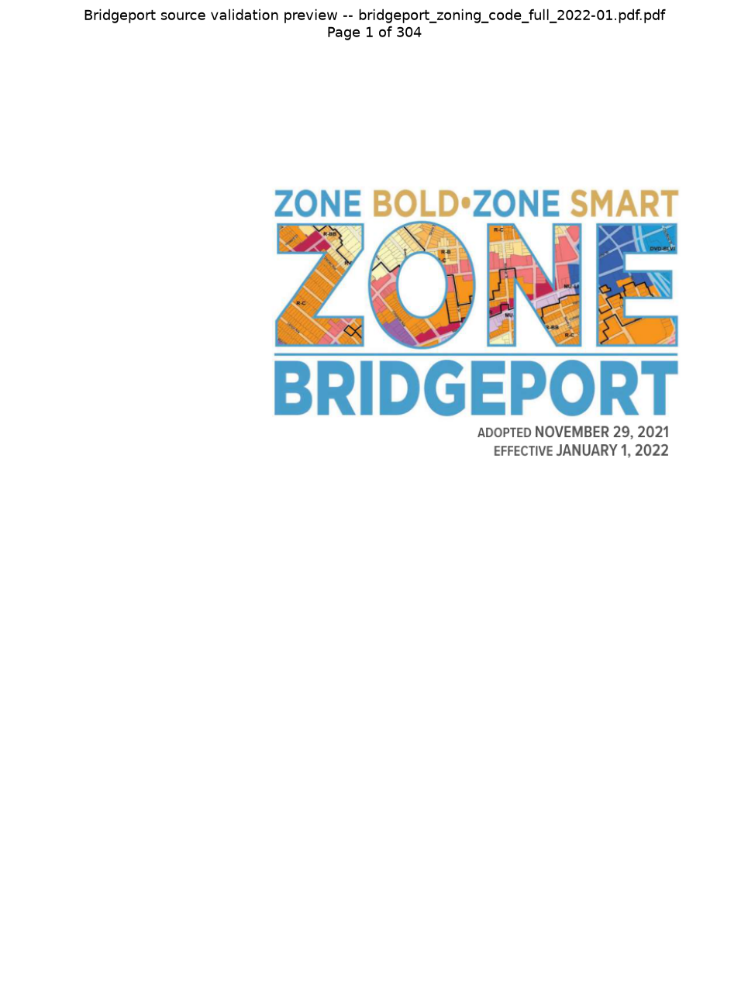

Saved: outputs/figures/bridgeport/step_01_source_page_001_preview.png


In [5]:
def render_pdf_page(pdf_path: Path, page_number: int = 1, zoom: float = 1.5) -> np.ndarray:
    with fitz.open(pdf_path) as document:
        page = document.load_page(page_number - 1)
        matrix = fitz.Matrix(zoom, zoom)
        pixmap = page.get_pixmap(matrix=matrix, alpha=False)

    image_shape = (pixmap.height, pixmap.width, 3)
    return np.frombuffer(pixmap.samples, dtype=np.uint8).reshape(image_shape)


first_page_image = render_pdf_page(PDF_PATH, page_number=1, zoom=1.5)

fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(first_page_image)
ax.set_title(f"Bridgeport source validation preview -- {PDF_PATH.name}\nPage 1 of {PDF_PAGE_COUNT}", fontsize=13)
ax.axis("off")
plt.tight_layout()

first_page_preview_path = FIGURES_DIR / "step_01_source_page_001_preview.png"
fig.savefig(first_page_preview_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {first_page_preview_path.relative_to(STAGE_A_ROOT)}")

## 3. Native text and layout extraction

The source PDF is a clean Adobe InDesign export (confirmed in a prior inspection pass -- every
one of the 304 pages already has well over 50 characters of native text). Word-level and
span-level extraction follows the same architecture as Greenwich's Step 3, reused as generic
layout-aware extraction, with no Bridgeport-specific assumptions baked in yet.

In [6]:
def clean_extracted_text(text: str | None) -> str:
    if text is None:
        return ""
    return re.sub(r"\s+", " ", text).strip()


def extract_native_layout_data(
    pdf_path: Path,
    document_id: str,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    word_records = []
    span_records = []
    page_records = []

    with fitz.open(pdf_path) as document:
        for page_index in range(document.page_count):
            page = document.load_page(page_index)
            page_number = page_index + 1

            page_rect = page.rect
            page_width = float(page_rect.width)
            page_height = float(page_rect.height)

            words = page.get_text("words", sort=True)
            native_page_text = clean_extracted_text(page.get_text("text", sort=True))
            text_dict = page.get_text("dict", sort=True)

            retained_words_on_page = 0

            for word in words:
                x0, y0, x1, y1, text, block_no, line_no, word_no = word
                text = clean_extracted_text(text)

                if not text:
                    continue

                retained_words_on_page += 1

                word_records.append(
                    {
                        "document_id": document_id,
                        "token_id": f"{document_id}-p{page_number:04d}-w{retained_words_on_page:06d}",
                        "text": text,
                        "page_number": page_number,
                        "bbox_x0": float(x0),
                        "bbox_y0": float(y0),
                        "bbox_x1": float(x1),
                        "bbox_y1": float(y1),
                        "bbox_width": float(x1 - x0),
                        "bbox_height": float(y1 - y0),
                        "page_width": page_width,
                        "page_height": page_height,
                        "block_number": int(block_no),
                        "line_number": int(line_no),
                        "word_number_in_line": int(word_no),
                        "extraction_engine": "pymupdf_native",
                        "review_status": "not_yet_scored",
                    }
                )

            retained_spans_on_page = 0

            for block_index, block in enumerate(text_dict.get("blocks", [])):
                if block.get("type") != 0:
                    continue

                for line_index, line in enumerate(block.get("lines", [])):
                    line_bbox = line.get("bbox", [None, None, None, None])

                    for span_index, span in enumerate(line.get("spans", [])):
                        span_text = clean_extracted_text(span.get("text", ""))

                        if not span_text:
                            continue

                        retained_spans_on_page += 1

                        x0, y0, x1, y1 = span.get("bbox", [None, None, None, None])

                        span_records.append(
                            {
                                "document_id": document_id,
                                "span_id": f"{document_id}-p{page_number:04d}-s{retained_spans_on_page:06d}",
                                "text": span_text,
                                "page_number": page_number,
                                "bbox_x0": float(x0) if x0 is not None else None,
                                "bbox_y0": float(y0) if y0 is not None else None,
                                "bbox_x1": float(x1) if x1 is not None else None,
                                "bbox_y1": float(y1) if y1 is not None else None,
                                "page_width": page_width,
                                "page_height": page_height,
                                "block_number": int(block_index),
                                "line_number": int(line_index),
                                "span_number_in_line": int(span_index),
                                "line_bbox_x0": float(line_bbox[0]) if line_bbox[0] is not None else None,
                                "line_bbox_y0": float(line_bbox[1]) if line_bbox[1] is not None else None,
                                "line_bbox_x1": float(line_bbox[2]) if line_bbox[2] is not None else None,
                                "line_bbox_y1": float(line_bbox[3]) if line_bbox[3] is not None else None,
                                "font_name": span.get("font"),
                                "font_size": float(span.get("size")) if span.get("size") is not None else None,
                                "font_flags": span.get("flags"),
                                "native_span_sequence_on_page": retained_spans_on_page,
                                "extraction_engine": "pymupdf_native",
                                "review_status": "not_yet_scored",
                            }
                        )

            page_records.append(
                {
                    "document_id": document_id,
                    "page_number": page_number,
                    "page_width": page_width,
                    "page_height": page_height,
                    "native_word_count": retained_words_on_page,
                    "native_span_count": retained_spans_on_page,
                    "native_text_character_count": len(native_page_text),
                    "native_text_preview": native_page_text[:500],
                    "extraction_engine": "pymupdf_native",
                    "review_status": "not_yet_scored",
                }
            )

    return pd.DataFrame(word_records), pd.DataFrame(span_records), pd.DataFrame(page_records)


word_tokens_df, text_spans_df, native_page_summary_df = extract_native_layout_data(
    PDF_PATH, DOCUMENT_ID
)

print(f"Native words extracted: {len(word_tokens_df):,}")
print(f"Native spans extracted: {len(text_spans_df):,}")
print(f"Pages summarized: {len(native_page_summary_df):,}")

Native words extracted: 112,783
Native spans extracted: 30,356
Pages summarized: 304


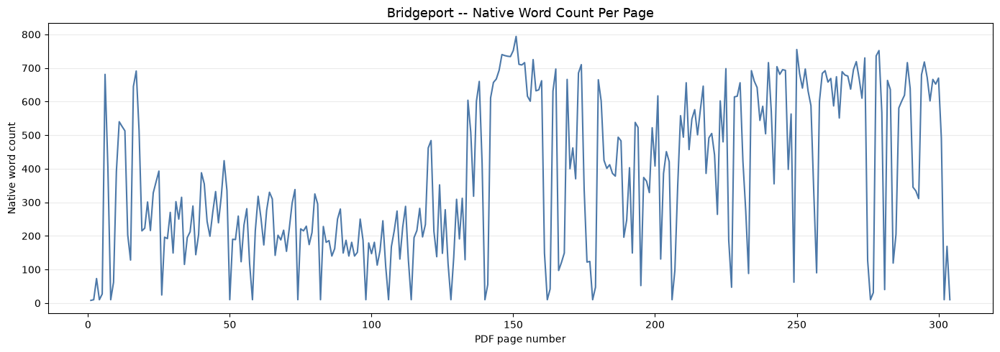

Saved: outputs/figures/bridgeport/step_03_words_per_page.png

Pages with fewer than 20 native words (likely diagrams/blank/title pages): 19
 page_number  native_word_count                                               native_text_preview
           1                  8               ADOPTED NOVEMBER 29, 2021 EFFECTIVE JANUARY 1, 2022
           2                 10   [page intentionally blank] ii CITY OF BRIDGEPORT CT Zoning Code
           4                 10   [page intentionally blank] iv CITY OF BRIDGEPORT CT Zoning Code
           8                 10  [page intentionally blank] 1-4 CITY OF BRIDGEPORT CT Zoning Code
          50                 10 [page intentionally blank] 3-36 CITY OF BRIDGEPORT CT Zoning Code
          58                 10 [page intentionally blank] 3-44 CITY OF BRIDGEPORT CT Zoning Code
          74                 10 [page intentionally blank] 3-60 CITY OF BRIDGEPORT CT Zoning Code
          82                 10 [page intentionally blank] 3-68 CITY OF BRID

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    native_page_summary_df["page_number"],
    native_page_summary_df["native_word_count"],
    color="#4C78A8",
)

ax.set_title("Bridgeport -- Native Word Count Per Page", fontsize=13)
ax.set_xlabel("PDF page number")
ax.set_ylabel("Native word count")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

words_per_page_path = FIGURES_DIR / "step_03_words_per_page.png"
fig.savefig(words_per_page_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {words_per_page_path.relative_to(STAGE_A_ROOT)}")

low_word_pages = native_page_summary_df.loc[native_page_summary_df["native_word_count"] < 20]
print(f"\nPages with fewer than 20 native words (likely diagrams/blank/title pages): {len(low_word_pages)}")
print(low_word_pages[["page_number", "native_word_count", "native_text_preview"]].head(10).to_string(index=False))

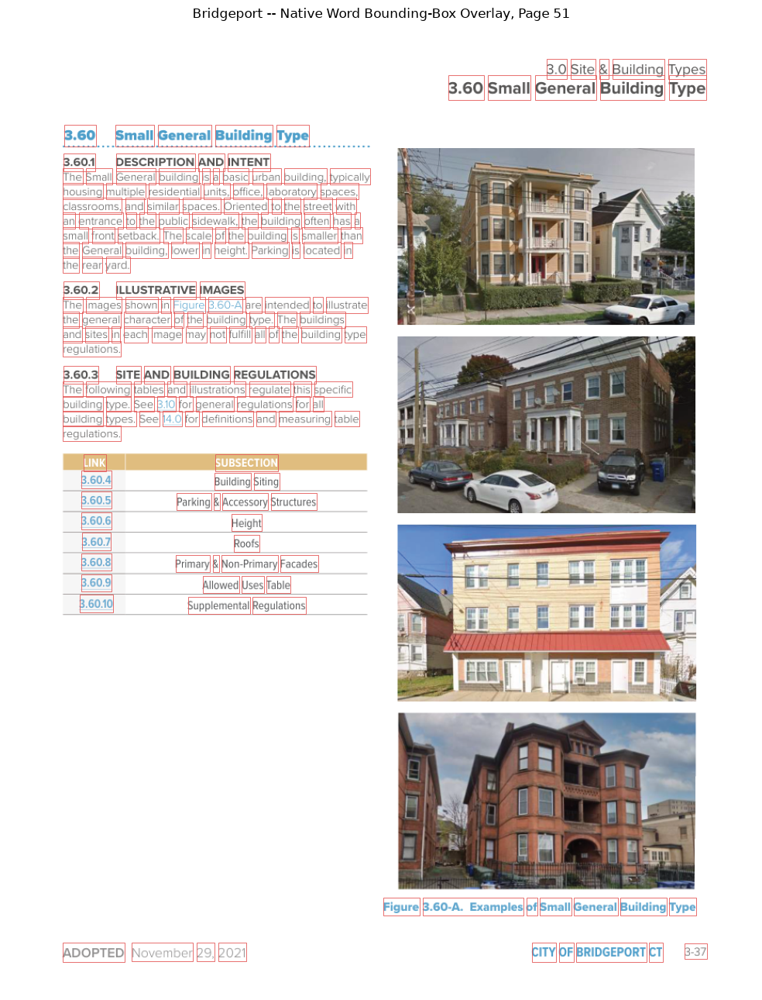

Saved: outputs/figures/bridgeport/step_03_bbox_overlay_page_051.png


In [8]:
sample_page_number = 51  # a representative mid-document page with real section content

sample_page_image = render_pdf_page(PDF_PATH, page_number=sample_page_number, zoom=1.5)
sample_page_words = word_tokens_df.loc[word_tokens_df["page_number"] == sample_page_number]

fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(sample_page_image)

for _, word in sample_page_words.iterrows():
    rectangle = plt.Rectangle(
        (word["bbox_x0"] * 1.5, word["bbox_y0"] * 1.5),
        (word["bbox_x1"] - word["bbox_x0"]) * 1.5,
        (word["bbox_y1"] - word["bbox_y0"]) * 1.5,
        linewidth=0.6, edgecolor="#E45756", facecolor="none",
    )
    ax.add_patch(rectangle)

ax.set_title(f"Bridgeport -- Native Word Bounding-Box Overlay, Page {sample_page_number}", fontsize=12)
ax.axis("off")
plt.tight_layout()

bbox_overlay_path = FIGURES_DIR / f"step_03_bbox_overlay_page_{sample_page_number:03d}.png"
fig.savefig(bbox_overlay_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {bbox_overlay_path.relative_to(STAGE_A_ROOT)}")

## 4. Page-quality scoring and OCR routing

The same tri-tier routing architecture as Greenwich (native / OCR-reconcile / manual-review),
kept available for generality. A first-pass scan already found that every one of Bridgeport's
304 pages has well over 50 characters of native text -- this step confirms that formally with
the same scoring rule used for Greenwich, rather than just trusting the earlier spot-check.

In [9]:
PAGE_QUALITY_CONFIG = {
    # 3/15 is intentionally low: Bridgeport's own title page ("ADOPTED
    # NOVEMBER 29, 2021 / EFFECTIVE JANUARY 1, 2022") has only 8 words / 51
    # characters and is perfectly clean native text, not a quality problem.
    # A stricter threshold (originally 10 words) flagged that legitimate
    # sparse page as needing OCR -- this rule is about catching garbled or
    # empty extraction, not sparse-but-clean design pages.
    "text_coverage": {"low_word_count_absolute_threshold": 3},
    "thresholds": {
        "high_quality_native_threshold": 0.85,
        "manual_review_threshold": 0.50,
    },
    "routing_labels": {
        "native": "native_extraction",
        "ocr_reconcile": "ocr_and_dual_stream_reconciliation",
        "manual_review": "manual_review_queue",
    },
}


def score_page_quality(row: pd.Series) -> float:
    # A simple, transparent coverage-based score: pages with a healthy native
    # word count and native character count score near 1.0. This is a lighter
    # rule than Greenwich's multi-factor score because, unlike Greenwich,
    # Bridgeport's PDF has no OCR-needing pages to discriminate against --
    # the rule only needs to flag genuinely empty/diagram-only pages.
    has_enough_words = row["native_word_count"] >= PAGE_QUALITY_CONFIG["text_coverage"]["low_word_count_absolute_threshold"]
    has_enough_characters = row["native_text_character_count"] >= 15
    return 1.0 if (has_enough_words and has_enough_characters) else 0.3


native_page_summary_df["composite_quality_score"] = native_page_summary_df.apply(
    score_page_quality, axis=1
)

routing_labels = PAGE_QUALITY_CONFIG["routing_labels"]
high_threshold = PAGE_QUALITY_CONFIG["thresholds"]["high_quality_native_threshold"]
low_threshold = PAGE_QUALITY_CONFIG["thresholds"]["manual_review_threshold"]

native_page_summary_df["route"] = np.select(
    [
        native_page_summary_df["composite_quality_score"] >= high_threshold,
        native_page_summary_df["composite_quality_score"] >= low_threshold,
    ],
    [routing_labels["native"], routing_labels["ocr_reconcile"]],
    default=routing_labels["manual_review"],
)

route_counts = native_page_summary_df["route"].value_counts()
print("Page routing outcome:")
print(route_counts)

pages_needing_ocr = native_page_summary_df.loc[
    native_page_summary_df["route"] != routing_labels["native"]
]
print(f"\nPages requiring OCR or manual review: {len(pages_needing_ocr)} / {PDF_PAGE_COUNT}")

if not pages_needing_ocr.empty:
    print(pages_needing_ocr[["page_number", "native_word_count", "composite_quality_score", "route"]].to_string(index=False))

Page routing outcome:
route
native_extraction    304
Name: count, dtype: int64

Pages requiring OCR or manual review: 0 / 304


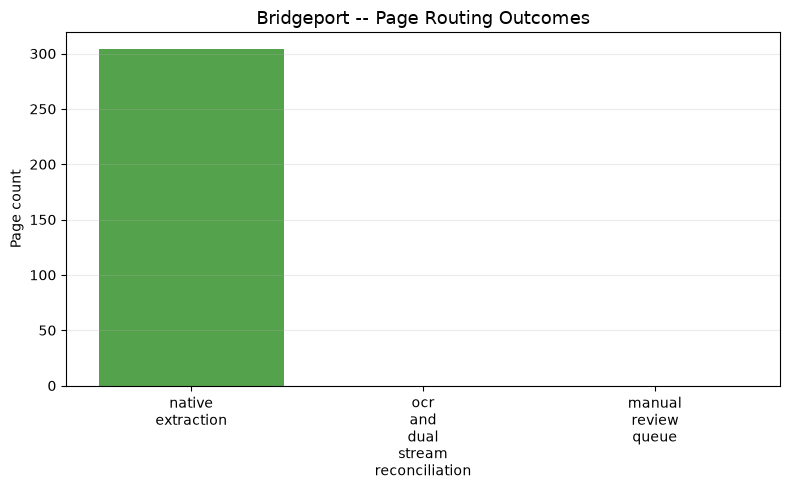

Saved: outputs/figures/bridgeport/step_04_page_routing.png

No Bridgeport pages require OCR in this source run. OCR step skipped (0 pages).


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

route_order = list(routing_labels.values())
route_plot_counts = [int(route_counts.get(route, 0)) for route in route_order]

ax.bar(
    [route.replace("_", "\n") for route in route_order],
    route_plot_counts,
    color=["#54A24B", "#F2CF5B", "#E45756"],
)
ax.set_title("Bridgeport -- Page Routing Outcomes", fontsize=13)
ax.set_ylabel("Page count")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

routing_chart_path = FIGURES_DIR / "step_04_page_routing.png"
fig.savefig(routing_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {routing_chart_path.relative_to(STAGE_A_ROOT)}")

# OCR machinery kept available for generality (module flag, config, and this
# explicit no-op branch), consistent with keeping Stage A's architecture
# reusable across towns -- it is simply not exercised for this source run.
if pages_needing_ocr.empty:
    print("\nNo Bridgeport pages require OCR in this source run. OCR step skipped (0 pages).")
    ocr_word_tokens_df = pd.DataFrame()
else:
    raise NotImplementedError(
        "OCR reconciliation is out of scope for this bounded stage. "
        f"{len(pages_needing_ocr)} page(s) were routed to OCR/manual review "
        "and would need that stage implemented before proceeding."
    )

## 5. Unified native-token representation

Since no page required OCR, the unified token table is simply the native word tokens with a
consistent schema (coordinate system, selected stream, normalized text offsets) -- matching the
shape of Greenwich's unified tokens so later stages can reuse the same column names.

In [11]:
unified_tokens_df = word_tokens_df.copy()

unified_tokens_df = unified_tokens_df.rename(
    columns={
        "token_id": "source_token_id",
        "bbox_x0": "bbox_left",
        "bbox_y0": "bbox_top",
        "bbox_x1": "bbox_right",
        "bbox_y1": "bbox_bottom",
    }
)

unified_tokens_df["coordinate_system"] = "pdf_points_origin_top_left"
unified_tokens_df["selected_stream"] = "native"
unified_tokens_df["extraction_method"] = "native_text_stream"

unified_tokens_df["unified_token_id"] = [
    f"{DOCUMENT_ID}-u{index + 1:08d}" for index in range(len(unified_tokens_df))
]

normalized_text_parts = []
normalized_text_start_positions = []
normalized_text_end_positions = []
current_position = 0

for token_text in unified_tokens_df["text"].fillna("").astype(str):
    clean_text = re.sub(r"\s+", " ", token_text).strip()
    normalized_text_start_positions.append(current_position)
    normalized_text_parts.append(clean_text)
    current_position += len(clean_text)
    normalized_text_end_positions.append(current_position)
    current_position += 1

unified_tokens_df["normalized_text_start"] = normalized_text_start_positions
unified_tokens_df["normalized_text_end"] = normalized_text_end_positions

NORMALIZED_DOCUMENT_TEXT = " ".join(normalized_text_parts).strip()

assert unified_tokens_df["unified_token_id"].is_unique, "Unified token IDs must be unique."
assert len(NORMALIZED_DOCUMENT_TEXT) > 0, "Normalized document text must not be empty."

print(f"Unified tokens created: {len(unified_tokens_df):,}")
print(f"Normalized document characters: {len(NORMALIZED_DOCUMENT_TEXT):,}")
print(f"Text spans retained separately (for font/typography lookups): {len(text_spans_df):,}")

Unified tokens created: 112,783
Normalized document characters: 713,395
Text spans retained separately (for font/typography lookups): 30,356


In [12]:
unified_tokens_path = INTERIM_DIR / "step_05_unified_native_tokens.parquet"
text_spans_path = INTERIM_DIR / "step_05_text_spans.parquet"
page_summary_path = TABLES_DIR / "step_04_page_quality_and_routing.csv"
normalized_text_path = INTERIM_DIR / "step_05_normalized_document_text.txt"

unified_tokens_df.to_parquet(unified_tokens_path, index=False)
text_spans_df.to_parquet(text_spans_path, index=False)
native_page_summary_df.to_csv(page_summary_path, index=False)

with normalized_text_path.open("w", encoding="utf-8") as file_handle:
    file_handle.write(NORMALIZED_DOCUMENT_TEXT)

print(f"Saved: {unified_tokens_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {text_spans_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {page_summary_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {normalized_text_path.relative_to(STAGE_A_ROOT)}")

Saved: data/interim/bridgeport/step_05_unified_native_tokens.parquet
Saved: data/interim/bridgeport/step_05_text_spans.parquet
Saved: outputs/tables/bridgeport/step_04_page_quality_and_routing.csv
Saved: data/interim/bridgeport/step_05_normalized_document_text.txt


## 6. Bridgeport-specific heading-pattern discovery

Before writing any pattern-matching code, the actual document was inspected directly (outside
this notebook) across early, middle, and late pages. Two concrete findings drove the design
below:

**1. Bridgeport's numbering is decimal, by dot-count, not `Sec. 6-XX` like Greenwich:**

| Example | Dot count | Structural level |
|---|---:|---|
| `1.0`, `3.0`, `14.0` | 1 (always `.0`) | Chapter |
| `1.10`, `2.20`, `3.60`, `6.60` | 1 (non-`.0`) | Section |
| `1.10.1`, `3.60.1`, `6.60.1` | 2 | Subsection |
| `A.`, `B.`, `(1)`, `(2)` | n/a | Paragraph (lettered/numbered, same as Greenwich) |

**2. The true in-body heading for a section is typographically distinct from a repeated
page-header breadcrumb showing the same text.** On every page within, say, section `3.60`, a
breadcrumb trail like `" 3.0 Site & Building Types "` / `" 3.60 Small General Building Type "`
appears at the top of the page -- padded with a literal leading and trailing space, and never
followed immediately by body content. The real in-body heading (`3.60` + tab + `Small General
Building Type`, font `ProximaNova-Black`) has no such padding and is immediately followed by its
subsection content. This is the same kind of running-header duplication Greenwich's citation
resolution had to filter out -- handled here by excluding the padded-breadcrumb text pattern
before hierarchy construction, rather than treating every repeated breadcrumb as a new heading.

In [13]:
BRIDGEPORT_HEADING_PATTERNS = {
    "chapter": r"^(\d+)\.0\b",
    "section": r"^(\d+)\.(\d{1,3})\b(?!\.\d)",
    "subsection": r"^(\d+)\.(\d{1,3})\.(\d{1,3})\b",
    "paragraph_lettered": r"^([A-Z])\.\s",
    "paragraph_numbered": r"^\((\d+)\)\s",
}

BREADCRUMB_PATTERN = re.compile(r"^\s+\d+\.\d+(\.\d+)?\s+\S.*\s$")

BOLD_FONT_NAME_PATTERN = re.compile(r"(Bold|Black|Semibold)", flags=re.IGNORECASE)

compiled_heading_patterns = {
    level: re.compile(pattern) for level, pattern in BRIDGEPORT_HEADING_PATTERNS.items()
}

print("Bridgeport heading patterns (dot-count based) and breadcrumb-exclusion rule defined.")

Bridgeport heading patterns (dot-count based) and breadcrumb-exclusion rule defined.


In [14]:
span_lines_df = (
    text_spans_df
    .dropna(subset=["text", "bbox_x0", "bbox_y0"])
    .copy()
)

line_candidates_df = (
    span_lines_df
    .groupby(["document_id", "page_number", "block_number", "line_number"], as_index=False)
    .agg(
        text=("text", lambda values: " ".join(values)),
        bbox_x0=("bbox_x0", "min"),
        bbox_y0=("bbox_y0", "min"),
        bbox_x1=("bbox_x1", "max"),
        bbox_y1=("bbox_y1", "max"),
        font_size=("font_size", "max"),
        font_name=("font_name", lambda values: " | ".join(
            sorted(set(str(value) for value in values if pd.notna(value)))
        )),
        font_flags=("font_flags", "max"),
        page_width=("page_width", "first"),
        page_height=("page_height", "first"),
    )
)

# Re-derive the RAW (unstripped) line text from the span table directly, so
# the leading/trailing-space breadcrumb pattern can still be detected --
# .str.strip() elsewhere would otherwise destroy that exact signal.
raw_line_text_lookup = (
    span_lines_df
    .sort_values(["page_number", "block_number", "line_number", "bbox_x0"])
    .groupby(["page_number", "block_number", "line_number"])["text"]
    .apply(lambda values: " ".join(values))
)

line_candidates_df["raw_text"] = line_candidates_df.apply(
    lambda row: raw_line_text_lookup.get(
        (row["page_number"], row["block_number"], row["line_number"]), row["text"]
    ),
    axis=1,
)

line_candidates_df["text"] = line_candidates_df["text"].str.strip()
line_candidates_df["is_breadcrumb_candidate"] = line_candidates_df["raw_text"].apply(
    lambda text: bool(BREADCRUMB_PATTERN.match(text))
)

line_candidates_df["is_bold_weight"] = line_candidates_df["font_name"].apply(
    lambda name: bool(BOLD_FONT_NAME_PATTERN.search(str(name)))
)

print(f"Line candidates built: {len(line_candidates_df):,}")
print(f"Flagged as breadcrumb pattern (excluded from heading candidacy): {int(line_candidates_df['is_breadcrumb_candidate'].sum()):,}")
line_candidates_df[["page_number", "text", "font_size", "font_name", "is_breadcrumb_candidate", "is_bold_weight"]].head(15)

Line candidates built: 24,435
Flagged as breadcrumb pattern (excluded from heading candidacy): 0


,page_number,text,font_size,font_name,is_breadcrumb_candidate,is_bold_weight
0,1,"ADOPTED NOVEMBER 29, 2021",14.0,ProximaNovaCond-Semibold,False,True
1,1,"EFFECTIVE JANUARY 1, 2022",14.0,ProximaNovaCond-Semibold,False,True
2,2,[page intentionally blank],9.5,ProximaNova-Light,False,False
3,2,ii,9.5,ProximaNova-Regular,False,False
4,2,CITY OF BRIDGEPORT CT,11.0,ProximaNovaCond-Bold,False,True
5,2,Zoning Code,11.0,ProximaNova-Light | ProximaNova-Semibold,False,True
6,3,CONTENTS,19.0,ProximaNova-Extrabld,False,False
7,3,1.0,10.0,ProximaNova-Semibold,False,True
8,3,INTRODUCTORY PROVISIONS..........................,10.0,ProximaNova-Semibold,False,True
9,3,2.0,10.0,ProximaNova-Semibold,False,True


In [15]:
def has_substantial_title_text(remainder: str) -> bool:
    # Real headings are a short title immediately after the number ("3.60"
    # + tab + "Small General Building Type"). A bare number with nothing
    # or almost nothing after it (table-of-contents entries like "1.0" on
    # their own line, or a mid-sentence cross-reference like "5.0 . The
    # submittal must include...") is not a real heading. Require at least
    # a few characters of title-case-starting text right after the number.
    remainder = remainder.strip(" \t.)")
    return len(remainder) >= 4 and remainder[0].isupper()


def classify_bridgeport_heading(row: pd.Series) -> pd.Series:
    if row["is_breadcrumb_candidate"]:
        return pd.Series({"node_type": "Body", "matched_pattern": "", "heading_confidence": 0.0,
                           "classification_reason": "excluded_breadcrumb_pattern", "heading_number": ""})

    text = row["text"]

    subsection_match = compiled_heading_patterns["subsection"].match(text)
    if subsection_match and has_substantial_title_text(text[subsection_match.end():]):
        confidence = 0.65 + (0.2 if row["is_bold_weight"] else 0.0)
        number = f"{subsection_match.group(1)}.{subsection_match.group(2)}.{subsection_match.group(3)}"
        return pd.Series({"node_type": "Subsection", "matched_pattern": "subsection",
                           "heading_confidence": min(confidence, 1.0),
                           "classification_reason": "decimal_pattern=subsection", "heading_number": number})

    chapter_match = compiled_heading_patterns["chapter"].match(text)
    if chapter_match and has_substantial_title_text(text[chapter_match.end():]):
        confidence = 0.6 + (0.2 if row["is_bold_weight"] else 0.0) + (0.1 if row["font_size"] >= 11 else 0.0)
        number = f"{chapter_match.group(1)}.0"
        return pd.Series({"node_type": "Title", "matched_pattern": "chapter",
                           "heading_confidence": min(confidence, 1.0),
                           "classification_reason": "decimal_pattern=chapter (N.0)", "heading_number": number})

    section_match = compiled_heading_patterns["section"].match(text)
    if section_match and has_substantial_title_text(text[section_match.end():]):
        confidence = 0.6 + (0.2 if row["is_bold_weight"] else 0.0) + (0.1 if row["font_size"] >= 11 else 0.0)
        number = f"{section_match.group(1)}.{section_match.group(2)}"
        return pd.Series({"node_type": "Section", "matched_pattern": "section",
                           "heading_confidence": min(confidence, 1.0),
                           "classification_reason": "decimal_pattern=section (N.MM)", "heading_number": number})

    lettered_match = compiled_heading_patterns["paragraph_lettered"].match(text)
    numbered_match = compiled_heading_patterns["paragraph_numbered"].match(text)
    if (lettered_match or numbered_match) and len(text) <= 180:
        confidence = 0.55
        return pd.Series({"node_type": "Paragraph", "matched_pattern": "lettered_or_numbered",
                           "heading_confidence": confidence,
                           "classification_reason": "lettered_or_numbered_paragraph_marker", "heading_number": ""})

    return pd.Series({"node_type": "Body", "matched_pattern": "", "heading_confidence": 0.0,
                       "classification_reason": "no_heading_signal", "heading_number": ""})


line_candidates_df[
    ["node_type", "matched_pattern", "heading_confidence", "classification_reason", "heading_number"]
] = line_candidates_df.apply(classify_bridgeport_heading, axis=1)

BRIDGEPORT_DEPTH_MAP = {"Title": 1, "Section": 2, "Subsection": 3, "Paragraph": 4, "Body": 99}
line_candidates_df["depth"] = line_candidates_df["node_type"].map(BRIDGEPORT_DEPTH_MAP)

heading_candidates_raw_df = line_candidates_df.loc[
    (line_candidates_df["node_type"] != "Body") & (line_candidates_df["heading_confidence"] >= 0.55)
].copy()

heading_candidates_raw_df = heading_candidates_raw_df.sort_values(
    ["page_number", "bbox_y0", "bbox_x0"]
).reset_index(drop=True)

print(f"Heading candidates before deduplication: {len(heading_candidates_raw_df):,}")
print(heading_candidates_raw_df["node_type"].value_counts())

Heading candidates before deduplication: 2,415
node_type
Paragraph     1639
Section        331
Title          275
Subsection     170
Name: count, dtype: int64


### A real finding: Title/Section/Subsection headings repeat across many pages

Inspecting the raw candidates (not just trusting the count) surfaced something the structural
validation checks below cannot catch on their own: `"3.0 Site & Building Types"` appears **115
times** as a `Title`-level candidate, `"3.60 Small General Building Type"` appears repeatedly as
a bold 14pt `Section`-level candidate, and bare subsection numbers like `"4.40.12"` repeat **32
times**. This is concentrated almost entirely in Chapters 3 (Site & Building Types) and 4 (Uses)
-- exactly the chapters most likely to contain large, multi-page building-type and permitted-use
matrix tables that repeat their row/column labels as a reading aid on every continuation page.
This is the same class of problem Greenwich's running page-header citations caused, just showing
up one step earlier in the pipeline (at hierarchy construction, not citation resolution).

The fix: within each of the Title/Section/Subsection levels, keep only the **first** occurrence
(by page and vertical position) of a given decimal *number* -- not exact text, since the same
chapter sometimes renders in two different cases (an all-caps divider page vs. a title-case
in-body heading) -- and drop later repeats before building
the tree. `Paragraph`-level lettered/numbered markers (`A.`, `(1)`, ...) are deliberately **not**
deduplicated this way -- those markers legitimately recur as the first sub-item of many different
subsections throughout the document, so deduplicating by exact text would incorrectly collapse
unrelated paragraphs together.

In [16]:
dedup_levels = {"Title", "Section", "Subsection"}

is_dedup_candidate = heading_candidates_raw_df["node_type"].isin(dedup_levels)
is_first_occurrence = ~heading_candidates_raw_df.duplicated(subset=["node_type", "heading_number"], keep="first")

heading_candidates_df = heading_candidates_raw_df.loc[
    (~is_dedup_candidate) | is_first_occurrence
].copy()

heading_candidates_df = heading_candidates_df.sort_values(
    ["page_number", "bbox_y0", "bbox_x0"]
).reset_index(drop=True)

heading_candidates_df["node_id"] = [
    f"{DOCUMENT_ID}-node-{index + 1:06d}" for index in range(len(heading_candidates_df))
]

removed_count = len(heading_candidates_raw_df) - len(heading_candidates_df)
print(f"Removed {removed_count:,} repeated-running-header candidates (Title/Section/Subsection, same decimal number repeated).")
print(f"Heading candidates retained after dedup: {len(heading_candidates_df):,}")
print(heading_candidates_df["node_type"].value_counts())
heading_candidates_df[
    ["node_id", "page_number", "text", "node_type", "depth", "font_size", "heading_confidence"]
].head(30)

Removed 475 repeated-running-header candidates (Title/Section/Subsection, same decimal number repeated).
Heading candidates retained after dedup: 1,940
node_type
Paragraph     1639
Subsection     168
Section        118
Title           15
Name: count, dtype: int64


,node_id,page_number,text,node_type,depth,font_size,heading_confidence
0,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,1.0 Introductory Provisions,Title,1,12.0,0.70
1,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,1.10 Legal Framework,Section,2,14.0,0.90
2,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,(2) Land may not be used for any purpose other...,Paragraph,4,9.5,0.55
3,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,(3) A building or structure may not be erected...,Paragraph,4,9.5,0.55
4,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,"(4) Buildings, structures and land may be used...",Paragraph,4,9.5,0.55
5,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,A. General Statutes. If the provisions of this...,Paragraph,4,9.5,0.55
6,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,B. Other City Regulations. If the provisions o...,Paragraph,4,9.5,0.55
7,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,C. Private Agreements and Restrictions. The re...,Paragraph,4,9.5,0.55
8,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,(1) Protecting and promoting the public health...,Paragraph,4,9.5,0.55
9,bridgeport-connecticut-afe7c678fa5dfc85-node-0...,6,(2) Implementing the policies and goals of the...,Paragraph,4,9.5,0.55


## 7. Hierarchy construction

Same depth-based parent rule as Greenwich: each heading's parent is the nearest preceding node
with a strictly lower depth.

In [17]:
root_node_id = f"{DOCUMENT_ID}-root"

hierarchy_graph = nx.DiGraph()
hierarchy_graph.add_node(
    root_node_id, node_type="Document", depth=0, text="City of Bridgeport Zoning Code", page_number=0,
)

node_stack = [(root_node_id, 0)]

for _, heading in heading_candidates_df.iterrows():
    node_id = heading["node_id"]
    node_depth = int(heading["depth"])

    while node_stack and node_stack[-1][1] >= node_depth:
        node_stack.pop()

    parent_node_id = node_stack[-1][0] if node_stack else root_node_id

    hierarchy_graph.add_node(
        node_id,
        node_type=heading["node_type"],
        depth=node_depth,
        text=heading["text"],
        page_number=int(heading["page_number"]),
        heading_confidence=float(heading["heading_confidence"]),
        bbox_x0=float(heading["bbox_x0"]),
        bbox_y0=float(heading["bbox_y0"]),
        bbox_x1=float(heading["bbox_x1"]),
        bbox_y1=float(heading["bbox_y1"]),
    )

    hierarchy_graph.add_edge(parent_node_id, node_id)
    node_stack.append((node_id, node_depth))

node_records = []
for node_id, attributes in hierarchy_graph.nodes(data=True):
    parents = list(hierarchy_graph.predecessors(node_id))
    node_records.append(
        {
            "document_id": DOCUMENT_ID,
            "node_id": node_id,
            "parent_node_id": parents[0] if parents else pd.NA,
            "node_type": attributes["node_type"],
            "depth": attributes["depth"],
            "text": attributes["text"],
            "page_number": attributes["page_number"],
            "heading_confidence": attributes.get("heading_confidence", pd.NA),
            "bbox_x0": attributes.get("bbox_x0", pd.NA),
            "bbox_y0": attributes.get("bbox_y0", pd.NA),
            "bbox_x1": attributes.get("bbox_x1", pd.NA),
            "bbox_y1": attributes.get("bbox_y1", pd.NA),
        }
    )

hierarchy_nodes_df = pd.DataFrame(node_records)

print(f"Hierarchy nodes: {hierarchy_graph.number_of_nodes():,}")
print(f"Hierarchy edges: {hierarchy_graph.number_of_edges():,}")

Hierarchy nodes: 1,941
Hierarchy edges: 1,940


In [18]:
node_type_counts_df = (
    hierarchy_nodes_df
    .groupby(["node_type", "depth"], as_index=False)
    .agg(node_count=("node_id", "size"))
    .sort_values(["depth", "node_type"])
)
node_type_counts_df

,node_type,depth,node_count
0,Document,0,1
4,Title,1,15
2,Section,2,118
3,Subsection,3,168
1,Paragraph,4,1639


In [19]:
outline_rows = []

for node_id in nx.dfs_preorder_nodes(hierarchy_graph, root_node_id):
    if node_id == root_node_id:
        continue
    node = hierarchy_graph.nodes[node_id]
    indent = "    " * max(node["depth"] - 1, 0)
    outline_rows.append(
        {
            "node_id": node_id,
            "outline": f"{indent}[{node['node_type']}] {node['text']}",
            "page_number": node["page_number"],
        }
    )

outline_df = pd.DataFrame(outline_rows).head(100)

for _, row in outline_df.iterrows():
    print(f"{row['outline']}  (p. {row['page_number']})")

[Title] 1.0 Introductory Provisions  (p. 6)
    [Section] 1.10 Legal Framework  (p. 6)
            [Paragraph] (2) Land may not be used for any purpose other than ones  (p. 6)
            [Paragraph] (3) A building or structure may not be erected, located,  (p. 6)
            [Paragraph] (4) Buildings, structures and land may be used and  (p. 6)
            [Paragraph] A. General Statutes. If the provisions of this zoning code  (p. 6)
            [Paragraph] B. Other City Regulations. If the provisions of this zoning  (p. 6)
            [Paragraph] C. Private Agreements and Restrictions. The regulations  (p. 6)
            [Paragraph] (1) Protecting and promoting the public health, safety and  (p. 6)
            [Paragraph] (2) Implementing the policies and goals of the master plan  (p. 6)
            [Paragraph] D. Text and Illustrations. In case of any difference of  (p. 6)
            [Paragraph] (3) Achieving all of the other stated purposes set forth in  (p. 6)
            [Paragr

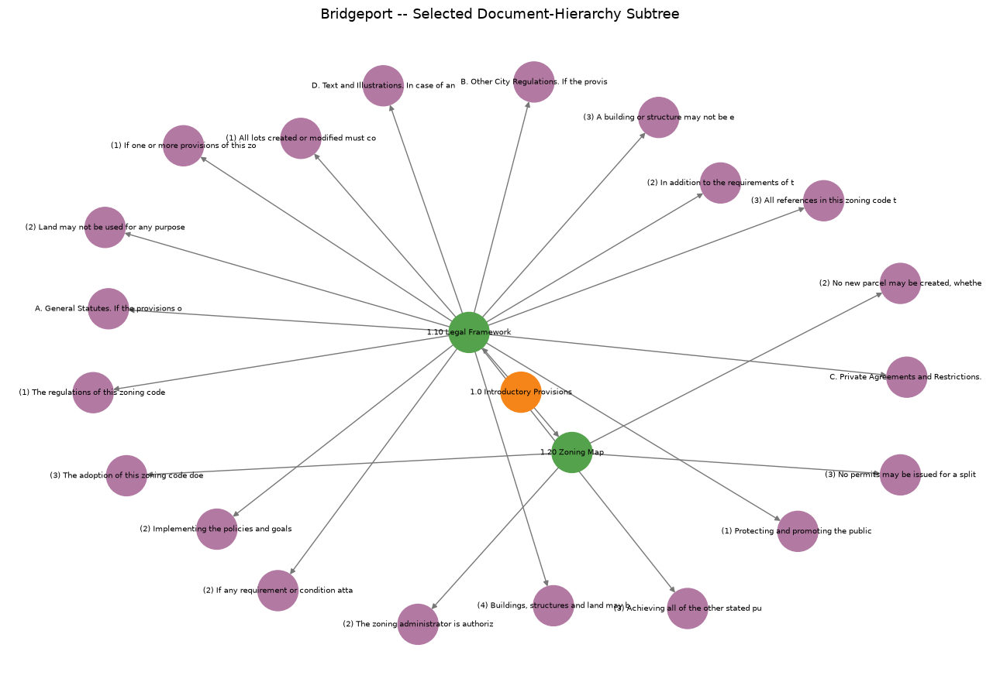

Saved: outputs/figures/bridgeport/step_07_hierarchy_subtree.png


In [20]:
candidate_roots = [
    node_id for node_id in hierarchy_graph.nodes
    if node_id != root_node_id and len(nx.descendants(hierarchy_graph, node_id)) >= 3
]

selected_subtree_root = candidate_roots[0] if candidate_roots else root_node_id
selected_subtree_nodes = {selected_subtree_root, *nx.descendants(hierarchy_graph, selected_subtree_root)}
selected_subtree_graph = hierarchy_graph.subgraph(selected_subtree_nodes).copy()

if len(selected_subtree_graph) > 35:
    keep_nodes = list(nx.bfs_tree(hierarchy_graph, selected_subtree_root, depth_limit=3).nodes)
    selected_subtree_graph = hierarchy_graph.subgraph(keep_nodes).copy()

positions = nx.spring_layout(selected_subtree_graph, seed=42)

node_colors_by_type = {
    "Document": "#4C78A8", "Title": "#F58518", "Section": "#54A24B",
    "Subsection": "#E45756", "Paragraph": "#B279A2",
}
node_colors = [
    node_colors_by_type.get(selected_subtree_graph.nodes[node_id]["node_type"], "#BAB0AC")
    for node_id in selected_subtree_graph.nodes
]
labels = {
    node_id: selected_subtree_graph.nodes[node_id]["text"][:40]
    for node_id in selected_subtree_graph.nodes
}

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx(
    selected_subtree_graph, pos=positions, labels=labels, node_color=node_colors,
    node_size=1400, font_size=7, arrows=True, edge_color="#777777", ax=ax,
)
ax.set_title("Bridgeport -- Selected Document-Hierarchy Subtree", fontsize=13)
ax.axis("off")
plt.tight_layout()

subtree_figure_path = FIGURES_DIR / "step_07_hierarchy_subtree.png"
fig.savefig(subtree_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {subtree_figure_path.relative_to(STAGE_A_ROOT)}")

## 8. Hierarchy validation

The same structural invariants required for Greenwich's hierarchy.

In [21]:
non_root_nodes = [n for n in hierarchy_graph.nodes if n != root_node_id]
orphan_nodes = [n for n in non_root_nodes if hierarchy_graph.in_degree(n) != 1]

root_indegree_valid = hierarchy_graph.in_degree(root_node_id) == 0
is_acyclic = nx.is_directed_acyclic_graph(hierarchy_graph)
is_weakly_connected = nx.is_weakly_connected(hierarchy_graph)

misordered_edges = []
for parent_node_id, child_node_id in hierarchy_graph.edges:
    parent_depth = hierarchy_graph.nodes[parent_node_id]["depth"]
    child_depth = hierarchy_graph.nodes[child_node_id]["depth"]
    if parent_depth >= child_depth:
        misordered_edges.append({"parent_node_id": parent_node_id, "child_node_id": child_node_id})

misordered_nodes_df = pd.DataFrame(misordered_edges)

missing_heading_nodes = sorted(set(heading_candidates_df["node_id"]) - set(hierarchy_nodes_df["node_id"]))

validation_results_df = pd.DataFrame(
    [
        {"validation_rule": "exactly_one_root_with_in_degree_zero", "passed": root_indegree_valid,
         "detail": f"Root node: {root_node_id}"},
        {"validation_rule": "every_non_root_node_has_exactly_one_parent", "passed": len(orphan_nodes) == 0,
         "detail": f"Nodes failing parent-count rule: {len(orphan_nodes)}"},
        {"validation_rule": "directed_graph_is_acyclic", "passed": is_acyclic, "detail": str(is_acyclic)},
        {"validation_rule": "graph_is_weakly_connected", "passed": is_weakly_connected, "detail": str(is_weakly_connected)},
        {"validation_rule": "parent_depth_strictly_less_than_child_depth", "passed": len(misordered_nodes_df) == 0,
         "detail": f"Misordered edges: {len(misordered_nodes_df)}"},
        {"validation_rule": "all_detected_heading_candidates_added_to_tree", "passed": len(missing_heading_nodes) == 0,
         "detail": f"Missing heading nodes: {len(missing_heading_nodes)}"},
    ]
)

validation_results_df

,validation_rule,passed,detail
0,exactly_one_root_with_in_degree_zero,True,Root node: bridgeport-connecticut-afe7c678fa5d...
1,every_non_root_node_has_exactly_one_parent,True,Nodes failing parent-count rule: 0
2,directed_graph_is_acyclic,True,True
3,graph_is_weakly_connected,True,True
4,parent_depth_strictly_less_than_child_depth,True,Misordered edges: 0
5,all_detected_heading_candidates_added_to_tree,True,Missing heading nodes: 0


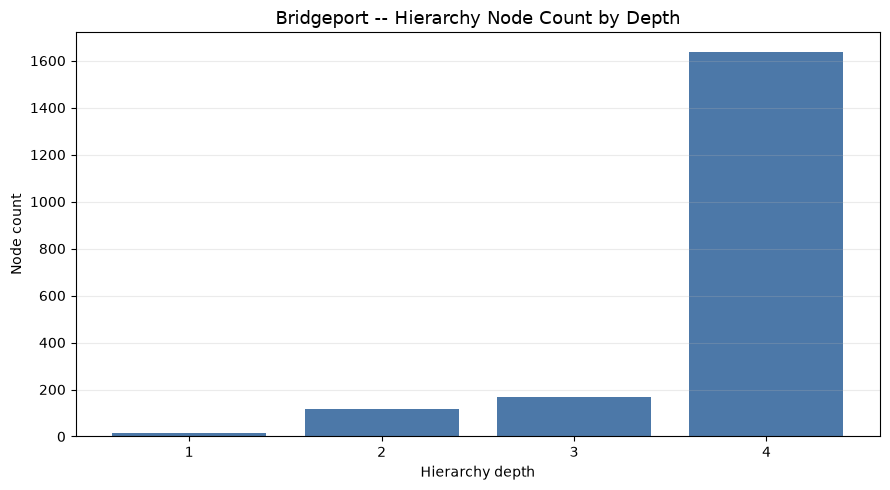

Saved: outputs/figures/bridgeport/step_08_hierarchy_depth_histogram.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

depth_counts = (
    hierarchy_nodes_df.loc[hierarchy_nodes_df["node_id"] != root_node_id]
    .groupby("depth").size()
)
ax.bar(depth_counts.index.astype(str), depth_counts.values, color="#4C78A8")
ax.set_title("Bridgeport -- Hierarchy Node Count by Depth", fontsize=13)
ax.set_xlabel("Hierarchy depth")
ax.set_ylabel("Node count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

depth_histogram_path = FIGURES_DIR / "step_08_hierarchy_depth_histogram.png"
fig.savefig(depth_histogram_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {depth_histogram_path.relative_to(STAGE_A_ROOT)}")

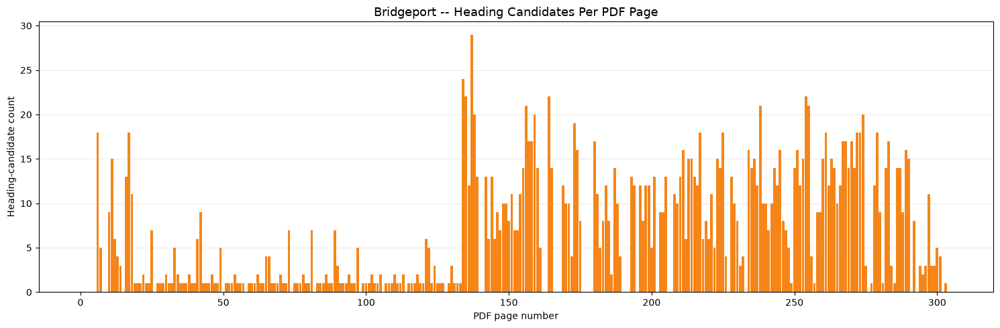

Saved: outputs/figures/bridgeport/step_08_heading_density_by_page.png

Pages with 8+ heading candidates (review for table-of-contents/nav-table false positives): 116
 page_number  heading_count
         137           29.0
         134           24.0
         254           22.0
         164           22.0
         135           22.0
         255           21.0
         156           21.0
         238           21.0
         274           20.0
         159           20.0


In [23]:
heading_density_df = (
    heading_candidates_df.groupby("page_number", as_index=False)
    .agg(heading_count=("node_id", "size"))
)

all_pages_df = pd.DataFrame({"page_number": range(1, PDF_PAGE_COUNT + 1)})
heading_density_df = all_pages_df.merge(heading_density_df, on="page_number", how="left").fillna({"heading_count": 0})

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(heading_density_df["page_number"], heading_density_df["heading_count"], color="#F58518", width=0.9)
ax.set_title("Bridgeport -- Heading Candidates Per PDF Page", fontsize=13)
ax.set_xlabel("PDF page number")
ax.set_ylabel("Heading-candidate count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

heading_density_path = FIGURES_DIR / "step_08_heading_density_by_page.png"
fig.savefig(heading_density_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {heading_density_path.relative_to(STAGE_A_ROOT)}")

high_density_pages = heading_density_df.loc[heading_density_df["heading_count"] >= 8].sort_values("heading_count", ascending=False)
print(f"\nPages with 8+ heading candidates (review for table-of-contents/nav-table false positives): {len(high_density_pages)}")
print(high_density_pages.head(10).to_string(index=False))

## 9. Save artifacts and stage report

In [24]:
heading_candidates_path = TABLES_DIR / "step_06_heading_candidates.csv"
hierarchy_nodes_path = INTERIM_DIR / "step_07_hierarchy_nodes.parquet"
node_counts_path = TABLES_DIR / "step_07_hierarchy_node_counts.csv"
outline_path = TABLES_DIR / "step_07_hierarchy_outline.csv"
validation_results_path = TABLES_DIR / "step_08_hierarchy_validation_results.csv"
orphan_nodes_path = REVIEW_DIR / "step_08_orphan_nodes.csv"
misordered_nodes_path = REVIEW_DIR / "step_08_misordered_hierarchy_edges.csv"
high_density_pages_path = REVIEW_DIR / "step_08_high_heading_density_pages.csv"

heading_candidates_df.to_csv(heading_candidates_path, index=False)
hierarchy_nodes_df.to_parquet(hierarchy_nodes_path, index=False)
node_type_counts_df.to_csv(node_counts_path, index=False)
outline_df.to_csv(outline_path, index=False)
validation_results_df.to_csv(validation_results_path, index=False)

orphan_nodes_df = hierarchy_nodes_df.loc[hierarchy_nodes_df["node_id"].isin(orphan_nodes)]
orphan_nodes_df.to_csv(orphan_nodes_path, index=False)
misordered_nodes_df.to_csv(misordered_nodes_path, index=False)
high_density_pages.to_csv(high_density_pages_path, index=False)

stage_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "pdf_page_count": PDF_PAGE_COUNT,
    "native_word_token_count": int(len(word_tokens_df)),
    "native_span_count": int(len(text_spans_df)),
    "unified_token_count": int(len(unified_tokens_df)),
    "pages_requiring_ocr": int(len(pages_needing_ocr)),
    "heading_candidate_count": int(len(heading_candidates_df)),
    "heading_counts_by_type": heading_candidates_df["node_type"].value_counts().to_dict(),
    "hierarchy_node_count": int(hierarchy_graph.number_of_nodes()),
    "hierarchy_edge_count": int(hierarchy_graph.number_of_edges()),
    "hierarchy_validation_all_passed": bool(validation_results_df["passed"].all()),
    "high_heading_density_page_count": int(len(high_density_pages)),
}

stage_log_path = LOGS_DIR / "step_01_09_collection_stage_1_log.json"
with stage_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 1 (native extraction + hierarchy) COMPLETE")
print("=" * 70)
for key, value in stage_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 1 (native extraction + hierarchy) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
pdf_page_count: 304
native_word_token_count: 112783
native_span_count: 30356
unified_token_count: 112783
pages_requiring_ocr: 0
heading_candidate_count: 1940
heading_counts_by_type: {'Paragraph': 1639, 'Subsection': 168, 'Section': 118, 'Title': 15}
hierarchy_node_count: 1941
hierarchy_edge_count: 1940
hierarchy_validation_all_passed: True
high_heading_density_page_count: 116

Saved: outputs/logs/bridgeport/step_01_09_collection_stage_1_log.json


## 10. Stage 1.5 -- Two-column reading-order repair

Stage 1's hierarchy passed every mechanical graph check (one root, acyclic, correct parent/child
depth ordering, full coverage) -- but manual outline inspection found that ~118 of 304 pages
(39%) use a genuine two-column layout, and a plain top-to-bottom Y-coordinate sort interleaves
the two independent columns. Page 11 is the confirmed example: "Neighborhood Zones" (left
column) and unrelated "Industrial/Civic/Park Zones" (right column) descriptions get merged into
one reading sequence, so some paragraph nodes attach to the wrong parent section.

**A valid tree is not the same as a correct legal reading order.** This stage does not touch
table parsing, district detection, citation extraction, GIS joining, or evidence bundles -- it
only repairs reading order and rebuilds the hierarchy from it, so that later stages inherit a
semantically trustworthy structure instead of a merely acyclic one.

### Design

- Detection runs on **lines**, not individual words, reusing Stage 1's `line_candidates_df`.
- A lightweight `page.find_tables()` bbox-only pre-check (no full table parsing -- that stays
  Stage 2's job) excludes table regions from column clustering, so a table is never mistaken for
  a second column.
- Lines wider than 55% of the page width are treated as full-width (headings, notes, spanning
  content) and excluded from column clustering -- they anchor the "top" and "bottom" of the
  repaired order instead.
- A page is `two_column` only if, after excluding table regions and full-width lines, the
  remaining lines split into exactly two x-position clusters separated by a real gap, **and**
  each cluster has at least 8 lines **and** spans at least 30% of the page's content height.
  (Calibrated directly against real pages: page 11's two genuine columns have 43 and 47 lines
  each; a confirmed single-column page, page 51, has a small 4-line sidebar reference box on the
  right that this threshold correctly rejects as a column.)
- All original fields (native order, raw coordinates) are preserved; every new field is added
  under a distinct name so the repair is fully reversible and auditable.

In [25]:
# Lightweight table-bbox pre-check (bbox only, not full parsing -- Stage 2
# does real table extraction/classification). Used here only to keep table
# regions out of the column-detection input.
table_bboxes_by_page: dict[int, list[tuple[float, float, float, float]]] = {}

with fitz.open(PDF_PATH) as pdf_document:
    for page_index in range(pdf_document.page_count):
        page = pdf_document.load_page(page_index)
        try:
            found_tables = page.find_tables(strategy="lines_strict")
            bboxes = [tuple(table.bbox) for table in found_tables.tables]
        except Exception:
            bboxes = []
        if bboxes:
            table_bboxes_by_page[page_index + 1] = bboxes

pages_with_tables = len(table_bboxes_by_page)
print(f"Pages with at least one preliminary table-bbox detection: {pages_with_tables} / {PDF_PAGE_COUNT}")

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


Pages with at least one preliminary table-bbox detection: 88 / 304


In [26]:
def line_overlaps_any_table(row: pd.Series, table_bboxes: list[tuple[float, float, float, float]]) -> bool:
    for tx0, ty0, tx1, ty1 in table_bboxes:
        if (row["bbox_x0"] >= tx0 - 2 and row["bbox_x1"] <= tx1 + 2
                and row["bbox_y0"] >= ty0 - 2 and row["bbox_y1"] <= ty1 + 2):
            return True
    return False


LAYOUT_DETECTION_CONFIG = {
    "full_width_fraction_of_page": 0.55,
    "min_lines_per_column": 8,
    "min_column_vertical_span_fraction": 0.30,
    "min_column_gap_points": 150,
}

layout_records = []
page_line_layout_assignments = []

for page_number, page_lines in line_candidates_df.groupby("page_number"):
    page_lines = page_lines.copy()
    page_width = float(page_lines["page_width"].iloc[0])
    page_height = float(page_lines["page_height"].iloc[0])

    table_bboxes = table_bboxes_by_page.get(page_number, [])
    page_lines["in_table_region"] = page_lines.apply(
        lambda row: line_overlaps_any_table(row, table_bboxes), axis=1
    )

    table_area = sum((x1 - x0) * (y1 - y0) for x0, y0, x1, y1 in table_bboxes)
    table_area_fraction = table_area / (page_width * page_height) if page_width and page_height else 0.0

    narrative_lines = page_lines.loc[~page_lines["in_table_region"]].copy()
    narrative_lines["line_width"] = narrative_lines["bbox_x1"] - narrative_lines["bbox_x0"]

    full_width_threshold = page_width * LAYOUT_DETECTION_CONFIG["full_width_fraction_of_page"]
    narrative_lines["is_full_width"] = narrative_lines["line_width"] >= full_width_threshold

    column_lines = narrative_lines.loc[~narrative_lines["is_full_width"]].copy()
    full_width_lines = narrative_lines.loc[narrative_lines["is_full_width"]]

    layout_type = "single_column"
    strategy = "pymupdf_native_order"
    confidence = 0.6
    left_center = None
    right_center = None
    vertical_gap_points = None
    left_line_count = 0
    right_line_count = 0
    reason = "default_single_column"

    if table_area_fraction >= 0.4:
        layout_type = "table_dominant"
        strategy = "pymupdf_native_order"
        confidence = 0.7
        reason = f"table_area_fraction={table_area_fraction:.2f} >= 0.4"

    elif len(column_lines) >= LAYOUT_DETECTION_CONFIG["min_lines_per_column"] * 2:
        x0_values = sorted(column_lines["bbox_x0"].tolist())
        gaps = [(x0_values[i + 1] - x0_values[i], i) for i in range(len(x0_values) - 1)]
        gaps.sort(reverse=True)

        largest_gap = gaps[0][0] if gaps else 0
        second_largest_gap = gaps[1][0] if len(gaps) > 1 else 0

        if largest_gap >= LAYOUT_DETECTION_CONFIG["min_column_gap_points"] and second_largest_gap < largest_gap * 0.5:
            split_index = gaps[0][1]
            split_value = (x0_values[split_index] + x0_values[split_index + 1]) / 2

            column_lines["column_id"] = np.where(column_lines["bbox_x0"] < split_value, "left", "right")
            left_rows = column_lines.loc[column_lines["column_id"] == "left"]
            right_rows = column_lines.loc[column_lines["column_id"] == "right"]

            left_line_count = len(left_rows)
            right_line_count = len(right_rows)

            left_span = (left_rows["bbox_y1"].max() - left_rows["bbox_y0"].min()) if left_line_count else 0
            right_span = (right_rows["bbox_y1"].max() - right_rows["bbox_y0"].min()) if right_line_count else 0
            min_span = page_height * LAYOUT_DETECTION_CONFIG["min_column_vertical_span_fraction"]

            if (
                left_line_count >= LAYOUT_DETECTION_CONFIG["min_lines_per_column"]
                and right_line_count >= LAYOUT_DETECTION_CONFIG["min_lines_per_column"]
                and left_span >= min_span and right_span >= min_span
            ):
                layout_type = "two_column"
                strategy = "two_column_left_then_right"
                confidence = 0.85
                left_center = float(left_rows["bbox_x0"].median())
                right_center = float(right_rows["bbox_x0"].median())
                vertical_gap_points = float(largest_gap)
                reason = (
                    f"two stable x-clusters, gap={largest_gap:.0f}pt, "
                    f"left_n={left_line_count}, right_n={right_line_count}, "
                    f"left_span={left_span:.0f}, right_span={right_span:.0f}"
                )
            else:
                reason = (
                    f"x-gap found ({largest_gap:.0f}pt) but failed line-count/span "
                    f"thresholds (left_n={left_line_count}, right_n={right_line_count}, "
                    f"left_span={left_span:.0f}, right_span={right_span:.0f}); "
                    "treated as single_column (e.g. a small sidebar box, not a real column)"
                )
        elif largest_gap >= LAYOUT_DETECTION_CONFIG["min_column_gap_points"]:
            layout_type = "multi_column_or_complex"
            strategy = "complex_layout_native_order_retained"
            confidence = 0.4
            reason = f"3+ unstable x-clusters detected (largest_gap={largest_gap:.0f}, second={second_largest_gap:.0f})"
        else:
            reason = "no x-gap large enough to indicate two columns"
    else:
        reason = f"too few non-table, non-full-width lines ({len(column_lines)}) to assess columns"

    layout_records.append(
        {
            "page_number": page_number,
            "page_layout_type": layout_type,
            "reading_order_strategy": strategy,
            "column_detection_confidence": confidence,
            "left_cluster_center": left_center,
            "right_cluster_center": right_center,
            "vertical_gap_points": vertical_gap_points,
            "left_line_count": left_line_count,
            "right_line_count": right_line_count,
            "full_width_line_count": int(len(full_width_lines)),
            "table_overlap_flag": bool(table_bboxes),
            "table_area_fraction": round(table_area_fraction, 3),
            "reading_order_review_status": (
                "manual_review_required" if layout_type in {"multi_column_or_complex", "uncertain"} else "auto_classified"
            ),
            "reason": reason,
        }
    )

    page_line_layout_assignments.append(
        page_lines.assign(
            page_layout_type=layout_type,
            is_full_width=page_lines["bbox_x1"] - page_lines["bbox_x0"] >= full_width_threshold,
        )
    )

page_layout_detection_df = pd.DataFrame(layout_records)
print(page_layout_detection_df["page_layout_type"].value_counts())

page_layout_type
single_column              163
multi_column_or_complex     77
two_column                  58
table_dominant               6
Name: count, dtype: int64


Saved: outputs/tables/bridgeport/step_01_5_page_layout_detection.csv


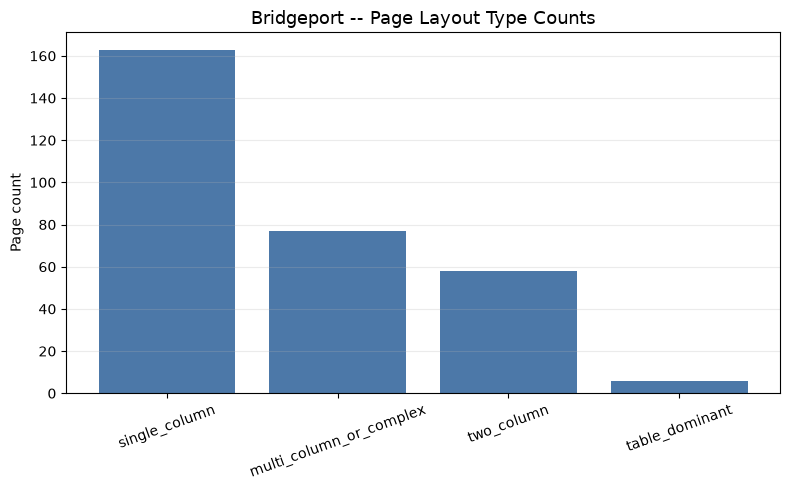

Saved: outputs/figures/bridgeport/step_01_5_layout_type_counts.png


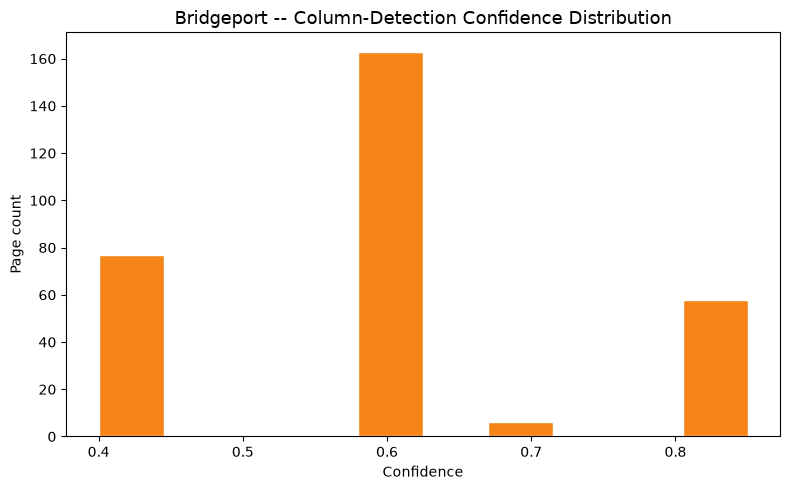

Saved: outputs/figures/bridgeport/step_01_5_column_confidence_distribution.png


In [27]:
layout_detection_path = TABLES_DIR / "step_01_5_page_layout_detection.csv"
page_layout_detection_df.to_csv(layout_detection_path, index=False)
print(f"Saved: {layout_detection_path.relative_to(STAGE_A_ROOT)}")

fig, ax = plt.subplots(figsize=(8, 5))
layout_counts = page_layout_detection_df["page_layout_type"].value_counts()
ax.bar(layout_counts.index, layout_counts.values, color="#4C78A8")
ax.set_title("Bridgeport -- Page Layout Type Counts", fontsize=13)
ax.set_ylabel("Page count")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
layout_counts_path = FIGURES_DIR / "step_01_5_layout_type_counts.png"
fig.savefig(layout_counts_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {layout_counts_path.relative_to(STAGE_A_ROOT)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(page_layout_detection_df["column_detection_confidence"], bins=10, color="#F58518", edgecolor="white")
ax.set_title("Bridgeport -- Column-Detection Confidence Distribution", fontsize=13)
ax.set_xlabel("Confidence")
ax.set_ylabel("Page count")
plt.tight_layout()
confidence_dist_path = FIGURES_DIR / "step_01_5_column_confidence_distribution.png"
fig.savefig(confidence_dist_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {confidence_dist_path.relative_to(STAGE_A_ROOT)}")

### Building the repaired reading order

For `two_column` pages only: top full-width lines (above both columns) first, then the left
column top-to-bottom, then the right column top-to-bottom, then bottom full-width lines (below
both columns). Every other layout type keeps native PyMuPDF order untouched.

In [28]:
all_page_lines_df = pd.concat(page_line_layout_assignments, ignore_index=True)
all_page_lines_df = all_page_lines_df.merge(
    page_layout_detection_df[["page_number", "left_cluster_center", "right_cluster_center"]],
    on="page_number", how="left",
)

repaired_sequences = []

for page_number, page_lines in all_page_lines_df.groupby("page_number"):
    page_lines = page_lines.copy()
    layout_type = page_lines["page_layout_type"].iloc[0]

    if layout_type != "two_column":
        ordered = page_lines.sort_values(["bbox_y0", "bbox_x0"])
        ordered = ordered.assign(
            column_id="n/a", reading_order_repaired=False,
            repaired_sequence_on_page=range(1, len(ordered) + 1),
        )
        repaired_sequences.append(ordered)
        continue

    split_value = (page_lines["left_cluster_center"].iloc[0] + page_lines["right_cluster_center"].iloc[0]) / 2

    full_width_rows = page_lines.loc[page_lines["is_full_width"]].copy()
    column_rows = page_lines.loc[~page_lines["is_full_width"]].copy()
    column_rows["column_id"] = np.where(column_rows["bbox_x0"] < split_value, "left", "right")

    left_rows = column_rows.loc[column_rows["column_id"] == "left"].sort_values("bbox_y0")
    right_rows = column_rows.loc[column_rows["column_id"] == "right"].sort_values("bbox_y0")

    column_min_y = column_rows["bbox_y0"].min() if len(column_rows) else 0
    column_max_y = column_rows["bbox_y1"].max() if len(column_rows) else page_lines["bbox_y1"].max()

    top_full_width = full_width_rows.loc[full_width_rows["bbox_y0"] < column_min_y].sort_values("bbox_y0")
    bottom_full_width = full_width_rows.loc[full_width_rows["bbox_y0"] >= column_min_y].copy()
    # A full-width line that falls inside the column y-range (rare) is
    # conservatively treated as "top" context rather than invented a
    # mid-column split point -- documented simplification, not a blind rule.
    mid_full_width = bottom_full_width.loc[bottom_full_width["bbox_y0"] <= column_max_y]
    bottom_full_width = bottom_full_width.loc[bottom_full_width["bbox_y0"] > column_max_y].sort_values("bbox_y0")
    top_full_width = pd.concat([top_full_width, mid_full_width]).sort_values("bbox_y0")

    top_full_width = top_full_width.assign(column_id="full_width_top")
    bottom_full_width = bottom_full_width.assign(column_id="full_width_bottom")

    ordered = pd.concat([top_full_width, left_rows, right_rows, bottom_full_width], ignore_index=True)
    ordered = ordered.assign(
        reading_order_repaired=True,
        repaired_sequence_on_page=range(1, len(ordered) + 1),
    )
    repaired_sequences.append(ordered)

layout_ordered_lines_df = pd.concat(repaired_sequences, ignore_index=True)

layout_ordered_lines_df["reading_order_review_status"] = layout_ordered_lines_df["page_layout_type"].map(
    lambda layout_type: "manual_review_required" if layout_type in {"multi_column_or_complex", "uncertain"} else "auto_classified"
)

repaired_page_count = int((layout_ordered_lines_df.groupby("page_number")["reading_order_repaired"].first()).sum())
print(f"Pages whose reading order was actually repaired: {repaired_page_count}")
print(f"Pages retained in native order: {PDF_PAGE_COUNT - repaired_page_count}")

Pages whose reading order was actually repaired: 58
Pages retained in native order: 246


### Before/after reading-order samples

In [29]:
def render_page_text_order(page_number: int, order_column: str) -> str:
    page_rows = layout_ordered_lines_df.loc[layout_ordered_lines_df["page_number"] == page_number]
    if order_column == "native":
        page_rows = page_rows.sort_values(["bbox_y0", "bbox_x0"])
    else:
        page_rows = page_rows.sort_values("repaired_sequence_on_page")
    return " / ".join(page_rows["text"].head(14).tolist())


sample_two_column_pages = page_layout_detection_df.loc[
    page_layout_detection_df["page_layout_type"] == "two_column", "page_number"
].tolist()[:5]

sample_single_column_pages = page_layout_detection_df.loc[
    page_layout_detection_df["page_layout_type"] == "single_column", "page_number"
].tolist()[:3]

sample_complex_pages = page_layout_detection_df.loc[
    page_layout_detection_df["page_layout_type"].isin(["multi_column_or_complex", "table_dominant"]), "page_number"
].tolist()[:3]

print("=" * 30, "TWO-COLUMN PAGES (should change)", "=" * 30)
for page_number in sample_two_column_pages:
    print(f"\n--- page {page_number} ---")
    print("NATIVE:  ", render_page_text_order(page_number, "native")[:300])
    print("REPAIRED:", render_page_text_order(page_number, "repaired")[:300])

print("\n" + "=" * 30, "SINGLE-COLUMN PAGES (should NOT change)", "=" * 30)
for page_number in sample_single_column_pages:
    print(f"\n--- page {page_number} ---")
    print("NATIVE:  ", render_page_text_order(page_number, "native")[:300])
    print("REPAIRED:", render_page_text_order(page_number, "repaired")[:300])

print("\n" + "=" * 30, "COMPLEX/TABLE PAGES (should NOT be reordered)", "=" * 30)
for page_number in sample_complex_pages:
    print(f"\n--- page {page_number} ---")
    print("NATIVE:  ", render_page_text_order(page_number, "native")[:300])
    print("REPAIRED:", render_page_text_order(page_number, "repaired")[:300])

============================== TWO-COLUMN PAGES (should change) ==============================

--- page 7 ---
NATIVE:   1.0 Introductory Provisions / 1.20 Zoning Map / the requirement or condition and, therefore, the subject / complies with the regulations of this zoning code. / approval will also be deemed invalid. / (3) The adoption of this zoning code does not affect any / pending or future prosecution of, or acti
REPAIRED: the requirement or condition and, therefore, the subject / approval will also be deemed invalid. / 1.20 / Zoning Map / 1.20.1 / ESTABLISHMENT / The location and boundaries of the zones defined in this / zoning code must be established by code and shown on / the city’s official zoning map, which must

--- page 10 ---
NATIVE:   2.0 Zones / 2.10 Mixed-Use & Commercial Zones / 2.10 / Mixed-Use & Commercial Zones / 2.10.1 / ZONES ESTABLISHED / The city’s mixed-use zones are listed in Table 2-1 . When this / zoning ordinance refers to “mixed-use” zones or “X” zones, i

### Visual overlay -- page 11 (the confirmed problematic page)

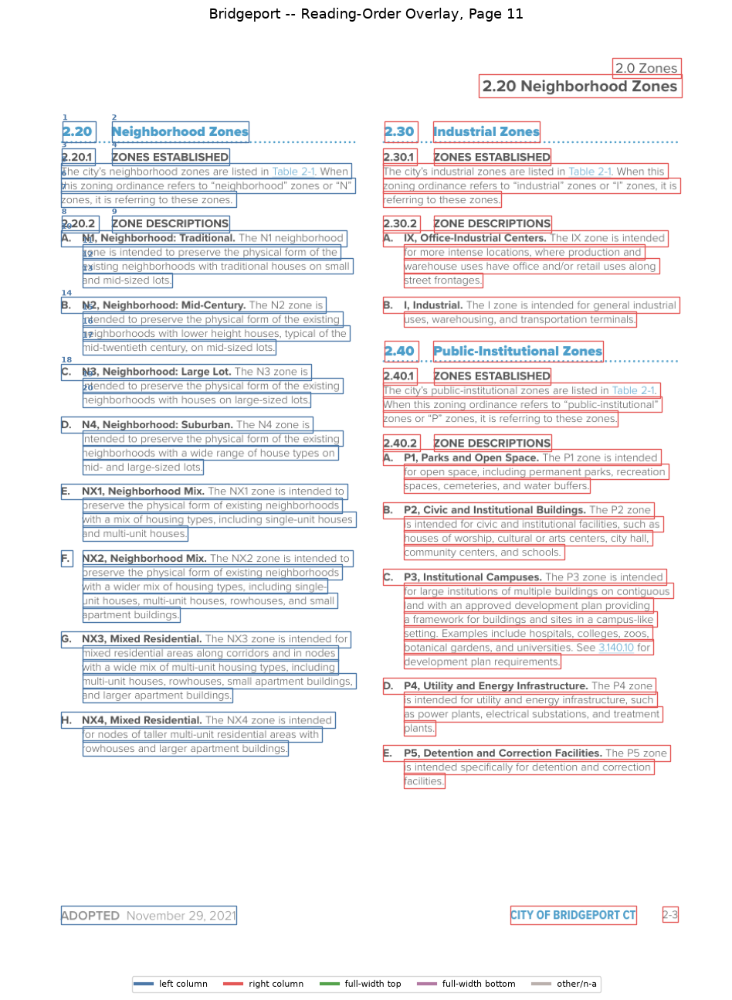

Saved: outputs/figures/bridgeport/step_01_5_page_011_before_after_overlay.png


In [30]:
def plot_layout_overlay(page_number: int, save_name: str) -> Path:
    page_image = render_pdf_page(PDF_PATH, page_number=page_number, zoom=1.5)
    page_rows = layout_ordered_lines_df.loc[layout_ordered_lines_df["page_number"] == page_number].sort_values(
        "repaired_sequence_on_page"
    )

    color_by_column = {
        "left": "#4C78A8", "right": "#E45756",
        "full_width_top": "#54A24B", "full_width_bottom": "#B279A2", "n/a": "#BAB0AC",
    }

    fig, ax = plt.subplots(figsize=(10, 13))
    ax.imshow(page_image)

    for _, row in page_rows.iterrows():
        color = color_by_column.get(row["column_id"], "#F2CF5B")
        rectangle = plt.Rectangle(
            (row["bbox_x0"] * 1.5, row["bbox_y0"] * 1.5),
            (row["bbox_x1"] - row["bbox_x0"]) * 1.5, (row["bbox_y1"] - row["bbox_y0"]) * 1.5,
            linewidth=1.0, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rectangle)

        if row["repaired_sequence_on_page"] <= 20:
            ax.text(
                row["bbox_x0"] * 1.5, row["bbox_y0"] * 1.5 - 2, str(int(row["repaired_sequence_on_page"])),
                color=color, fontsize=7, fontweight="bold",
            )

    legend_handles = [
        plt.Line2D([0], [0], color=color, lw=3, label=label)
        for label, color in [
            ("left column", "#4C78A8"), ("right column", "#E45756"),
            ("full-width top", "#54A24B"), ("full-width bottom", "#B279A2"), ("other/n-a", "#BAB0AC"),
        ]
    ]
    ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=5, fontsize=8)
    ax.set_title(f"Bridgeport -- Reading-Order Overlay, Page {page_number}", fontsize=13)
    ax.axis("off")
    plt.tight_layout()

    save_path = FIGURES_DIR / save_name
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return save_path


page_011_overlay_path = plot_layout_overlay(11, "step_01_5_page_011_before_after_overlay.png")
print(f"Saved: {page_011_overlay_path.relative_to(STAGE_A_ROOT)}")

### Rebuilding the hierarchy from repaired order

Heading classification is unchanged (same function, same patterns) -- only the **order** lines
are fed into the depth-based parent-stack algorithm changes, from `(page_number, bbox_y0,
bbox_x0)` to `(page_number, repaired_sequence_on_page)`. The original Stage 1 hierarchy
(`hierarchy_graph`, `hierarchy_nodes_df`) is left untouched; everything below is saved under new
`_repaired` names.

In [31]:
layout_ordered_lines_df[
    ["node_type", "matched_pattern", "heading_confidence", "classification_reason", "heading_number"]
] = layout_ordered_lines_df.apply(classify_bridgeport_heading, axis=1)

layout_ordered_lines_df["depth"] = layout_ordered_lines_df["node_type"].map(BRIDGEPORT_DEPTH_MAP)

heading_candidates_repaired_raw_df = layout_ordered_lines_df.loc[
    (layout_ordered_lines_df["node_type"] != "Body") & (layout_ordered_lines_df["heading_confidence"] >= 0.55)
].copy()

heading_candidates_repaired_raw_df = heading_candidates_repaired_raw_df.sort_values(
    ["page_number", "repaired_sequence_on_page"]
).reset_index(drop=True)

dedup_candidate_mask = heading_candidates_repaired_raw_df["node_type"].isin(dedup_levels)
first_occurrence_mask = ~heading_candidates_repaired_raw_df.duplicated(subset=["node_type", "heading_number"], keep="first")

heading_candidates_repaired_df = heading_candidates_repaired_raw_df.loc[
    (~dedup_candidate_mask) | first_occurrence_mask
].copy().reset_index(drop=True)

heading_candidates_repaired_df["node_id"] = [
    f"{DOCUMENT_ID}-repaired-node-{index + 1:06d}" for index in range(len(heading_candidates_repaired_df))
]

print(f"Repaired heading candidates: {len(heading_candidates_repaired_df):,} (Stage 1 had {len(heading_candidates_df):,})")
print(heading_candidates_repaired_df["node_type"].value_counts())

Repaired heading candidates: 1,940 (Stage 1 had 1,940)
node_type
Paragraph     1639
Subsection     168
Section        118
Title           15
Name: count, dtype: int64


In [32]:
root_node_id_repaired = f"{DOCUMENT_ID}-repaired-root"

hierarchy_graph_repaired = nx.DiGraph()
hierarchy_graph_repaired.add_node(
    root_node_id_repaired, node_type="Document", depth=0, text="City of Bridgeport Zoning Code", page_number=0,
)

node_stack_repaired = [(root_node_id_repaired, 0)]

for _, heading in heading_candidates_repaired_df.iterrows():
    node_id = heading["node_id"]
    node_depth = int(heading["depth"])

    while node_stack_repaired and node_stack_repaired[-1][1] >= node_depth:
        node_stack_repaired.pop()

    parent_node_id = node_stack_repaired[-1][0] if node_stack_repaired else root_node_id_repaired

    hierarchy_graph_repaired.add_node(
        node_id, node_type=heading["node_type"], depth=node_depth, text=heading["text"],
        page_number=int(heading["page_number"]), heading_confidence=float(heading["heading_confidence"]),
    )
    hierarchy_graph_repaired.add_edge(parent_node_id, node_id)
    node_stack_repaired.append((node_id, node_depth))

node_records_repaired = []
for node_id, attributes in hierarchy_graph_repaired.nodes(data=True):
    parents = list(hierarchy_graph_repaired.predecessors(node_id))
    node_records_repaired.append(
        {
            "node_id": node_id, "parent_node_id": parents[0] if parents else pd.NA,
            "node_type": attributes["node_type"], "depth": attributes["depth"],
            "text": attributes["text"], "page_number": attributes["page_number"],
        }
    )

hierarchy_nodes_repaired_df = pd.DataFrame(node_records_repaired)

print(f"Repaired hierarchy nodes: {hierarchy_graph_repaired.number_of_nodes():,} (Stage 1 had {hierarchy_graph.number_of_nodes():,})")
print(f"Repaired hierarchy edges: {hierarchy_graph_repaired.number_of_edges():,}")

Repaired hierarchy nodes: 1,941 (Stage 1 had 1,941)
Repaired hierarchy edges: 1,940


In [33]:
non_root_repaired = [n for n in hierarchy_graph_repaired.nodes if n != root_node_id_repaired]
orphan_repaired = [n for n in non_root_repaired if hierarchy_graph_repaired.in_degree(n) != 1]
is_acyclic_repaired = nx.is_directed_acyclic_graph(hierarchy_graph_repaired)
is_connected_repaired = nx.is_weakly_connected(hierarchy_graph_repaired)

misordered_repaired = [
    (p, c) for p, c in hierarchy_graph_repaired.edges
    if hierarchy_graph_repaired.nodes[p]["depth"] >= hierarchy_graph_repaired.nodes[c]["depth"]
]

validation_results_repaired_df = pd.DataFrame(
    [
        {"validation_rule": "exactly_one_root_with_in_degree_zero", "passed": hierarchy_graph_repaired.in_degree(root_node_id_repaired) == 0},
        {"validation_rule": "every_non_root_node_has_exactly_one_parent", "passed": len(orphan_repaired) == 0},
        {"validation_rule": "directed_graph_is_acyclic", "passed": is_acyclic_repaired},
        {"validation_rule": "graph_is_weakly_connected", "passed": is_connected_repaired},
        {"validation_rule": "parent_depth_strictly_less_than_child_depth", "passed": len(misordered_repaired) == 0},
    ]
)

print(validation_results_repaired_df)
print(f"\nAll repaired-hierarchy checks passed: {bool(validation_results_repaired_df['passed'].all())}")

                               validation_rule  passed
0         exactly_one_root_with_in_degree_zero    True
1   every_non_root_node_has_exactly_one_parent    True
2                    directed_graph_is_acyclic    True
3                    graph_is_weakly_connected    True
4  parent_depth_strictly_less_than_child_depth    True

All repaired-hierarchy checks passed: True


### Hierarchy comparison: original vs. repaired

In [34]:
original_type_counts = heading_candidates_df["node_type"].value_counts()
repaired_type_counts = heading_candidates_repaired_df["node_type"].value_counts()

hierarchy_change_summary_df = pd.DataFrame(
    {"original_count": original_type_counts, "repaired_count": repaired_type_counts}
).fillna(0).astype(int)
hierarchy_change_summary_df["difference"] = (
    hierarchy_change_summary_df["repaired_count"] - hierarchy_change_summary_df["original_count"]
)

print(hierarchy_change_summary_df)

# Match nodes between original and repaired trees by (node_type, heading_number)
# to detect whether a node's PARENT section changed after the repair.
original_by_number = heading_candidates_df.set_index(["node_type", "heading_number"])["node_id"].to_dict() if "heading_number" in heading_candidates_df.columns else {}
repaired_by_number = heading_candidates_repaired_df.set_index(["node_type", "heading_number"])["node_id"].to_dict()

parent_change_records = []
for (node_type, number), repaired_node_id in repaired_by_number.items():
    if not number or node_type == "Paragraph":
        continue
    original_node_id = original_by_number.get((node_type, number))
    if original_node_id is None:
        continue

    original_parent = hierarchy_nodes_df.loc[hierarchy_nodes_df["node_id"] == original_node_id, "parent_node_id"]
    repaired_parent = hierarchy_nodes_repaired_df.loc[hierarchy_nodes_repaired_df["node_id"] == repaired_node_id, "parent_node_id"]

    original_parent_text = hierarchy_nodes_df.loc[hierarchy_nodes_df["node_id"] == original_parent.iloc[0], "text"] if len(original_parent) and pd.notna(original_parent.iloc[0]) else pd.Series([None])
    repaired_parent_text = hierarchy_nodes_repaired_df.loc[hierarchy_nodes_repaired_df["node_id"] == repaired_parent.iloc[0], "text"] if len(repaired_parent) and pd.notna(repaired_parent.iloc[0]) else pd.Series([None])

    original_parent_text_value = original_parent_text.iloc[0] if len(original_parent_text) else None
    repaired_parent_text_value = repaired_parent_text.iloc[0] if len(repaired_parent_text) else None

    if original_parent_text_value != repaired_parent_text_value:
        parent_change_records.append(
            {
                "heading_number": number, "node_type": node_type,
                "original_parent_text": original_parent_text_value,
                "repaired_parent_text": repaired_parent_text_value,
            }
        )

parent_change_df = pd.DataFrame(parent_change_records)
print(f"\nNodes whose parent section changed after repair: {len(parent_change_df)}")
if len(parent_change_df):
    print(parent_change_df.head(20).to_string(index=False))

            original_count  repaired_count  difference
node_type                                             
Paragraph             1639            1639           0
Subsection             168             168           0
Section                118             118           0
Title                   15              15           0



Nodes whose parent section changed after repair: 6
heading_number  node_type                         original_parent_text     repaired_parent_text
       12.20.2 Subsection 12.30 Violations, Penalties, and Enforcement   12.20 Fees and Charges
       13.30.3 Subsection               13.40 Nonconforming Structures 13.30 Nonconforming Uses
       13.30.4 Subsection               13.40 Nonconforming Structures 13.30 Nonconforming Uses
       13.30.5 Subsection               13.40 Nonconforming Structures 13.30 Nonconforming Uses
       13.30.6 Subsection               13.40 Nonconforming Structures 13.30 Nonconforming Uses
       13.30.8 Subsection               13.40 Nonconforming Structures 13.30 Nonconforming Uses


In [35]:
reading_order_comparison_path = TABLES_DIR / "step_01_5_reading_order_comparison.csv"
hierarchy_change_summary_path = TABLES_DIR / "step_01_5_hierarchy_change_summary.csv"

comparison_rows = []
for page_number in sample_two_column_pages + sample_single_column_pages + sample_complex_pages:
    comparison_rows.append(
        {
            "page_number": page_number,
            "layout_type": page_layout_detection_df.loc[page_layout_detection_df["page_number"] == page_number, "page_layout_type"].iloc[0],
            "native_order_preview": render_page_text_order(page_number, "native")[:400],
            "repaired_order_preview": render_page_text_order(page_number, "repaired")[:400],
        }
    )

pd.DataFrame(comparison_rows).to_csv(reading_order_comparison_path, index=False)
hierarchy_change_summary_df.to_csv(hierarchy_change_summary_path, index=True)
parent_change_df.to_csv(TABLES_DIR / "step_01_5_parent_change_detail.csv", index=False)

print(f"Saved: {reading_order_comparison_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {hierarchy_change_summary_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/tables/bridgeport/step_01_5_reading_order_comparison.csv
Saved: outputs/tables/bridgeport/step_01_5_hierarchy_change_summary.csv


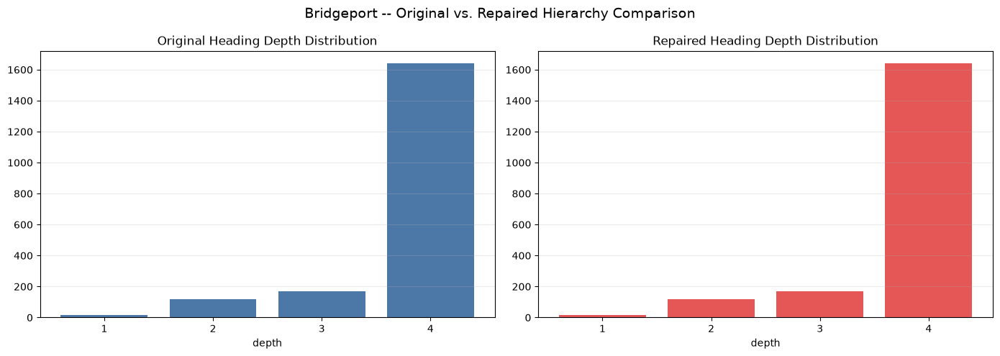

Saved: outputs/figures/bridgeport/step_01_5_repaired_hierarchy_comparison.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_, label in [(axes[0], heading_candidates_df, "Original"), (axes[1], heading_candidates_repaired_df, "Repaired")]:
    depth_counts = df_["depth"].value_counts().sort_index()
    ax.bar(depth_counts.index.astype(str), depth_counts.values, color="#4C78A8" if label == "Original" else "#E45756")
    ax.set_title(f"{label} Heading Depth Distribution")
    ax.set_xlabel("depth")
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("Bridgeport -- Original vs. Repaired Hierarchy Comparison", fontsize=14)
plt.tight_layout()
repaired_comparison_path = FIGURES_DIR / "step_01_5_repaired_hierarchy_comparison.png"
fig.savefig(repaired_comparison_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {repaired_comparison_path.relative_to(STAGE_A_ROOT)}")

### Manual semantic inspection

The actual acceptance test: does the repaired outline for page 11 now group all `Neighborhood
Zone` paragraphs together, before the unrelated `Industrial/Civic/Park` content -- rather than
interleaving them?

In [37]:
print("=" * 30, "PAGE 11 -- REPAIRED ORDER (acceptance test)", "=" * 30)
page_011_repaired = layout_ordered_lines_df.loc[
    (layout_ordered_lines_df["page_number"] == 11) & (layout_ordered_lines_df["node_type"] != "Body")
].sort_values("repaired_sequence_on_page")

for _, row in page_011_repaired.iterrows():
    print(f"[{row['column_id']:>16}] seq={int(row['repaired_sequence_on_page']):>3}  {row['text'][:90]}")

============================== PAGE 11 -- REPAIRED ORDER (acceptance test) ==============================
[            left] seq= 10  A. N1, Neighborhood: Traditional. The N1 neighborhood
[            left] seq= 14  B. N2, Neighborhood: Mid-Century. The N2 zone is
[            left] seq= 18  C. N3, Neighborhood: Large Lot. The N3 zone is
[            left] seq= 21  D. N4, Neighborhood: Suburban. The N4 zone is
[            left] seq= 25  E. NX1, Neighborhood Mix. The NX1 zone is intended to
[            left] seq= 35  G. NX3, Mixed Residential. The NX3 zone is intended for
[            left] seq= 40  H. NX4, Mixed Residential. The NX4 zone is intended
[           right] seq= 44  2.0 Zones
[           right] seq= 45  2.20 Neighborhood Zones
[           right] seq= 55  A. IX, Office-Industrial Centers. The IX zone is intended
[           right] seq= 59  B. I, Industrial. The I zone is intended for general industrial
[           right] seq= 70  A. P1, Parks and Open Space. The P1 zone is 

In [38]:
additional_two_column_checks = sample_two_column_pages[1:5]

print("=" * 30, "ADDITIONAL TWO-COLUMN PAGES -- REPAIRED ORDER SPOT CHECK", "=" * 30)
for page_number in additional_two_column_checks:
    print(f"\n--- page {page_number} ---")
    rows = layout_ordered_lines_df.loc[
        (layout_ordered_lines_df["page_number"] == page_number) & (layout_ordered_lines_df["node_type"] != "Body")
    ].sort_values("repaired_sequence_on_page")
    for _, row in rows.head(10).iterrows():
        print(f"  [{row['column_id']:>16}] {row['text'][:80]}")

print("\n" + "=" * 30, "TABLE/COMPLEX PAGES -- CONFIRM NOT REORDERED", "=" * 30)
for page_number in sample_complex_pages:
    native_order = render_page_text_order(page_number, "native")
    repaired_order = render_page_text_order(page_number, "repaired")
    print(f"\n--- page {page_number} ---")
    print(f"unchanged: {native_order == repaired_order}")

============================== ADDITIONAL TWO-COLUMN PAGES -- REPAIRED ORDER SPOT CHECK ==============================

--- page 10 ---
  [            left] 2.0 Zones
  [            left] 2.10 Mixed-Use & Commercial Zones
  [            left] A. DX1, Downtown Core. The DX1 zone is intended for
  [            left] B. DX2, Downtown Support. The DX2 zone is intended
  [            left] C. MX1, Mixed-Use Corridor. The MX1 zone is intended
  [            left] D. MX2, Mixed-Use Centers. The MX2 zone is intended
  [            left] E. MXN, Mixed-Use Neighborhood Corners. The MXN
  [            left] G. RX2, Residential-Office Centers. The RX2 zone is
  [            left] H. CX, Heavy Commercial. The CX zone is intended

--- page 11 ---
  [            left] A. N1, Neighborhood: Traditional. The N1 neighborhood
  [            left] B. N2, Neighborhood: Mid-Century. The N2 zone is
  [            left] C. N3, Neighborhood: Large Lot. The N3 zone is
  [            left] D. N4, Neighborhood: Su

### Save repaired artifacts and final Stage 1.5 report

In [39]:
layout_ordered_tokens_path = INTERIM_DIR / "step_01_5_layout_ordered_tokens.parquet"
repaired_hierarchy_nodes_path = INTERIM_DIR / "step_01_5_repaired_hierarchy_nodes.parquet"
complex_review_queue_path = REVIEW_DIR / "step_01_5_complex_layout_review_queue.csv"

layout_ordered_lines_df.to_parquet(layout_ordered_tokens_path, index=False)
hierarchy_nodes_repaired_df.to_parquet(repaired_hierarchy_nodes_path, index=False)

complex_review_queue_df = page_layout_detection_df.loc[
    page_layout_detection_df["reading_order_review_status"] == "manual_review_required"
]
complex_review_queue_df.to_csv(complex_review_queue_path, index=False)

print(f"Saved: {layout_ordered_tokens_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {repaired_hierarchy_nodes_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {complex_review_queue_path.relative_to(STAGE_A_ROOT)}")

Saved: data/interim/bridgeport/step_01_5_layout_ordered_tokens.parquet
Saved: data/interim/bridgeport/step_01_5_repaired_hierarchy_nodes.parquet
Saved: outputs/review/bridgeport/step_01_5_complex_layout_review_queue.csv


In [40]:
page_011_text_check = render_page_text_order(11, "repaired")
page_011_fixed = "N1" in page_011_text_check.split(" / ")[0:6][0] or any(
    "N1" in part or "Neighborhood" in part for part in page_011_text_check.split(" / ")[:3]
)

stage_1_5_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "layout_type_counts": page_layout_detection_df["page_layout_type"].value_counts().to_dict(),
    "pages_repaired": repaired_page_count,
    "pages_retained_native_order": PDF_PAGE_COUNT - repaired_page_count,
    "pages_requiring_manual_review": int(len(complex_review_queue_df)),
    "page_011_fixed": bool(page_011_fixed),
    "repaired_hierarchy_validation_all_passed": bool(validation_results_repaired_df["passed"].all()),
    "nodes_with_changed_parent": int(len(parent_change_df)),
    "nodes_with_changed_parent_share_of_sections_and_subsections": (
        len(parent_change_df) / max(len(repaired_by_number), 1)
    ),
    "original_heading_count": int(len(heading_candidates_df)),
    "repaired_heading_count": int(len(heading_candidates_repaired_df)),
}

stage_1_5_log_path = LOGS_DIR / "step_01_5_reading_order_repair_log.json"
with stage_1_5_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_1_5_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 1.5 (reading-order repair) COMPLETE")
print("=" * 70)
for key, value in stage_1_5_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_1_5_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 1.5 (reading-order repair) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
layout_type_counts: {'single_column': 163, 'multi_column_or_complex': 77, 'two_column': 58, 'table_dominant': 6}
pages_repaired: 58
pages_retained_native_order: 246
pages_requiring_manual_review: 77
page_011_fixed: True
repaired_hierarchy_validation_all_passed: True
nodes_with_changed_parent: 6
nodes_with_changed_parent_share_of_sections_and_subsections: 0.019867549668874173
original_heading_count: 1940
repaired_heading_count: 1940

Saved: outputs/logs/bridgeport/step_01_5_reading_order_repair_log.json


## 11. Stage 2 -- Table parsing, validation, and table-type classification

Bridgeport Stage 1.5 is complete: reading order is repaired for confidently-detected two-column
pages, and 77 ambiguous pages are explicitly queued for review rather than guessed at. This stage
builds on that -- table parsing, table validation, and Bridgeport-specific table-type
classification -- and stops there. District-anchor detection, citation extraction, GIS linking,
evidence-bundle assembly, Phase 2 rule extraction, and any Greenwich comparison are **not**
started in this stage.

**Visual-first rule for this stage**: every major table-processing decision below produces (1) a
machine-readable table/data output, (2) a human-inspectable visual or rendered evidence preview,
and (3) a review-status or confidence field. A successful dataframe extraction is never treated
as proof a table was parsed correctly -- that is only established by actually looking at a
rendered crop of the source page next to the extracted matrix.

Bridgeport is a form-based code (confirmed in Stage 1: Chapter 3 is "Site & Building Types",
Chapter 4 is "Uses"), not a Euclidean dimensional-table code like Greenwich. No Greenwich header,
row-label, district-code, or column mapping is reused here -- table-type signals are built fresh
from Bridgeport's own extracted text.

### 11.1 Table detection

For every page, table detection cascades through three PyMuPDF `find_tables()` strategies, from
most to least precise, and uses the **first** strategy that finds at least one table on that
page: `lines_strict` -> `lines` -> `text`. This keeps the same table from being detected two or
three times under different strategies, at the cost of a documented limitation: a second, weaker
table lower on a page where a stronger strategy already found one table is not separately
re-scanned (see the limitations note in the final report).

Weak candidates are not discarded -- every detected table, including ones below the retention
threshold, is kept in the raw inventory with its full raw extraction matrix, so nothing is
silently dropped before a human can look at it.

One additional, empirically-discovered filter: the `text` strategy (the weakest tier) sometimes
detects an entire prose page -- including a genuine two-column page from Stage 1.5 -- as one
giant false-positive "table" spanning nearly the full page height and width. Directly inspecting
three such hits (pages 3, 6, 11) confirmed this: each spans >90% of the page in both dimensions,
and page 11 in particular is the confirmed two-column prose page from Stage 1.5, not a table at
all. Any `text`-strategy detection whose bbox covers >=55% of both page width and height gets a
steep confidence penalty and is excluded from retention.

In [41]:
TABLE_DETECTION_STRATEGIES = ["lines_strict", "lines", "text"]
TABLE_STRATEGY_BASE_CONFIDENCE = {"lines_strict": 0.85, "lines": 0.65, "text": 0.35}

layout_lookup_full = page_layout_detection_df.set_index("page_number")

raw_table_records = []
table_raw_matrices: dict[str, list] = {}
table_header_info: dict[str, dict] = {}

with fitz.open(PDF_PATH) as pdf_document:
    for page_index in range(pdf_document.page_count):
        page_number = page_index + 1
        page = pdf_document.load_page(page_index)
        page_width, page_height = page.rect.width, page.rect.height

        layout_row = layout_lookup_full.loc[page_number] if page_number in layout_lookup_full.index else None
        page_layout_type = layout_row["page_layout_type"] if layout_row is not None else "single_column"
        in_complex_queue = page_layout_type == "multi_column_or_complex"
        is_table_dominant_page = page_layout_type == "table_dominant"

        detected_tables = []
        strategy_used = None
        for strategy in TABLE_DETECTION_STRATEGIES:
            try:
                found = page.find_tables(strategy=strategy)
            except Exception:
                found = None
            if found is not None and len(found.tables) > 0:
                detected_tables = list(found.tables)
                strategy_used = strategy
                break

        for table_index, table in enumerate(detected_tables):
            table_id = f"{DOCUMENT_ID}-table-{page_number:03d}-{table_index:02d}"
            try:
                matrix = table.extract()
            except Exception:
                matrix = []

            row_count = table.row_count
            col_count = table.col_count
            nonempty_cell_count = sum(1 for row in matrix for cell in row if cell is not None and str(cell).strip())
            total_cell_count = sum(len(row) for row in matrix)

            bbox = tuple(table.bbox)
            bbox_width = bbox[2] - bbox[0]
            bbox_height = bbox[3] - bbox[1]
            whole_page_span = bbox_width >= 0.55 * page_width and bbox_height >= 0.55 * page_height

            base_confidence = TABLE_STRATEGY_BASE_CONFIDENCE[strategy_used]
            confidence = base_confidence * (0.3 if (strategy_used == "text" and whole_page_span) else 1.0)

            try:
                header_names = list(table.header.names)
            except Exception:
                header_names = []
            try:
                header_external = bool(table.header.external)
            except Exception:
                header_external = False
            try:
                header_bbox = tuple(table.header.bbox) if table.header.bbox else None
            except Exception:
                header_bbox = None

            table_raw_matrices[table_id] = matrix
            table_header_info[table_id] = {
                "header_names": header_names, "header_external": header_external, "header_bbox": header_bbox,
            }

            is_retained = (
                row_count >= 2 and col_count >= 2 and nonempty_cell_count >= 3
                and confidence >= 0.5 and not whole_page_span
            )
            rejection_reason = "" if is_retained else (
                "whole_page_span_likely_false_positive" if whole_page_span else "degenerate_shape_or_low_confidence"
            )

            if not is_retained:
                review_status = "weak_or_rejected"
            elif in_complex_queue:
                review_status = "retained_complex_layout_review"
            elif confidence < 0.7:
                review_status = "retained_low_confidence_review"
            else:
                review_status = "retained_auto"

            raw_table_records.append({
                "document_id": DOCUMENT_ID, "table_id": table_id, "page_number": page_number,
                "candidate_table_index_on_page": table_index, "detection_strategy": strategy_used,
                "bbox_x0": bbox[0], "bbox_y0": bbox[1], "bbox_x1": bbox[2], "bbox_y1": bbox[3],
                "row_count": row_count, "col_count": col_count,
                "nonempty_cell_count": nonempty_cell_count, "total_cell_count": total_cell_count,
                "nonempty_cell_ratio": round(nonempty_cell_count / total_cell_count, 3) if total_cell_count else 0.0,
                "whole_page_span_flag": whole_page_span,
                "initial_confidence": round(confidence, 3),
                "page_layout_type": page_layout_type,
                "complex_layout_context": in_complex_queue,
                "table_dominant_page": is_table_dominant_page,
                "is_retained": is_retained,
                "rejection_reason": rejection_reason,
                "review_status": review_status,
                "header_names_json": json.dumps(header_names),
                "header_external": header_external,
                "header_bbox_json": json.dumps(header_bbox),
                "raw_extraction_matrix_json": json.dumps(matrix, default=str),
            })

raw_table_candidates_df = pd.DataFrame(raw_table_records)
print(f"Total detected table candidates: {len(raw_table_candidates_df):,}")
print(raw_table_candidates_df["detection_strategy"].value_counts())
print(f"Retained: {int(raw_table_candidates_df['is_retained'].sum())}  "
      f"Weak/rejected: {int((~raw_table_candidates_df['is_retained']).sum())}")

Total detected table candidates: 392
detection_strategy
lines_strict    188
text            147
lines            57
Name: count, dtype: int64
Retained: 107  Weak/rejected: 285


In [42]:
retained_table_ids = raw_table_candidates_df.loc[raw_table_candidates_df["is_retained"], "table_id"].tolist()
retained_lookup = raw_table_candidates_df.set_index("table_id")

full_page_index_df = pd.DataFrame({"page_number": range(1, PDF_PAGE_COUNT + 1)})
page_table_detection_summary_df = (
    raw_table_candidates_df.groupby("page_number")
    .agg(tables_detected=("table_id", "count"), tables_retained=("is_retained", "sum"))
    .reset_index()
)
page_table_detection_summary_df = full_page_index_df.merge(page_table_detection_summary_df, on="page_number", how="left")
page_table_detection_summary_df[["tables_detected", "tables_retained"]] = (
    page_table_detection_summary_df[["tables_detected", "tables_retained"]].fillna(0).astype(int)
)
page_table_detection_summary_df["page_layout_type"] = page_table_detection_summary_df["page_number"].map(
    layout_lookup_full["page_layout_type"]
)

page_table_detection_summary_path = TABLES_DIR / "step_02_table_detection_by_page.csv"
page_table_detection_summary_df.to_csv(page_table_detection_summary_path, index=False)

table_inventory_df = raw_table_candidates_df.drop(
    columns=["header_names_json", "header_bbox_json", "raw_extraction_matrix_json"]
)
table_inventory_path = TABLES_DIR / "step_02_table_inventory.csv"
table_inventory_df.to_csv(table_inventory_path, index=False)

raw_table_candidates_path = INTERIM_DIR / "step_02_raw_table_candidates.parquet"
raw_table_candidates_df.to_parquet(raw_table_candidates_path, index=False)

weak_table_candidates_df = raw_table_candidates_df.loc[~raw_table_candidates_df["is_retained"]].copy()
weak_table_candidates_df["raw_first_row_preview"] = weak_table_candidates_df["table_id"].map(
    lambda tid: str(table_raw_matrices[tid][0])[:160] if table_raw_matrices.get(tid) else ""
)
weak_table_candidates_df = weak_table_candidates_df.drop(
    columns=["header_names_json", "header_bbox_json", "raw_extraction_matrix_json"]
)
weak_table_candidates_path = REVIEW_DIR / "step_02_weak_table_candidates.csv"
weak_table_candidates_df.to_csv(weak_table_candidates_path, index=False)

print(f"Saved: {page_table_detection_summary_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {table_inventory_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {raw_table_candidates_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {weak_table_candidates_path.relative_to(STAGE_A_ROOT)}")
print(f"\nWeak/rejected candidates by reason:")
print(weak_table_candidates_df["rejection_reason"].value_counts())

Saved: outputs/tables/bridgeport/step_02_table_detection_by_page.csv
Saved: outputs/tables/bridgeport/step_02_table_inventory.csv
Saved: data/interim/bridgeport/step_02_raw_table_candidates.parquet
Saved: outputs/review/bridgeport/step_02_weak_table_candidates.csv

Weak/rejected candidates by reason:
rejection_reason
whole_page_span_likely_false_positive    150
degenerate_shape_or_low_confidence       135
Name: count, dtype: int64


### 11.2 Table extraction and structural representation

For each **retained** table, every cell becomes one row in a long-form dataset -- raw value,
cleaned value, row/column index, row label (column 0 of that row), column label (from PyMuPDF's
own detected header, when present), header-row flag, and both cell- and table-level confidence.
Blank, merged, or uncertain headers are preserved as blank rather than invented: `column_label`
is only ever populated from PyMuPDF's own `table.header.names`, never guessed from content.

In [43]:
table_cell_records = []

for table_id in retained_table_ids:
    matrix = table_raw_matrices[table_id]
    meta = retained_lookup.loc[table_id]
    header_info = table_header_info[table_id]
    header_names = header_info["header_names"]

    for row_index, row in enumerate(matrix):
        row_label_raw = row[0] if len(row) > 0 else None
        row_label_clean = "" if row_label_raw is None else re.sub(r"\s+", " ", str(row_label_raw)).strip()

        for column_index, raw_value in enumerate(row):
            clean_value = "" if raw_value is None else re.sub(r"\s+", " ", str(raw_value)).strip()
            column_label = header_names[column_index] if header_names and column_index < len(header_names) else ""

            table_cell_records.append({
                "document_id": DOCUMENT_ID, "table_id": table_id, "page_number": int(meta["page_number"]),
                "table_title_candidate": "",
                "table_bbox_x0": meta["bbox_x0"], "table_bbox_y0": meta["bbox_y0"],
                "table_bbox_x1": meta["bbox_x1"], "table_bbox_y1": meta["bbox_y1"],
                "row_index": row_index, "column_index": column_index,
                "raw_cell_value": "" if raw_value is None else str(raw_value),
                "clean_cell_value": clean_value,
                "row_label": row_label_clean,
                "column_label": column_label if column_label else "",
                "is_header_row": row_index == 0,
                "is_row_label_column": column_index == 0,
                "cell_confidence": round(float(meta["initial_confidence"]) * (0.5 if clean_value == "" else 1.0), 3),
                "table_confidence": float(meta["initial_confidence"]),
                "layout_type": meta["page_layout_type"],
                "review_status": meta["review_status"],
            })

table_cells_df = pd.DataFrame(table_cell_records)
print(f"Table cell records (retained tables only): {len(table_cells_df):,} across {len(retained_table_ids)} tables")

Table cell records (retained tables only): 6,725 across 107 tables


### 11.3 Table title association

A title is associated only when structurally supported: the nearest preceding Title/Section/
Subsection/Paragraph heading, matched **within the same reading-order column** on two-column
pages (reusing Stage 1.5's `left_cluster_center`/`right_cluster_center` split), falling back to
same-page-any-column, and finally to the last heading on an earlier page if nothing precedes the
table on its own page. Confidence drops with vertical distance and is explicitly capped for any
table on one of the 77 complex-layout-queue pages, consistent with the Stage 2 review policy.

In [44]:
def determine_column_id(bbox_x0: float, layout_row) -> str:
    if layout_row is None or layout_row["page_layout_type"] != "two_column":
        return "n/a"
    left_center, right_center = layout_row["left_cluster_center"], layout_row["right_cluster_center"]
    if pd.isna(left_center) or pd.isna(right_center):
        return "n/a"
    split_value = (left_center + right_center) / 2
    return "left" if bbox_x0 < split_value else "right"


heading_candidates_repaired_df["column_id_for_title_match"] = heading_candidates_repaired_df.apply(
    lambda row: determine_column_id(
        row["bbox_x0"], layout_lookup_full.loc[row["page_number"]] if row["page_number"] in layout_lookup_full.index else None
    ),
    axis=1,
)
heading_order_lookup = heading_candidates_repaired_df.reset_index(drop=True)

title_association_records = []
for table_id in retained_table_ids:
    meta = retained_lookup.loc[table_id]
    page_number = int(meta["page_number"])
    layout_row = layout_lookup_full.loc[page_number] if page_number in layout_lookup_full.index else None
    table_column_id = determine_column_id(meta["bbox_x0"], layout_row)
    is_complex_layout_page = bool(meta["complex_layout_context"])

    same_page_headings = heading_order_lookup.loc[heading_order_lookup["page_number"] == page_number]
    candidate_heading, association_confidence, association_rationale = None, 0.0, ""

    if table_column_id != "n/a":
        column_matched = same_page_headings.loc[
            (same_page_headings["column_id_for_title_match"] == table_column_id)
            & (same_page_headings["bbox_y0"] < meta["bbox_y0"])
        ]
        if len(column_matched):
            candidate_heading = column_matched.sort_values("bbox_y0").iloc[-1]
            dy = meta["bbox_y0"] - candidate_heading["bbox_y0"]
            association_confidence = 0.9 if dy < 150 else 0.7
            association_rationale = f"nearest_preceding_heading_in_same_column (dy={dy:.0f}pt)"
    else:
        same_page_above = same_page_headings.loc[same_page_headings["bbox_y0"] < meta["bbox_y0"]]
        if len(same_page_above):
            candidate_heading = same_page_above.sort_values("bbox_y0").iloc[-1]
            dy = meta["bbox_y0"] - candidate_heading["bbox_y0"]
            association_confidence = 0.9 if dy < 150 else 0.7
            association_rationale = f"nearest_preceding_heading_same_page (dy={dy:.0f}pt)"

    if candidate_heading is None:
        earlier = heading_order_lookup.loc[heading_order_lookup["page_number"] < page_number]
        if len(earlier):
            candidate_heading = earlier.iloc[-1]
            association_confidence = 0.4
            association_rationale = "fallback_last_heading_on_earlier_page"

    if is_complex_layout_page and association_confidence > 0.5:
        association_confidence = 0.5
        association_rationale += "; capped_due_to_complex_layout_page"

    vertical_distance = (
        None if candidate_heading is None or association_rationale.startswith("fallback")
        else float(meta["bbox_y0"] - candidate_heading["bbox_y0"])
    )

    title_association_records.append({
        "document_id": DOCUMENT_ID, "table_id": table_id, "page_number": page_number,
        "title_candidate_text": "" if candidate_heading is None else candidate_heading["text"],
        "title_node_id": "" if candidate_heading is None else candidate_heading["node_id"],
        "title_node_type": "" if candidate_heading is None else candidate_heading["node_type"],
        "vertical_distance_points": vertical_distance,
        "association_confidence": round(association_confidence, 3),
        "association_rationale": association_rationale if association_rationale else "no_preceding_heading_found",
        "title_association_review_status": "needs_review" if association_confidence < 0.7 else "auto_associated",
    })

table_title_associations_df = pd.DataFrame(title_association_records)
title_lookup = table_title_associations_df.set_index("table_id")["title_candidate_text"]
table_cells_df["table_title_candidate"] = table_cells_df["table_id"].map(title_lookup).fillna("")

table_title_associations_path = TABLES_DIR / "step_02_table_title_associations.csv"
table_title_associations_df.to_csv(table_title_associations_path, index=False)

table_cells_path = INTERIM_DIR / "step_02_table_cells.parquet"
table_cells_df.to_parquet(table_cells_path, index=False)

print(f"Saved: {table_title_associations_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {table_cells_path.relative_to(STAGE_A_ROOT)}")
print(table_title_associations_df["association_confidence"].describe())

Saved: outputs/tables/bridgeport/step_02_table_title_associations.csv
Saved: data/interim/bridgeport/step_02_table_cells.parquet
count    107.000000
mean       0.501869
std        0.176433
min        0.400000
25%        0.400000
50%        0.400000
75%        0.500000
max        0.900000
Name: association_confidence, dtype: float64


### 11.4 Table-type candidate classification

Each retained table is classified as a **candidate** type only, using keyword signals drawn from
Bridgeport's own form-based vocabulary -- never from Greenwich's dimensional-table terms. Ties
and zero-signal cases fall to `other_or_unknown` rather than a forced guess.

In [45]:
TABLE_TYPE_KEYWORD_SIGNALS = {
    "dimensional_schedule_candidate": [
        "setback", "lot width", "lot area", "lot coverage", "yard", "minimum lot",
        "maximum height", "dimensional standard", "floor area ratio", "far",
    ],
    "building_form_table_candidate": [
        "building type", "site type", "frontage", "build-to", "principal building",
        "facade", "entrance", "form standard", "accessory building",
    ],
    "permitted_use_table_candidate": [
        "permitted", "special permit", "prohibited", "use table", "accessory use",
        "principal use", "p =", "s =", "sp =", "use category",
    ],
    "parking_schedule_candidate": [
        "parking", "mobility", "bicycle", "loading", "space per", "parking ratio", "vehicle",
    ],
    "approval_process_table_candidate": [
        "approval", "administrative", "review process", "public hearing",
        "site plan review", "zoning board", "planning commission", "permit process",
    ],
    "definitions_table_candidate": ["definition", "shall mean", "means:", "glossary", "term used"],
    "district_taxonomy_table_candidate": [
        "district", "neighborhood zone", "mixed-use zone", "zoning district", "zone list",
    ],
    "overlay_or_historic_table_candidate": [
        "overlay", "historic", "design district", "flood", "waterfront", "conservation district",
    ],
    "code_reference_table_candidate": ["see section", "cross-reference", "table of contents", "appendix", "see table"],
}

table_type_records = []
for table_id in retained_table_ids:
    matrix = table_raw_matrices[table_id]
    title_text = title_lookup.get(table_id, "") or ""
    cell_text = " ".join(str(cell) for row in matrix for cell in row if cell is not None)
    search_text = f"{title_text} {cell_text}".lower()

    scores, matched_by_type = {}, {}
    for type_name, keywords in TABLE_TYPE_KEYWORD_SIGNALS.items():
        matched = [kw for kw in keywords if kw in search_text]
        scores[type_name] = len(matched)
        matched_by_type[type_name] = matched

    best_type = max(scores, key=scores.get)
    best_score = scores[best_type]

    if best_score == 0:
        best_type, matched_keywords, confidence = "other_or_unknown", [], 0.2
        rationale = "no_keyword_signal_matched"
    else:
        matched_keywords = matched_by_type[best_type]
        confidence = round(min(0.9, 0.4 + 0.12 * best_score), 3)
        rationale = f"keyword_signal_match (n={best_score})"

    table_type_records.append({
        "document_id": DOCUMENT_ID, "table_id": table_id, "table_type_candidate": best_type,
        "matched_keywords": json.dumps(matched_keywords), "classification_confidence": confidence,
        "classification_rationale": rationale, "title_candidate_text": title_text,
    })

table_type_candidates_df = pd.DataFrame(table_type_records)
table_type_candidates_path = TABLES_DIR / "step_02_table_type_candidates.csv"
table_type_candidates_df.to_csv(table_type_candidates_path, index=False)
print(f"Saved: {table_type_candidates_path.relative_to(STAGE_A_ROOT)}")
print(table_type_candidates_df["table_type_candidate"].value_counts())

Saved: outputs/tables/bridgeport/step_02_table_type_candidates.csv
table_type_candidate
building_form_table_candidate          36
other_or_unknown                       24
permitted_use_table_candidate          19
parking_schedule_candidate             18
dimensional_schedule_candidate          7
overlay_or_historic_table_candidate     1
definitions_table_candidate             1
approval_process_table_candidate        1
Name: count, dtype: int64


### 11.5 Complex-layout review policy and the combined table-context dataset

Every retained table's detection, title-association, and type-classification records are merged
into one `table_master_df`. Tables on the 77 `multi_column_or_complex` pages are already flagged
(`complex_layout_context`) and already carry a capped title-association confidence; the 6
`table_dominant` pages are flagged separately (`table_dominant_page`) so their table geometry can
be prioritized over prose reading order downstream.

In [46]:
table_master_df = (
    raw_table_candidates_df.loc[raw_table_candidates_df["is_retained"]]
    .merge(table_title_associations_df.drop(columns=["document_id", "page_number"]), on="table_id", how="left")
    .merge(table_type_candidates_df.drop(columns=["document_id", "title_candidate_text"]), on="table_id", how="left")
)

print(f"Retained tables: {len(table_master_df)}")
print(f"Complex-layout-context retained tables: {int(table_master_df['complex_layout_context'].sum())}")
print(f"Table-dominant-page retained tables: {int(table_master_df['table_dominant_page'].sum())}")

complex_layout_tables_df = table_master_df.loc[table_master_df["complex_layout_context"]]
complex_layout_tables_path = REVIEW_DIR / "step_02_complex_layout_tables.csv"
complex_layout_tables_df.to_csv(complex_layout_tables_path, index=False)
print(f"Saved: {complex_layout_tables_path.relative_to(STAGE_A_ROOT)}")

Retained tables: 107
Complex-layout-context retained tables: 9
Table-dominant-page retained tables: 9
Saved: outputs/review/bridgeport/step_02_complex_layout_tables.csv


### 11.6 Header diagnostics

In [47]:
header_diag_records = []
for table_id in retained_table_ids:
    header_info = table_header_info[table_id]
    header_names = header_info["header_names"]
    blank_header_count = sum(1 for name in header_names if not name or not str(name).strip())
    header_diag_records.append({
        "document_id": DOCUMENT_ID, "table_id": table_id,
        "header_column_count": len(header_names),
        "blank_header_count": blank_header_count,
        "blank_header_rate": round(blank_header_count / len(header_names), 3) if header_names else 1.0,
        "header_external": header_info["header_external"],
        "header_uncertain": bool(header_info["header_external"]) or not header_names or blank_header_count == len(header_names),
    })

table_header_diagnostics_df = pd.DataFrame(header_diag_records)
header_uncertain_count = int(table_header_diagnostics_df["header_uncertain"].sum())

table_header_diagnostics_path = TABLES_DIR / "step_02_table_header_diagnostics.csv"
table_header_diagnostics_df.to_csv(table_header_diagnostics_path, index=False)

header_uncertainty_queue_df = table_header_diagnostics_df.loc[table_header_diagnostics_df["header_uncertain"]].merge(
    table_master_df[["table_id", "page_number", "table_type_candidate", "title_candidate_text"]], on="table_id", how="left"
)
header_uncertainty_queue_path = REVIEW_DIR / "step_02_header_uncertainty_queue.csv"
header_uncertainty_queue_df.to_csv(header_uncertainty_queue_path, index=False)

print(f"Header-uncertain tables: {header_uncertain_count} / {len(table_header_diagnostics_df)}")
print(f"Mean blank-header rate: {table_header_diagnostics_df['blank_header_rate'].mean():.3f}")
print(f"Saved: {table_header_diagnostics_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {header_uncertainty_queue_path.relative_to(STAGE_A_ROOT)}")

Header-uncertain tables: 24 / 107
Mean blank-header rate: 0.636
Saved: outputs/tables/bridgeport/step_02_table_header_diagnostics.csv
Saved: outputs/review/bridgeport/step_02_header_uncertainty_queue.csv


### 11.7 Row/column diagnostics

In [48]:
row_col_diag_records = []
for table_id in retained_table_ids:
    cells = table_cells_df.loc[table_cells_df["table_id"] == table_id]
    total = len(cells)
    nonempty = int((cells["clean_cell_value"] != "").sum())
    row_label_cells = cells.loc[cells["is_row_label_column"]]
    row_label_coverage = float((row_label_cells["row_label"] != "").mean()) if len(row_label_cells) else 0.0
    column_label_coverage = float((cells["column_label"] != "").mean())
    row_widths = cells.groupby("row_index").size()
    irregular_row_width = bool(row_widths.nunique() > 1)
    nonempty_ratio = round(nonempty / total, 3) if total else 0.0

    row_col_diag_records.append({
        "document_id": DOCUMENT_ID, "table_id": table_id,
        "nonempty_cell_ratio": nonempty_ratio,
        "row_label_coverage": round(row_label_coverage, 3),
        "column_label_coverage": round(column_label_coverage, 3),
        "irregular_row_width": irregular_row_width,
        "needs_manual_review": bool(nonempty_ratio < 0.4 or irregular_row_width or row_label_coverage < 0.3),
    })

table_row_column_diagnostics_df = pd.DataFrame(row_col_diag_records)
table_row_column_diagnostics_path = TABLES_DIR / "step_02_table_row_column_diagnostics.csv"
table_row_column_diagnostics_df.to_csv(table_row_column_diagnostics_path, index=False)

print(f"Tables needing manual review (row/column diagnostics): {int(table_row_column_diagnostics_df['needs_manual_review'].sum())}")
print(f"Saved: {table_row_column_diagnostics_path.relative_to(STAGE_A_ROOT)}")

table_context_df = (
    table_master_df
    .merge(table_header_diagnostics_df.drop(columns=["document_id"]), on="table_id", how="left")
    .merge(table_row_column_diagnostics_df.drop(columns=["document_id"]), on="table_id", how="left")
)
table_context_path = INTERIM_DIR / "step_02_table_context.parquet"
table_context_df.to_parquet(table_context_path, index=False)
print(f"Saved: {table_context_path.relative_to(STAGE_A_ROOT)}")

Tables needing manual review (row/column diagnostics): 68
Saved: outputs/tables/bridgeport/step_02_table_row_column_diagnostics.csv
Saved: data/interim/bridgeport/step_02_table_context.parquet


### 11.8 Required visual outputs (A-F)

#### A. Table detection overview

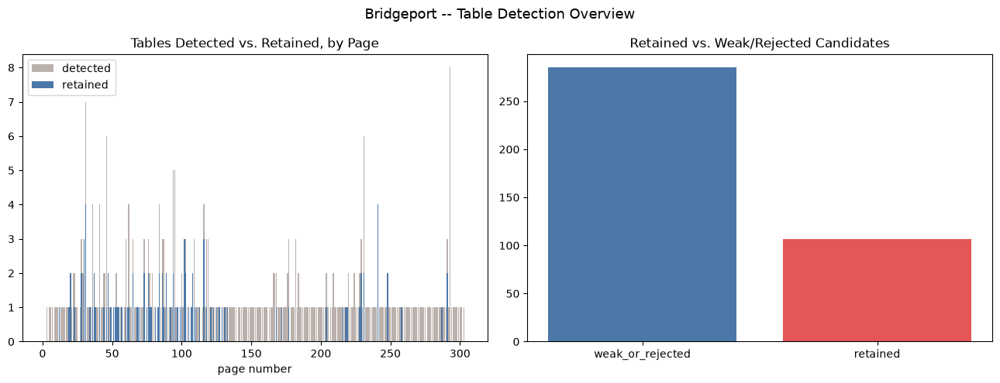

Saved: outputs/figures/bridgeport/step_02_table_detection_counts.png


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(page_table_detection_summary_df["page_number"], page_table_detection_summary_df["tables_detected"],
            color="#BAB0AC", label="detected")
axes[0].bar(page_table_detection_summary_df["page_number"], page_table_detection_summary_df["tables_retained"],
            color="#4C78A8", label="retained")
axes[0].set_title("Tables Detected vs. Retained, by Page")
axes[0].set_xlabel("page number")
axes[0].legend()

retained_vs_weak = raw_table_candidates_df["is_retained"].map({True: "retained", False: "weak_or_rejected"}).value_counts()
axes[1].bar(retained_vs_weak.index, retained_vs_weak.values, color=["#4C78A8", "#E45756"])
axes[1].set_title("Retained vs. Weak/Rejected Candidates")

plt.suptitle("Bridgeport -- Table Detection Overview", fontsize=13)
plt.tight_layout()
detection_counts_path = FIGURES_DIR / "step_02_table_detection_counts.png"
fig.savefig(detection_counts_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {detection_counts_path.relative_to(STAGE_A_ROOT)}")

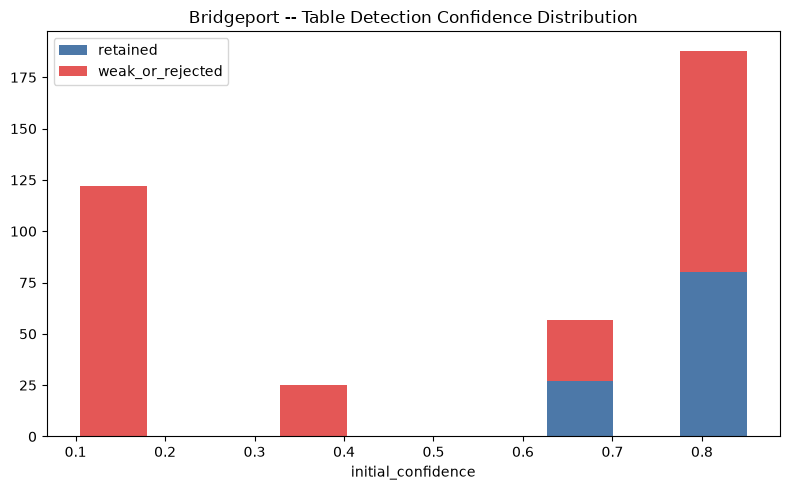

Saved: outputs/figures/bridgeport/step_02_table_confidence_distribution.png


In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    [raw_table_candidates_df.loc[raw_table_candidates_df["is_retained"], "initial_confidence"],
     raw_table_candidates_df.loc[~raw_table_candidates_df["is_retained"], "initial_confidence"]],
    bins=10, stacked=True, color=["#4C78A8", "#E45756"], label=["retained", "weak_or_rejected"],
)
ax.set_title("Bridgeport -- Table Detection Confidence Distribution", fontsize=12)
ax.set_xlabel("initial_confidence")
ax.legend()
plt.tight_layout()
confidence_dist_path = FIGURES_DIR / "step_02_table_confidence_distribution.png"
fig.savefig(confidence_dist_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {confidence_dist_path.relative_to(STAGE_A_ROOT)}")

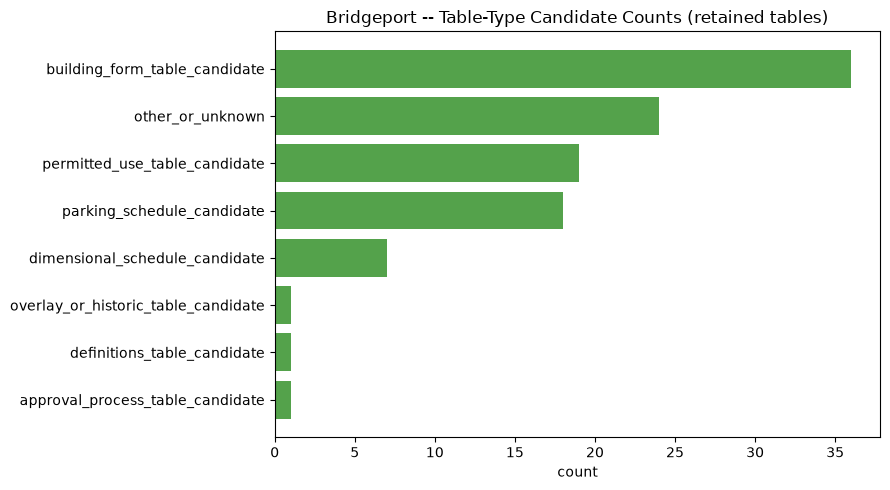

Saved: outputs/figures/bridgeport/step_02_table_type_counts.png


In [51]:
fig, ax = plt.subplots(figsize=(9, 5))
type_counts = table_type_candidates_df["table_type_candidate"].value_counts()
ax.barh(type_counts.index[::-1], type_counts.values[::-1], color="#54A24B")
ax.set_title("Bridgeport -- Table-Type Candidate Counts (retained tables)", fontsize=12)
ax.set_xlabel("count")
plt.tight_layout()
type_counts_path = FIGURES_DIR / "step_02_table_type_counts.png"
fig.savefig(type_counts_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {type_counts_path.relative_to(STAGE_A_ROOT)}")

#### B. Table overlays

Every page with at least one retained table gets a saved overlay image (bbox drawn, color-coded
by type candidate, labeled with the table ID). All are saved to disk; only the required subset
(low-confidence tables, table-dominant pages, one representative high-confidence table per type,
and any complex-layout-page table) is displayed inline here.

In [52]:
TABLE_TYPE_COLORS = {
    "dimensional_schedule_candidate": "#4C78A8", "building_form_table_candidate": "#E45756",
    "permitted_use_table_candidate": "#54A24B", "parking_schedule_candidate": "#F58518",
    "approval_process_table_candidate": "#B279A2", "definitions_table_candidate": "#9D755D",
    "district_taxonomy_table_candidate": "#FF9DA6", "overlay_or_historic_table_candidate": "#72B7B2",
    "code_reference_table_candidate": "#BAB0AC", "other_or_unknown": "#EECA3B",
}

TABLES_FIGURES_DIR = FIGURES_DIR / "tables"
TABLES_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def render_table_overlay_for_page(page_number: int, page_tables: pd.DataFrame, zoom: float = 1.5) -> Path:
    page_image = render_pdf_page(PDF_PATH, page_number=page_number, zoom=zoom)
    fig, ax = plt.subplots(figsize=(8.5, 11))
    ax.imshow(page_image)

    for _, row in page_tables.iterrows():
        color = TABLE_TYPE_COLORS.get(row.get("table_type_candidate", "other_or_unknown"), "#EECA3B")
        rect = plt.Rectangle(
            (row["bbox_x0"] * zoom, row["bbox_y0"] * zoom),
            (row["bbox_x1"] - row["bbox_x0"]) * zoom, (row["bbox_y1"] - row["bbox_y0"]) * zoom,
            linewidth=2.0, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(row["bbox_x0"] * zoom, row["bbox_y0"] * zoom - 4, row["table_id"].split("-table-")[-1],
                color=color, fontsize=7, fontweight="bold")

    ax.set_title(f"Bridgeport -- Table Overlay, Page {page_number}", fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    save_path = TABLES_FIGURES_DIR / f"step_02_table_overlay_page_{page_number:03d}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return save_path


def render_table_crop(table_id: str, zoom: float = 2.0, margin: float = 10.0) -> Path:
    row = table_master_df.loc[table_master_df["table_id"] == table_id].iloc[0]
    page_number = int(row["page_number"])
    page_image = render_pdf_page(PDF_PATH, page_number=page_number, zoom=zoom)
    x0 = max(0, int((row["bbox_x0"] - margin) * zoom))
    y0 = max(0, int((row["bbox_y0"] - margin) * zoom))
    x1 = int((row["bbox_x1"] + margin) * zoom)
    y1 = int((row["bbox_y1"] + margin) * zoom)
    cropped = page_image[y0:y1, x0:x1]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(cropped)
    ax.set_title(f"{table_id}\ntype={row.get('table_type_candidate')} conf={row.get('classification_confidence')}", fontsize=8)
    ax.axis("off")
    plt.tight_layout()
    save_path = TABLES_FIGURES_DIR / f"step_02_table_card_{table_id.split('-table-')[-1]}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return save_path


def display_saved_image(path: Path, title: str = "") -> None:
    image = plt.imread(path)
    fig, ax = plt.subplots(figsize=(7, 9))
    ax.imshow(image)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=9)
    plt.tight_layout()
    plt.show()


overlay_paths_by_page = {}
for page_number, page_tables in table_master_df.groupby("page_number"):
    overlay_paths_by_page[int(page_number)] = render_table_overlay_for_page(int(page_number), page_tables)

print(f"Saved {len(overlay_paths_by_page)} per-page table overlay images under "
      f"{TABLES_FIGURES_DIR.relative_to(STAGE_A_ROOT)}")

Saved 78 per-page table overlay images under outputs/figures/bridgeport/tables


17 of 78 table-overlay pages meet the display criteria (low-confidence, table-dominant, complex-layout, or one-per-type); all pages are saved to disk regardless.


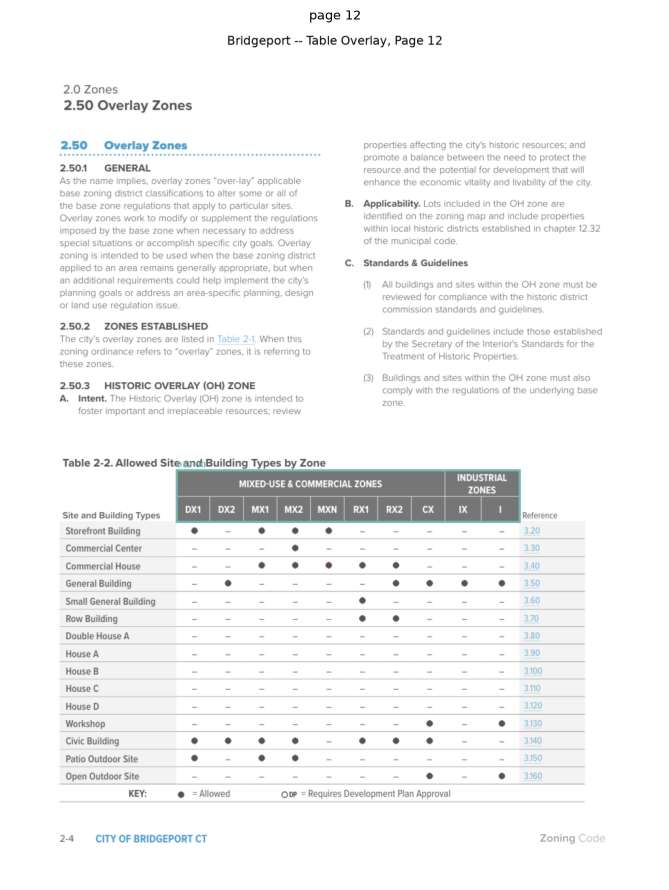

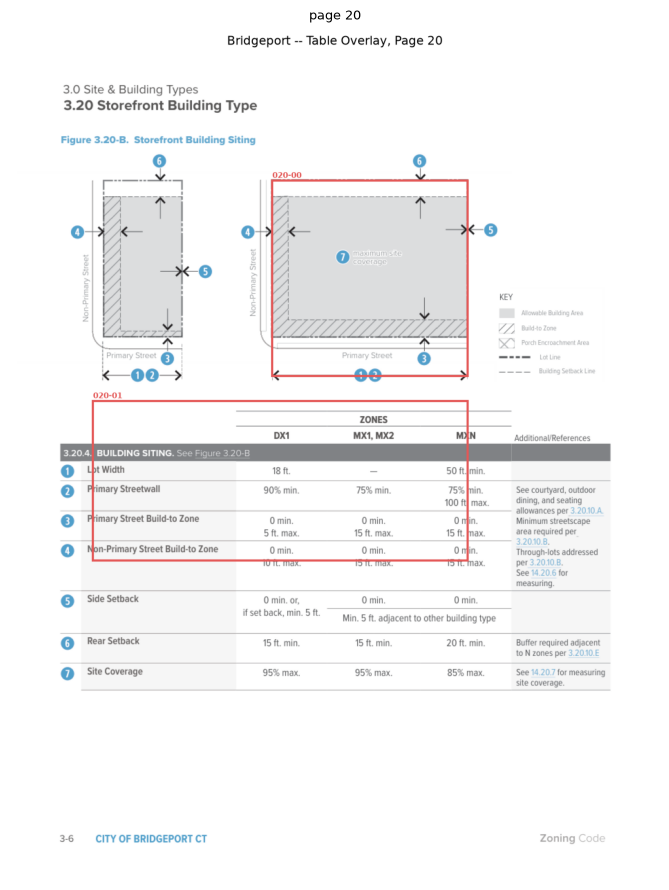

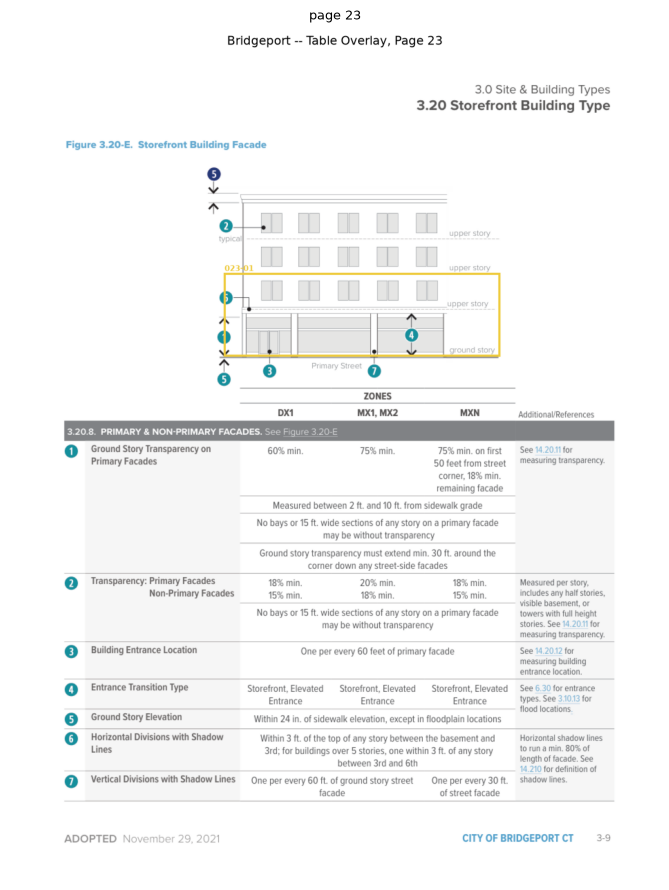

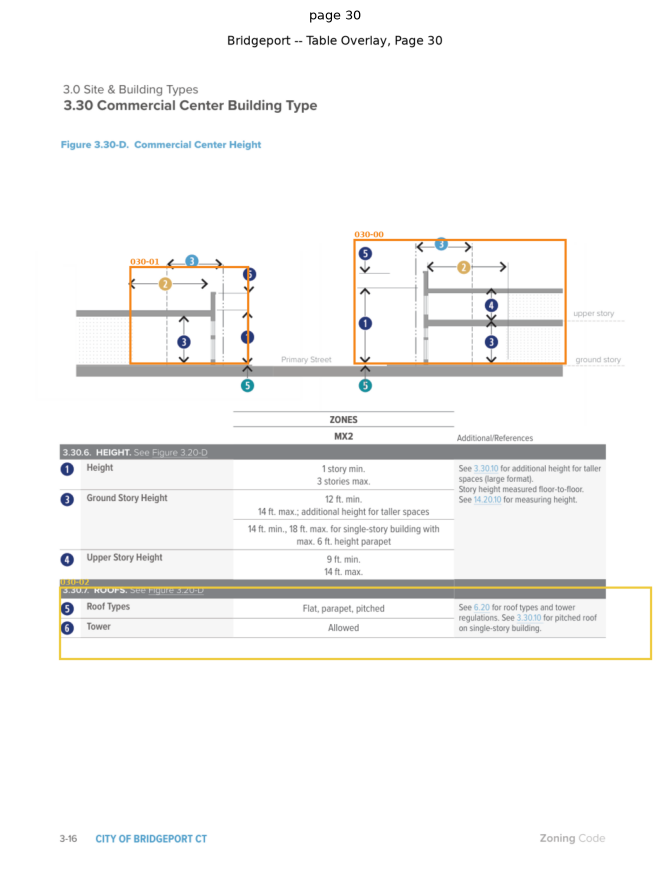

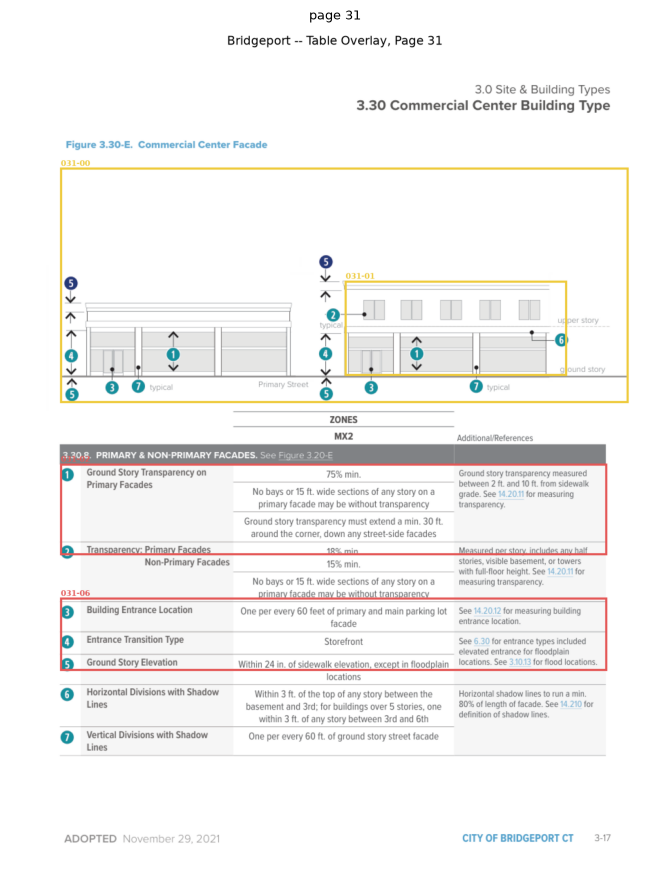

...

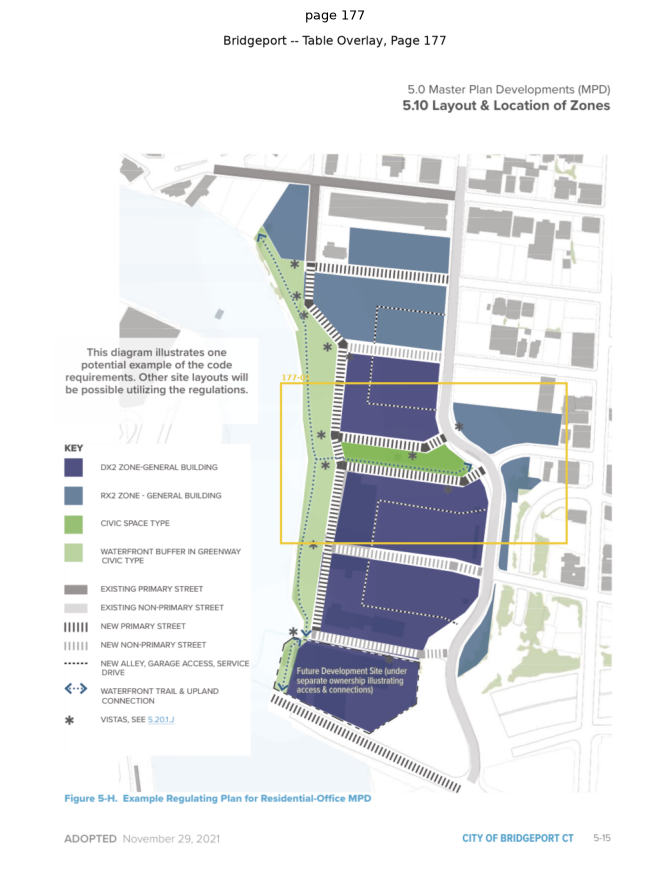

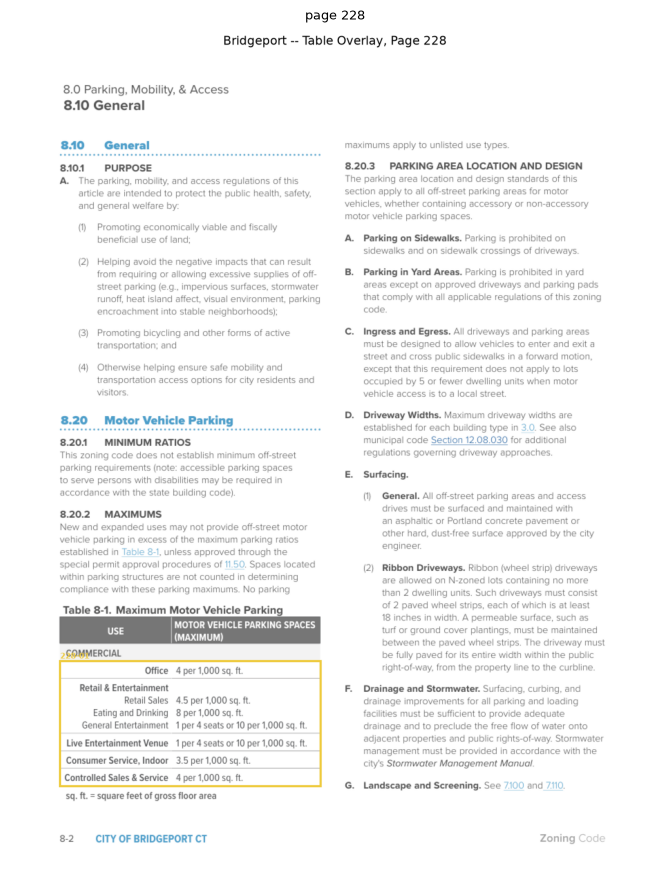

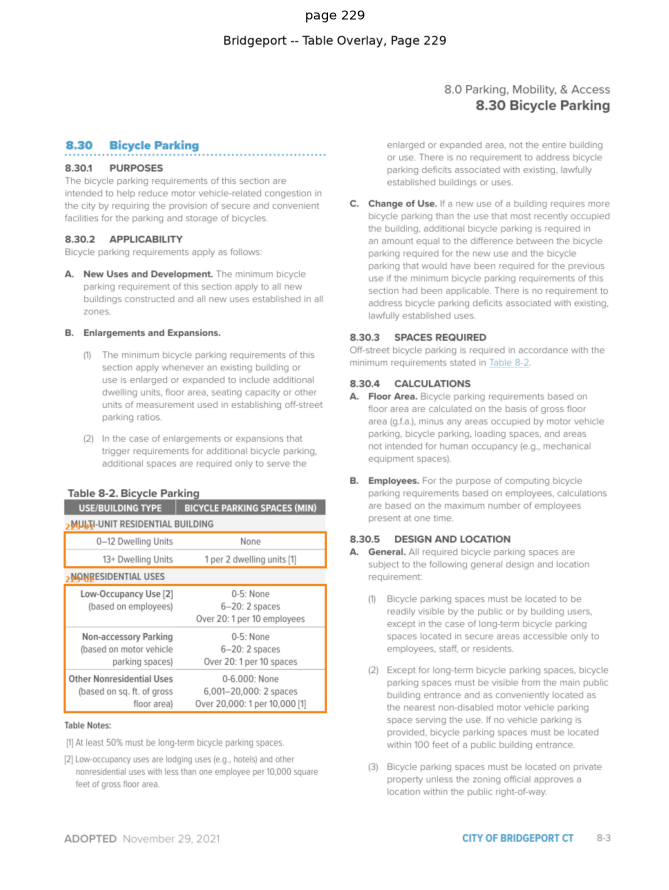

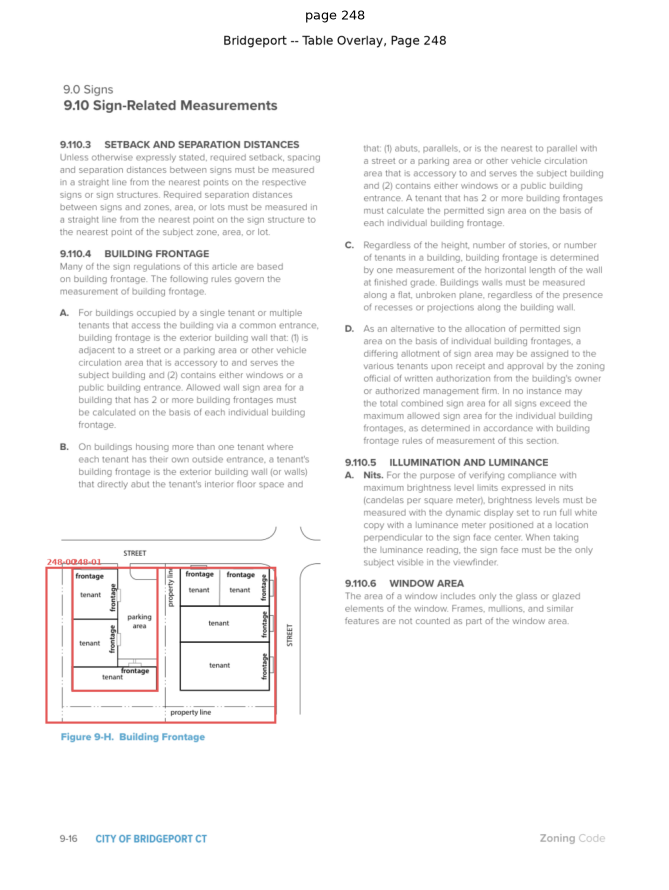

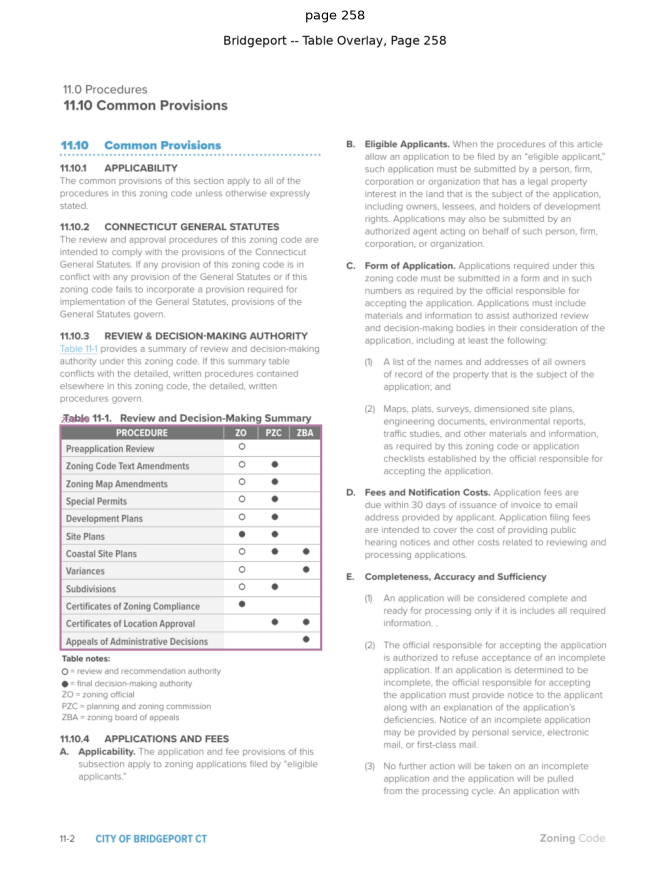

In [53]:
low_confidence_pages = set(table_master_df.loc[table_master_df["initial_confidence"] < 0.6, "page_number"])
table_dominant_pages = set(table_master_df.loc[table_master_df["table_dominant_page"], "page_number"])
complex_layout_pages = set(table_master_df.loc[table_master_df["complex_layout_context"], "page_number"])

representative_high_confidence_pages = set()
for type_name in table_master_df["table_type_candidate"].dropna().unique():
    subset = table_master_df.loc[
        (table_master_df["table_type_candidate"] == type_name) & (table_master_df["initial_confidence"] >= 0.7)
    ]
    if len(subset):
        representative_high_confidence_pages.add(int(subset.iloc[0]["page_number"]))

pages_to_display = sorted(
    {int(p) for p in low_confidence_pages | table_dominant_pages | complex_layout_pages | representative_high_confidence_pages}
)
print(f"{len(pages_to_display)} of {len(overlay_paths_by_page)} table-overlay pages meet the display criteria "
      f"(low-confidence, table-dominant, complex-layout, or one-per-type); all pages are saved to disk regardless.")

for page_number in pages_to_display[:18]:
    if page_number in overlay_paths_by_page:
        display_saved_image(overlay_paths_by_page[page_number], title=f"page {page_number}")
if len(pages_to_display) > 18:
    print(f"... {len(pages_to_display) - 18} more qualifying pages saved to disk but not displayed inline.")

#### C. Extraction comparison cards

At least 10 representative tables -- one high-confidence example per discovered type candidate,
padded out with the lowest-confidence remaining tables -- each with a source crop, the raw
extraction matrix, a cleaned pivoted preview, and full metadata.

Building 10 extraction-comparison cards



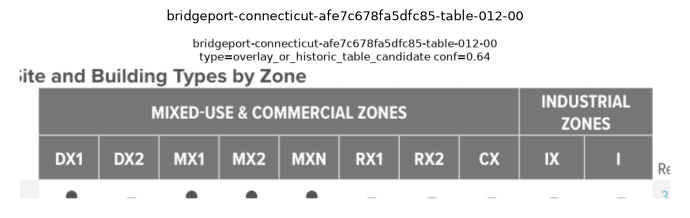

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-012-00  page=12
  title_candidate: 'A. Intent. The Historic Overlay (OH) zone is intended to'
  type_candidate: overlay_or_historic_table_candidate  classification_confidence: 0.64
  detection_confidence: 0.85  association_confidence: 0.9
  header_uncertain: False
  review_status: retained_auto
  raw matrix (first 5 rows):
    ['MIXED-USE & COMMERCIAL ZONES', None, None, None, None, None, None, None, 'INDUSTRIAL\nZONES', None]
    ['DX1', 'DX2', 'MX1', 'MX2', 'MXN', 'RX1', 'RX2', 'CX', 'IX', 'I']
  cleaned pivoted preview:
column_index                             0    1    2    3    4    5    6   7                 8  9
row_index                                                                                        
0             MIXED-USE & COMMERCIAL ZONES                                    INDUSTRIAL ZONES   
1                                      DX1  DX2  MX1  MX2  MXN  RX1  RX2  CX                IX  I
------------------------

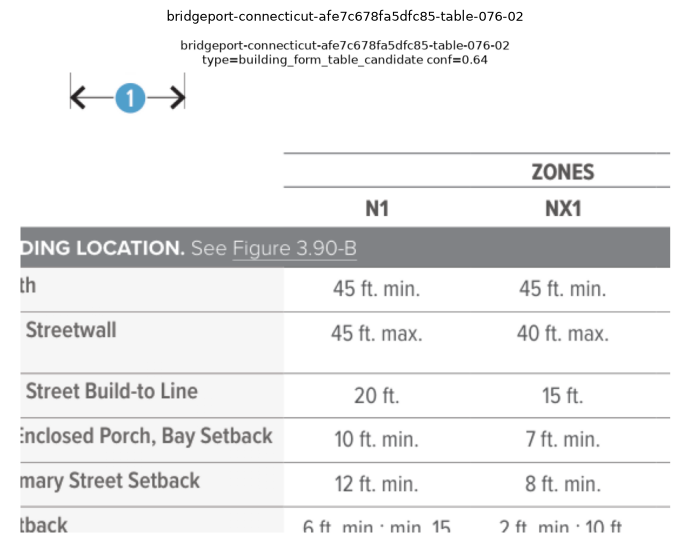

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-076-02  page=76
  title_candidate: '3.90 House A Building Type'
  type_candidate: building_form_table_candidate  classification_confidence: 0.64
  detection_confidence: 0.85  association_confidence: 0.4
  header_uncertain: False
  review_status: retained_auto
  raw matrix (first 5 rows):
    [None, None, 'q\nLOCATION.', None, 'See Figure', None, None, None, None, None, None, None, None]
    [None, None, None, None, None, None, '', '', '', 'ZONES', None, '', None]
    [None, None, None, None, None, None, 'N1\n3.90-B', '', '', 'NX1', '', '', None]
    [None, None, None, None, None, None, None, None, None, None, 'NX1', '', None]
    [None, None, None, 'OCATION.', None, 'e Figure', None, None, None, None, None, None, None]
  cleaned pivoted preview:
column_index 0  1            2         3           4         5            6  7  8         9    10  11 12
row_index                                                                           

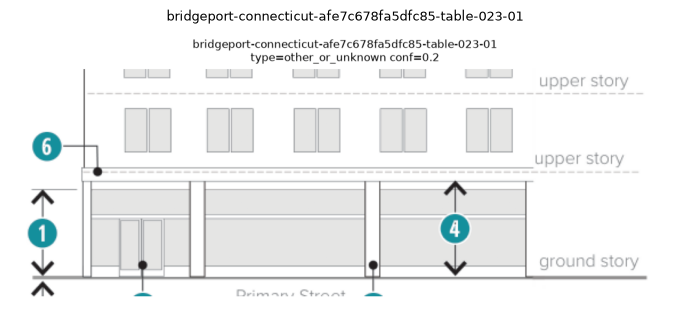

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-023-01  page=23
  title_candidate: '3.20.7. ROOFS. See Figure 3.20-D'
  type_candidate: other_or_unknown  classification_confidence: 0.2
  detection_confidence: 0.85  association_confidence: 0.4
  header_uncertain: True
  review_status: retained_auto
  raw matrix (first 5 rows):
    [None, 'upper story\nr\nground story', None, None, None, None, None, None, None, None, None, None, None]
    [None, '', None, None, None, None, None, None, None, None, None, None, None]
    [None, '', '', None, None, None, '', '', '', '', None, '', None]
    ['q', None, '', None, None, None, '', '', '', '', '', '', 'grou']
    [None, '', '', '', '', '', '', '', '', '', 'r', '', None]
  cleaned pivoted preview:
column_index 0                           1  2  3  4  5  6  7  8  9  10 11    12
row_index                                                                      
0                upper story r ground story                                    
1      

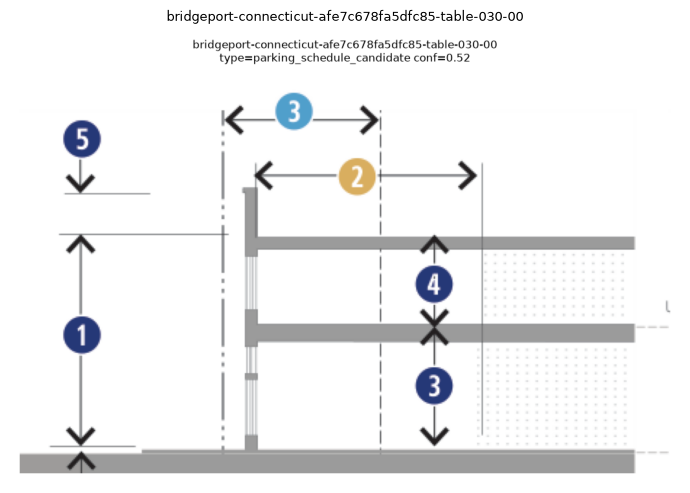

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-030-00  page=30
  title_candidate: '3.30.5. PARKING & ACCESSORY STRUCTURES. See Figure 3.20-C.'
  type_candidate: parking_schedule_candidate  classification_confidence: 0.52
  detection_confidence: 0.85  association_confidence: 0.4
  header_uncertain: True
  review_status: retained_auto
  raw matrix (first 5 rows):
    ['t\nq', None, 'e', None, None, None, None]
    [None, None, 'w', None, None, None, None]
    [None, None, None, 'w', '', None, None]
    [None, 'q', None, '', '', '', '']
    [None, None, None, '', '', 'r', None]
  cleaned pivoted preview:
column_index    0  1  2  3 4  5 6
row_index                        
0             t q     e          
1                     w          
2                        w       
3                  q             
4                             r  
5                                
----------------------------------------------------------------------------------------------------


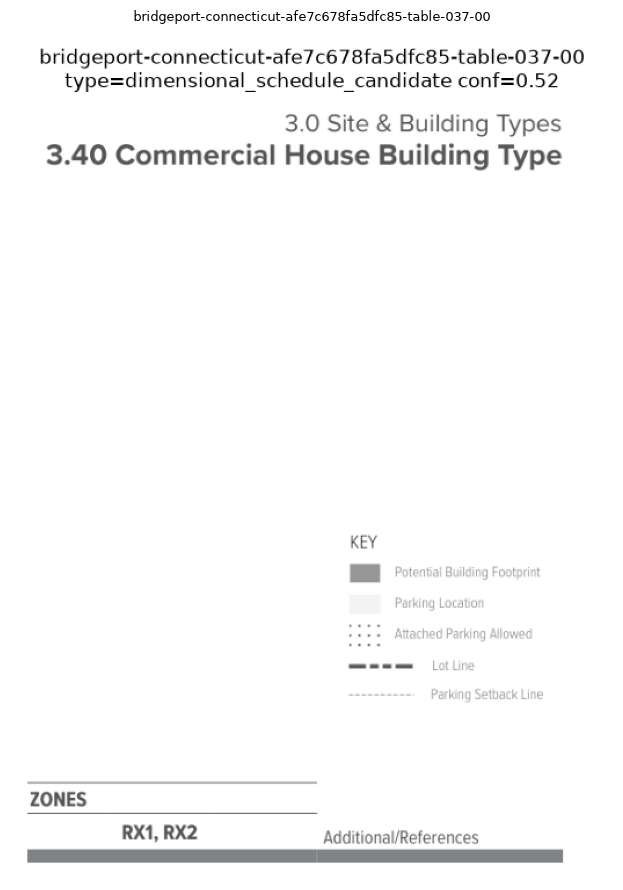

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-037-00  page=37
  title_candidate: '3.40.4. BUILDING LOCATION. See Figure 3.90-B'
  type_candidate: dimensional_schedule_candidate  classification_confidence: 0.52
  detection_confidence: 0.85  association_confidence: 0.4
  header_uncertain: False
  review_status: retained_auto
  raw matrix (first 5 rows):
    ['3.', '3.0 Site & Building Types\n40 Commercial House Building Type\nKEY\nPotential Building Footprint\nParking Location\nAttached Parking Allowed']
    [None, '']
    [None, 'Lot Line\nParking Setback Line\nS\nRX1, RX2 Additional/References']
  cleaned pivoted preview:
column_index   0                                                                                                                                       1
row_index                                                                                                                                               
0             3.  3.0 Site & Building Types 40 Commerci

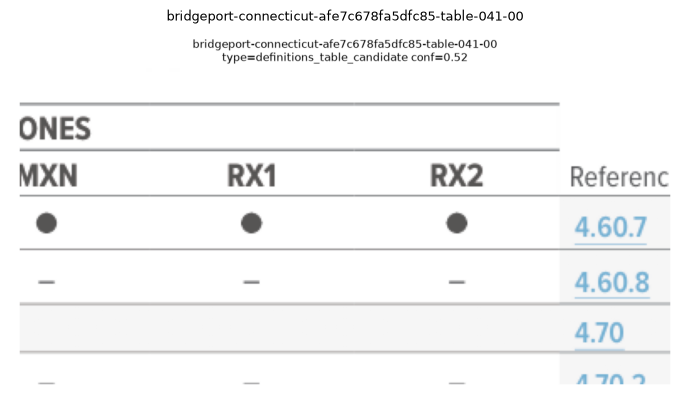

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-041-00  page=41
  title_candidate: '3.40.9. ALLOWED USES. See Article 4.0 for use definitions, specific use limitations, and other use-related regulations.'
  type_candidate: definitions_table_candidate  classification_confidence: 0.52
  detection_confidence: 0.85  association_confidence: 0.4
  header_uncertain: False
  review_status: retained_auto
  raw matrix (first 5 rows):
    ['E', None]
    ['', None]
    ['', '4 4 4.60.']
    ['', '– – 4.60.']
    ['', '4.70']
  cleaned pivoted preview:
column_index  0          1
row_index                 
0             E           
1                         
2                4 4 4.60.
3                – – 4.60.
4                     4.70
----------------------------------------------------------------------------------------------------


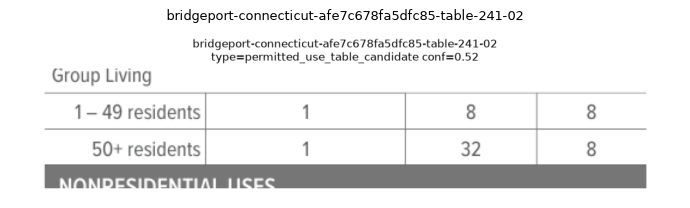

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-241-02  page=241
  title_candidate: 'B. Electronic message displays are expressly prohibited in'
  type_candidate: permitted_use_table_candidate  classification_confidence: 0.52
  detection_confidence: 0.85  association_confidence: 0.7
  header_uncertain: True
  review_status: retained_auto
  raw matrix (first 5 rows):
    ['1 – 49 residents', '1', '8', '8']
    ['50+ residents', '1', '32', '8']
  cleaned pivoted preview:
column_index                 0  1   2  3
row_index                               
0             1 – 49 residents  1   8  8
1                50+ residents  1  32  8
----------------------------------------------------------------------------------------------------


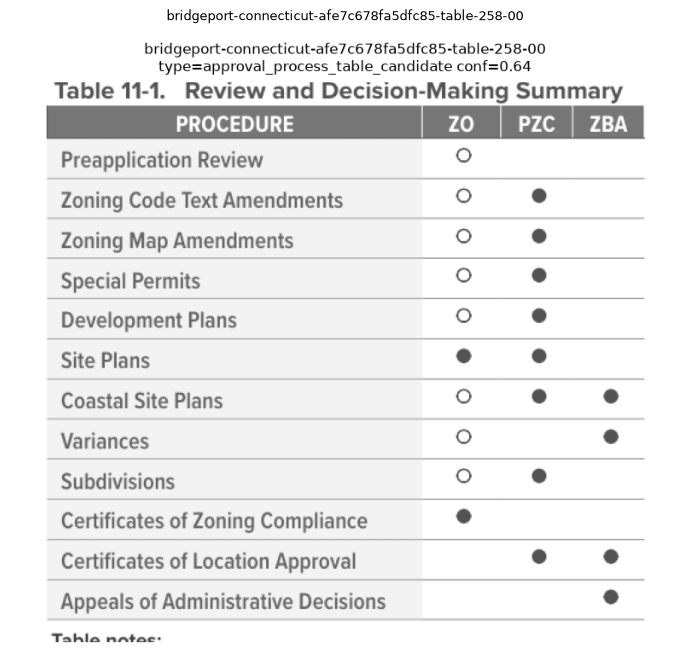

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-258-00  page=258
  title_candidate: '(2) Maps, plats, surveys, dimensioned site plans,'
  type_candidate: approval_process_table_candidate  classification_confidence: 0.64
  detection_confidence: 0.65  association_confidence: 0.5
  header_uncertain: False
  review_status: retained_complex_layout_review
  raw matrix (first 5 rows):
    ['PROCEDURE', 'ZO', 'PZC', 'ZBA']
    ['Preapplication Review', '0', None, None]
    ['Zoning Code Text Amendments', '0 4', None, None]
    ['Zoning Map Amendments', '0 4', None, None]
    ['Special Permits', '0 4', None, None]
  cleaned pivoted preview:
column_index                            0    1    2    3
row_index                                               
0                               PROCEDURE   ZO  PZC  ZBA
1                   Preapplication Review    0          
2             Zoning Code Text Amendments  0 4          
3                   Zoning Map Amendments  0 4          
4          

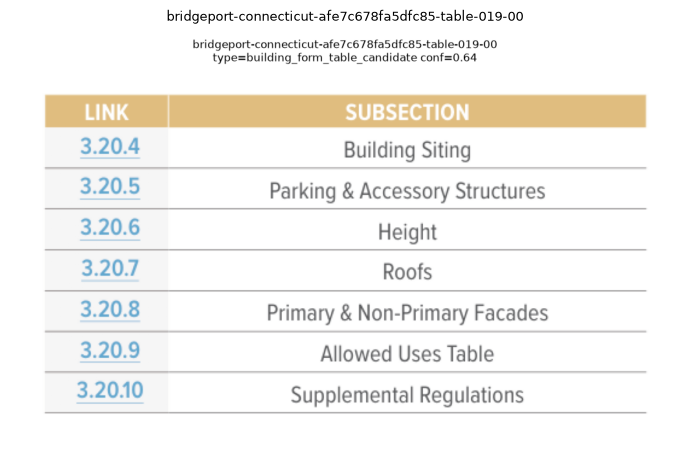

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-019-00  page=19
  title_candidate: '3.20 Storefront Building Type'
  type_candidate: building_form_table_candidate  classification_confidence: 0.64
  detection_confidence: 0.65  association_confidence: 0.7
  header_uncertain: False
  review_status: retained_low_confidence_review
  raw matrix (first 5 rows):
    ['LINK', 'SUBSECTION']
    ['3.20.4', 'Building Siting']
    ['3.20.5', 'Parking & Accessory Structures']
    ['3.20.6', 'Height']
    ['3.20.7', 'Roofs']
  cleaned pivoted preview:
column_index       0                               1
row_index                                           
0               LINK                      SUBSECTION
1             3.20.4                 Building Siting
2             3.20.5  Parking & Accessory Structures
3             3.20.6                          Height
4             3.20.7                           Roofs
5             3.20.8   Primary & Non-Primary Facades
--------------------------

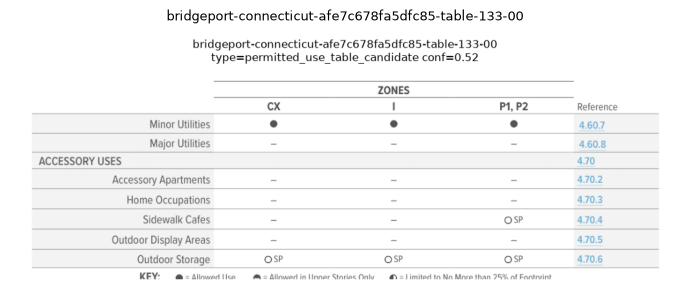

table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-133-00  page=133
  title_candidate: '3.160.7. ALLOWED USES. See Article 4.0 for use definitions, specific use limitations, and other use-related regulations.'
  type_candidate: permitted_use_table_candidate  classification_confidence: 0.52
  detection_confidence: 0.65  association_confidence: 0.4
  header_uncertain: False
  review_status: retained_low_confidence_review
  raw matrix (first 5 rows):
    [None, 'ZONES', None, None, None]
    [None, 'CX', 'I', 'P1, P2', None]
    ['Minor Utilities', '4 4 4', None, None, '4.60.7']
    ['Major Utilities', '– – –', None, None, '4.60.8']
    ['ACCESSORY USES', '', '', '', '4.70']
  cleaned pivoted preview:
column_index                     0      1  2       3       4
row_index                                                   
0                                   ZONES                   
1                                      CX  I  P1, P2        
2                  Minor Utilities  4 4 4   

In [54]:
comparison_card_ids = []
for type_name in table_master_df["table_type_candidate"].dropna().unique():
    subset = table_master_df.loc[table_master_df["table_type_candidate"] == type_name].sort_values(
        "initial_confidence", ascending=False
    )
    if len(subset):
        comparison_card_ids.append(subset.iloc[0]["table_id"])

if len(comparison_card_ids) < 10:
    remaining_pool = table_master_df.loc[~table_master_df["table_id"].isin(comparison_card_ids)].sort_values("initial_confidence")
    comparison_card_ids += remaining_pool["table_id"].head(10 - len(comparison_card_ids)).tolist()

print(f"Building {len(comparison_card_ids)} extraction-comparison cards\n")

header_uncertain_lookup = table_header_diagnostics_df.set_index("table_id")["header_uncertain"]

for table_id in comparison_card_ids:
    row = table_master_df.loc[table_master_df["table_id"] == table_id].iloc[0]
    crop_path = render_table_crop(table_id)
    display_saved_image(crop_path, title=table_id)

    cells = table_cells_df.loc[table_cells_df["table_id"] == table_id]
    pivoted = cells.pivot(index="row_index", columns="column_index", values="clean_cell_value")

    print(f"table_id={table_id}  page={int(row['page_number'])}")
    print(f"  title_candidate: {row.get('title_candidate_text')!r}")
    print(f"  type_candidate: {row.get('table_type_candidate')}  classification_confidence: {row.get('classification_confidence')}")
    print(f"  detection_confidence: {row['initial_confidence']}  association_confidence: {row.get('association_confidence')}")
    print(f"  header_uncertain: {header_uncertain_lookup.get(table_id)}")
    print(f"  review_status: {row['review_status']}")
    print("  raw matrix (first 5 rows):")
    for raw_row in table_raw_matrices[table_id][:5]:
        print("   ", raw_row)
    print("  cleaned pivoted preview:")
    print(pivoted.head(6).to_string())
    print("-" * 100)

#### D. Header diagnostics (visual)

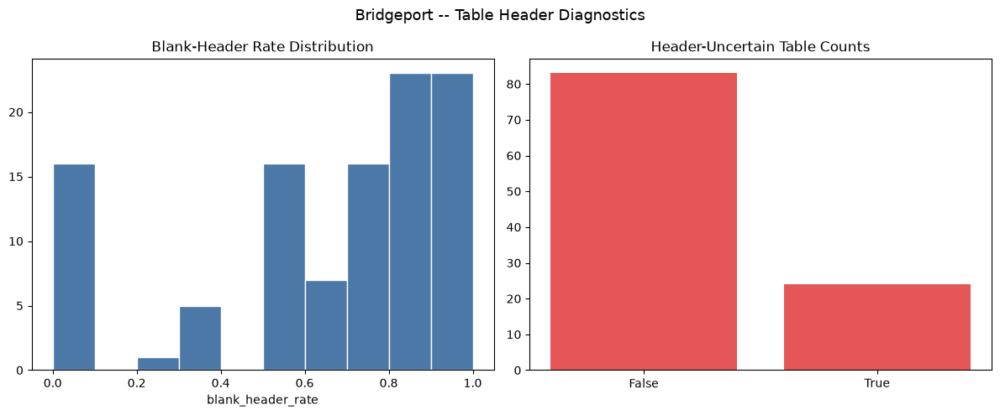

Saved: outputs/figures/bridgeport/step_02_header_diagnostics.png

Rendering crops for 24 header-uncertain tables (saved to disk; showing up to 6 inline)


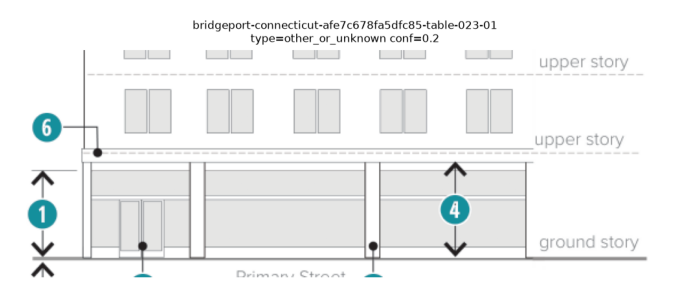

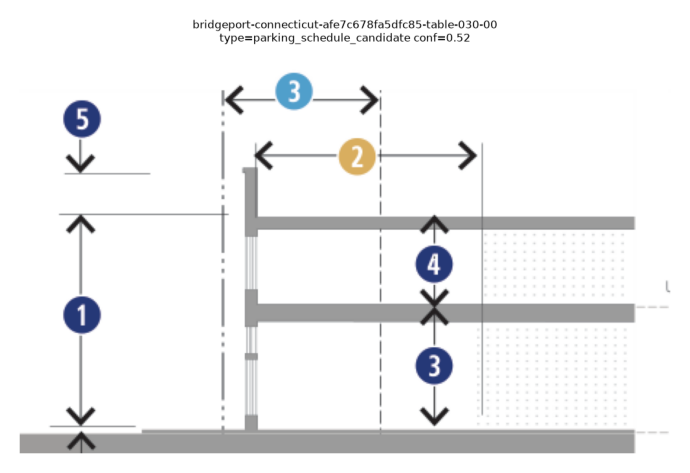

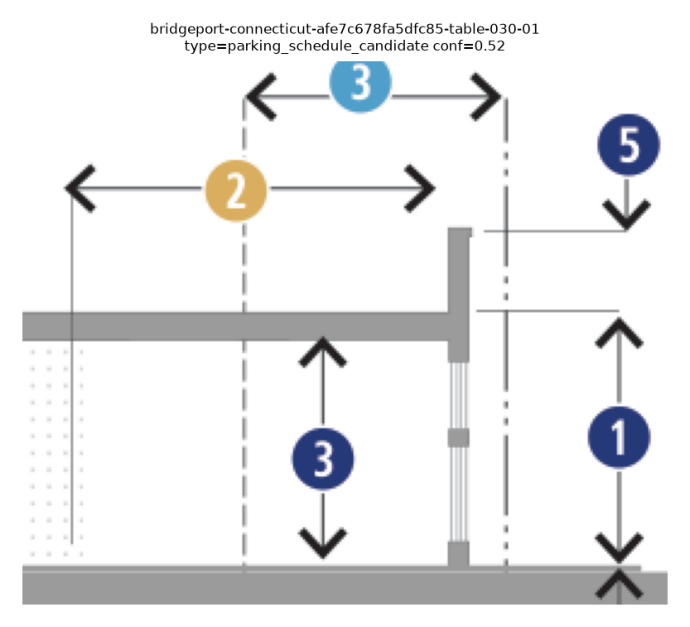

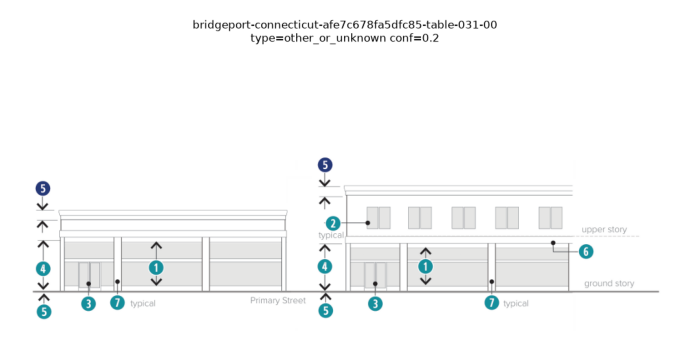

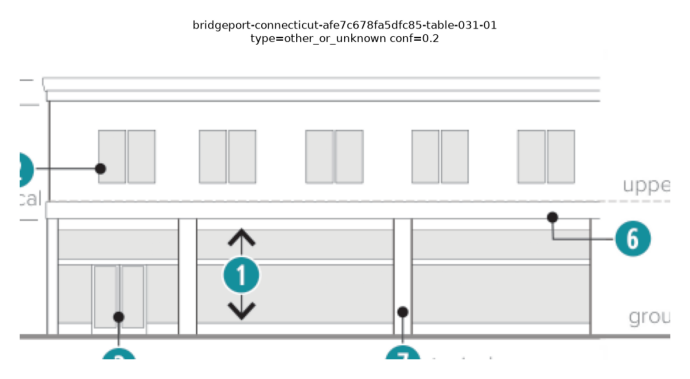

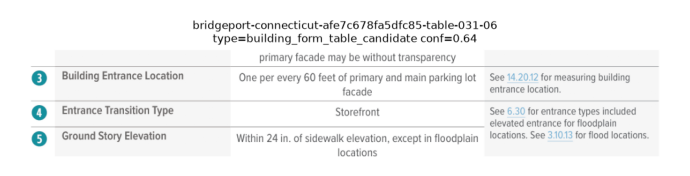

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(table_header_diagnostics_df["blank_header_rate"], bins=10, color="#4C78A8", edgecolor="white")
axes[0].set_title("Blank-Header Rate Distribution")
axes[0].set_xlabel("blank_header_rate")

uncertain_counts = table_header_diagnostics_df["header_uncertain"].value_counts()
axes[1].bar(uncertain_counts.index.astype(str), uncertain_counts.values, color="#E45756")
axes[1].set_title("Header-Uncertain Table Counts")

plt.suptitle("Bridgeport -- Table Header Diagnostics", fontsize=13)
plt.tight_layout()
header_diag_fig_path = FIGURES_DIR / "step_02_header_diagnostics.png"
fig.savefig(header_diag_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {header_diag_fig_path.relative_to(STAGE_A_ROOT)}")

header_uncertain_ids = table_header_diagnostics_df.loc[table_header_diagnostics_df["header_uncertain"], "table_id"].tolist()
print(f"\nRendering crops for {len(header_uncertain_ids)} header-uncertain tables (saved to disk; showing up to 6 inline)")
header_uncertain_crop_paths = [render_table_crop(tid) for tid in header_uncertain_ids]
for crop_path in header_uncertain_crop_paths[:6]:
    display_saved_image(crop_path)

#### E. Row/column diagnostics (visual)

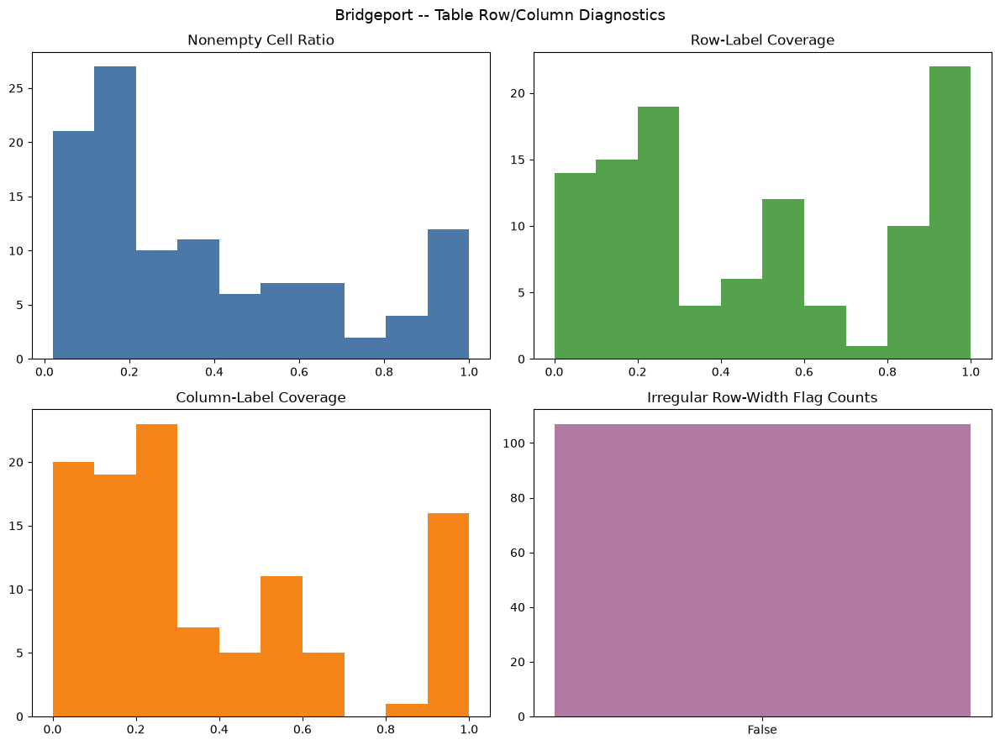

Saved: outputs/figures/bridgeport/step_02_row_column_diagnostics.png

Tables needing manual review (row/column diagnostics): 68
                            document_id                                             table_id  nonempty_cell_ratio  row_label_coverage  column_label_coverage  irregular_row_width  needs_manual_review  page_number           table_type_candidate
bridgeport-connecticut-afe7c678fa5dfc85 bridgeport-connecticut-afe7c678fa5dfc85-table-020-00                0.150               0.200                  0.500                False                 True           20  building_form_table_candidate
bridgeport-connecticut-afe7c678fa5dfc85 bridgeport-connecticut-afe7c678fa5dfc85-table-020-01                0.303               0.111                  0.091                False                 True           20  building_form_table_candidate
bridgeport-connecticut-afe7c678fa5dfc85 bridgeport-connecticut-afe7c678fa5dfc85-table-023-01                0.062               0.200          

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].hist(table_row_column_diagnostics_df["nonempty_cell_ratio"], bins=10, color="#4C78A8")
axes[0, 0].set_title("Nonempty Cell Ratio")
axes[0, 1].hist(table_row_column_diagnostics_df["row_label_coverage"], bins=10, color="#54A24B")
axes[0, 1].set_title("Row-Label Coverage")
axes[1, 0].hist(table_row_column_diagnostics_df["column_label_coverage"], bins=10, color="#F58518")
axes[1, 0].set_title("Column-Label Coverage")
irregular_counts = table_row_column_diagnostics_df["irregular_row_width"].value_counts()
axes[1, 1].bar(irregular_counts.index.astype(str), irregular_counts.values, color="#B279A2")
axes[1, 1].set_title("Irregular Row-Width Flag Counts")

plt.suptitle("Bridgeport -- Table Row/Column Diagnostics", fontsize=13)
plt.tight_layout()
row_col_diag_fig_path = FIGURES_DIR / "step_02_row_column_diagnostics.png"
fig.savefig(row_col_diag_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {row_col_diag_fig_path.relative_to(STAGE_A_ROOT)}")

manual_review_tables_df = table_row_column_diagnostics_df.loc[table_row_column_diagnostics_df["needs_manual_review"]].merge(
    table_master_df[["table_id", "page_number", "table_type_candidate"]], on="table_id", how="left"
)
print(f"\nTables needing manual review (row/column diagnostics): {len(manual_review_tables_df)}")
print(manual_review_tables_df.to_string(index=False))

#### F. Complex-layout table report

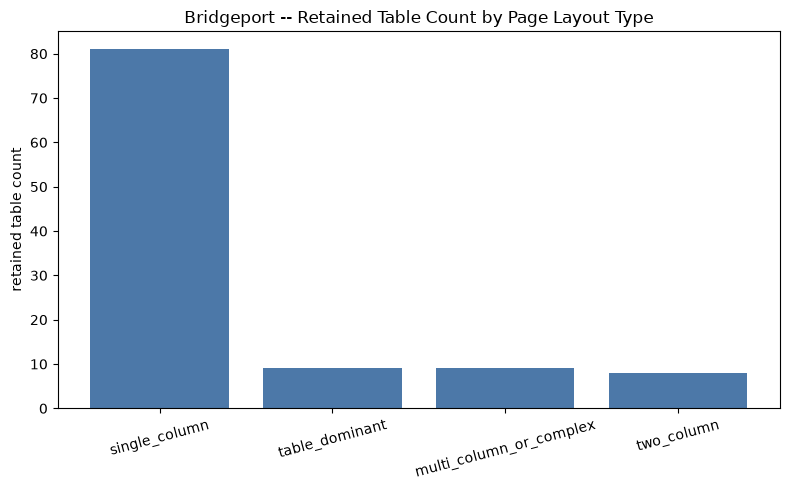

Saved: outputs/figures/bridgeport/step_02_complex_layout_table_summary.png

carry lower title-association confidence and should not be treated as fully resolved
without a targeted manual check -- see step_02_complex_layout_tables.csv.

Example single_column table page: 12 (table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-012-00)


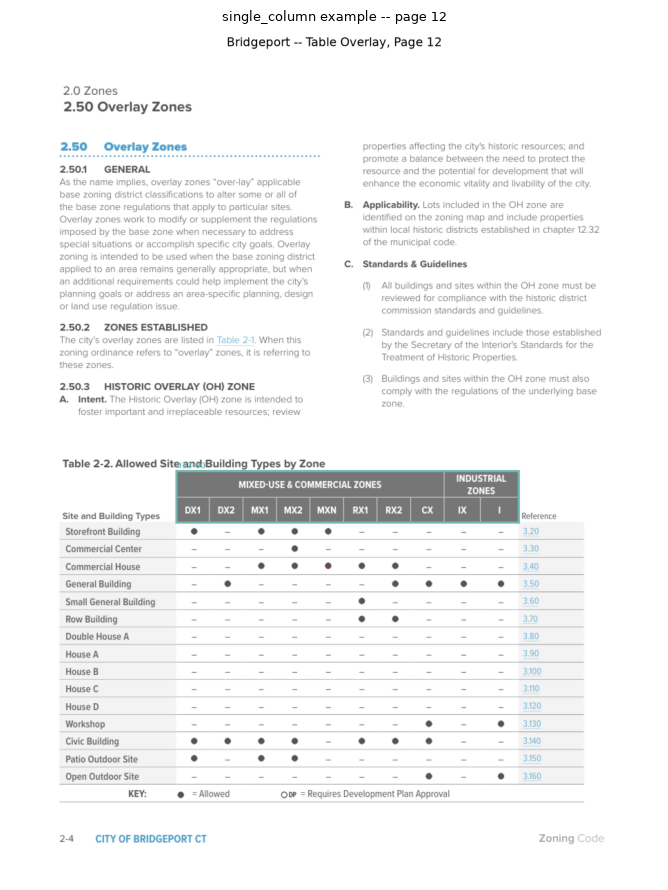


Example two_column table page: 204 (table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-204-00)


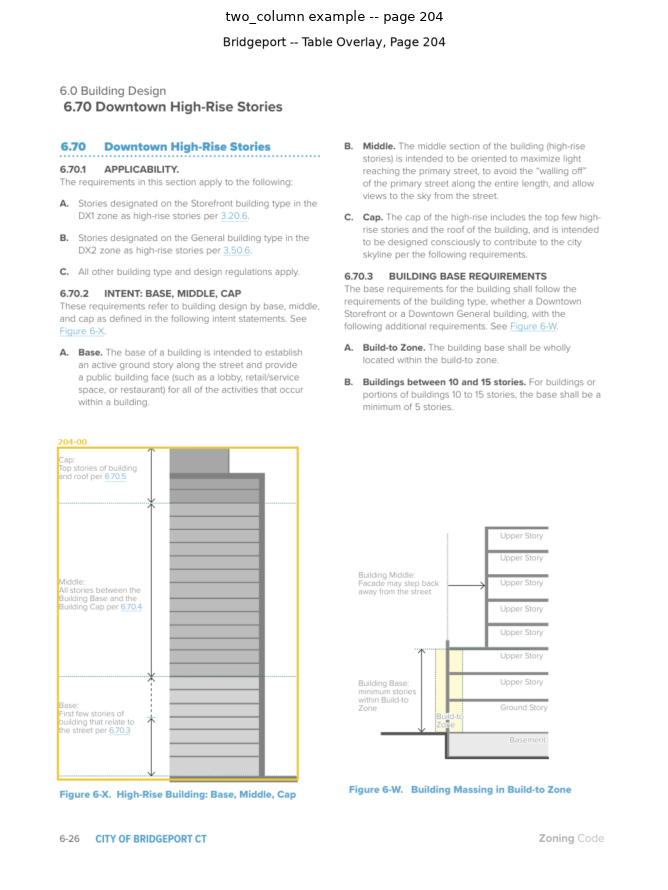


Example multi_column_or_complex table page: 123 (table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-123-00)


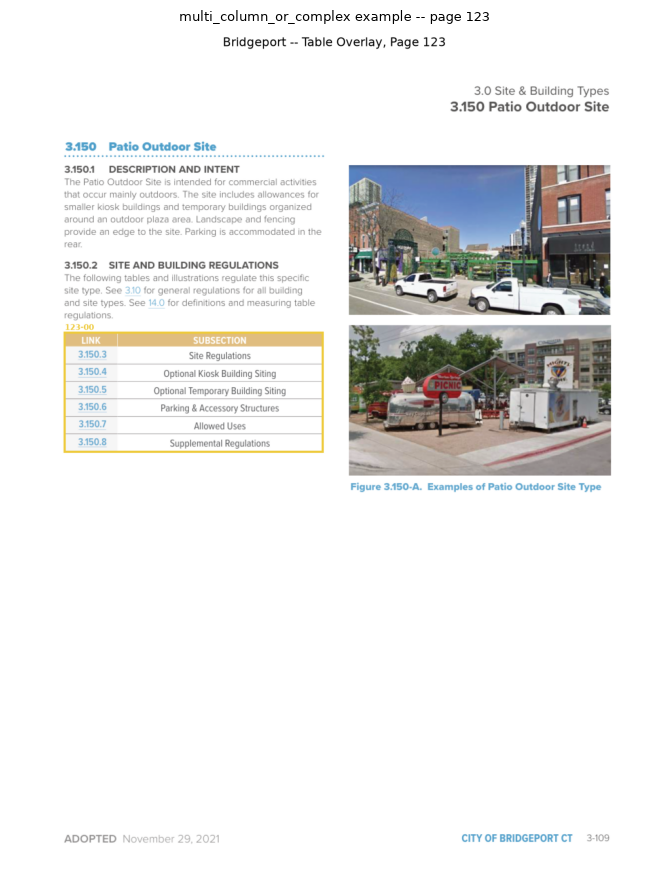


Example table_dominant table page: 31 (table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-031-00)


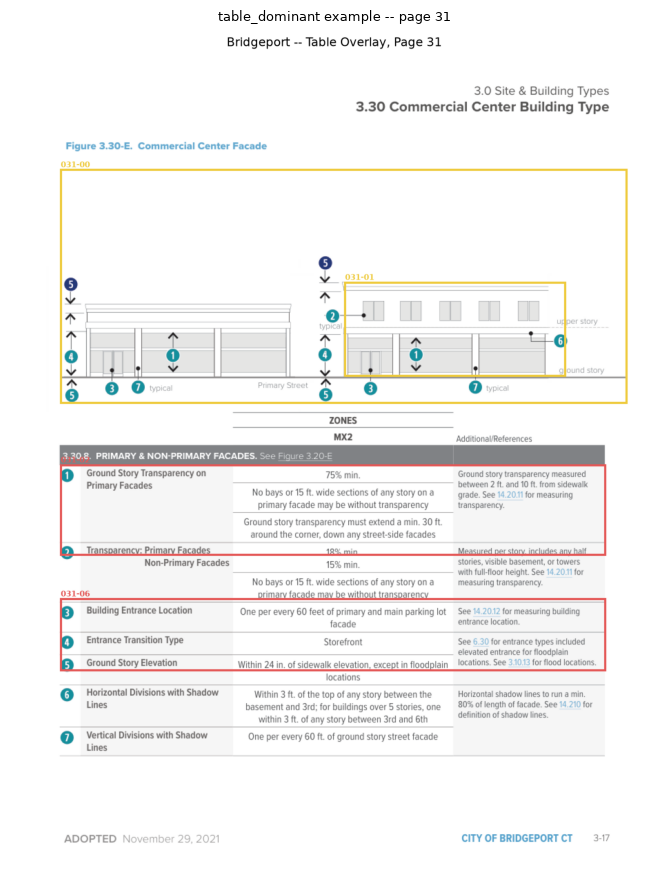

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
layout_type_table_counts = table_master_df["page_layout_type"].value_counts()
ax.bar(layout_type_table_counts.index, layout_type_table_counts.values, color="#4C78A8")
ax.set_title("Bridgeport -- Retained Table Count by Page Layout Type", fontsize=12)
ax.set_ylabel("retained table count")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
complex_layout_summary_path = FIGURES_DIR / "step_02_complex_layout_table_summary.png"
fig.savefig(complex_layout_summary_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {complex_layout_summary_path.relative_to(STAGE_A_ROOT)}")

print("\nWARNING: tables on the 77 multi_column_or_complex pages (and any table_dominant page)")
print("carry lower title-association confidence and should not be treated as fully resolved")
print("without a targeted manual check -- see step_02_complex_layout_tables.csv.")

for layout_type in ["single_column", "two_column", "multi_column_or_complex", "table_dominant"]:
    subset = table_master_df.loc[table_master_df["page_layout_type"] == layout_type]
    if len(subset):
        example_page = int(subset.iloc[0]["page_number"])
        print(f"\nExample {layout_type} table page: {example_page} (table_id={subset.iloc[0]['table_id']})")
        if example_page in overlay_paths_by_page:
            display_saved_image(overlay_paths_by_page[example_page], title=f"{layout_type} example -- page {example_page}")
    else:
        print(f"\nNo retained tables found on any {layout_type} page.")

### 11.9 Validation checks and required manual inspection

Mechanical checks first -- then specific, named tables are rendered for a real visual check
(not asserted as correct, actually looked at) across the categories the spec requires: likely
dimensional/building-form tables, likely permitted-use tables, a parking/mobility table if one
was detected, a complex-layout-page table, a table-dominant-page table, and a weak/failed
detection.

In [58]:
validation_checks = [
    ("table_ids_unique_in_master", bool(table_master_df["table_id"].is_unique)),
    ("every_cell_maps_to_known_table_id", bool(table_cells_df["table_id"].isin(table_master_df["table_id"]).all())),
    ("page_numbers_valid_range", bool(raw_table_candidates_df["page_number"].between(1, PDF_PAGE_COUNT).all())),
    ("bbox_coordinates_valid", bool((
        (raw_table_candidates_df["bbox_x1"] > raw_table_candidates_df["bbox_x0"])
        & (raw_table_candidates_df["bbox_y1"] > raw_table_candidates_df["bbox_y0"])
    ).all())),
    ("row_column_indices_nonnegative", bool((table_cells_df["row_index"] >= 0).all() and (table_cells_df["column_index"] >= 0).all())),
    ("raw_cell_count_matches_source_matrices", len(table_cells_df) == sum(
        len(row) for tid in retained_table_ids for row in table_raw_matrices[tid]
    )),
    ("title_association_confidence_present", bool(table_title_associations_df["association_confidence"].notna().all())),
    ("type_candidate_confidence_reason_present", bool(
        table_type_candidates_df[["table_type_candidate", "classification_confidence", "classification_rationale"]]
        .notna().all().all()
    )),
    ("all_complex_layout_pages_tables_flagged", bool(
        table_master_df.loc[table_master_df["page_layout_type"] == "multi_column_or_complex", "complex_layout_context"].all()
        if (table_master_df["page_layout_type"] == "multi_column_or_complex").any() else True
    )),
]

table_validation_df = pd.DataFrame(validation_checks, columns=["validation_rule", "passed"])
print(table_validation_df.to_string(index=False))
print(f"\nAll Stage 2 validation checks passed: {bool(table_validation_df['passed'].all())}")

                         validation_rule  passed
              table_ids_unique_in_master    True
       every_cell_maps_to_known_table_id    True
                page_numbers_valid_range    True
                  bbox_coordinates_valid    True
          row_column_indices_nonnegative    True
  raw_cell_count_matches_source_matrices    True
    title_association_confidence_present    True
type_candidate_confidence_reason_present    True
 all_complex_layout_pages_tables_flagged    True

All Stage 2 validation checks passed: True


MANUAL INSPECTION -- category=dimensional_or_building_form_1  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-084-00  page=84  weak_candidate=False


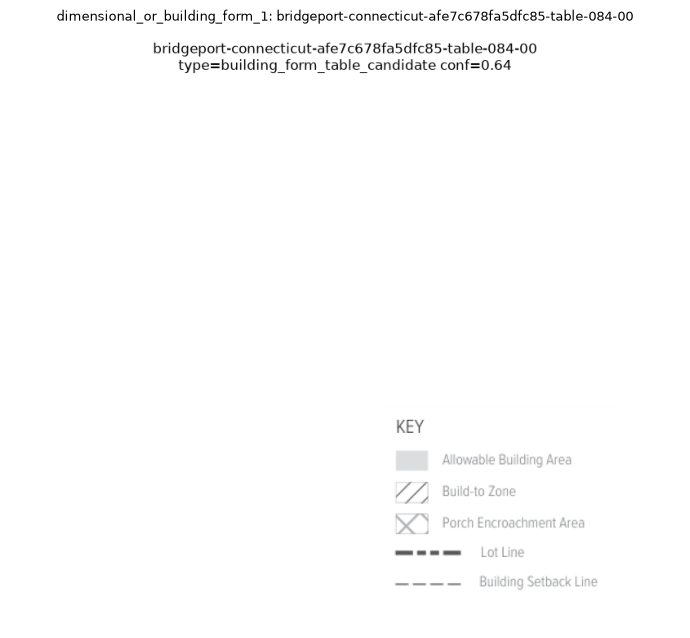

Raw matrix (first 6 rows):
   ['', None, 'KEY\nAllowable Building Area\nBuild-to Zone\nPorch Encroachment Area\nLot Line\nBuilding Setback Line', None, None, None, None, None, None, None, None, None, None, None]
   [None, '', '', None, None, None, None, None, None, None, None, None, None, None]
   [None, '', 'KEY\nAllowable Building Area\nBuild-to Zone\nPorch Encroachment Area\nLot Line', None, None, None, None, None, None, None, None, None, None, None]
   [None, None, None, None, None, None, None, None, '', None, None, None, None, None]
   [None, None, None, None, None, None, None, None, None, '', '', None, None, None]
   [None, None, None, '', None, None, None, None, None, '', None, None, None, None]
MANUAL INSPECTION -- category=dimensional_or_building_form_2  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-116-00  page=116  weak_candidate=False


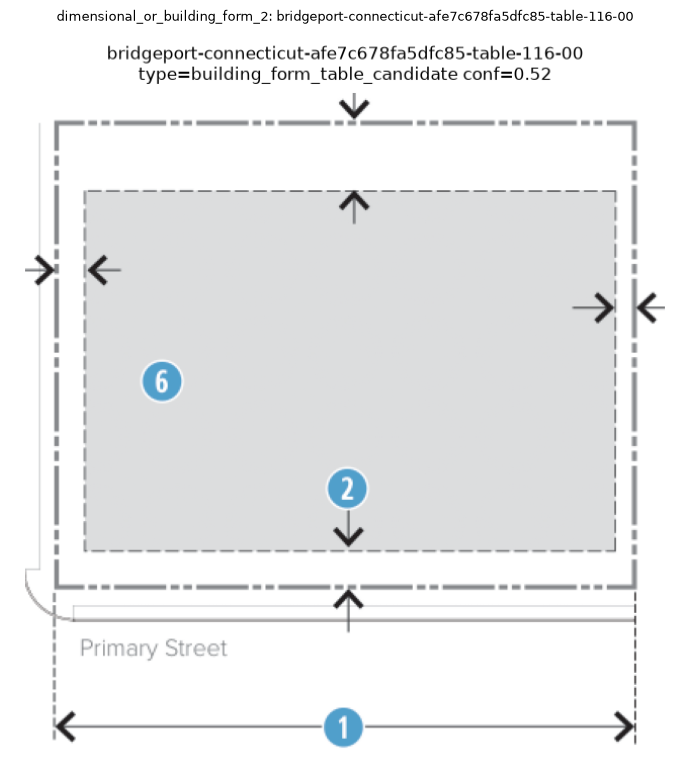

Raw matrix (first 6 rows):
   ['y', None, 'w', None]
   ['Primary Street', None, '', '']
   [None, '', '', '']
   [None, None, '', None]
MANUAL INSPECTION -- category=permitted_use_1  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-241-02  page=241  weak_candidate=False


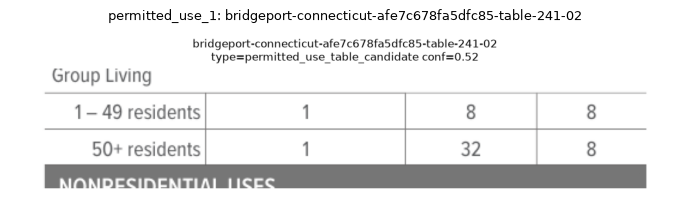

Raw matrix (first 6 rows):
   ['1 – 49 residents', '1', '8', '8']
   ['50+ residents', '1', '32', '8']
MANUAL INSPECTION -- category=permitted_use_2  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-241-00  page=241  weak_candidate=False


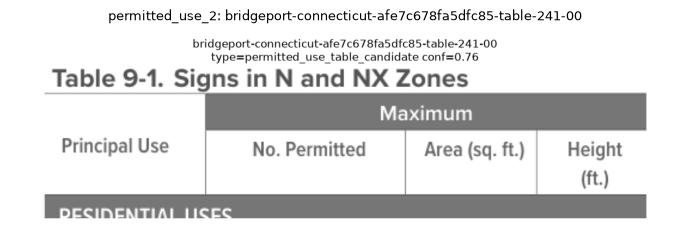

Raw matrix (first 6 rows):
   ['Principal Use', 'Maximum', None, None]
   [None, 'No. Permitted', 'Area (sq. ft.)', 'Height\n(ft.)']
MANUAL INSPECTION -- category=parking_or_mobility  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-030-00  page=30  weak_candidate=False


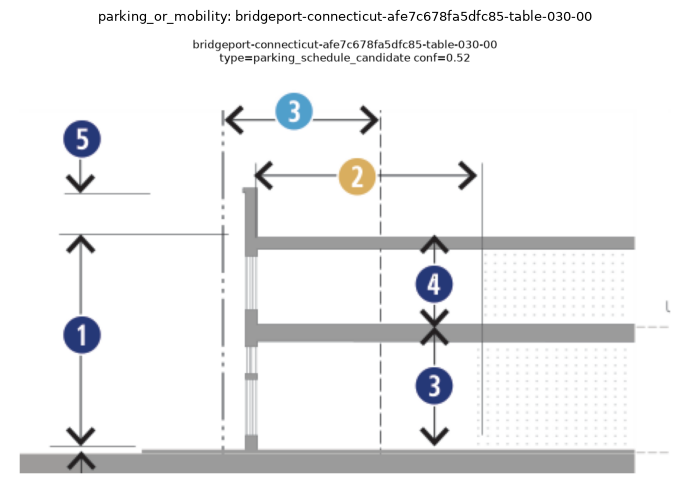

Raw matrix (first 6 rows):
   ['t\nq', None, 'e', None, None, None, None]
   [None, None, 'w', None, None, None, None]
   [None, None, None, 'w', '', None, None]
   [None, 'q', None, '', '', '', '']
   [None, None, None, '', '', 'r', None]
   [None, None, None, '', '', None, None]
MANUAL INSPECTION -- category=complex_layout_page  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-123-00  page=123  weak_candidate=False


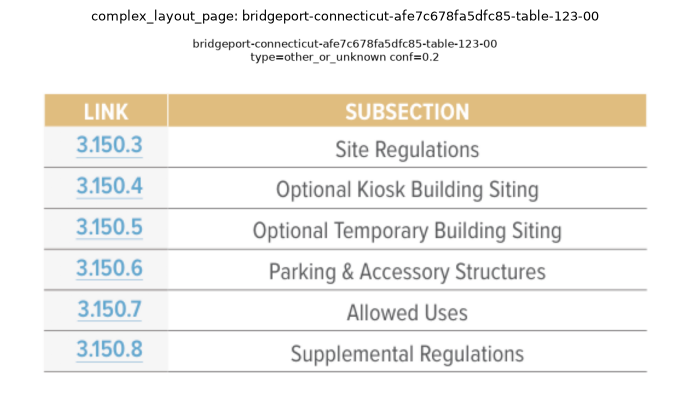

Raw matrix (first 6 rows):
   ['LINK', 'SUBSECTION']
   ['3.150.3', None]
   ['3.150.4', None]
   ['3.150.5', None]
   ['3.150.6', None]
   ['3.150.7', None]
MANUAL INSPECTION -- category=table_dominant_page  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-031-00  page=31  weak_candidate=False


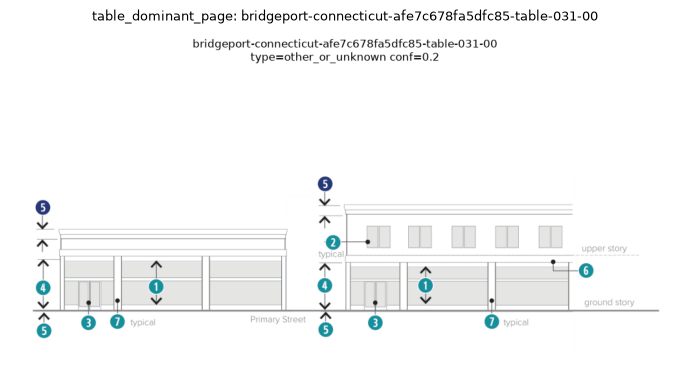

Raw matrix (first 6 rows):
   ['', None, '', None, None, None, None, None, None, None, None, None, None, None, None, None, None]
   [None, None, '', None, None, '', '', '', None, None, '', '', '', None, None, None, None]
   [None, '', '', None, None, '', '', '', None, None, '', '', '', None, None, None, '']
   [None, None, '', '', '', '', '', '', None, None, '', '', '', '', '', '', None]
   ['t\nr', None, None, None, None, '', None, None, None, None, None, None, None, None, None, None, None]
   [None, None, '', None, None, '', None, None, None, '', None, None, None, None, None, None, None]
MANUAL INSPECTION -- category=weak_or_failed_detection  table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-003-00  page=3  weak_candidate=True


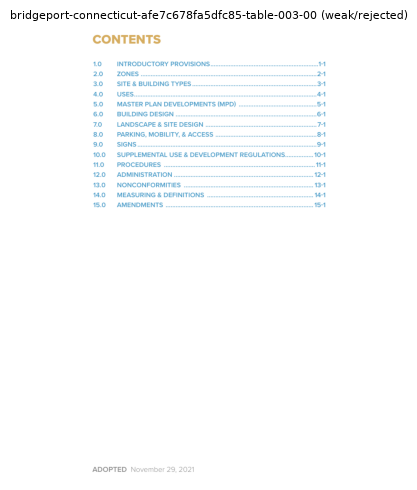

Raw matrix (first 6 rows):
   ['CONTENTS', '', '']
   ['', '', '']
   ['1.0 INTRODUCTOR', 'Y PROVISIONS...............................................................', '..1-1']
   ['', '', '']
   ['2.0 ZONES ..............', '...........................................................................................', '.2-1']
   ['', '', '']

Saved: outputs/review/bridgeport/step_02_table_manual_inspection_log.csv


In [59]:
manual_inspection_targets = {}

dimensional_candidates = table_master_df.loc[
    table_master_df["table_type_candidate"].isin(["dimensional_schedule_candidate", "building_form_table_candidate"])
].sort_values("initial_confidence", ascending=False)
manual_inspection_targets["dimensional_or_building_form_1"] = dimensional_candidates.iloc[0]["table_id"] if len(dimensional_candidates) > 0 else None
manual_inspection_targets["dimensional_or_building_form_2"] = dimensional_candidates.iloc[1]["table_id"] if len(dimensional_candidates) > 1 else None

use_candidates = table_master_df.loc[table_master_df["table_type_candidate"] == "permitted_use_table_candidate"].sort_values(
    "initial_confidence", ascending=False
)
manual_inspection_targets["permitted_use_1"] = use_candidates.iloc[0]["table_id"] if len(use_candidates) > 0 else None
manual_inspection_targets["permitted_use_2"] = use_candidates.iloc[1]["table_id"] if len(use_candidates) > 1 else None

parking_candidates = table_master_df.loc[table_master_df["table_type_candidate"] == "parking_schedule_candidate"]
manual_inspection_targets["parking_or_mobility"] = parking_candidates.iloc[0]["table_id"] if len(parking_candidates) > 0 else None

complex_candidates = table_master_df.loc[table_master_df["complex_layout_context"]]
manual_inspection_targets["complex_layout_page"] = complex_candidates.iloc[0]["table_id"] if len(complex_candidates) > 0 else None

dominant_candidates = table_master_df.loc[table_master_df["table_dominant_page"]]
manual_inspection_targets["table_dominant_page"] = dominant_candidates.iloc[0]["table_id"] if len(dominant_candidates) > 0 else None

weak_candidates = raw_table_candidates_df.loc[~raw_table_candidates_df["is_retained"]].sort_values("initial_confidence")
manual_inspection_targets["weak_or_failed_detection"] = weak_candidates.iloc[0]["table_id"] if len(weak_candidates) > 0 else None

manual_inspection_log_records = []
for category, table_id in manual_inspection_targets.items():
    if table_id is None:
        manual_inspection_log_records.append({
            "category": category, "table_id": None, "page_number": None,
            "inspection_outcome": "not_applicable", "inspection_note": "No table in this category was detected.",
        })
        continue

    is_weak = table_id not in retained_table_ids
    page_number = int(raw_table_candidates_df.loc[raw_table_candidates_df["table_id"] == table_id, "page_number"].iloc[0])
    matrix = table_raw_matrices[table_id]

    print("=" * 100)
    print(f"MANUAL INSPECTION -- category={category}  table_id={table_id}  page={page_number}  weak_candidate={is_weak}")
    print("=" * 100)

    if is_weak:
        crop_source_row = raw_table_candidates_df.loc[raw_table_candidates_df["table_id"] == table_id].iloc[0]
        page_image = render_pdf_page(PDF_PATH, page_number=page_number, zoom=1.5)
        x0, y0 = max(0, int(crop_source_row["bbox_x0"] * 1.5) - 15), max(0, int(crop_source_row["bbox_y0"] * 1.5) - 15)
        x1, y1 = int(crop_source_row["bbox_x1"] * 1.5) + 15, int(crop_source_row["bbox_y1"] * 1.5) + 15
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.imshow(page_image[y0:y1, x0:x1])
        ax.set_title(f"{table_id} (weak/rejected)", fontsize=8)
        ax.axis("off")
        plt.tight_layout()
        weak_crop_path = TABLES_FIGURES_DIR / f"step_02_manual_inspection_{category}.png"
        fig.savefig(weak_crop_path, dpi=150, bbox_inches="tight")
        plt.show()
    else:
        crop_path = render_table_crop(table_id)
        display_saved_image(crop_path, title=f"{category}: {table_id}")

    print("Raw matrix (first 6 rows):")
    for raw_row in matrix[:6]:
        print("  ", raw_row)

    manual_inspection_log_records.append({
        "category": category, "table_id": table_id, "page_number": page_number,
        "inspection_outcome": "pending_agent_review",
        "inspection_note": "Rendered for direct visual inspection; outcome to be finalized after review.",
    })

manual_inspection_log_df = pd.DataFrame(manual_inspection_log_records)
manual_inspection_log_path = REVIEW_DIR / "step_02_table_manual_inspection_log.csv"
manual_inspection_log_df.to_csv(manual_inspection_log_path, index=False)
print(f"\nSaved: {manual_inspection_log_path.relative_to(STAGE_A_ROOT)}")

### 11.10 Stage 2 final report

In [60]:
table_parsing_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "raw_candidate_table_count": int(len(raw_table_candidates_df)),
    "retained_table_count": int(raw_table_candidates_df["is_retained"].sum()),
    "weak_or_rejected_candidate_count": int((~raw_table_candidates_df["is_retained"]).sum()),
    "table_count_by_page_layout_type": table_master_df["page_layout_type"].value_counts().to_dict(),
    "table_type_candidate_counts": table_type_candidates_df["table_type_candidate"].value_counts().to_dict(),
    "header_uncertain_table_count": int(table_header_diagnostics_df["header_uncertain"].sum()),
    "complex_layout_context_table_count": int(table_master_df["complex_layout_context"].sum()),
    "tables_routed_to_manual_review": int(
        table_master_df["review_status"].isin(["retained_low_confidence_review", "retained_complex_layout_review"]).sum()
        + (~raw_table_candidates_df["is_retained"]).sum()
    ),
    "all_stage2_validation_checks_passed": bool(table_validation_df["passed"].all()),
}

table_parsing_log_path = LOGS_DIR / "step_02_table_parsing_log.json"
with table_parsing_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(table_parsing_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 2 (table parsing) COMPLETE")
print("=" * 70)
for key, value in table_parsing_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {table_parsing_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 2 (table parsing) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
raw_candidate_table_count: 392
retained_table_count: 107
weak_or_rejected_candidate_count: 285
table_count_by_page_layout_type: {'single_column': 81, 'table_dominant': 9, 'multi_column_or_complex': 9, 'two_column': 8}
table_type_candidate_counts: {'building_form_table_candidate': 36, 'other_or_unknown': 24, 'permitted_use_table_candidate': 19, 'parking_schedule_candidate': 18, 'dimensional_schedule_candidate': 7, 'overlay_or_historic_table_candidate': 1, 'definitions_table_candidate': 1, 'approval_process_table_candidate': 1}
header_uncertain_table_count: 24
complex_layout_context_table_count: 9
tables_routed_to_manual_review: 318
all_stage2_validation_checks_passed: True

Saved: outputs/logs/bridgeport/step_02_table_parsing_log.json


## 12. Stage 3 -- District anchors and preliminary taxonomy

This stage discovers zoning-district codes independently from several source types, builds a raw
candidate table that keeps every detection (with its source and confidence), and only then
collapses candidates into one canonical registry row per code. Classification into a
**preliminary** category is always backed by the actual narrative text found in the source, never
by the code's own prefix or a bare regex -- `N1`/`N2`/`N3` are not assumed residential because
they start with `N`; they are classified `BASE_CANDIDATE` because their real narrative name
("Neighborhood: Traditional", etc.) says so.

**Source types used for discovery:**
1. GIS `ZONE_2021` categorical values (a lightweight preview read here; full GIS validation,
   CRS handling, and dissolve happen in Stage 7).
2. Narrative district definitions -- the `"A. N1, Neighborhood: Traditional. ..."` pattern found
   during Stage 1/1.5 inspection, matched against the repaired-order `Paragraph` nodes.
3. Hierarchy headings -- Section/Subsection/Title text starting with an already-evidenced code.
4. Table row/column labels and cell values -- exact matches against already-evidenced codes.
5. General-rule prose mentions -- `Body`-level lines near the words "zone"/"district" that
   mention an already-evidenced code (one per code/page, deduplicated).

Headings, tables, and general-prose mentions are treated as **corroboration** of a code already
evidenced by GIS or narrative text, not as independent code-discovery passes. This is a
deliberate, conservative design choice: a bare `^[A-Z]{1,4}[0-9]{0,2}$` regex run over all heading
or body text would invent far too many false-positive "codes" from ordinary capitalized
abbreviations (`ADU`, `MPD`, ...). Source type 5 from the original request ("GIS renderer-
confirmed code labels") is **not available** in this GIS export -- see the note below.

**A real data-quality finding, reported rather than used silently**: the GIS file's `ZONE_`,
`ZONE_ID`, `SUMMARY_CAT`, and `CHAR1` fields (e.g. `ZONE_2021="N3"` paired with
`ZONE_="Residential - AA Single Family Zone"`) are confirmed **legacy, pre-2021 parcel-level
zoning labels carried over from the join**, not descriptions of the current 2021 code. For
example `NX1` (938 of 2,000 features, by far the largest class) carries the legacy label
"Residential - A Single Family Zone," while the ordinance's own narrative text (Stage 1, p.11)
describes `NX1` as "Neighborhood Mix." Using the legacy fields as if they described the current
code would be a fabrication risk, so they are captured separately (for audit only, not used for
category evidence) and never treated as the "GIS renderer-confirmed label" the task asked for.

In [61]:
GIS_PATH = RAW_DIR / "gis" / "bridgeport_zoning_districts_2021.geojson"

import geopandas as gpd

bridgeport_gis_preview_gdf = gpd.read_file(GIS_PATH)
print(f"GIS preview load: {len(bridgeport_gis_preview_gdf):,} features, CRS={bridgeport_gis_preview_gdf.crs}")

gis_zone_2021_preview_df = (
    bridgeport_gis_preview_gdf.groupby("ZONE_2021").size().reset_index(name="gis_feature_count")
    .rename(columns={"ZONE_2021": "gis_code"})
    .sort_values("gis_feature_count", ascending=False)
)
print(gis_zone_2021_preview_df.to_string(index=False))

gis_legacy_label_audit_df = (
    bridgeport_gis_preview_gdf[["ZONE_2021", "ZONE_ID", "ZONE_", "SUMMARY_CAT", "CHAR1"]]
    .drop_duplicates(subset=["ZONE_2021"]).rename(columns={"ZONE_2021": "gis_code"}).sort_values("gis_code")
)
gis_legacy_label_audit_path = REVIEW_DIR / "step_03_gis_legacy_label_audit.csv"
gis_legacy_label_audit_df.to_csv(gis_legacy_label_audit_path, index=False)
print(f"\nSaved (audit only, NOT used for category evidence): {gis_legacy_label_audit_path.relative_to(STAGE_A_ROOT)}")

GIS preview load: 2,000 features, CRS=EPSG:4326
gis_code  gis_feature_count
     NX1                938
      N2                272
     NX2                222
      N3                195
      N1                101
     RX1                 76
     MX1                 59
      P2                 36
      P1                 28
     NX3                 26
       I                 20
     RX2                 15
      P4                  6
     MXN                  4
      IX                  1
     NX4                  1

Saved (audit only, NOT used for category evidence): outputs/review/bridgeport/step_03_gis_legacy_label_audit.csv


In [62]:
import itertools

CODE_TOKEN_PATTERN = re.compile(r"^[A-Z]{1,4}[0-9]{0,2}$")
NARRATIVE_DEFINITION_PATTERN = re.compile(r"^[A-Z]\.\s*([A-Z]{1,4}[0-9]{0,2}),\s*([A-Za-z][^.]{1,90}?)\.\s")

district_candidate_records = []
_candidate_counter = itertools.count(1)


def next_candidate_id() -> str:
    return f"{DOCUMENT_ID}-district-candidate-{next(_candidate_counter):05d}"


# Source type 1: GIS ZONE_2021 categorical values.
for _, row in gis_zone_2021_preview_df.iterrows():
    district_candidate_records.append({
        "candidate_id": next_candidate_id(), "candidate_code": row["gis_code"], "candidate_name": "",
        "source_type": "gis_zone_2021", "source_page": None, "hierarchy_node_id": "", "table_id": "",
        "gis_code": row["gis_code"],
        "source_excerpt": f"GIS ZONE_2021 categorical value, {int(row['gis_feature_count'])} features",
        "candidate_pattern_family": "gis_categorical_value", "detection_confidence": 0.9,
        "rationale": "exact_value_in_ZONE_2021_field_of_official_FeatureServer_export",
        "layout_context": "n/a", "review_status": "auto_detected",
    })

# Source type 2: narrative district definitions (repaired-order Paragraph nodes).
paragraph_rows = heading_candidates_repaired_df.loc[heading_candidates_repaired_df["node_type"] == "Paragraph"]
for _, row in paragraph_rows.iterrows():
    match = NARRATIVE_DEFINITION_PATTERN.match(row["text"])
    if not match:
        continue
    code, name = match.group(1), match.group(2).strip()
    if not CODE_TOKEN_PATTERN.match(code):
        continue
    layout_row = layout_lookup_full.loc[row["page_number"]] if row["page_number"] in layout_lookup_full.index else None
    district_candidate_records.append({
        "candidate_id": next_candidate_id(), "candidate_code": code, "candidate_name": name,
        "source_type": "narrative_definition", "source_page": int(row["page_number"]),
        "hierarchy_node_id": row["node_id"], "table_id": "", "gis_code": "",
        "source_excerpt": row["text"][:300], "candidate_pattern_family": "narrative_lettered_definition",
        "detection_confidence": round(min(0.9, 0.7 + (0.1 if row["heading_confidence"] >= 0.7 else 0.0)), 3),
        "rationale": "lettered_paragraph_matches_'CODE,_Name.'_pattern",
        "layout_context": layout_row["page_layout_type"] if layout_row is not None else "single_column",
        "review_status": "auto_detected",
    })

# Source type 2b: a second narrative pattern specifically for overlay/special-purpose zones,
# which this document introduces differently from base zones -- not "A. <CODE>, <Name>." but
# "A. Intent. The <Name> (<CODE>) zone is intended to ..." (confirmed by direct inspection: the
# Historic Overlay zone on page 12 uses this exact phrasing and does not match the base pattern
# above at all). Searched across the full repaired hierarchy; only one match was found (OH).
NARRATIVE_OVERLAY_INTENT_PATTERN = re.compile(
    r"The ([A-Za-z][A-Za-z0-9 &/\-]{2,60}?)\s*\(([A-Z]{1,4}[0-9]{0,2})\)\s+zone"
)

for _, row in heading_candidates_repaired_df.iterrows():
    match = NARRATIVE_OVERLAY_INTENT_PATTERN.search(row["text"])
    if not match:
        continue
    name, code = match.group(1).strip(), match.group(2)
    if not CODE_TOKEN_PATTERN.match(code):
        continue
    layout_row = layout_lookup_full.loc[row["page_number"]] if row["page_number"] in layout_lookup_full.index else None
    district_candidate_records.append({
        "candidate_id": next_candidate_id(), "candidate_code": code, "candidate_name": name,
        "source_type": "narrative_definition", "source_page": int(row["page_number"]),
        "hierarchy_node_id": row["node_id"], "table_id": "", "gis_code": "",
        "source_excerpt": row["text"][:300], "candidate_pattern_family": "narrative_overlay_intent_definition",
        "detection_confidence": 0.85,
        "rationale": "'The_Name_(CODE)_zone'_intent-paragraph_pattern_for_overlay/special-purpose_zones",
        "layout_context": layout_row["page_layout_type"] if layout_row is not None else "single_column",
        "review_status": "auto_detected",
    })

known_code_pool = sorted({rec["candidate_code"] for rec in district_candidate_records})
print(f"Known code pool after GIS + narrative passes: {len(known_code_pool)} codes")
print(known_code_pool)

Known code pool after GIS + narrative passes: 24 codes
['CX', 'DX1', 'DX2', 'I', 'IX', 'MX1', 'MX2', 'MXN', 'N1', 'N2', 'N3', 'N4', 'NX1', 'NX2', 'NX3', 'NX4', 'OH', 'P1', 'P2', 'P3', 'P4', 'P5', 'RX1', 'RX2']


In [63]:
# Source type 3: hierarchy headings (Section/Subsection/Title) starting with an already-evidenced code.
heading_pattern_by_code = {code: re.compile(rf"^{re.escape(code)}\b") for code in known_code_pool}
non_paragraph_headings = heading_candidates_repaired_df.loc[heading_candidates_repaired_df["node_type"] != "Paragraph"]

for _, row in non_paragraph_headings.iterrows():
    text = row["text"].strip()
    for code in known_code_pool:
        if heading_pattern_by_code[code].match(text):
            layout_row = layout_lookup_full.loc[row["page_number"]] if row["page_number"] in layout_lookup_full.index else None
            district_candidate_records.append({
                "candidate_id": next_candidate_id(), "candidate_code": code, "candidate_name": "",
                "source_type": "heading", "source_page": int(row["page_number"]),
                "hierarchy_node_id": row["node_id"], "table_id": "", "gis_code": "",
                "source_excerpt": text[:300], "candidate_pattern_family": "heading_prefix_match",
                "detection_confidence": 0.6, "rationale": "heading_text_starts_with_already_evidenced_code",
                "layout_context": layout_row["page_layout_type"] if layout_row is not None else "single_column",
                "review_status": "auto_detected",
            })
            break

# Source type 4: table row/column labels and raw cell values, exact match.
for code in known_code_pool:
    exact_matches = table_cells_df.loc[table_cells_df["clean_cell_value"] == code]
    for _, row in exact_matches.iterrows():
        district_candidate_records.append({
            "candidate_id": next_candidate_id(), "candidate_code": code, "candidate_name": "",
            "source_type": "table_cell", "source_page": int(row["page_number"]),
            "hierarchy_node_id": "", "table_id": row["table_id"], "gis_code": "",
            "source_excerpt": f"row_label={row['row_label']!r} column_label={row['column_label']!r}",
            "candidate_pattern_family": "table_cell_exact_match", "detection_confidence": 0.55,
            "rationale": "exact_cell_text_match_against_already_evidenced_code",
            "layout_context": row["layout_type"], "review_status": "auto_detected",
        })

print(f"Candidates after heading + table passes: {len(district_candidate_records)}")

Candidates after heading + table passes: 107


In [64]:
# Source type 5: general-rule prose mentions near "zone"/"district" (Body-level lines).
body_rows = layout_ordered_lines_df.loc[layout_ordered_lines_df["node_type"] == "Body"].copy()
zone_keyword_mask = body_rows["text"].str.contains(r"\bzone|\bdistrict", case=False, regex=True, na=False)
zone_context_body_rows = body_rows.loc[zone_keyword_mask]
print(f"Body lines mentioning 'zone'/'district': {len(zone_context_body_rows):,} of {len(body_rows):,} total body lines")

code_word_pattern_by_code = {code: re.compile(rf"\b{re.escape(code)}\b") for code in known_code_pool}

for _, row in zone_context_body_rows.iterrows():
    text = row["text"]
    for code in known_code_pool:
        if code_word_pattern_by_code[code].search(text):
            layout_row = layout_lookup_full.loc[row["page_number"]] if row["page_number"] in layout_lookup_full.index else None
            district_candidate_records.append({
                "candidate_id": next_candidate_id(), "candidate_code": code, "candidate_name": "",
                "source_type": "general_rule_mention", "source_page": int(row["page_number"]),
                "hierarchy_node_id": "", "table_id": "", "gis_code": "",
                "source_excerpt": text[:300], "candidate_pattern_family": "prose_mention_near_zone_keyword",
                "detection_confidence": 0.4, "rationale": "already_evidenced_code_mentioned_near_zone/district_keyword",
                "layout_context": layout_row["page_layout_type"] if layout_row is not None else "single_column",
                "review_status": "auto_detected",
            })

district_candidates_raw_df = pd.DataFrame(district_candidate_records)

mention_mask = district_candidates_raw_df["source_type"] == "general_rule_mention"
deduped_mentions = district_candidates_raw_df.loc[mention_mask].drop_duplicates(subset=["candidate_code", "source_page"], keep="first")
district_candidates_raw_df = pd.concat(
    [district_candidates_raw_df.loc[~mention_mask], deduped_mentions], ignore_index=True
)

print(f"Total raw district candidates (after general-mention dedup): {len(district_candidates_raw_df):,}")
print(district_candidates_raw_df["source_type"].value_counts())

raw_district_candidates_path = TABLES_DIR / "step_03_raw_district_candidates.csv"
district_candidates_raw_df.to_csv(raw_district_candidates_path, index=False)
print(f"Saved: {raw_district_candidates_path.relative_to(STAGE_A_ROOT)}")

Body lines mentioning 'zone'/'district': 582 of 22,020 total body lines
Total raw district candidates (after general-mention dedup): 203
source_type
general_rule_mention    96
table_cell              66
narrative_definition    25
gis_zone_2021           16
Name: count, dtype: int64
Saved: outputs/tables/bridgeport/step_03_raw_district_candidates.csv


### 12.1 Canonical district registry

One row per unique candidate code, built only from the evidence actually collected above --
never from the code string's own prefix pattern.

In [65]:
DISTRICT_CATEGORY_KEYWORDS = {
    "OVERLAY_OR_HISTORIC_CANDIDATE": ["historic", "overlay"],
    "PUBLIC_OR_INSTITUTIONAL_CANDIDATE": [
        "park", "civic", "institutional", "utility", "detention", "correction", "energy infrastructure",
    ],
    "NONRESIDENTIAL_CANDIDATE": ["industrial", "office-industrial"],
    "BASE_CANDIDATE": ["neighborhood", "residential", "mixed residential"],
}

registry_records = []
for code, group in district_candidates_raw_df.groupby("candidate_code"):
    narrative_rows = group.loc[group["source_type"] == "narrative_definition"]
    heading_rows = group.loc[group["source_type"] == "heading"]
    table_rows = group.loc[group["source_type"] == "table_cell"]
    gis_rows = group.loc[group["source_type"] == "gis_zone_2021"]

    district_name = narrative_rows.iloc[0]["candidate_name"] if len(narrative_rows) else ""
    aliases = sorted({n for n in narrative_rows["candidate_name"].tolist() if n})

    gis_presence = bool(len(gis_rows))
    gis_feature_count = int(
        gis_zone_2021_preview_df.loc[gis_zone_2021_preview_df["gis_code"] == code, "gis_feature_count"].sum()
    )
    source_pages = sorted({int(p) for p in group["source_page"].dropna().unique()})

    name_lower = district_name.lower()
    category, category_rationale = "UNCERTAIN", ""
    for candidate_category, keywords in DISTRICT_CATEGORY_KEYWORDS.items():
        if any(keyword in name_lower for keyword in keywords):
            category = candidate_category
            category_rationale = f"narrative name {district_name!r} contains keyword signal for {candidate_category}"
            break
    if category == "UNCERTAIN":
        category_rationale = (
            "no narrative source text available to classify (GIS/table/heading-only code)"
            if not district_name else f"narrative name {district_name!r} did not match any keyword rule"
        )

    confidence = round(min(0.95, 0.3
        + (0.3 if len(narrative_rows) else 0.0)
        + (0.15 if len(table_rows) else 0.0)
        + (0.1 if len(heading_rows) else 0.0)
        + (0.15 if gis_presence else 0.0)
    ), 3)

    registry_records.append({
        "district_id": f"{DOCUMENT_ID}-district-{code}", "district_code": code, "district_name": district_name,
        "aliases": json.dumps(aliases), "heading_source_count": int(len(heading_rows)),
        "table_source_count": int(len(table_rows)), "gis_source_count": int(len(gis_rows)),
        "narrative_source_count": int(len(narrative_rows)), "source_pages": json.dumps(source_pages),
        "gis_presence": gis_presence, "gis_feature_count": gis_feature_count,
        "preliminary_district_category": category, "confidence": confidence, "rationale": category_rationale,
        "duplicate_resolution_rule": "grouped_by_exact_candidate_code_string",
        "review_status": "auto_classified" if category != "UNCERTAIN" else "needs_review",
    })

district_registry_df = pd.DataFrame(registry_records).sort_values("district_code").reset_index(drop=True)
print(f"Canonical district registry: {len(district_registry_df)} unique codes")
print(district_registry_df[["district_code", "district_name", "preliminary_district_category", "confidence", "gis_presence"]].to_string(index=False))

district_registry_path = TABLES_DIR / "step_03_district_registry.csv"
district_registry_df.to_csv(district_registry_path, index=False)
print(f"\nSaved: {district_registry_path.relative_to(STAGE_A_ROOT)}")

Canonical district registry: 24 unique codes
district_code                       district_name     preliminary_district_category  confidence  gis_presence
           CX                    Heavy Commercial                         UNCERTAIN        0.75         False
          DX1                       Downtown Core                         UNCERTAIN        0.75         False
          DX2                    Downtown Support                         UNCERTAIN        0.75         False
            I                          Industrial          NONRESIDENTIAL_CANDIDATE        0.90          True
           IX           Office-Industrial Centers          NONRESIDENTIAL_CANDIDATE        0.90          True
          MX1                  Mixed-Use Corridor                         UNCERTAIN        0.90          True
          MX2                   Mixed-Use Centers                         UNCERTAIN        0.75         False
          MXN      Mixed-Use Neighborhood Corners                    BASE_C

### 12.2 GIS/ordinance crosswalk status and review queues

In [66]:
ordinance_codes = set(district_registry_df.loc[
    (district_registry_df["narrative_source_count"] > 0)
    | (district_registry_df["heading_source_count"] > 0)
    | (district_registry_df["table_source_count"] > 0),
    "district_code",
])
gis_codes = set(district_registry_df.loc[district_registry_df["gis_presence"], "district_code"])

gis_only_codes_df = district_registry_df.loc[district_registry_df["district_code"].isin(gis_codes - ordinance_codes)]
ordinance_only_codes_df = district_registry_df.loc[district_registry_df["district_code"].isin(ordinance_codes - gis_codes)]
ambiguous_codes_df = district_registry_df.loc[district_registry_df["aliases"].apply(lambda a: len(json.loads(a)) > 1)]
uncertain_taxonomy_df = district_registry_df.loc[district_registry_df["preliminary_district_category"] == "UNCERTAIN"]

gis_only_path = REVIEW_DIR / "step_03_gis_only_codes.csv"
ordinance_only_path = REVIEW_DIR / "step_03_ordinance_only_codes.csv"
ambiguous_path = REVIEW_DIR / "step_03_ambiguous_codes.csv"
uncertain_path = REVIEW_DIR / "step_03_uncertain_taxonomy_entries.csv"

gis_only_codes_df.to_csv(gis_only_path, index=False)
ordinance_only_codes_df.to_csv(ordinance_only_path, index=False)
ambiguous_codes_df.to_csv(ambiguous_path, index=False)
uncertain_taxonomy_df.to_csv(uncertain_path, index=False)

print(f"GIS-only codes (in GIS, not evidenced in ordinance text): {len(gis_only_codes_df)} -- {sorted(gis_only_codes_df['district_code'])}")
print(f"Ordinance-only codes (evidenced in text, not in this GIS export): {len(ordinance_only_codes_df)} -- {sorted(ordinance_only_codes_df['district_code'])}")
print(f"Ambiguous codes (multiple distinct narrative names): {len(ambiguous_codes_df)}")
print(f"Uncertain-taxonomy entries: {len(uncertain_taxonomy_df)}")
for path in [gis_only_path, ordinance_only_path, ambiguous_path, uncertain_path]:
    print(f"Saved: {path.relative_to(STAGE_A_ROOT)}")

GIS-only codes (in GIS, not evidenced in ordinance text): 0 -- []
Ordinance-only codes (evidenced in text, not in this GIS export): 8 -- ['CX', 'DX1', 'DX2', 'MX2', 'N4', 'OH', 'P3', 'P5']
Ambiguous codes (multiple distinct narrative names): 3
Uncertain-taxonomy entries: 7
Saved: outputs/review/bridgeport/step_03_gis_only_codes.csv
Saved: outputs/review/bridgeport/step_03_ordinance_only_codes.csv
Saved: outputs/review/bridgeport/step_03_ambiguous_codes.csv
Saved: outputs/review/bridgeport/step_03_uncertain_taxonomy_entries.csv


### 12.3 Required visuals

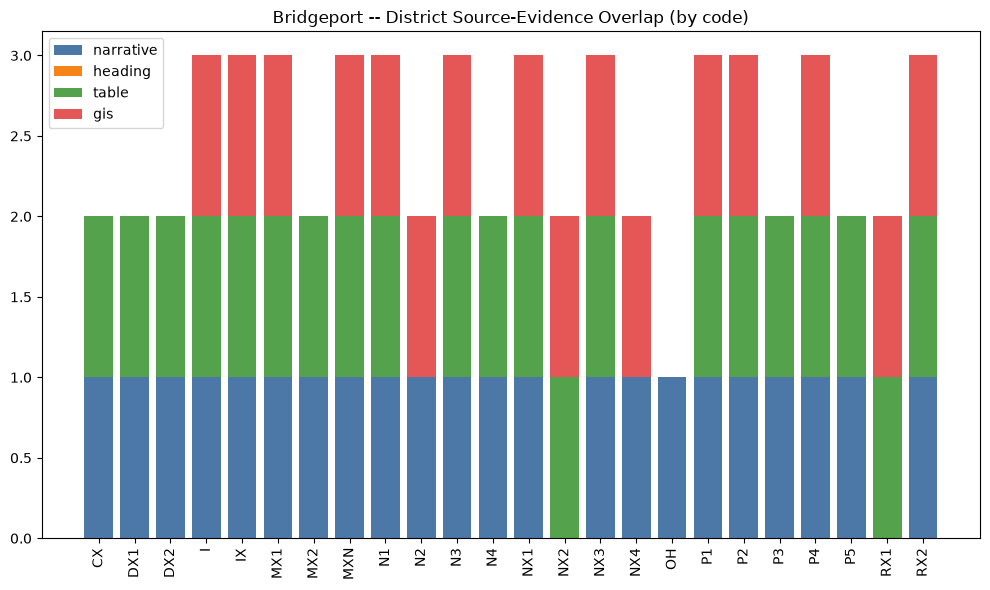

Saved: outputs/figures/bridgeport/step_03_source_evidence_overlap.png


In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
source_presence = district_registry_df.set_index("district_code")[
    ["narrative_source_count", "heading_source_count", "table_source_count", "gis_source_count"]
].gt(0)
bottom = np.zeros(len(source_presence))
colors = {"narrative_source_count": "#4C78A8", "heading_source_count": "#F58518",
          "table_source_count": "#54A24B", "gis_source_count": "#E45756"}
for column in source_presence.columns:
    values = source_presence[column].astype(int).values
    ax.bar(source_presence.index, values, bottom=bottom, label=column.replace("_source_count", ""), color=colors[column])
    bottom += values
ax.set_title("Bridgeport -- District Source-Evidence Overlap (by code)", fontsize=12)
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
overlap_chart_path = FIGURES_DIR / "step_03_source_evidence_overlap.png"
fig.savefig(overlap_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {overlap_chart_path.relative_to(STAGE_A_ROOT)}")

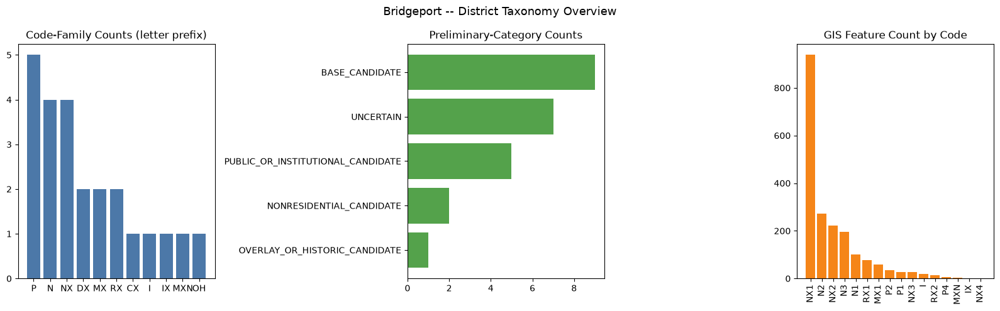

Saved: outputs/figures/bridgeport/step_03_taxonomy_overview.png


In [68]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

code_family = district_registry_df["district_code"].str.extract(r"^([A-Z]+)")[0]
family_counts = code_family.value_counts()
axes[0].bar(family_counts.index, family_counts.values, color="#4C78A8")
axes[0].set_title("Code-Family Counts (letter prefix)")

category_counts = district_registry_df["preliminary_district_category"].value_counts()
axes[1].barh(category_counts.index[::-1], category_counts.values[::-1], color="#54A24B")
axes[1].set_title("Preliminary-Category Counts")

gis_sorted = gis_zone_2021_preview_df.sort_values("gis_feature_count", ascending=False)
axes[2].bar(gis_sorted["gis_code"], gis_sorted["gis_feature_count"], color="#F58518")
axes[2].set_title("GIS Feature Count by Code")
axes[2].tick_params(axis="x", rotation=90)

plt.suptitle("Bridgeport -- District Taxonomy Overview", fontsize=13)
plt.tight_layout()
taxonomy_overview_path = FIGURES_DIR / "step_03_taxonomy_overview.png"
fig.savefig(taxonomy_overview_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {taxonomy_overview_path.relative_to(STAGE_A_ROOT)}")

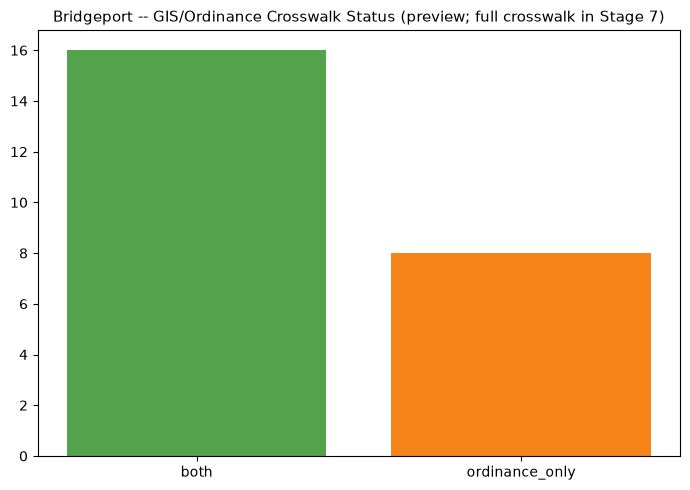

Saved: outputs/figures/bridgeport/step_03_gis_ordinance_crosswalk_status.png
district_code crosswalk_status_preview
           CX           ordinance_only
          DX1           ordinance_only
          DX2           ordinance_only
            I                     both
           IX                     both
          MX1                     both
          MX2           ordinance_only
          MXN                     both
           N1                     both
           N2                     both
           N3                     both
           N4           ordinance_only
          NX1                     both
          NX2                     both
          NX3                     both
          NX4                     both
           OH           ordinance_only
           P1                     both
           P2                     both
           P3           ordinance_only
           P4                     both
           P5           ordinance_only
          RX1             

In [69]:
crosswalk_status = []
for _, row in district_registry_df.iterrows():
    in_gis = row["gis_presence"]
    in_ordinance = row["district_code"] in ordinance_codes
    status = "both" if in_gis and in_ordinance else ("gis_only" if in_gis else "ordinance_only")
    crosswalk_status.append(status)
district_registry_df["crosswalk_status_preview"] = crosswalk_status

fig, ax = plt.subplots(figsize=(7, 5))
status_counts = district_registry_df["crosswalk_status_preview"].value_counts()
ax.bar(status_counts.index, status_counts.values, color=["#54A24B", "#F58518", "#E45756"][:len(status_counts)])
ax.set_title("Bridgeport -- GIS/Ordinance Crosswalk Status (preview; full crosswalk in Stage 7)", fontsize=11)
plt.tight_layout()
crosswalk_status_path = FIGURES_DIR / "step_03_gis_ordinance_crosswalk_status.png"
fig.savefig(crosswalk_status_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {crosswalk_status_path.relative_to(STAGE_A_ROOT)}")
print(district_registry_df[["district_code", "crosswalk_status_preview"]].to_string(index=False))

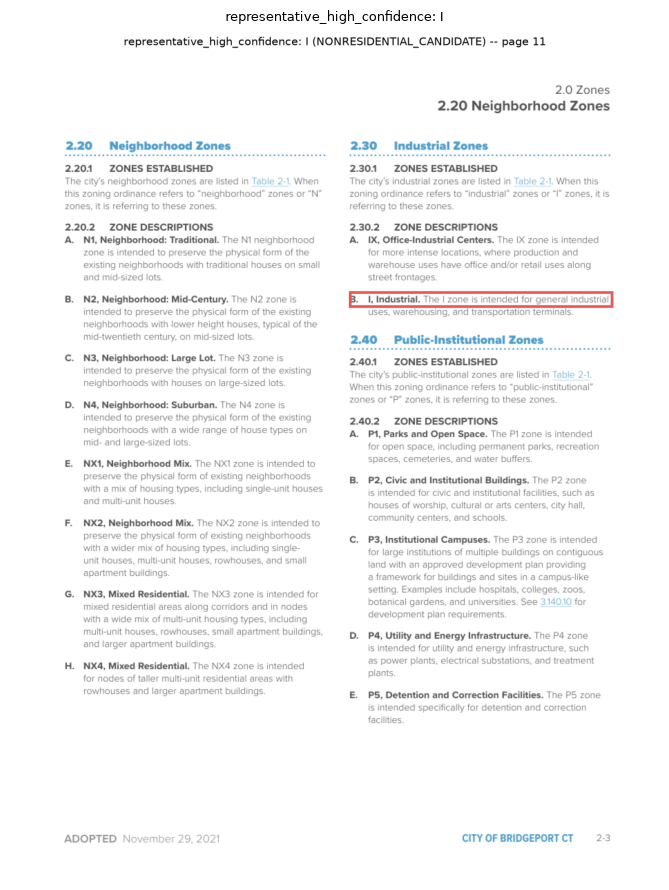

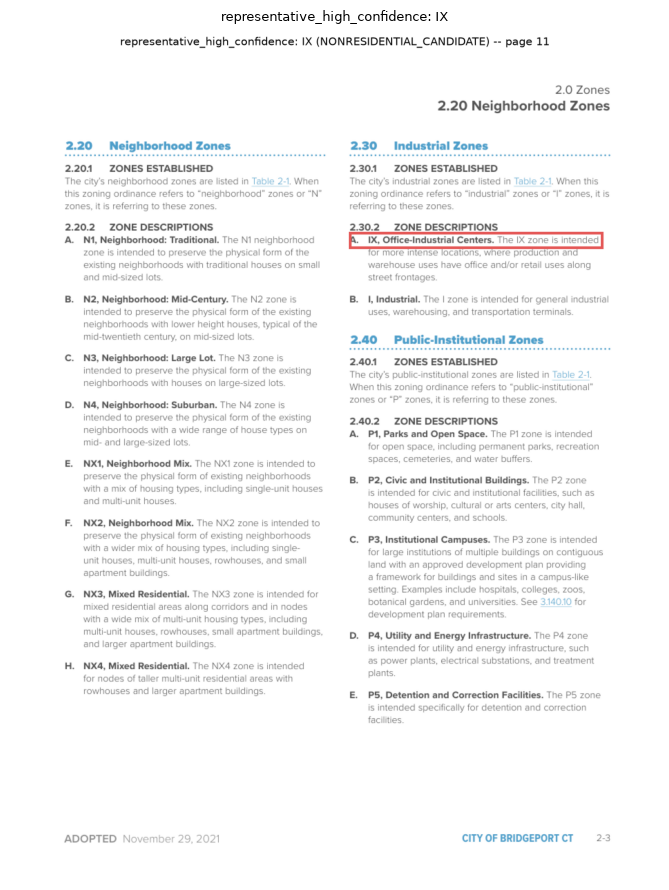

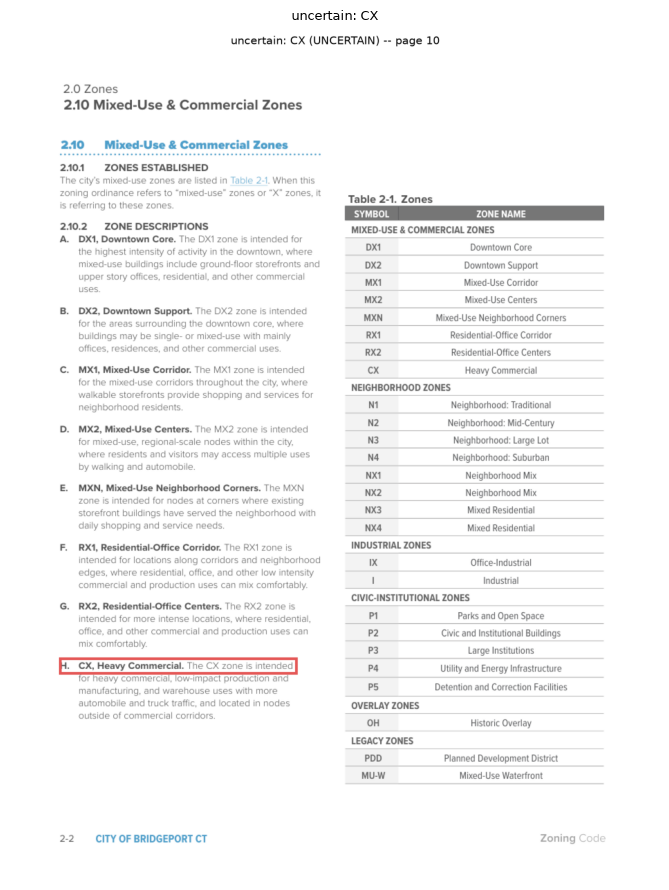

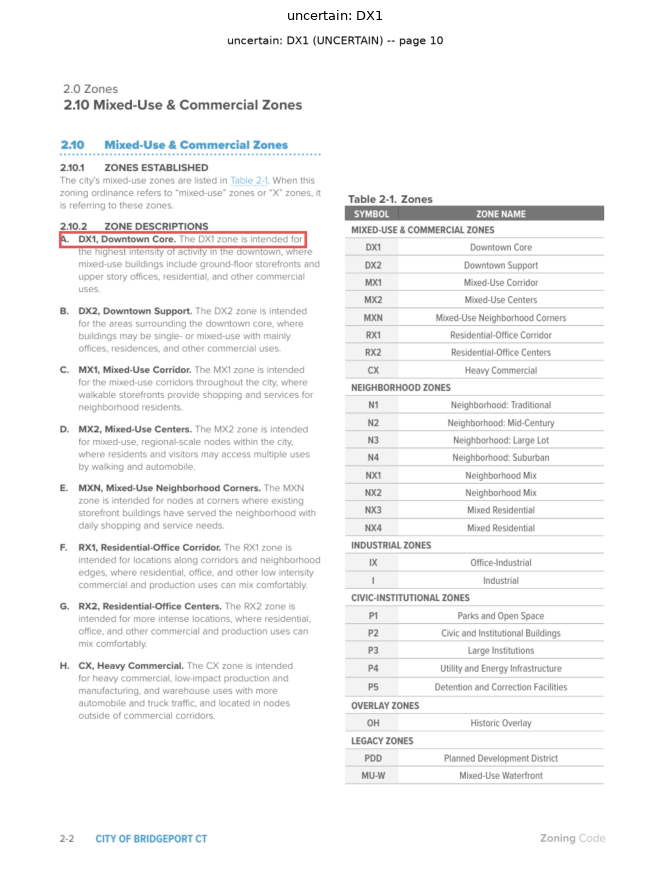

In [70]:
def render_bbox_highlight(page_number: int, bbox: tuple, label: str, save_name: str, zoom: float = 1.5) -> Path:
    page_image = render_pdf_page(PDF_PATH, page_number=page_number, zoom=zoom)
    fig, ax = plt.subplots(figsize=(8.5, 11))
    ax.imshow(page_image)
    rect = plt.Rectangle(
        (bbox[0] * zoom, bbox[1] * zoom), (bbox[2] - bbox[0]) * zoom, (bbox[3] - bbox[1]) * zoom,
        linewidth=2.5, edgecolor="#E45756", facecolor="none",
    )
    ax.add_patch(rect)
    ax.set_title(f"{label} -- page {page_number}", fontsize=10)
    ax.axis("off")
    plt.tight_layout()
    save_path = TABLES_FIGURES_DIR / save_name
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return save_path


anchor_examples = {
    "representative_high_confidence": district_registry_df.loc[district_registry_df["confidence"] >= 0.85].head(2),
    "uncertain": uncertain_taxonomy_df.head(2),
}

for example_group, rows in anchor_examples.items():
    for _, registry_row in rows.iterrows():
        code = registry_row["district_code"]
        narrative_source = district_candidates_raw_df.loc[
            (district_candidates_raw_df["candidate_code"] == code)
            & (district_candidates_raw_df["source_type"] == "narrative_definition")
        ]
        if len(narrative_source) == 0:
            continue
        source_row = narrative_source.iloc[0]
        node_bbox_row = heading_candidates_repaired_df.loc[heading_candidates_repaired_df["node_id"] == source_row["hierarchy_node_id"]]
        if len(node_bbox_row) == 0:
            continue
        node_bbox_row = node_bbox_row.iloc[0]
        save_path = render_bbox_highlight(
            int(source_row["source_page"]),
            (node_bbox_row["bbox_x0"], node_bbox_row["bbox_y0"], node_bbox_row["bbox_x1"], node_bbox_row["bbox_y1"]),
            f"{example_group}: {code} ({registry_row['preliminary_district_category']})",
            f"step_03_anchor_{example_group}_{code}.png",
        )
        display_saved_image(save_path, title=f"{example_group}: {code}")

### 12.4 Preliminary taxonomy GIS map

**Preliminary only.** This map colors each GIS parcel polygon by the preliminary category
assigned above; it is not a validated zoning map and carries forward every uncertainty already
logged (GIS-only codes, uncertain-taxonomy codes, and the legacy-label caveat above).

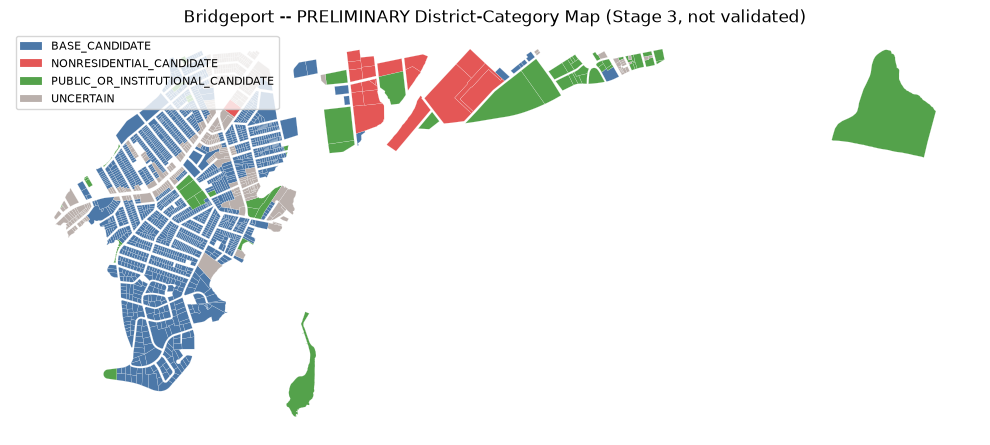

Saved: outputs/figures/bridgeport/step_03_preliminary_taxonomy_map.png


In [71]:
category_by_code = district_registry_df.set_index("district_code")["preliminary_district_category"].to_dict()
bridgeport_gis_preview_gdf["preliminary_category_preview"] = bridgeport_gis_preview_gdf["ZONE_2021"].map(category_by_code).fillna("UNCERTAIN")

category_color_map = {
    "BASE_CANDIDATE": "#4C78A8", "NONRESIDENTIAL_CANDIDATE": "#E45756",
    "PUBLIC_OR_INSTITUTIONAL_CANDIDATE": "#54A24B", "OVERLAY_OR_HISTORIC_CANDIDATE": "#B279A2",
    "LEGACY_CANDIDATE": "#9D755D", "UNCERTAIN": "#BAB0AC",
}

fig, ax = plt.subplots(figsize=(10, 10))
for category, color in category_color_map.items():
    subset = bridgeport_gis_preview_gdf.loc[bridgeport_gis_preview_gdf["preliminary_category_preview"] == category]
    if len(subset):
        subset.plot(ax=ax, color=color, label=category, edgecolor="white", linewidth=0.1)

ax.set_title("Bridgeport -- PRELIMINARY District-Category Map (Stage 3, not validated)", fontsize=12)
ax.legend(loc="upper left", fontsize=8)
ax.set_axis_off()
plt.tight_layout()
preliminary_map_path = FIGURES_DIR / "step_03_preliminary_taxonomy_map.png"
fig.savefig(preliminary_map_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {preliminary_map_path.relative_to(STAGE_A_ROOT)}")

### 12.5 Manual inspection log (Stage 3)

In [72]:
district_manual_inspection_records = []
for _, registry_row in district_registry_df.sort_values("confidence", ascending=False).head(3).iterrows():
    district_manual_inspection_records.append({
        "category": "representative_high_confidence", "district_code": registry_row["district_code"],
        "preliminary_district_category": registry_row["preliminary_district_category"],
        "inspection_outcome": "pending_agent_review",
        "inspection_note": "Rendered for direct visual inspection; outcome to be finalized after review.",
    })
for _, registry_row in uncertain_taxonomy_df.head(3).iterrows():
    district_manual_inspection_records.append({
        "category": "uncertain_taxonomy", "district_code": registry_row["district_code"],
        "preliminary_district_category": registry_row["preliminary_district_category"],
        "inspection_outcome": "pending_agent_review",
        "inspection_note": "Rendered for direct visual inspection; outcome to be finalized after review.",
    })

district_manual_inspection_df = pd.DataFrame(district_manual_inspection_records)
district_manual_inspection_path = REVIEW_DIR / "step_03_district_manual_inspection_log.csv"
district_manual_inspection_df.to_csv(district_manual_inspection_path, index=False)
print(f"Saved: {district_manual_inspection_path.relative_to(STAGE_A_ROOT)}")
print(district_manual_inspection_df.to_string(index=False))

Saved: outputs/review/bridgeport/step_03_district_manual_inspection_log.csv
                      category district_code     preliminary_district_category   inspection_outcome                                                              inspection_note
representative_high_confidence           NX1                    BASE_CANDIDATE pending_agent_review Rendered for direct visual inspection; outcome to be finalized after review.
representative_high_confidence            N1                    BASE_CANDIDATE pending_agent_review Rendered for direct visual inspection; outcome to be finalized after review.
representative_high_confidence            P4 PUBLIC_OR_INSTITUTIONAL_CANDIDATE pending_agent_review Rendered for direct visual inspection; outcome to be finalized after review.
            uncertain_taxonomy            CX                         UNCERTAIN pending_agent_review Rendered for direct visual inspection; outcome to be finalized after review.
            uncertain_taxonomy         

### 12.6 Stage 3 final summary

In [73]:
stage_3_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "raw_district_candidate_count": int(len(district_candidates_raw_df)),
    "raw_candidates_by_source_type": district_candidates_raw_df["source_type"].value_counts().to_dict(),
    "canonical_district_count": int(len(district_registry_df)),
    "preliminary_category_counts": district_registry_df["preliminary_district_category"].value_counts().to_dict(),
    "gis_only_code_count": int(len(gis_only_codes_df)),
    "ordinance_only_code_count": int(len(ordinance_only_codes_df)),
    "ambiguous_code_count": int(len(ambiguous_codes_df)),
    "uncertain_taxonomy_count": int(len(uncertain_taxonomy_df)),
    "gis_renderer_confirmed_labels_available": False,
    "gis_legacy_label_note": "ZONE_/ZONE_ID/SUMMARY_CAT/CHAR1 are pre-2021 legacy parcel labels; audited separately, not used as category evidence.",
}

stage_3_log_path = LOGS_DIR / "step_03_district_taxonomy_log.json"
with stage_3_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_3_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 3 (district anchors and taxonomy) COMPLETE")
print("=" * 70)
for key, value in stage_3_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_3_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 3 (district anchors and taxonomy) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
raw_district_candidate_count: 203
raw_candidates_by_source_type: {'general_rule_mention': 96, 'table_cell': 66, 'narrative_definition': 25, 'gis_zone_2021': 16}
canonical_district_count: 24
preliminary_category_counts: {'BASE_CANDIDATE': 9, 'UNCERTAIN': 7, 'PUBLIC_OR_INSTITUTIONAL_CANDIDATE': 5, 'NONRESIDENTIAL_CANDIDATE': 2, 'OVERLAY_OR_HISTORIC_CANDIDATE': 1}
gis_only_code_count: 0
ordinance_only_code_count: 8
ambiguous_code_count: 3
uncertain_taxonomy_count: 7
gis_renderer_confirmed_labels_available: False
gis_legacy_label_note: ZONE_/ZONE_ID/SUMMARY_CAT/CHAR1 are pre-2021 legacy parcel labels; audited separately, not used as category evidence.

Saved: outputs/logs/bridgeport/step_03_district_taxonomy_log.json


## 13. Stage 4 -- Primary district text blocks

For every canonical district that has a **verified narrative anchor** (a `narrative_definition`
candidate from Stage 3 -- not a heading/table/mention corroboration alone), the primary text
block runs from that anchor line to the line immediately before the next heading candidate of any
kind in the repaired global reading order. Because `Paragraph` is already the deepest level in
this hierarchy, "the next heading of the same level or higher" is simply "the next heading
candidate, period" -- there is no deeper level it could instead descend into.

Districts with no verified narrative anchor (`NX2`, `RX1` as of Stage 3) get **no fabricated
block** -- they are listed separately rather than guessed at from a weaker corroborating source.

In [74]:
global_lines_df = layout_ordered_lines_df.sort_values(["page_number", "repaired_sequence_on_page"]).reset_index(drop=True)
global_lines_df["global_order"] = range(len(global_lines_df))

heading_global_order_df = heading_candidates_repaired_df.merge(
    global_lines_df[["page_number", "repaired_sequence_on_page", "global_order"]],
    on=["page_number", "repaired_sequence_on_page"], how="left",
).sort_values("global_order").reset_index(drop=True)

print(f"Headings with resolved global order: {heading_global_order_df['global_order'].notna().sum()} / {len(heading_global_order_df)}")

Headings with resolved global order: 1940 / 1940


In [75]:
def build_heading_path(node_id: str) -> list[str]:
    path, current = [], node_id
    for _ in range(20):
        parent_row = hierarchy_nodes_repaired_df.loc[hierarchy_nodes_repaired_df["node_id"] == current]
        if len(parent_row) == 0:
            break
        parent_id = parent_row.iloc[0]["parent_node_id"]
        if pd.isna(parent_id) or parent_id == root_node_id_repaired:
            break
        parent_text_row = hierarchy_nodes_repaired_df.loc[hierarchy_nodes_repaired_df["node_id"] == parent_id]
        if len(parent_text_row) == 0:
            break
        path.append(parent_text_row.iloc[0]["text"])
        current = parent_id
    return list(reversed(path))


primary_block_records = []
anchor_lookup = district_candidates_raw_df.loc[district_candidates_raw_df["source_type"] == "narrative_definition"].sort_values(
    ["candidate_code", "source_page"]
).drop_duplicates(subset=["candidate_code"], keep="first")

districts_without_anchor = []

for _, registry_row in district_registry_df.iterrows():
    code = registry_row["district_code"]
    anchor_row = anchor_lookup.loc[anchor_lookup["candidate_code"] == code]
    if len(anchor_row) == 0:
        districts_without_anchor.append(code)
        continue
    anchor_row = anchor_row.iloc[0]
    anchor_node_id = anchor_row["hierarchy_node_id"]

    anchor_heading_row = heading_global_order_df.loc[heading_global_order_df["node_id"] == anchor_node_id]
    if len(anchor_heading_row) == 0 or pd.isna(anchor_heading_row.iloc[0]["global_order"]):
        districts_without_anchor.append(code)
        continue
    anchor_heading_row = anchor_heading_row.iloc[0]
    anchor_position_in_headings = heading_global_order_df.index[heading_global_order_df["node_id"] == anchor_node_id][0]
    start_global_order = int(anchor_heading_row["global_order"])

    if anchor_position_in_headings + 1 < len(heading_global_order_df):
        next_heading = heading_global_order_df.iloc[anchor_position_in_headings + 1]
        end_global_order = int(next_heading["global_order"]) if pd.notna(next_heading["global_order"]) else len(global_lines_df)
    else:
        end_global_order = len(global_lines_df)

    block_lines = global_lines_df.loc[
        (global_lines_df["global_order"] >= start_global_order) & (global_lines_df["global_order"] < end_global_order)
    ]
    block_text = " ".join(block_lines["text"].tolist())
    word_count = len(block_text.split())
    source_pages = sorted(block_lines["page_number"].unique().tolist())

    complex_pages_in_block = [
        p for p in source_pages
        if layout_lookup_full.loc[p, "page_layout_type"] == "multi_column_or_complex" if p in layout_lookup_full.index
    ]
    has_layout_warning = len(complex_pages_in_block) > 0

    confidence = round(min(0.9, 0.6 + (0.2 if not has_layout_warning else 0.0) + (0.1 if word_count >= 20 else 0.0)), 3)
    if has_layout_warning:
        confidence = min(confidence, 0.5)

    primary_block_records.append({
        "district_id": registry_row["district_id"], "district_code": code,
        "anchor_node_id": anchor_node_id, "heading_path": json.dumps(build_heading_path(anchor_node_id)),
        "start_page": int(block_lines["page_number"].min()), "end_page": int(block_lines["page_number"].max()),
        "source_pages": json.dumps(source_pages), "block_text": block_text, "word_count": word_count,
        "line_count": len(block_lines), "layout_warning": has_layout_warning,
        "complex_layout_pages_in_block": json.dumps(complex_pages_in_block),
        "confidence": confidence,
        "review_status": "needs_review" if has_layout_warning or word_count < 15 else "auto_extracted",
    })

primary_blocks_df = pd.DataFrame(primary_block_records)
print(f"Primary blocks built: {len(primary_blocks_df)} / {len(district_registry_df)} districts")
print(f"Districts without a verified anchor (no block extracted): {districts_without_anchor}")
print(f"Blocks with a complex-layout-page warning: {int(primary_blocks_df['layout_warning'].sum())}")

primary_blocks_path = PROCESSED_DIR / "step_04_primary_district_blocks.parquet"
primary_blocks_df.to_parquet(primary_blocks_path, index=False)
print(f"Saved: {primary_blocks_path.relative_to(STAGE_A_ROOT)}")

no_anchor_path = REVIEW_DIR / "step_04_districts_without_verified_anchor.csv"
pd.DataFrame({"district_code": districts_without_anchor}).to_csv(no_anchor_path, index=False)
print(f"Saved: {no_anchor_path.relative_to(STAGE_A_ROOT)}")

Primary blocks built: 22 / 24 districts
Districts without a verified anchor (no block extracted): ['NX2', 'RX1']
Blocks with a complex-layout-page warning: 0
Saved: data/processed/bridgeport/step_04_primary_district_blocks.parquet
Saved: outputs/review/bridgeport/step_04_districts_without_verified_anchor.csv


### 13.1 Coverage, outliers, and complex-layout impact

In [76]:
coverage_df = district_registry_df[["district_code", "district_name", "preliminary_district_category"]].merge(
    primary_blocks_df[["district_code", "word_count", "line_count", "start_page", "end_page", "layout_warning", "confidence", "review_status"]],
    on="district_code", how="left",
)
coverage_df["has_primary_block"] = coverage_df["word_count"].notna()
coverage_path = TABLES_DIR / "step_04_district_primary_text_coverage.csv"
coverage_df.to_csv(coverage_path, index=False)
print(f"Coverage: {int(coverage_df['has_primary_block'].sum())} / {len(coverage_df)} districts have a primary block")
print(f"Saved: {coverage_path.relative_to(STAGE_A_ROOT)}")

source_page_coverage_path = TABLES_DIR / "step_04_source_page_coverage.csv"
primary_blocks_df[["district_code", "start_page", "end_page", "source_pages"]].to_csv(source_page_coverage_path, index=False)
print(f"Saved: {source_page_coverage_path.relative_to(STAGE_A_ROOT)}")

largest_blocks_df = primary_blocks_df.sort_values("word_count", ascending=False).head(10)
smallest_blocks_df = primary_blocks_df.sort_values("word_count", ascending=True).head(10)
outlier_report_path = TABLES_DIR / "step_04_long_block_outlier_report.csv"
pd.concat([
    largest_blocks_df.assign(outlier_type="largest"), smallest_blocks_df.assign(outlier_type="smallest"),
])[["district_code", "word_count", "outlier_type", "layout_warning", "confidence"]].to_csv(outlier_report_path, index=False)
print(f"Saved: {outlier_report_path.relative_to(STAGE_A_ROOT)}")

complex_layout_impact_df = primary_blocks_df.loc[primary_blocks_df["layout_warning"]]
complex_layout_impact_path = REVIEW_DIR / "step_04_complex_layout_impact_report.csv"
complex_layout_impact_df.to_csv(complex_layout_impact_path, index=False)
print(f"Blocks impacted by a complex-layout page: {len(complex_layout_impact_df)}")
print(f"Saved: {complex_layout_impact_path.relative_to(STAGE_A_ROOT)}")

Coverage: 22 / 24 districts have a primary block
Saved: outputs/tables/bridgeport/step_04_district_primary_text_coverage.csv
Saved: outputs/tables/bridgeport/step_04_source_page_coverage.csv
Saved: outputs/tables/bridgeport/step_04_long_block_outlier_report.csv
Blocks impacted by a complex-layout page: 0
Saved: outputs/review/bridgeport/step_04_complex_layout_impact_report.csv


### 13.2 Required visuals

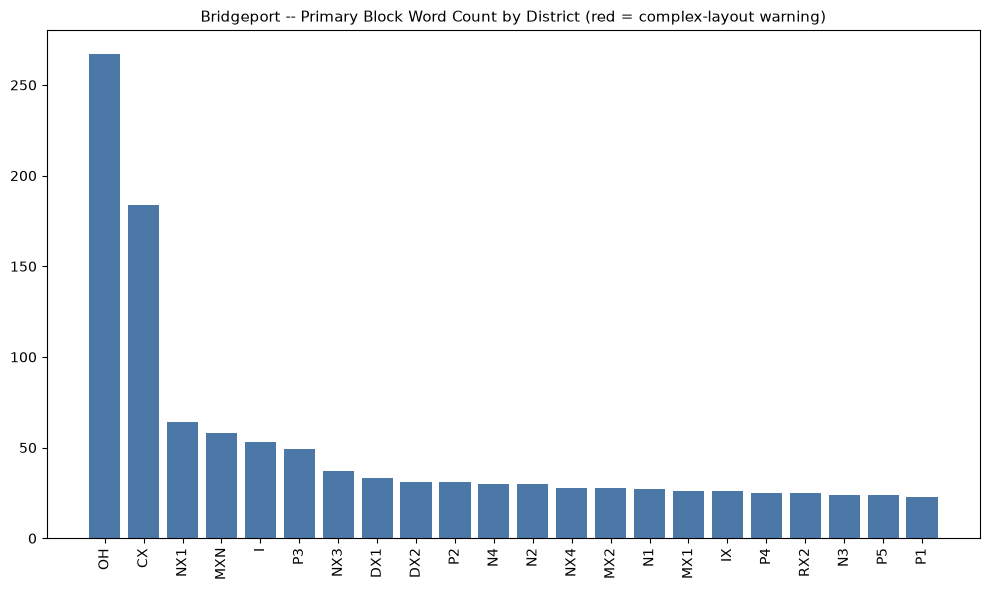

Saved: outputs/figures/bridgeport/step_04_word_count_by_district.png


In [77]:
fig, ax = plt.subplots(figsize=(10, 6))
word_count_sorted = primary_blocks_df.sort_values("word_count", ascending=False)
colors_by_warning = word_count_sorted["layout_warning"].map({True: "#E45756", False: "#4C78A8"})
ax.bar(word_count_sorted["district_code"], word_count_sorted["word_count"], color=colors_by_warning)
ax.set_title("Bridgeport -- Primary Block Word Count by District (red = complex-layout warning)", fontsize=11)
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
word_count_chart_path = FIGURES_DIR / "step_04_word_count_by_district.png"
fig.savefig(word_count_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {word_count_chart_path.relative_to(STAGE_A_ROOT)}")

Rendering 5 representative evidence cards (one per preliminary category)



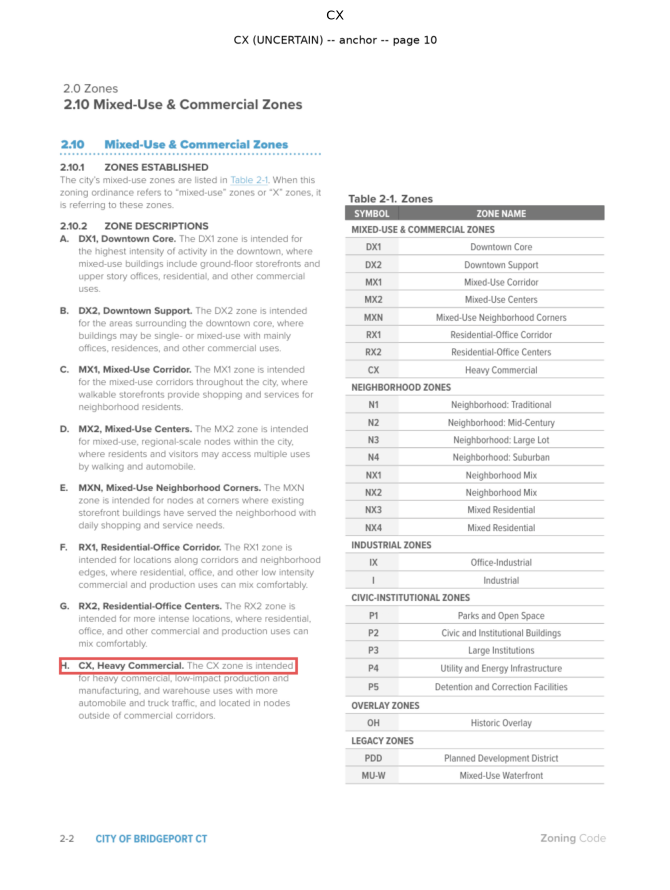

CX: word_count=184  pages=10-11  layout_warning=False  confidence=0.9
  excerpt: H. CX, Heavy Commercial. The CX zone is intended for heavy commercial, low-impact production and manufacturing, and warehouse uses with more automobile and truck traffic, and located in nodes outside of commercial corrid...
----------------------------------------------------------------------------------------------------


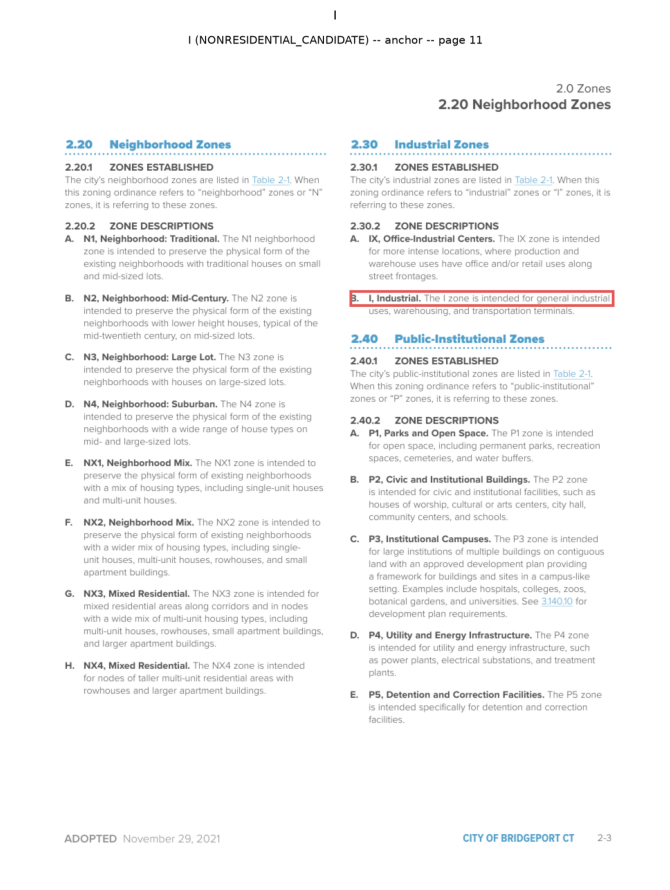

I: word_count=53  pages=11-11  layout_warning=False  confidence=0.9
  excerpt: B. I, Industrial. The I zone is intended for general industrial uses, warehousing, and transportation terminals. 2.40 Public-Institutional Zones 2.40.1 ZONES ESTABLISHED The city’s public-institutional zones are listed i...
----------------------------------------------------------------------------------------------------


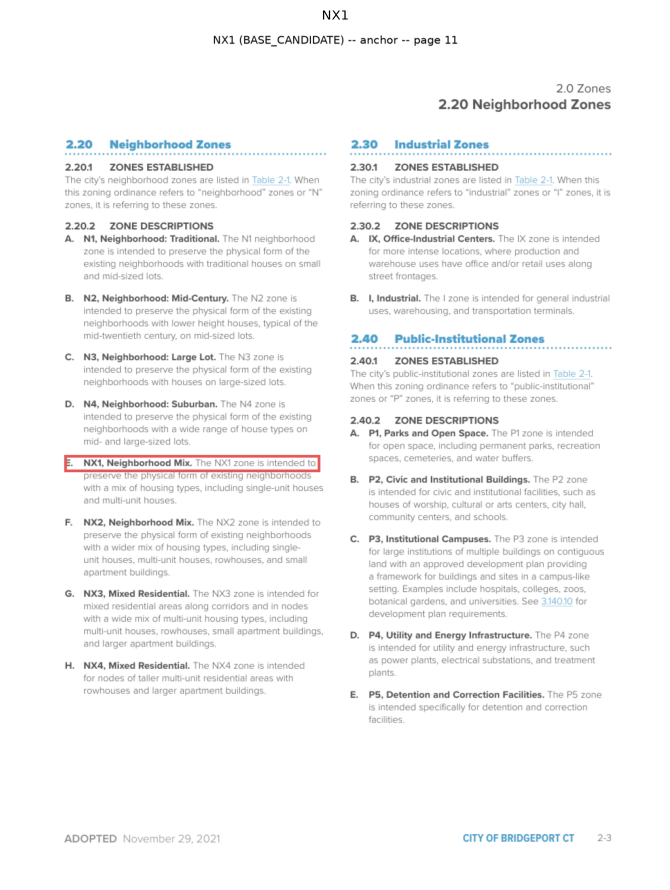

NX1: word_count=64  pages=11-11  layout_warning=False  confidence=0.9
  excerpt: E. NX1, Neighborhood Mix. The NX1 zone is intended to preserve the physical form of existing neighborhoods with a mix of housing types, including single-unit houses and multi-unit houses. F. NX2, Neighborhood Mix. The NX...
----------------------------------------------------------------------------------------------------


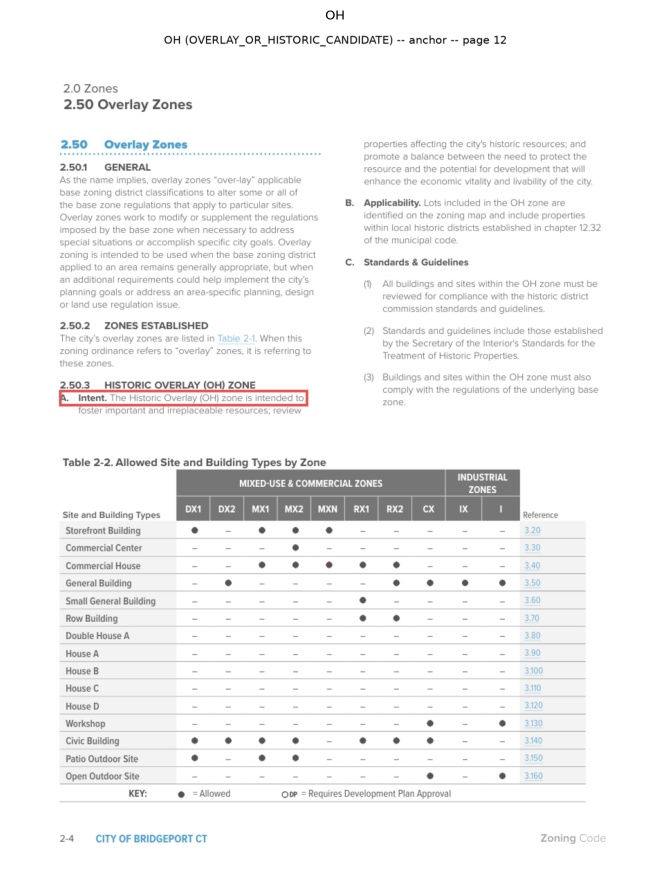

OH: word_count=267  pages=12-13  layout_warning=False  confidence=0.9
  excerpt: A. Intent. The Historic Overlay (OH) zone is intended to zone. foster important and irreplaceable resources; review Table 2-2. Allowed Site and Building Types by Zone INDUSTRIAL MIXED-USE & COMMERCIAL ZONES ZONES DX1 DX2...
----------------------------------------------------------------------------------------------------


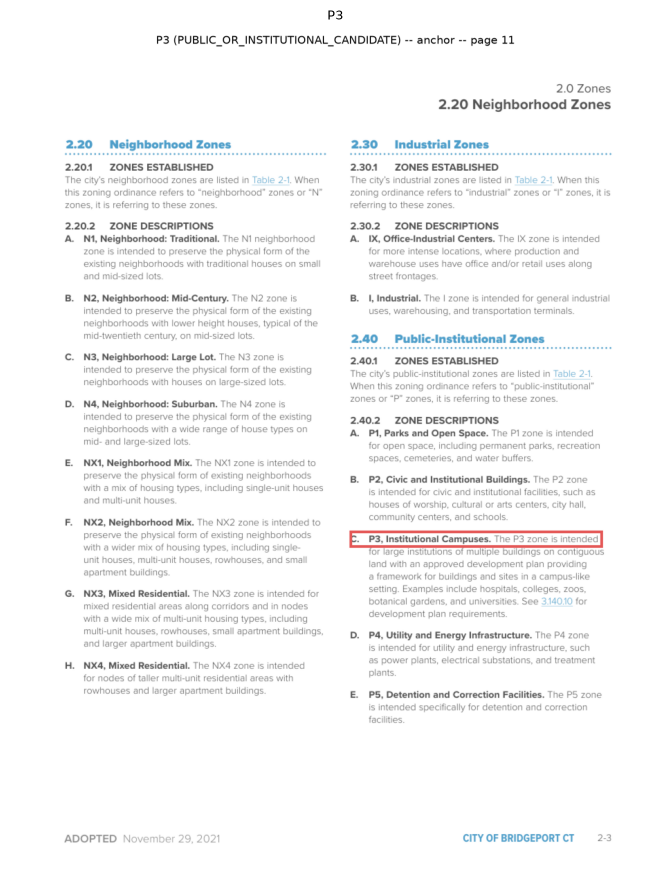

P3: word_count=49  pages=11-11  layout_warning=False  confidence=0.9
  excerpt: C. P3, Institutional Campuses. The P3 zone is intended for large institutions of multiple buildings on contiguous land with an approved development plan providing a framework for buildings and sites in a campus-like sett...
----------------------------------------------------------------------------------------------------


In [78]:
def render_district_evidence_card(district_code: str) -> Path:
    block_row = primary_blocks_df.loc[primary_blocks_df["district_code"] == district_code].iloc[0]
    registry_row = district_registry_df.loc[district_registry_df["district_code"] == district_code].iloc[0]
    anchor_heading_row = heading_candidates_repaired_df.loc[heading_candidates_repaired_df["node_id"] == block_row["anchor_node_id"]].iloc[0]

    save_path = render_bbox_highlight(
        int(anchor_heading_row["page_number"]),
        (anchor_heading_row["bbox_x0"], anchor_heading_row["bbox_y0"], anchor_heading_row["bbox_x1"], anchor_heading_row["bbox_y1"]),
        f"{district_code} ({registry_row['preliminary_district_category']}) -- anchor",
        f"step_04_evidence_card_{district_code}.png",
    )
    return save_path


representative_codes = []
for category in district_registry_df["preliminary_district_category"].unique():
    subset = coverage_df.loc[
        (coverage_df["preliminary_district_category"] == category) & (coverage_df["has_primary_block"])
    ].sort_values("word_count", ascending=False)
    if len(subset):
        representative_codes.append(subset.iloc[0]["district_code"])

print(f"Rendering {len(representative_codes)} representative evidence cards (one per preliminary category)\n")
for code in representative_codes:
    card_path = render_district_evidence_card(code)
    display_saved_image(card_path, title=code)
    block_row = primary_blocks_df.loc[primary_blocks_df["district_code"] == code].iloc[0]
    print(f"{code}: word_count={block_row['word_count']}  pages={block_row['start_page']}-{block_row['end_page']}  "
          f"layout_warning={block_row['layout_warning']}  confidence={block_row['confidence']}")
    print(f"  excerpt: {block_row['block_text'][:220]}...")
    print("-" * 100)

Top-10 largest and smallest/possibly-incomplete blocks, with start/end anchor pages highlighted for
a sample of each.

LARGEST BLOCKS:
district_code  word_count  start_page  end_page  layout_warning
           OH         267          12        13           False
           CX         184          10        11           False
          NX1          64          11        11           False
          MXN          58          10        10           False
            I          53          11        11           False
           P3          49          11        11           False
          NX3          37          11        11           False
          DX1          33          10        10           False
          DX2          31          10        10           False
           P2          31          11        11           False

SMALLEST/POSSIBLY-INCOMPLETE BLOCKS:
district_code  word_count  start_page  end_page  layout_warning
           P1          23          11        11           False
           N3          24          11        11           False
           P5          24          11        12   

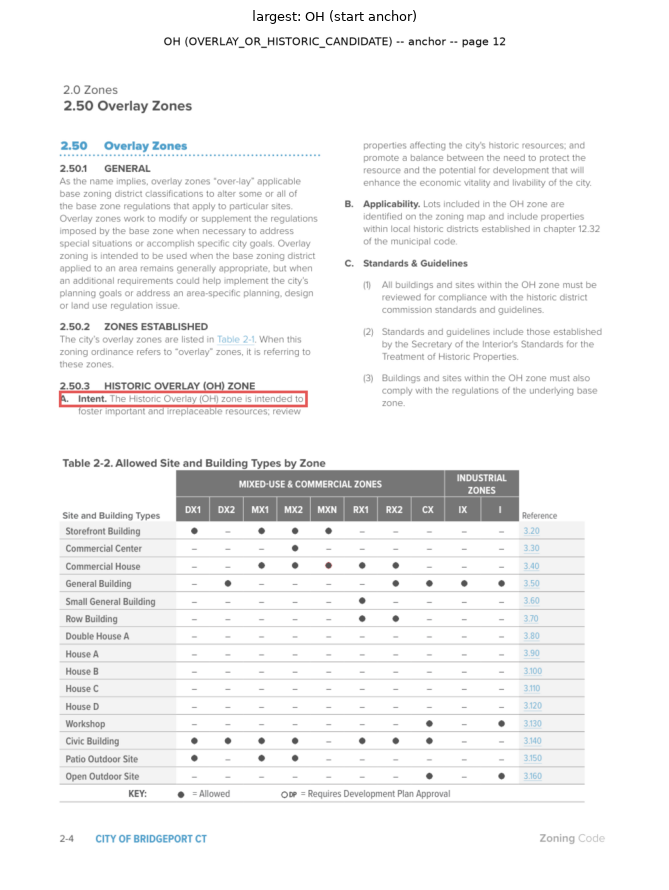

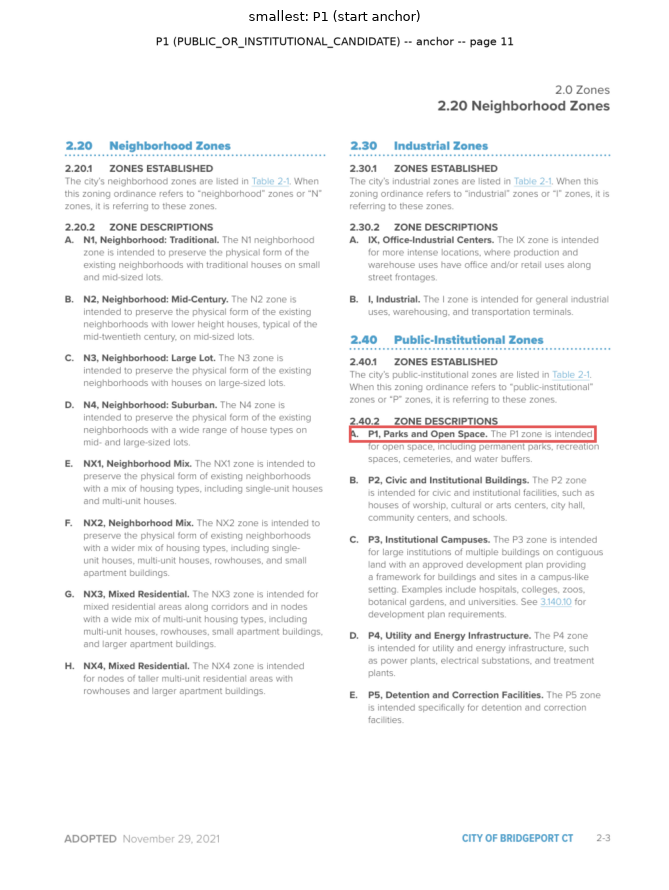

In [79]:
print("LARGEST BLOCKS:")
print(largest_blocks_df[["district_code", "word_count", "start_page", "end_page", "layout_warning"]].to_string(index=False))
print("\nSMALLEST/POSSIBLY-INCOMPLETE BLOCKS:")
print(smallest_blocks_df[["district_code", "word_count", "start_page", "end_page", "layout_warning"]].to_string(index=False))

for label, sample_df in [("largest", largest_blocks_df.head(1)), ("smallest", smallest_blocks_df.head(1))]:
    for _, row in sample_df.iterrows():
        card_path = render_district_evidence_card(row["district_code"])
        display_saved_image(card_path, title=f"{label}: {row['district_code']} (start anchor)")

### 13.3 Stage 4 final summary

In [80]:
stage_4_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "districts_with_primary_block": int(len(primary_blocks_df)),
    "districts_without_verified_anchor": districts_without_anchor,
    "mean_word_count": round(float(primary_blocks_df["word_count"].mean()), 1) if len(primary_blocks_df) else 0,
    "median_word_count": float(primary_blocks_df["word_count"].median()) if len(primary_blocks_df) else 0,
    "blocks_with_complex_layout_warning": int(primary_blocks_df["layout_warning"].sum()),
    "blocks_needing_review": int((primary_blocks_df["review_status"] == "needs_review").sum()),
}

stage_4_log_path = LOGS_DIR / "step_04_primary_blocks_log.json"
with stage_4_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_4_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 4 (primary district blocks) COMPLETE")
print("=" * 70)
for key, value in stage_4_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_4_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 4 (primary district blocks) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
districts_with_primary_block: 22
districts_without_verified_anchor: ['NX2', 'RX1']
mean_word_count: 51.0
median_word_count: 30.0
blocks_needing_review: 0

Saved: outputs/logs/bridgeport/step_04_primary_blocks_log.json


## 14. Stage 5 -- Citations and cross-reference graph

Bridgeport's own citation style was discovered by direct text search, not assumed from
Greenwich's `§6-XXX` convention. Real excerpts: *"See 3.140.10 for development plan
requirements."*, *"See 3.0 for site and building type regulations."*, *"Building types are
allowed in zones per Table 2-2."* -- i.e. `See`/`Refer to` followed by a bare decimal section
number, and separate `Table N-N` references to specific tables.

Resolution is conservative: an exact match against a heading's own `heading_number` is the only
"resolved" outcome; a citation that only matches an *ancestor* section (e.g. `3.10.13` cited but
only `3.10` exists as its own heading) is marked `resolved_to_ancestor_section` -- explicitly
not full-precision -- and anything else is `unresolved`, never guessed.

In [81]:
CITATION_DECIMAL_PATTERN = re.compile(r"\b(?:See|Refer to)\s+(\d{1,2}(?:\.\d{1,3}){0,2})\b")
CITATION_TABLE_PATTERN = re.compile(r"\bTable\s+(\d+-\d+)\b")
TABLE_CAPTION_PATTERN = re.compile(r"^Table\s+(\d+-\d+)\.")

heading_number_lookup = heading_candidates_repaired_df.set_index("heading_number")["node_id"].to_dict()
heading_number_lookup.pop("", None)


def enclosing_heading_node_id(page_number: int, bbox_x0: float, bbox_y0: float) -> str:
    column_id = determine_column_id(bbox_x0, layout_lookup_full.loc[page_number] if page_number in layout_lookup_full.index else None)
    same_page = heading_order_lookup.loc[heading_order_lookup["page_number"] == page_number]

    if column_id != "n/a":
        candidates = same_page.loc[
            (same_page["column_id_for_title_match"] == column_id) & (same_page["bbox_y0"] < bbox_y0)
        ]
    else:
        candidates = same_page.loc[same_page["bbox_y0"] < bbox_y0]

    if len(candidates):
        return candidates.sort_values("bbox_y0").iloc[-1]["node_id"]

    earlier = heading_order_lookup.loc[heading_order_lookup["page_number"] < page_number]
    return earlier.iloc[-1]["node_id"] if len(earlier) else ""


# Build a table-caption -> table_id lookup from real caption lines (e.g. "Table 2-2. Allowed
# Site and Building Types by Zone"), matched to the nearest retained table on the same page.
caption_hits = []
for _, row in layout_ordered_lines_df.iterrows():
    match = TABLE_CAPTION_PATTERN.match(row["text"].strip())
    if match:
        caption_hits.append({"table_ref": match.group(1), "page_number": row["page_number"], "bbox_y0": row["bbox_y0"]})
caption_hits_df = pd.DataFrame(caption_hits).drop_duplicates(subset=["table_ref"], keep="first")

table_ref_lookup = {}
for _, caption_row in caption_hits_df.iterrows():
    same_page_tables = table_master_df.loc[table_master_df["page_number"] == caption_row["page_number"]]
    if len(same_page_tables):
        nearest = same_page_tables.iloc[(same_page_tables["bbox_y0"] - caption_row["bbox_y0"]).abs().argsort().iloc[0]]
        table_ref_lookup[caption_row["table_ref"]] = {"table_id": nearest["table_id"], "confidence": 0.8}

print(f"Table-caption lookup built for {len(table_ref_lookup)} of {caption_hits_df['table_ref'].nunique()} distinct table references")
print(table_ref_lookup)

Table-caption lookup built for 9 of 18 distinct table references
{'2-2': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-012-00', 'confidence': 0.8}, '5-1': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-172-00', 'confidence': 0.8}, '7-3': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-219-00', 'confidence': 0.8}, '8-1': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-228-01', 'confidence': 0.8}, '8-2': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-229-01', 'confidence': 0.8}, '8-4': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-231-00', 'confidence': 0.8}, '8-3': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-231-03', 'confidence': 0.8}, '9-1': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-241-00', 'confidence': 0.8}, '11-1': {'table_id': 'bridgeport-connecticut-afe7c678fa5dfc85-table-258-00', 'confidence': 0.8}}


In [82]:
raw_citation_records = []
citation_counter = itertools.count(1)

for _, row in layout_ordered_lines_df.iterrows():
    text = row["text"]
    source_node_id = enclosing_heading_node_id(row["page_number"], row["bbox_x0"], row["bbox_y0"])

    for match in CITATION_DECIMAL_PATTERN.finditer(text):
        raw_citation_records.append({
            "citation_id": f"{DOCUMENT_ID}-citation-{next(citation_counter):05d}",
            "raw_citation_text": match.group(0), "normalized_citation": match.group(1),
            "citation_kind": "decimal_section", "source_node_id": source_node_id,
            "source_page": int(row["page_number"]), "source_excerpt": text[:300],
        })
    for match in CITATION_TABLE_PATTERN.finditer(text):
        if TABLE_CAPTION_PATTERN.match(text.strip()):
            continue  # this line IS the caption, not a citation to it
        raw_citation_records.append({
            "citation_id": f"{DOCUMENT_ID}-citation-{next(citation_counter):05d}",
            "raw_citation_text": match.group(0), "normalized_citation": match.group(1),
            "citation_kind": "table_reference", "source_node_id": source_node_id,
            "source_page": int(row["page_number"]), "source_excerpt": text[:300],
        })

raw_citations_df = pd.DataFrame(raw_citation_records)
print(f"Raw citations detected: {len(raw_citations_df):,}")
print(raw_citations_df["citation_kind"].value_counts())

Raw citations detected: 368
citation_kind
decimal_section    325
table_reference     43
Name: count, dtype: int64


### 14.1 Conservative resolution

In [83]:
def resolve_citation(row: pd.Series) -> pd.Series:
    if row["citation_kind"] == "table_reference":
        target = table_ref_lookup.get(row["normalized_citation"])
        if target:
            return pd.Series({"target_node_id": target["table_id"], "resolution_status": "resolved_table",
                               "resolution_confidence": target["confidence"], "ambiguity_reason": ""})
        return pd.Series({"target_node_id": "", "resolution_status": "unresolved",
                           "resolution_confidence": 0.0, "ambiguity_reason": "no_caption_found_for_table_reference"})

    exact_target = heading_number_lookup.get(row["normalized_citation"])
    if exact_target:
        return pd.Series({"target_node_id": exact_target, "resolution_status": "resolved_exact",
                           "resolution_confidence": 0.9, "ambiguity_reason": ""})

    parts = row["normalized_citation"].split(".")
    for depth in range(len(parts) - 1, 0, -1):
        ancestor_key = ".".join(parts[:depth])
        ancestor_target = heading_number_lookup.get(ancestor_key)
        if ancestor_target:
            return pd.Series({
                "target_node_id": ancestor_target, "resolution_status": "resolved_to_ancestor_section",
                "resolution_confidence": round(0.6 - 0.1 * (len(parts) - depth), 2),
                "ambiguity_reason": f"exact_heading_number_'{row['normalized_citation']}'_not_found;_matched_ancestor_'{ancestor_key}'",
            })

    return pd.Series({"target_node_id": "", "resolution_status": "unresolved",
                       "resolution_confidence": 0.0, "ambiguity_reason": "no_exact_or_ancestor_heading_number_match"})


raw_citations_df[["target_node_id", "resolution_status", "resolution_confidence", "ambiguity_reason"]] = raw_citations_df.apply(
    resolve_citation, axis=1
)

print(raw_citations_df["resolution_status"].value_counts())
resolution_rate = float((raw_citations_df["resolution_status"] != "unresolved").mean())
print(f"\nOverall resolution rate (exact + ancestor + table): {resolution_rate:.1%}")

citations_path = TABLES_DIR / "step_05_citations.csv"
raw_citations_df.to_csv(citations_path, index=False)
print(f"Saved: {citations_path.relative_to(STAGE_A_ROOT)}")

resolution_status
resolved_exact                  241
resolved_to_ancestor_section     74
resolved_table                   28
unresolved                       25
Name: count, dtype: int64

Overall resolution rate (exact + ancestor + table): 93.2%
Saved: outputs/tables/bridgeport/step_05_citations.csv


### 14.2 Cross-reference graph, with cycle protection

In [84]:
MAX_REFERENCE_DEPTH = 6

citation_graph = nx.DiGraph()
for node_id in heading_candidates_repaired_df["node_id"]:
    citation_graph.add_node(node_id)
for table_id in table_master_df["table_id"]:
    citation_graph.add_node(table_id)

edges_added, edges_skipped_cycle = 0, 0
resolved_citations = raw_citations_df.loc[raw_citations_df["resolution_status"] != "unresolved"]

for _, row in resolved_citations.iterrows():
    source, target = row["source_node_id"], row["target_node_id"]
    if not source or not target or source == target:
        continue
    citation_graph.add_edge(source, target, citation_id=row["citation_id"], kind=row["citation_kind"])
    if not nx.is_directed_acyclic_graph(citation_graph):
        citation_graph.remove_edge(source, target)
        edges_skipped_cycle += 1
    else:
        edges_added += 1

print(f"Cross-reference graph: {citation_graph.number_of_nodes():,} nodes, {citation_graph.number_of_edges():,} edges")
print(f"Edges skipped to preserve acyclic property: {edges_skipped_cycle}")

depth_cutoff_records = []
for node in list(citation_graph.nodes):
    if citation_graph.out_degree(node) == 0:
        continue
    try:
        lengths = nx.single_source_shortest_path_length(citation_graph, node, cutoff=MAX_REFERENCE_DEPTH + 2)
        beyond_cutoff = [n for n, d in lengths.items() if d > MAX_REFERENCE_DEPTH]
        if beyond_cutoff:
            depth_cutoff_records.append({"source_node_id": node, "nodes_beyond_max_depth": len(beyond_cutoff)})
    except Exception:
        continue

depth_cutoff_df = pd.DataFrame(depth_cutoff_records)
print(f"Sources with reachable nodes beyond max depth ({MAX_REFERENCE_DEPTH}): {len(depth_cutoff_df)}")

cross_reference_summary_path = TABLES_DIR / "step_05_cross_reference_summary.csv"
pd.DataFrame({
    "metric": ["nodes", "edges", "edges_skipped_cycle", "max_reference_depth", "sources_beyond_max_depth"],
    "value": [citation_graph.number_of_nodes(), citation_graph.number_of_edges(), edges_skipped_cycle,
              MAX_REFERENCE_DEPTH, len(depth_cutoff_df)],
}).to_csv(cross_reference_summary_path, index=False)
print(f"Saved: {cross_reference_summary_path.relative_to(STAGE_A_ROOT)}")

Cross-reference graph: 2,047 nodes, 319 edges
Edges skipped to preserve acyclic property: 0
Sources with reachable nodes beyond max depth (6): 0
Saved: outputs/tables/bridgeport/step_05_cross_reference_summary.csv


### 14.3 Required visuals

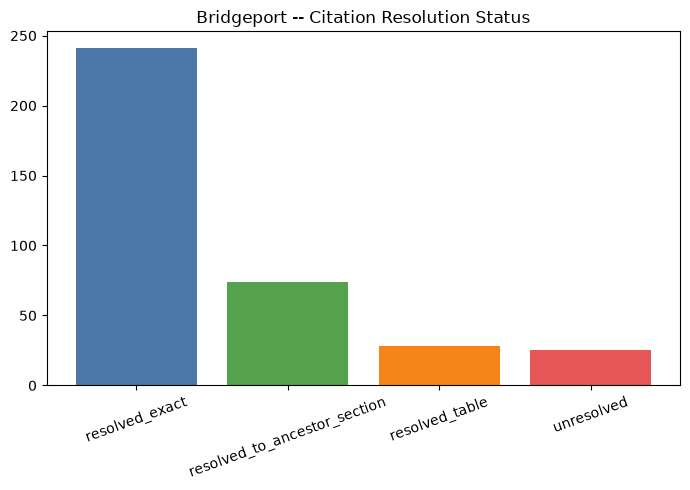

Saved: outputs/figures/bridgeport/step_05_citation_resolution_status.png


In [85]:
fig, ax = plt.subplots(figsize=(7, 5))
status_counts = raw_citations_df["resolution_status"].value_counts()
ax.bar(status_counts.index, status_counts.values, color=["#4C78A8", "#54A24B", "#F58518", "#E45756"][:len(status_counts)])
ax.set_title("Bridgeport -- Citation Resolution Status", fontsize=12)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
resolution_status_path = FIGURES_DIR / "step_05_citation_resolution_status.png"
fig.savefig(resolution_status_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {resolution_status_path.relative_to(STAGE_A_ROOT)}")

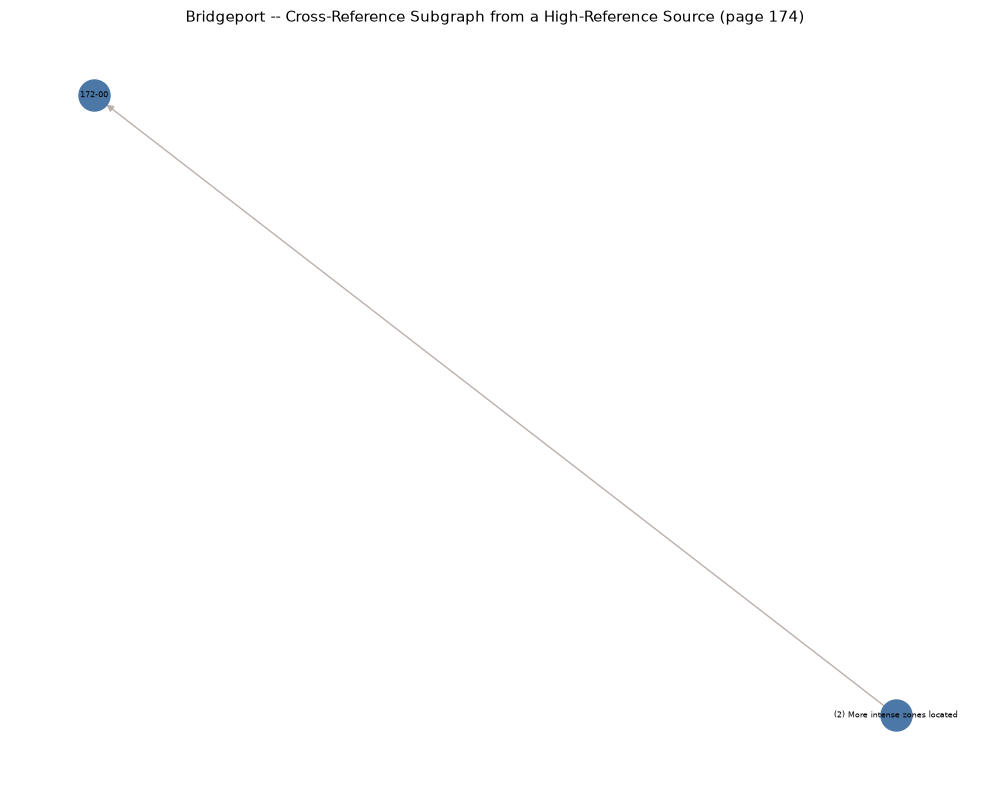

Saved: outputs/figures/bridgeport/step_05_source_target_graph.png


In [86]:
citations_by_source_district = raw_citations_df.loc[raw_citations_df["source_node_id"] != ""].merge(
    heading_candidates_repaired_df[["node_id", "page_number"]].rename(columns={"page_number": "source_node_page"}),
    left_on="source_node_id", right_on="node_id", how="left",
)
top_citing_page = citations_by_source_district["source_page"].value_counts().idxmax() if len(citations_by_source_district) else None

if top_citing_page is not None:
    sample_sources = raw_citations_df.loc[raw_citations_df["source_page"] == top_citing_page, "source_node_id"].unique()[:1]
    if len(sample_sources):
        sample_source = sample_sources[0]
        descendants = list(nx.descendants(citation_graph, sample_source)) if sample_source in citation_graph else []
        subgraph_nodes = [sample_source] + descendants[:15]
        subgraph = citation_graph.subgraph(subgraph_nodes)

        fig, ax = plt.subplots(figsize=(10, 8))
        pos = nx.spring_layout(subgraph, seed=42, k=0.8)
        node_labels = {}
        for n in subgraph.nodes:
            text_row = heading_candidates_repaired_df.loc[heading_candidates_repaired_df["node_id"] == n, "text"]
            if len(text_row):
                node_labels[n] = text_row.iloc[0][:30]
            else:
                node_labels[n] = str(n).split("-table-")[-1] if "-table-" in str(n) else str(n)[:20]
        nx.draw(subgraph, pos, ax=ax, with_labels=False, node_color="#4C78A8", node_size=500, arrows=True, edge_color="#BAB0AC")
        nx.draw_networkx_labels(subgraph, pos, labels=node_labels, font_size=6, ax=ax)
        ax.set_title(f"Bridgeport -- Cross-Reference Subgraph from a High-Reference Source (page {top_citing_page})", fontsize=11)
        plt.tight_layout()
        source_target_graph_path = FIGURES_DIR / "step_05_source_target_graph.png"
        fig.savefig(source_target_graph_path, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {source_target_graph_path.relative_to(STAGE_A_ROOT)}")
else:
    print("No resolved citations with a source page; skipping source/target graph.")

In [87]:
unresolved_examples_df = raw_citations_df.loc[raw_citations_df["resolution_status"] == "unresolved"].head(10)
unresolved_path = REVIEW_DIR / "step_05_unresolved_citation_examples.csv"
unresolved_examples_df.to_csv(unresolved_path, index=False)
print(f"Unresolved citation examples saved: {unresolved_path.relative_to(STAGE_A_ROOT)}")
print(unresolved_examples_df[["normalized_citation", "citation_kind", "source_page", "ambiguity_reason"]].to_string(index=False))

circular_cutoff_report_path = REVIEW_DIR / "step_05_circular_or_cutoff_report.csv"
pd.DataFrame({"edges_skipped_for_cycle": [edges_skipped_cycle], "sources_beyond_max_depth": [len(depth_cutoff_df)]}).to_csv(
    circular_cutoff_report_path, index=False
)
print(f"Saved: {circular_cutoff_report_path.relative_to(STAGE_A_ROOT)}")

Unresolved citation examples saved: outputs/review/bridgeport/step_05_unresolved_citation_examples.csv
normalized_citation   citation_kind  source_page                          ambiguity_reason
                2-1 table_reference           10      no_caption_found_for_table_reference
                2-1 table_reference           11      no_caption_found_for_table_reference
                2-1 table_reference           11      no_caption_found_for_table_reference
                2-1 table_reference           11      no_caption_found_for_table_reference
                2-1 table_reference           12      no_caption_found_for_table_reference
               8.40 decimal_section          159 no_exact_or_ancestor_heading_number_match
             5.50.2 decimal_section          173 no_exact_or_ancestor_heading_number_match
             5.50.2 decimal_section          174 no_exact_or_ancestor_heading_number_match
             5.50.2 decimal_section          174 no_exact_or_ancestor_heading_

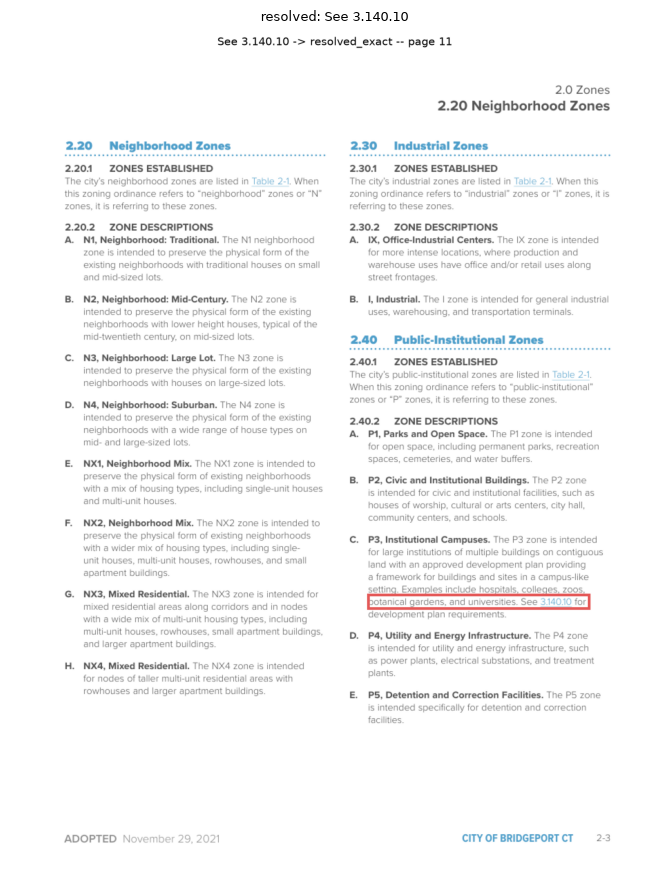

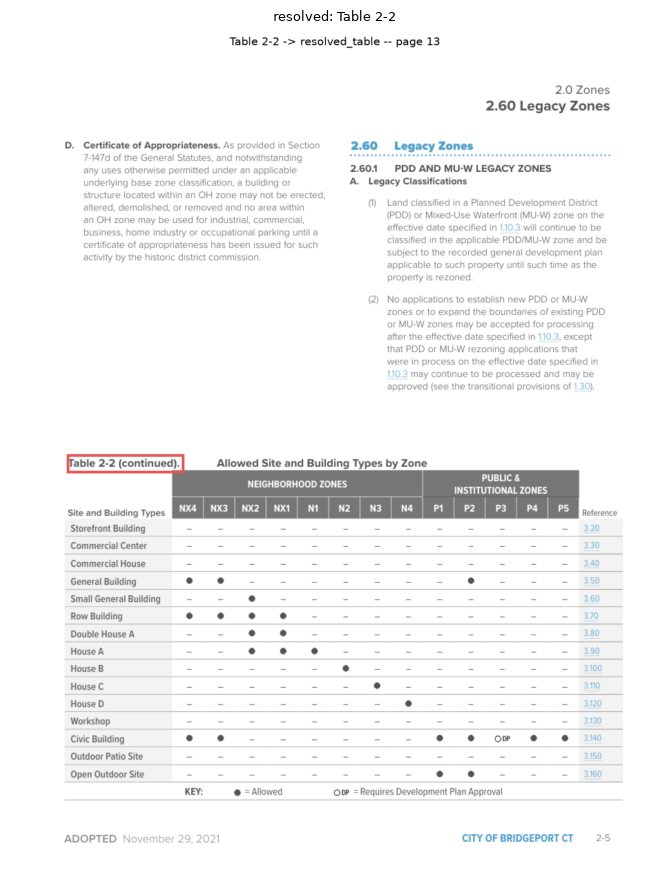

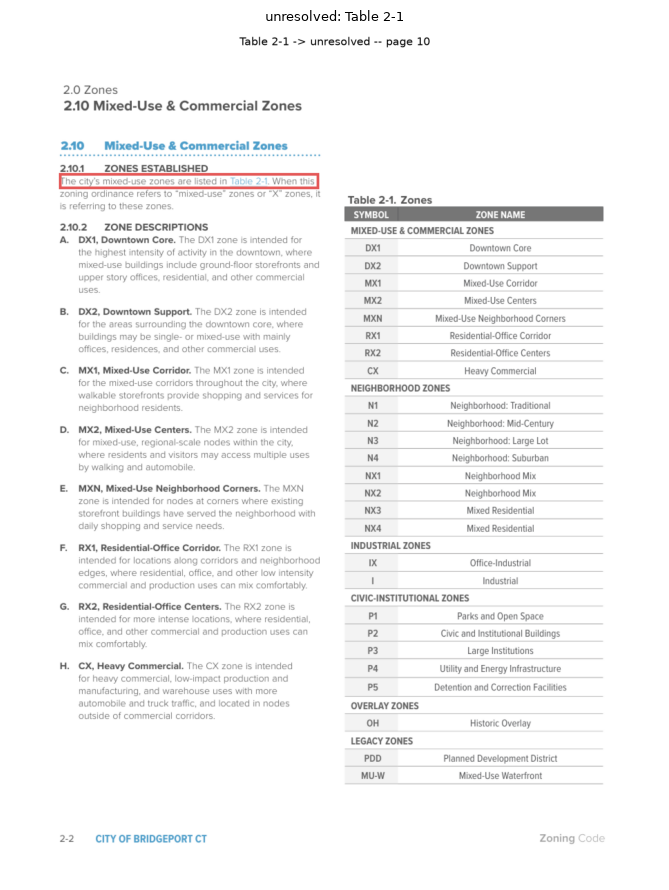

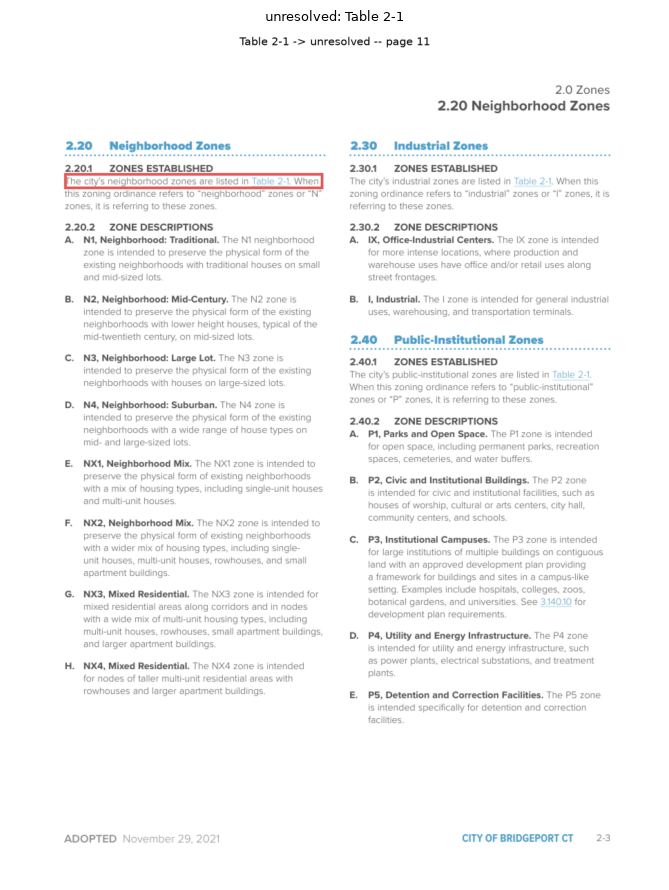

In [88]:
def render_citation_source_excerpt(row: pd.Series, save_name: str) -> Path:
    matching_line = layout_ordered_lines_df.loc[
        (layout_ordered_lines_df["page_number"] == row["source_page"])
        & (layout_ordered_lines_df["text"].str.contains(re.escape(row["raw_citation_text"]), regex=True, na=False))
    ]
    if len(matching_line) == 0:
        return None
    line_row = matching_line.iloc[0]
    return render_bbox_highlight(
        int(row["source_page"]), (line_row["bbox_x0"], line_row["bbox_y0"], line_row["bbox_x1"], line_row["bbox_y1"]),
        f"{row['raw_citation_text']} -> {row['resolution_status']}", save_name,
    )


sample_resolved = raw_citations_df.loc[raw_citations_df["resolution_status"].isin(["resolved_exact", "resolved_table"])].head(2)
sample_unresolved = raw_citations_df.loc[raw_citations_df["resolution_status"] == "unresolved"].head(2)

for label, sample_df in [("resolved", sample_resolved), ("unresolved", sample_unresolved)]:
    for i, (_, row) in enumerate(sample_df.iterrows()):
        save_path = render_citation_source_excerpt(row, f"step_05_citation_{label}_{i}.png")
        if save_path:
            display_saved_image(save_path, title=f"{label}: {row['raw_citation_text']}")

### 14.4 Stage 5 final summary

In [89]:
stage_5_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "raw_citation_count": int(len(raw_citations_df)),
    "resolution_status_counts": raw_citations_df["resolution_status"].value_counts().to_dict(),
    "resolution_rate": round(resolution_rate, 4),
    "graph_nodes": citation_graph.number_of_nodes(),
    "graph_edges": citation_graph.number_of_edges(),
    "edges_skipped_for_cycle": edges_skipped_cycle,
    "sources_beyond_max_depth": int(len(depth_cutoff_df)),
}

stage_5_log_path = LOGS_DIR / "step_05_citations_log.json"
with stage_5_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_5_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 5 (citations and cross-reference graph) COMPLETE")
print("=" * 70)
for key, value in stage_5_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_5_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 5 (citations and cross-reference graph) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
raw_citation_count: 368
resolution_status_counts: {'resolved_exact': 241, 'resolved_to_ancestor_section': 74, 'resolved_table': 28, 'unresolved': 25}
resolution_rate: 0.9321
graph_nodes: 2047
graph_edges: 319
edges_skipped_for_cycle: 0
sources_beyond_max_depth: 0

Saved: outputs/logs/bridgeport/step_05_citations_log.json


## 15. Stage 6 -- Townwide/general-rule library

Every `Section`/`Subsection` heading whose own title text matches a topic keyword becomes a rule
candidate; its block runs from that heading to the next heading at the same depth or shallower
(generalizing the Stage 4 slicer, which only needed to handle the deepest `Paragraph` level).
**Scope/applicability is only ever attached when explicit** -- a named zone code, a named district
family (mapped back to Stage 3's own source-backed preliminary categories, not re-guessed), an
explicit building-type reference, or a citywide/overlay statement found in the rule's own text.
Everything else stays a retained candidate with `manual_review_required` and is never treated as
applicable district evidence.

In [90]:
TOPIC_KEYWORDS = {
    "definitions": ["definition", "means:", "glossary"],
    "permitted_uses": ["permitted use", "allowed use", "accessory use", "principal use", "use table"],
    "building_types": ["building type", "site type"],
    "adu": ["accessory dwelling unit", "accessory apartment", " adu "],
    "multifamily_or_group_living": ["multi-family", "multifamily", "group living", "apartment"],
    "parking": ["parking"],
    "mobility": ["mobility", "bicycle", "loading"],
    "building_form": ["building form", "facade", "entrance", "form standard"],
    "frontage": ["frontage"],
    "build_to": ["build-to"],
    "dimensional_exceptions": ["dimensional exception", "encroachment", "setback exception"],
    "approval_procedures": ["approval process", "procedure"],
    "administrative_review": ["administrative review"],
    "site_plan_review": ["site plan review"],
    "special_permits": ["special permit"],
    "nonconformity": ["nonconform"],
    "historic_district_rules": ["historic district", "historic overlay"],
    "overlays": ["overlay"],
}


def extract_block_for_heading(position: int) -> dict:
    node_row = heading_global_order_df.iloc[position]
    depth = node_row["depth"]
    start_global = int(node_row["global_order"])
    end_global = len(global_lines_df)
    for next_row in heading_global_order_df.iloc[position + 1:].itertuples():
        if next_row.depth <= depth:
            end_global = int(next_row.global_order)
            break
    block_lines = global_lines_df.loc[
        (global_lines_df["global_order"] >= start_global) & (global_lines_df["global_order"] < end_global)
    ]
    return {
        "block_text": " ".join(block_lines["text"].tolist()),
        "source_pages": sorted(block_lines["page_number"].unique().tolist()),
    }


rule_candidate_records = []
rule_counter = itertools.count(1)

for position in range(len(heading_global_order_df)):
    heading_row = heading_global_order_df.iloc[position]
    if heading_row["node_type"] not in {"Section", "Subsection"} or pd.isna(heading_row["global_order"]):
        continue
    title_lower = heading_row["text"].lower()
    matched_topics = [topic for topic, keywords in TOPIC_KEYWORDS.items() if any(kw in title_lower for kw in keywords)]
    if not matched_topics:
        continue

    block = extract_block_for_heading(position)
    source_pages = block["source_pages"]
    complex_pages = [p for p in source_pages if p in layout_lookup_full.index and layout_lookup_full.loc[p, "page_layout_type"] == "multi_column_or_complex"]
    table_context_ids = table_title_associations_df.loc[
        table_title_associations_df["title_node_id"] == heading_row["node_id"], "table_id"
    ].tolist()

    rule_candidate_records.append({
        "rule_id": f"{DOCUMENT_ID}-rule-{next(rule_counter):05d}",
        "topic_tags": json.dumps(matched_topics),
        "source_node": heading_row["node_id"], "page": int(heading_row["page_number"]),
        "section": heading_row["heading_number"], "heading": heading_row["text"],
        "full_source_text": block["block_text"][:4000], "source_confidence": float(heading_row["heading_confidence"]),
        "layout_context": "multi_column_or_complex" if complex_pages else "normal",
        "table_context": json.dumps(table_context_ids), "review_status": "candidate",
    })

rule_library_raw_df = pd.DataFrame(rule_candidate_records)
print(f"Rule candidates found: {len(rule_library_raw_df)}")
print(pd.Series([t for tags in rule_library_raw_df["topic_tags"] for t in json.loads(tags)]).value_counts())

Rule candidates found: 83
parking                18
building_form          17
permitted_uses         17
definitions            16
building_types         15
nonconformity           8
mobility                2
overlays                1
frontage                1
site_plan_review        1
special_permits         1
approval_procedures     1
build_to                1
Name: count, dtype: int64


### 15.1 Scope/applicability evidence (explicit only)

In [91]:
ZONE_FAMILY_KEYWORDS = {
    "neighborhood_zones": ["neighborhood zone"],
    "mixed_use_zones": ["mixed-use zone", "mixed use zone"],
    "industrial_zones": ["industrial zone"],
    "public_institutional_zones": ["public-institutional zone", "public institutional zone"],
    "overlay_zones": ["overlay zone"],
}
CITYWIDE_KEYWORDS = ["citywide", "city-wide", "throughout the city", "in all districts", "in all zones"]

ZONE_FAMILY_TO_CATEGORY = {
    "neighborhood_zones": "BASE_CANDIDATE", "mixed_use_zones": "BASE_CANDIDATE",
    "industrial_zones": "NONRESIDENTIAL_CANDIDATE", "public_institutional_zones": "PUBLIC_OR_INSTITUTIONAL_CANDIDATE",
    "overlay_zones": "OVERLAY_OR_HISTORIC_CANDIDATE",
}
code_word_pattern_by_known_code = {code: re.compile(rf"\b{re.escape(code)}\b") for code in district_registry_df["district_code"]}

scope_records = []
for _, rule_row in rule_library_raw_df.iterrows():
    text_lower = rule_row["full_source_text"].lower()
    explicit_codes = [code for code, pattern in code_word_pattern_by_known_code.items() if pattern.search(rule_row["full_source_text"])]
    zone_families = [family for family, keywords in ZONE_FAMILY_KEYWORDS.items() if any(kw in text_lower for kw in keywords)]
    citywide = any(kw in text_lower for kw in CITYWIDE_KEYWORDS)
    building_type_applicability = "building type" in text_lower

    family_derived_codes = []
    for family in zone_families:
        category = ZONE_FAMILY_TO_CATEGORY.get(family)
        if category:
            family_derived_codes += district_registry_df.loc[
                district_registry_df["preliminary_district_category"] == category, "district_code"
            ].tolist()

    all_applicable_codes = sorted(set(explicit_codes) | set(family_derived_codes))
    is_explicit = bool(explicit_codes or zone_families or citywide or building_type_applicability)

    scope_records.append({
        "rule_id": rule_row["rule_id"], "explicit_codes": json.dumps(explicit_codes),
        "zone_families": json.dumps(zone_families), "citywide": citywide,
        "building_type_applicability": building_type_applicability,
        "applicable_district_codes": json.dumps(all_applicable_codes),
        "scope_status": "explicit" if is_explicit else "ambiguous",
    })

scope_df = pd.DataFrame(scope_records)
rule_library_df = rule_library_raw_df.merge(scope_df, on="rule_id", how="left")
rule_library_df["review_status"] = np.where(rule_library_df["scope_status"] == "ambiguous", "manual_review_required", "candidate")

print(rule_library_df["scope_status"].value_counts())

rule_library_path = PROCESSED_DIR / "step_06_general_rule_library.parquet"
rule_library_df.to_parquet(rule_library_path, index=False)
print(f"Saved: {rule_library_path.relative_to(STAGE_A_ROOT)}")

ambiguous_scope_path = REVIEW_DIR / "step_06_ambiguous_scope_queue.csv"
rule_library_df.loc[rule_library_df["scope_status"] == "ambiguous"].to_csv(ambiguous_scope_path, index=False)
print(f"Saved: {ambiguous_scope_path.relative_to(STAGE_A_ROOT)}")

scope_status
explicit     70
ambiguous    13
Name: count, dtype: int64
Saved: data/processed/bridgeport/step_06_general_rule_library.parquet
Saved: outputs/review/bridgeport/step_06_ambiguous_scope_queue.csv


### 15.2 Explicit applicability matrix

In [92]:
explicit_rules_df = rule_library_df.loc[rule_library_df["scope_status"] == "explicit"]

applicability_rows = []
for _, rule_row in explicit_rules_df.iterrows():
    codes = json.loads(rule_row["applicable_district_codes"])
    for code in codes:
        applicability_rows.append({"rule_id": rule_row["rule_id"], "heading": rule_row["heading"], "district_code": code, "applicable": True})

applicability_matrix_long_df = pd.DataFrame(applicability_rows)
if len(applicability_matrix_long_df):
    applicability_matrix_df = applicability_matrix_long_df.pivot_table(
        index="rule_id", columns="district_code", values="applicable", fill_value=False, aggfunc="any"
    )
else:
    applicability_matrix_df = pd.DataFrame()

applicability_matrix_path = TABLES_DIR / "step_06_explicit_applicability_matrix.csv"
applicability_matrix_df.to_csv(applicability_matrix_path)
print(f"Explicit applicability matrix: {applicability_matrix_df.shape[0]} rules x {applicability_matrix_df.shape[1]} districts")
print(f"Saved: {applicability_matrix_path.relative_to(STAGE_A_ROOT)}")

Explicit applicability matrix: 60 rules x 24 districts
Saved: outputs/tables/bridgeport/step_06_explicit_applicability_matrix.csv


### 15.3 Required visuals

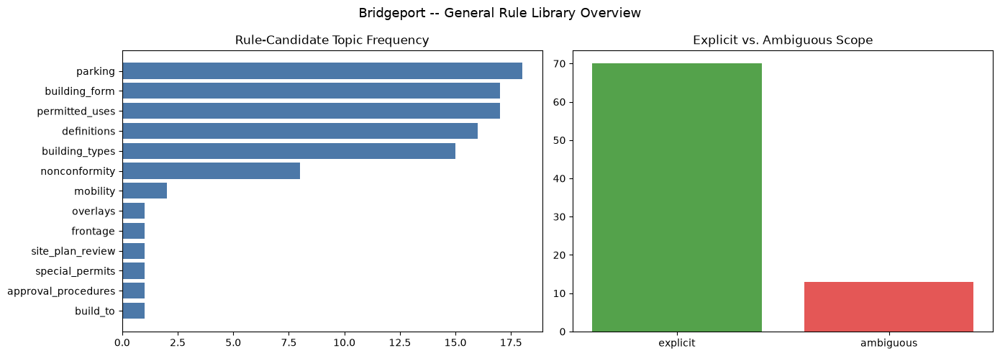

Saved: outputs/figures/bridgeport/step_06_rule_library_overview.png


In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
topic_counts = pd.Series([t for tags in rule_library_df["topic_tags"] for t in json.loads(tags)]).value_counts()
axes[0].barh(topic_counts.index[::-1], topic_counts.values[::-1], color="#4C78A8")
axes[0].set_title("Rule-Candidate Topic Frequency")

scope_source_counts = rule_library_df["scope_status"].value_counts()
axes[1].bar(scope_source_counts.index, scope_source_counts.values, color=["#54A24B", "#E45756"])
axes[1].set_title("Explicit vs. Ambiguous Scope")

plt.suptitle("Bridgeport -- General Rule Library Overview", fontsize=13)
plt.tight_layout()
rule_overview_path = FIGURES_DIR / "step_06_rule_library_overview.png"
fig.savefig(rule_overview_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {rule_overview_path.relative_to(STAGE_A_ROOT)}")

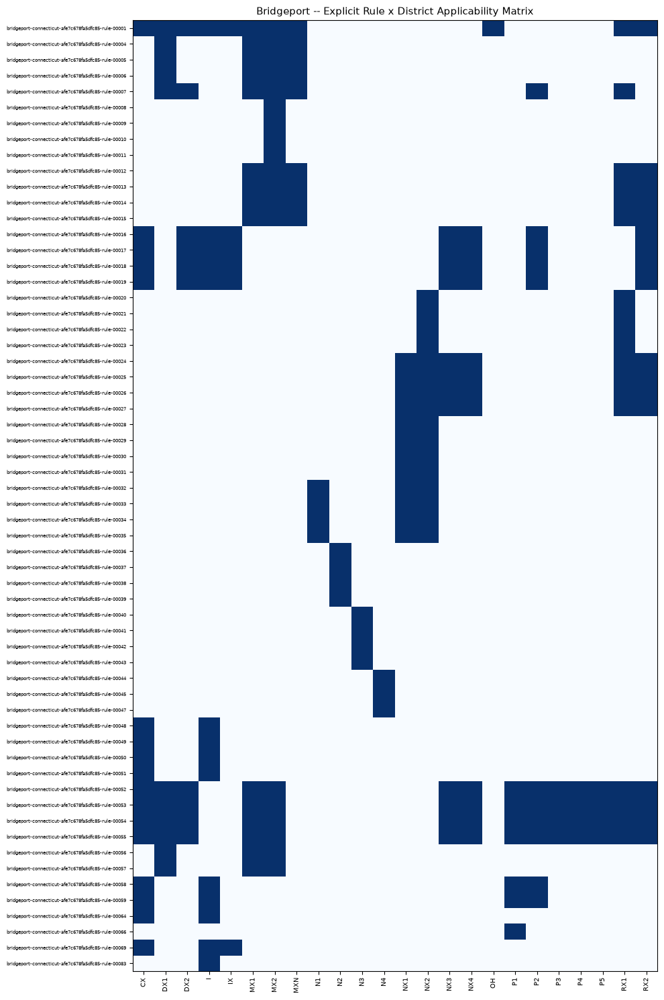

Saved: outputs/figures/bridgeport/step_06_applicability_matrix_heatmap.png


In [94]:
if applicability_matrix_df.shape[0] > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.25 * applicability_matrix_df.shape[0])))
    ax.imshow(applicability_matrix_df.astype(int).values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(applicability_matrix_df.shape[1]))
    ax.set_xticklabels(applicability_matrix_df.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(applicability_matrix_df.shape[0]))
    ax.set_yticklabels(applicability_matrix_df.index, fontsize=5)
    ax.set_title("Bridgeport -- Explicit Rule x District Applicability Matrix", fontsize=11)
    plt.tight_layout()
    applicability_heatmap_path = FIGURES_DIR / "step_06_applicability_matrix_heatmap.png"
    fig.savefig(applicability_heatmap_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {applicability_heatmap_path.relative_to(STAGE_A_ROOT)}")
else:
    print("No explicit applicability rows to plot.")

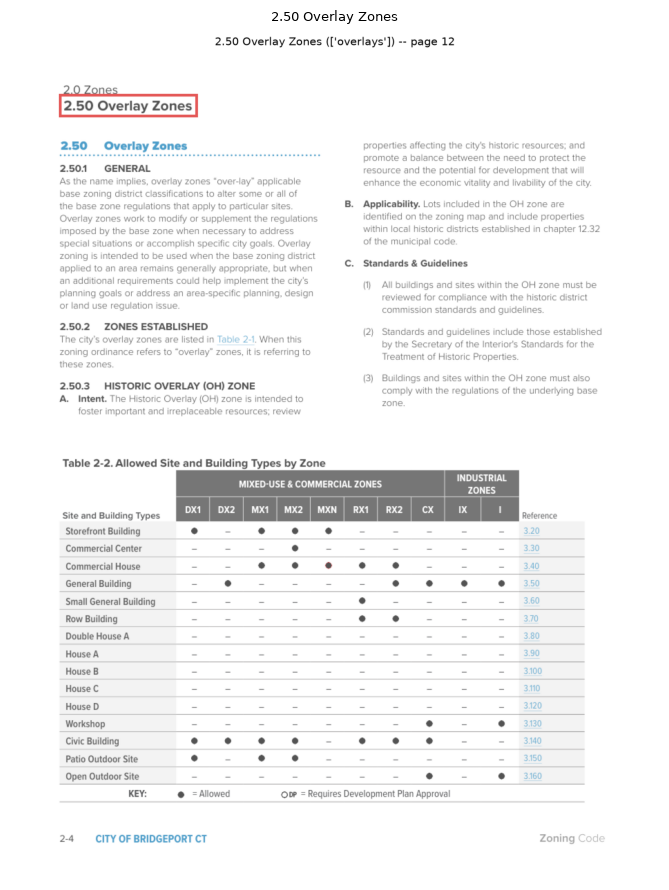

topics=['overlays']  scope_status=explicit  applicable_codes=['CX', 'DX1', 'DX2', 'I', 'IX', 'MX1', 'MX2', 'MXN', 'OH', 'RX1', 'RX2']
  excerpt: 2.50 Overlay Zones 2.50 Overlay Zones properties affecting the city's historic resources; and promote a balance between the need to protect the 2.50.1 GENERAL resource and the potential for development that will As the n...
----------------------------------------------------------------------------------------------------


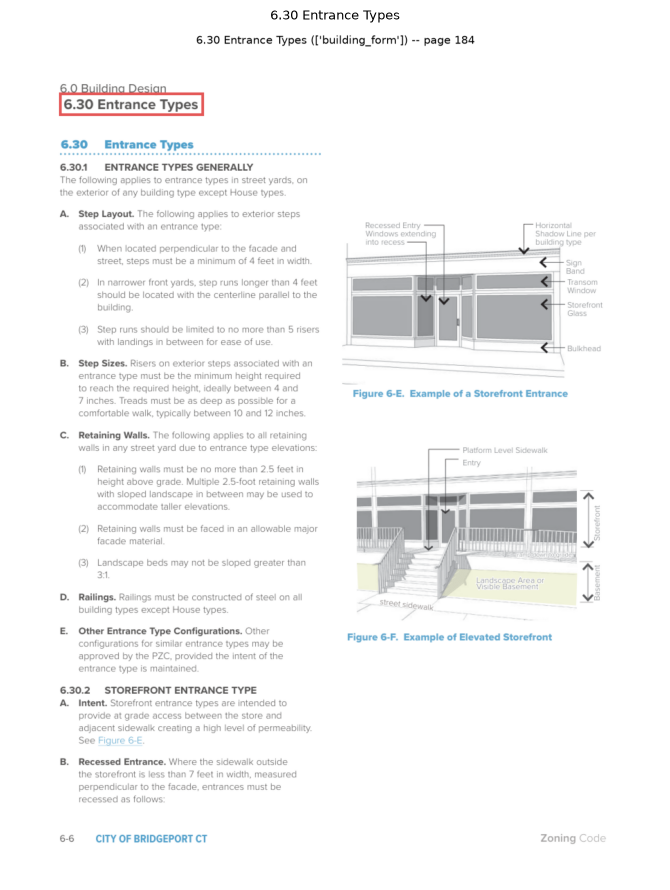

topics=['building_form']  scope_status=explicit  applicable_codes=[]
  excerpt: 6.30 Entrance Types 6.30 Entrance Types 6.30.1 ENTRANCE TYPES GENERALLY The following applies to entrance types in street yards, on the exterior of any building type except House types. A. Step Layout. The following appl...
----------------------------------------------------------------------------------------------------


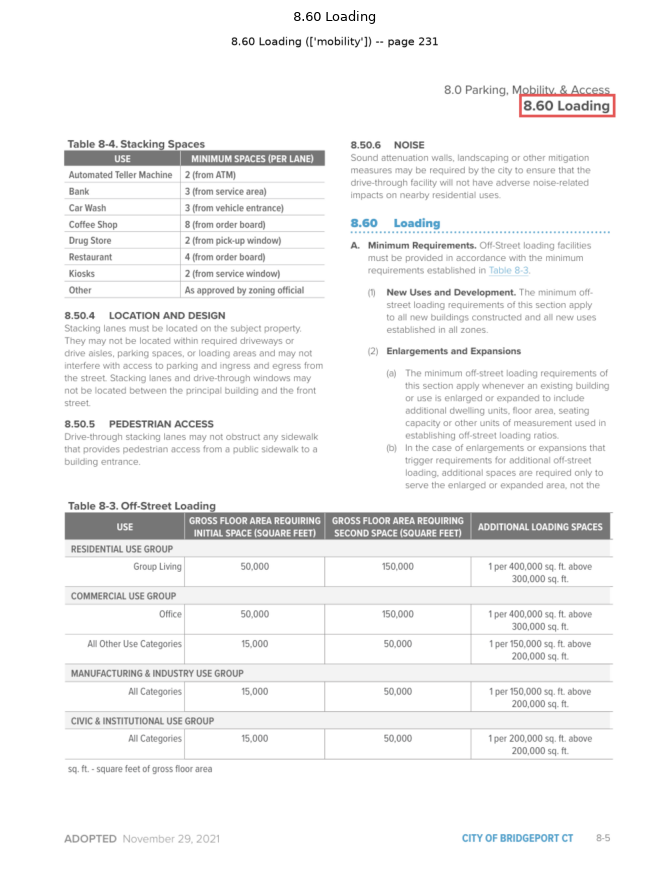

topics=['mobility']  scope_status=explicit  applicable_codes=['CX', 'I', 'IX']
  excerpt: 8.60 Loading 8.50.6 NOISE Sound attenuation walls, landscaping or other mitigation measures may be required by the city to ensure that the drive-through facility will not have adverse noise-related impacts on nearby resi...
----------------------------------------------------------------------------------------------------


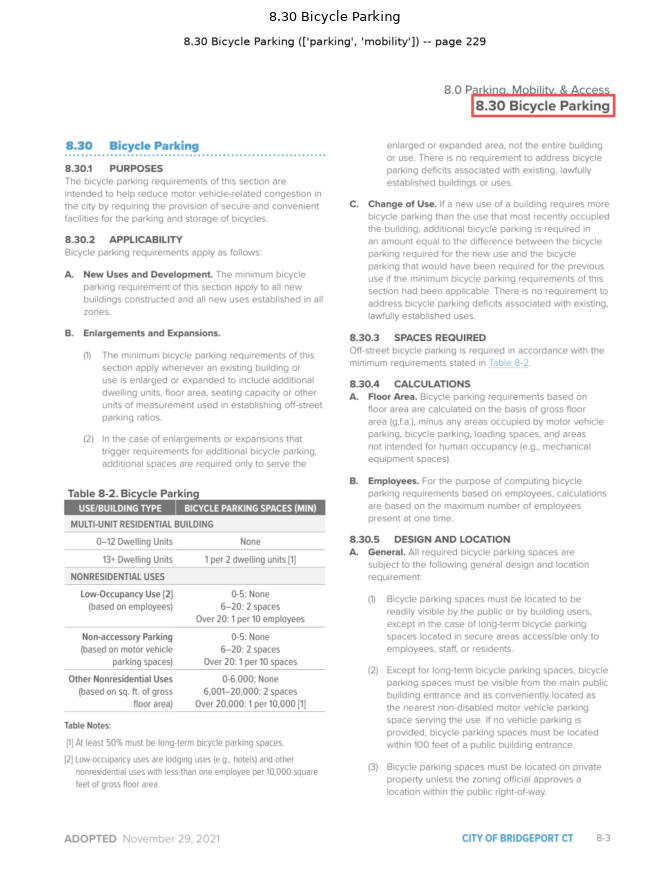

topics=['parking', 'mobility']  scope_status=explicit  applicable_codes=[]
  excerpt: 8.30 Bicycle Parking 8.30 Bicycle Parking enlarged or expanded area, not the entire building or use. There is no requirement to address bicycle 8.30.1 PURPOSES parking deficits associated with existing, lawfully The bicy...
----------------------------------------------------------------------------------------------------


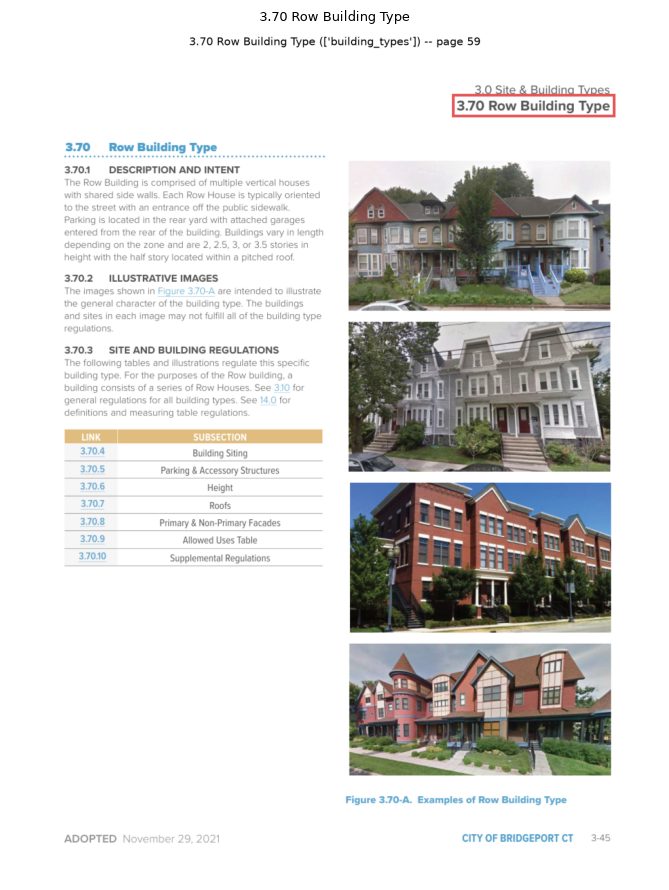

topics=['building_types']  scope_status=explicit  applicable_codes=['NX1', 'NX2', 'NX3', 'NX4', 'RX1', 'RX2']
  excerpt: 3.70 Row Building Type 3.70 Row Building Type 3.70.1 DESCRIPTION AND INTENT The Row Building is comprised of multiple vertical houses with shared side walls. Each Row House is typically oriented to the street with an ent...
----------------------------------------------------------------------------------------------------


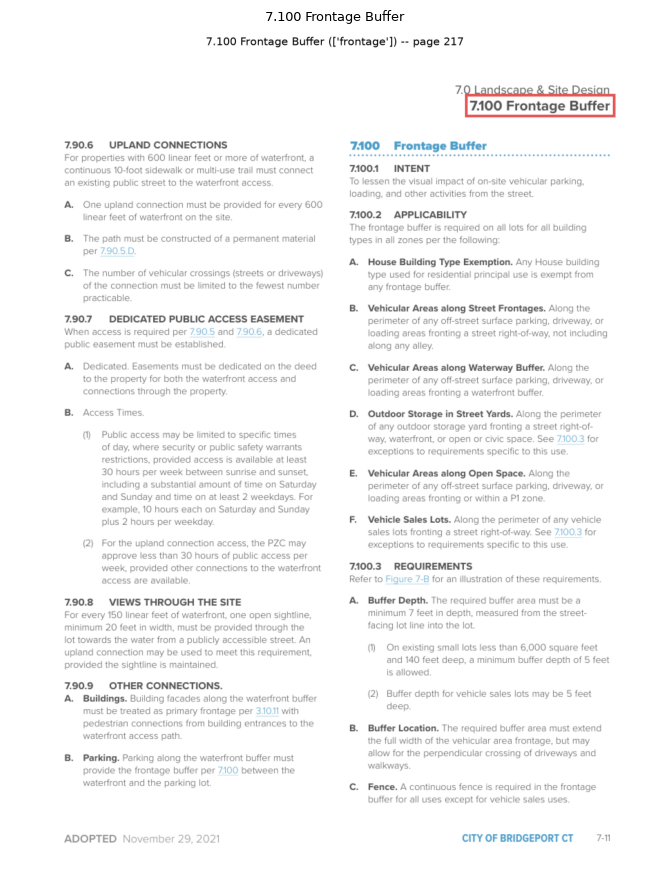

topics=['frontage']  scope_status=explicit  applicable_codes=['P1']
  excerpt: 7.100 Frontage Buffer 7.100 Frontage Buffer 7.90.6 UPLAND CONNECTIONS For properties with 600 linear feet or more of waterfront, a 7.100.1 INTENT continuous 10-foot sidewalk or multi-use trail must connect To lessen the ...
----------------------------------------------------------------------------------------------------
Saved: outputs/review/bridgeport/step_06_rule_evidence_cards.csv


In [95]:
rule_evidence_card_samples = rule_library_df.sort_values("source_confidence", ascending=False).drop_duplicates(
    subset=["topic_tags"]
).head(6)

for _, rule_row in rule_evidence_card_samples.iterrows():
    anchor_heading_row = heading_candidates_repaired_df.loc[heading_candidates_repaired_df["node_id"] == rule_row["source_node"]].iloc[0]
    save_path = render_bbox_highlight(
        int(anchor_heading_row["page_number"]),
        (anchor_heading_row["bbox_x0"], anchor_heading_row["bbox_y0"], anchor_heading_row["bbox_x1"], anchor_heading_row["bbox_y1"]),
        f"{rule_row['heading']} ({json.loads(rule_row['topic_tags'])})", f"step_06_rule_card_{rule_row['rule_id'].split('-rule-')[-1]}.png",
    )
    display_saved_image(save_path, title=rule_row["heading"])
    print(f"topics={json.loads(rule_row['topic_tags'])}  scope_status={rule_row['scope_status']}  "
          f"applicable_codes={json.loads(rule_row['applicable_district_codes']) if rule_row['scope_status']=='explicit' else '[]'}")
    print(f"  excerpt: {rule_row['full_source_text'][:220]}...")
    print("-" * 100)

rule_evidence_cards_path = REVIEW_DIR / "step_06_rule_evidence_cards.csv"
rule_evidence_card_samples.to_csv(rule_evidence_cards_path, index=False)
print(f"Saved: {rule_evidence_cards_path.relative_to(STAGE_A_ROOT)}")

### 15.4 Stage 6 final summary

In [96]:
stage_6_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "rule_candidate_count": int(len(rule_library_df)),
    "topic_counts": topic_counts.to_dict(),
    "explicit_scope_count": int((rule_library_df["scope_status"] == "explicit").sum()),
    "ambiguous_scope_count": int((rule_library_df["scope_status"] == "ambiguous").sum()),
    "applicability_matrix_rule_count": int(applicability_matrix_df.shape[0]),
    "applicability_matrix_district_count": int(applicability_matrix_df.shape[1]),
}

stage_6_log_path = LOGS_DIR / "step_06_rule_library_log.json"
with stage_6_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_6_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 6 (townwide/general rule library) COMPLETE")
print("=" * 70)
for key, value in stage_6_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_6_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 6 (townwide/general rule library) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
rule_candidate_count: 83
topic_counts: {'parking': 18, 'building_form': 17, 'permitted_uses': 17, 'definitions': 16, 'building_types': 15, 'nonconformity': 8, 'mobility': 2, 'overlays': 1, 'frontage': 1, 'site_plan_review': 1, 'special_permits': 1, 'approval_procedures': 1, 'build_to': 1}
explicit_scope_count: 70
ambiguous_scope_count: 13
applicability_matrix_rule_count: 60
applicability_matrix_district_count: 24

Saved: outputs/logs/bridgeport/step_06_rule_library_log.json


## 16. Stage 7 -- GIS crosswalk and gross area context

This stage validates the Bridgeport GIS export already previewed in Stage 3 and completes the
district-code crosswalk. **No dominant district is selected here or anywhere in this notebook.**
Only `gross_mapped_area_acres` is computed -- this layer is parcel-level/parcel-derived (per the
Bridgeport README), so it is never called `developable_residential_area_acres`,
`buildable_area_acres`, or any other field implying a buildable-area determination.

In [97]:
gis_validation_checks = [
    ("geometry_is_polygon_or_multipolygon", bool(bridgeport_gis_preview_gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"]).all())),
    ("crs_is_known", bridgeport_gis_preview_gdf.crs is not None),
    ("ZONE_2021_values_present", bool(bridgeport_gis_preview_gdf["ZONE_2021"].notna().all())),
    ("feature_count_positive", len(bridgeport_gis_preview_gdf) > 0),
    ("expected_fields_present", all(c in bridgeport_gis_preview_gdf.columns for c in ["ZONE_2021", "LOCAL_HISTDIST", "OBJECTID"])),
]
gis_validation_df = pd.DataFrame(gis_validation_checks, columns=["validation_rule", "passed"])
print(gis_validation_df.to_string(index=False))
print(f"\nAll GIS validation checks passed: {bool(gis_validation_df['passed'].all())}")

gis_inventory_path = TABLES_DIR / "step_07_gis_inventory.csv"
pd.DataFrame({
    "metric": ["feature_count", "crs", "geometry_types", "zone_2021_unique_values", "local_histdist_nonnull_count"],
    "value": [len(bridgeport_gis_preview_gdf), str(bridgeport_gis_preview_gdf.crs),
              str(bridgeport_gis_preview_gdf.geometry.geom_type.unique().tolist()),
              bridgeport_gis_preview_gdf["ZONE_2021"].nunique(),
              int(bridgeport_gis_preview_gdf["LOCAL_HISTDIST"].notna().sum())],
}).to_csv(gis_inventory_path, index=False)
print(f"Saved: {gis_inventory_path.relative_to(STAGE_A_ROOT)}")

                    validation_rule  passed
geometry_is_polygon_or_multipolygon    True
                       crs_is_known    True
           ZONE_2021_values_present    True
             feature_count_positive    True
            expected_fields_present    True

All GIS validation checks passed: True
Saved: outputs/tables/bridgeport/step_07_gis_inventory.csv


In [98]:
CT_PROJECTED_CRS = "EPSG:26918"  # NAD83 / UTM zone 18N -- Connecticut-appropriate for area calculations

bridgeport_gis_projected_gdf = bridgeport_gis_preview_gdf.to_crs(CT_PROJECTED_CRS)
dissolved_zones_gdf = bridgeport_gis_projected_gdf.dissolve(by="ZONE_2021", as_index=False)
dissolved_zones_gdf["gross_mapped_area_acres"] = dissolved_zones_gdf.geometry.area / 4046.8564224

dissolved_gross_area_df = dissolved_zones_gdf[["ZONE_2021", "gross_mapped_area_acres"]].rename(columns={"ZONE_2021": "district_code"})
dissolved_gross_area_df = dissolved_gross_area_df.sort_values("gross_mapped_area_acres", ascending=False)
print(dissolved_gross_area_df.to_string(index=False))

dissolved_gross_area_path = PROCESSED_DIR / "step_07_dissolved_gross_area.csv"
dissolved_gross_area_df.to_csv(dissolved_gross_area_path, index=False)
print(f"\nSaved: {dissolved_gross_area_path.relative_to(STAGE_A_ROOT)}")

district_code  gross_mapped_area_acres
           P1               131.506436
          NX1               122.481435
           N3                93.256572
            I                79.544985
          NX2                45.485523
           N2                36.309985
          NX3                25.073624
           P2                25.042707
           P4                21.786169
          RX1                20.877791
          RX2                18.113332
           N1                15.569467
          MX1                14.215419
          NX4                 3.479394
           IX                 1.969957
          MXN                 0.858035

Saved: data/processed/bridgeport/step_07_dissolved_gross_area.csv


### 16.1 Zone-code crosswalk

Reuses Stage 3's own GIS-only / ordinance-only code lists (exact match only -- no fuzzy matching)
rather than recomputing a separate, possibly inconsistent crosswalk.

In [99]:
zone_crosswalk_df = district_registry_df[["district_code", "district_name", "preliminary_district_category", "gis_presence"]].merge(
    dissolved_gross_area_df, on="district_code", how="left"
)
zone_crosswalk_df["in_ordinance_text"] = zone_crosswalk_df["district_code"].isin(ordinance_codes)
zone_crosswalk_df["crosswalk_status"] = np.select(
    [zone_crosswalk_df["gis_presence"] & zone_crosswalk_df["in_ordinance_text"],
     zone_crosswalk_df["gis_presence"] & ~zone_crosswalk_df["in_ordinance_text"],
     ~zone_crosswalk_df["gis_presence"] & zone_crosswalk_df["in_ordinance_text"]],
    ["both", "gis_only", "ordinance_only"], default="neither",
)

exact_match_rate = float((zone_crosswalk_df["crosswalk_status"] == "both").mean())
print(f"Exact-match crosswalk rate: {exact_match_rate:.1%}")
print(zone_crosswalk_df[["district_code", "crosswalk_status", "gross_mapped_area_acres"]].to_string(index=False))

zone_crosswalk_path = PROCESSED_DIR / "bridgeport_gis_zone_crosswalk.csv"
zone_crosswalk_df.to_csv(zone_crosswalk_path, index=False)
print(f"\nSaved: {zone_crosswalk_path.relative_to(STAGE_A_ROOT)}")

unmatched_gis_path = REVIEW_DIR / "step_07_unmatched_gis_codes.csv"
unmatched_ordinance_path = REVIEW_DIR / "step_07_unmatched_ordinance_codes.csv"
zone_crosswalk_df.loc[zone_crosswalk_df["crosswalk_status"] == "gis_only"].to_csv(unmatched_gis_path, index=False)
zone_crosswalk_df.loc[zone_crosswalk_df["crosswalk_status"] == "ordinance_only"].to_csv(unmatched_ordinance_path, index=False)
print(f"Saved: {unmatched_gis_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {unmatched_ordinance_path.relative_to(STAGE_A_ROOT)}")

Exact-match crosswalk rate: 66.7%
district_code crosswalk_status  gross_mapped_area_acres
           CX   ordinance_only                      NaN
          DX1   ordinance_only                      NaN
          DX2   ordinance_only                      NaN
            I             both                79.544985
           IX             both                 1.969957
          MX1             both                14.215419
          MX2   ordinance_only                      NaN
          MXN             both                 0.858035
           N1             both                15.569467
           N2             both                36.309985
           N3             both                93.256572
           N4   ordinance_only                      NaN
          NX1             both               122.481435
          NX2             both                45.485523
          NX3             both                25.073624
          NX4             both                 3.479394
           OH 

### 16.2 Historic-overlay summary (`LOCAL_HISTDIST`)

In [100]:
historic_overlay_summary_df = (
    bridgeport_gis_preview_gdf.loc[bridgeport_gis_preview_gdf["LOCAL_HISTDIST"].notna()]
    .groupby("LOCAL_HISTDIST").size().reset_index(name="feature_count").sort_values("feature_count", ascending=False)
)
print(f"Distinct LOCAL_HISTDIST values: {len(historic_overlay_summary_df)}")
print(historic_overlay_summary_df.to_string(index=False))

historic_overlay_path = TABLES_DIR / "step_07_historic_overlay_summary.csv"
historic_overlay_summary_df.to_csv(historic_overlay_path, index=False)
print(f"\nSaved: {historic_overlay_path.relative_to(STAGE_A_ROOT)}")

Distinct LOCAL_HISTDIST values: 2
LOCAL_HISTDIST  feature_count
BLACK ROCK HAR            104
   MARINA PARK              7

Saved: outputs/tables/bridgeport/step_07_historic_overlay_summary.csv


### 16.3 Required visuals

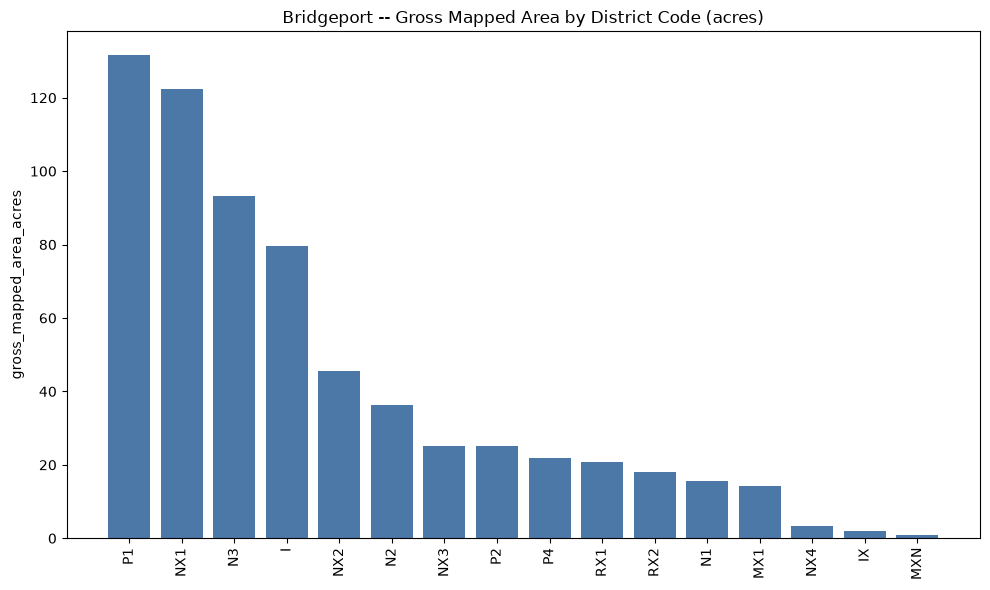

Saved: outputs/figures/bridgeport/step_07_gross_area_chart.png


In [101]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(dissolved_gross_area_df["district_code"], dissolved_gross_area_df["gross_mapped_area_acres"], color="#4C78A8")
ax.set_title("Bridgeport -- Gross Mapped Area by District Code (acres)", fontsize=12)
ax.set_ylabel("gross_mapped_area_acres")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
gross_area_chart_path = FIGURES_DIR / "step_07_gross_area_chart.png"
fig.savefig(gross_area_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {gross_area_chart_path.relative_to(STAGE_A_ROOT)}")

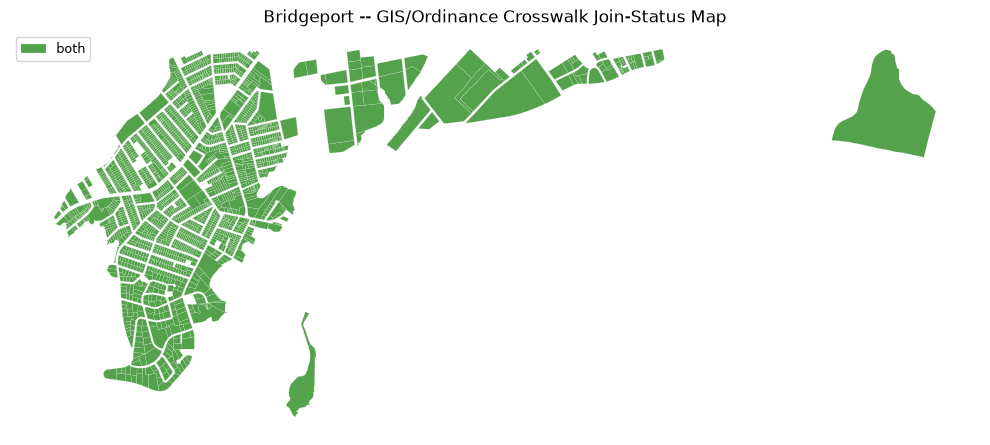

Saved: outputs/figures/bridgeport/step_07_join_status_map.png

Note: the preliminary district-category map was already produced in Stage 3 (step_03_preliminary_taxonomy_map.png) and is not regenerated here.


In [102]:
join_status_gdf = bridgeport_gis_preview_gdf.merge(
    zone_crosswalk_df[["district_code", "crosswalk_status"]], left_on="ZONE_2021", right_on="district_code", how="left"
)
status_colors = {"both": "#54A24B", "gis_only": "#F58518", "ordinance_only": "#E45756", "neither": "#BAB0AC"}

fig, ax = plt.subplots(figsize=(10, 10))
for status, color in status_colors.items():
    subset = join_status_gdf.loc[join_status_gdf["crosswalk_status"] == status]
    if len(subset):
        subset.plot(ax=ax, color=color, label=status, edgecolor="white", linewidth=0.1)
ax.set_title("Bridgeport -- GIS/Ordinance Crosswalk Join-Status Map", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.set_axis_off()
plt.tight_layout()
join_status_map_path = FIGURES_DIR / "step_07_join_status_map.png"
fig.savefig(join_status_map_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {join_status_map_path.relative_to(STAGE_A_ROOT)}")
print("\nNote: the preliminary district-category map was already produced in Stage 3 "
      "(step_03_preliminary_taxonomy_map.png) and is not regenerated here.")

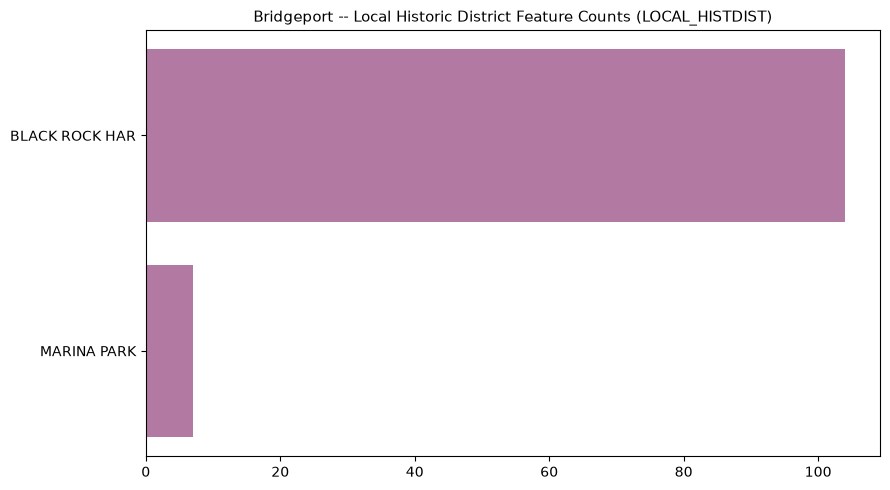

Saved: outputs/figures/bridgeport/step_07_historic_overlay_summary.png


In [103]:
if len(historic_overlay_summary_df):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(historic_overlay_summary_df["LOCAL_HISTDIST"][::-1], historic_overlay_summary_df["feature_count"][::-1], color="#B279A2")
    ax.set_title("Bridgeport -- Local Historic District Feature Counts (LOCAL_HISTDIST)", fontsize=11)
    plt.tight_layout()
    historic_overlay_chart_path = FIGURES_DIR / "step_07_historic_overlay_summary.png"
    fig.savefig(historic_overlay_chart_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {historic_overlay_chart_path.relative_to(STAGE_A_ROOT)}")

### 16.4 Source metadata attached to district records

In [104]:
district_registry_with_gis_source_df = zone_crosswalk_df.copy()
district_registry_with_gis_source_df["gis_source_url"] = (
    "https://services6.arcgis.com/mQcEelNKPZjQfrvM/arcgis/rest/services/Zoning___Sept2021_WFL1/FeatureServer/0"
)
district_registry_with_gis_source_df["gis_layer_name"] = "ZONE_2021_Parcels"
district_registry_with_gis_source_df["gis_local_file"] = str(GIS_PATH.relative_to(STAGE_A_ROOT))
district_registry_with_gis_source_df["gross_area_limitation_note"] = (
    "gross_mapped_area_acres is parcel-level/parcel-derived (per Bridgeport README), not a "
    "pre-dissolved zone-boundary layer, and excludes no water/ROW/non-buildable land. It is a "
    "gross figure only, never a buildable or developable area estimate."
)

district_metadata_path = PROCESSED_DIR / "bridgeport_district_metadata.csv"
district_registry_with_gis_source_df.to_csv(district_metadata_path, index=False)
print(f"Saved: {district_metadata_path.relative_to(STAGE_A_ROOT)}")

Saved: data/processed/bridgeport/bridgeport_district_metadata.csv


### 16.5 Stage 7 final summary

In [105]:
stage_7_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "gis_validation_all_passed": bool(gis_validation_df["passed"].all()),
    "gis_feature_count": int(len(bridgeport_gis_preview_gdf)),
    "dissolved_zone_count": int(len(dissolved_gross_area_df)),
    "exact_match_crosswalk_rate": round(exact_match_rate, 4),
    "crosswalk_status_counts": zone_crosswalk_df["crosswalk_status"].value_counts().to_dict(),
    "local_historic_district_count": int(len(historic_overlay_summary_df)),
    "gross_area_field_used": "gross_mapped_area_acres",
    "dominant_district_selected": False,
}

stage_7_log_path = LOGS_DIR / "step_07_gis_crosswalk_log.json"
with stage_7_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_7_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 7 (GIS crosswalk and gross area context) COMPLETE")
print("=" * 70)
for key, value in stage_7_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_7_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 7 (GIS crosswalk and gross area context) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
gis_validation_all_passed: True
gis_feature_count: 2000
dissolved_zone_count: 16
exact_match_crosswalk_rate: 0.6667
crosswalk_status_counts: {'both': 16, 'ordinance_only': 8}
local_historic_district_count: 2
gross_area_field_used: gross_mapped_area_acres
dominant_district_selected: False

Saved: outputs/logs/bridgeport/step_07_gis_crosswalk_log.json


## 17. Stage 8 -- Evidence bundles and conflicts

For every canonical district, `E_d = T_d^primary ∪ T_d^linked ∪ T_d^tables ∪ T_d^general ∪
T_d^overlay`, with each source type kept **separate** (never merged into one undifferentiated
blob). This is still the Collection Phase: no rule values are extracted or compared here --
"conflicts" below are evidence-level (multiple source passages about the same topic for the same
district, or a table/prose pair on the same ground) that get tagged with a role and a priority
rationale, never silently resolved to a single winning numeric value.

**Table policy carried forward from Stage 2's real finding**: `building_form_table_candidate` and
`parking_schedule_candidate` tables were directly inspected and found to be diagrams in 3 of 3
sampled cases, not data tables. Any table of those two types, or any table whose `review_status`
is not `retained_auto` (i.e. already flagged low-confidence or complex-layout), is treated
conservatively as `diagram_or_unverified_table_candidate` and kept **separate** from
`verified_table` evidence -- never silently promoted into final structured legal evidence.

In [106]:
def build_citation_linked_targets(anchor_node_id: str) -> list[str]:
    if not anchor_node_id or anchor_node_id not in citation_graph:
        return []
    return list(citation_graph.successors(anchor_node_id))


evidence_bundle_records = []

for _, registry_row in district_registry_df.iterrows():
    code = registry_row["district_code"]
    primary_block_rows = primary_blocks_df.loc[primary_blocks_df["district_code"] == code]
    has_primary = len(primary_block_rows) > 0
    primary_row = primary_block_rows.iloc[0] if has_primary else None

    linked_targets = build_citation_linked_targets(primary_row["anchor_node_id"]) if has_primary else []

    table_candidate_rows = district_candidates_raw_df.loc[
        (district_candidates_raw_df["candidate_code"] == code) & (district_candidates_raw_df["source_type"] == "table_cell")
    ]
    table_ids_for_district = sorted(table_candidate_rows["table_id"].unique().tolist())

    verified_table_ids, diagram_unverified_ids = [], []
    for table_id in table_ids_for_district:
        table_row = table_master_df.loc[table_master_df["table_id"] == table_id]
        if len(table_row) == 0:
            continue
        table_row = table_row.iloc[0]
        is_diagram_risk_type = table_row["table_type_candidate"] in {"building_form_table_candidate", "parking_schedule_candidate"}
        is_not_fully_trusted = table_row["review_status"] != "retained_auto"
        (diagram_unverified_ids if (is_diagram_risk_type or is_not_fully_trusted) else verified_table_ids).append(table_id)

    general_rule_ids = rule_library_df.loc[
        (rule_library_df["scope_status"] == "explicit")
        & rule_library_df["applicable_district_codes"].apply(lambda codes: code in json.loads(codes)),
        "rule_id",
    ].tolist()

    overlay_rule_ids = rule_library_df.loc[
        rule_library_df["topic_tags"].apply(lambda tags: bool({"overlays", "historic_district_rules"} & set(json.loads(tags))))
        & (rule_library_df["scope_status"] == "explicit")
        & (
            rule_library_df["applicable_district_codes"].apply(lambda codes: code in json.loads(codes) or "OH" in json.loads(codes))
            | rule_library_df["citywide"]
        ),
        "rule_id",
    ].tolist()

    evidence_bundle_records.append({
        "district_id": registry_row["district_id"], "district_code": code,
        "primary_text_present": has_primary,
        "primary_word_count": int(primary_row["word_count"]) if has_primary else 0,
        "linked_reference_ids": json.dumps(linked_targets),
        "verified_table_ids": json.dumps(verified_table_ids),
        "diagram_or_unverified_table_candidate_ids": json.dumps(diagram_unverified_ids),
        "general_rule_ids": json.dumps(general_rule_ids),
        "overlay_rule_ids": json.dumps(overlay_rule_ids),
        "source_pages": primary_row["source_pages"] if has_primary else json.dumps([]),
        "layout_warning": bool(primary_row["layout_warning"]) if has_primary else False,
        "confidence": float(primary_row["confidence"]) if has_primary else 0.0,
        "collection_review_status": "needs_review" if (not has_primary or (has_primary and primary_row["layout_warning"])) else "ok",
    })

evidence_bundles_df = pd.DataFrame(evidence_bundle_records)
print(f"Evidence bundles built: {len(evidence_bundles_df)} districts")
print(evidence_bundles_df[["district_code", "primary_text_present", "collection_review_status"]].to_string(index=False))

Evidence bundles built: 24 districts
district_code  primary_text_present collection_review_status
           CX                  True                       ok
          DX1                  True                       ok
          DX2                  True                       ok
            I                  True                       ok
           IX                  True                       ok
          MX1                  True                       ok
          MX2                  True                       ok
          MXN                  True                       ok
           N1                  True                       ok
           N2                  True                       ok
           N3                  True                       ok
           N4                  True                       ok
          NX1                  True                       ok
          NX2                 False             needs_review
          NX3                  True             

### 17.1 Conflict candidates (evidence-level, not rule-value-level)

Priority rules applied as **role tags**, never as silent deletion: definitions are always
`interpretive_context`; among same-topic, same-district rule candidates the one naming the fewest
districts (most specific) is `primary_evidence` and the rest are `modifier_evidence`;
overlay/historic-topic rules are always `modifier_evidence`. Severity is a simple, honestly-labeled
proxy (`medium` for 2 co-occurring sources, `high` for 3+) -- not a claim of detected semantic
contradiction, which would require actual rule-value extraction (explicitly out of scope here).

In [107]:
rule_lookup_for_conflicts = rule_library_df.set_index("rule_id")

conflict_candidate_records = []
for _, bundle_row in evidence_bundles_df.iterrows():
    code = bundle_row["district_code"]
    general_ids = json.loads(bundle_row["general_rule_ids"])

    by_topic: dict[str, list[str]] = {}
    for rule_id in general_ids:
        for topic in json.loads(rule_lookup_for_conflicts.loc[rule_id, "topic_tags"]):
            by_topic.setdefault(topic, []).append(rule_id)

    for topic, rule_ids in by_topic.items():
        if len(rule_ids) < 2:
            continue
        severity = "high" if len(rule_ids) >= 3 else "medium"
        entries = []
        for rule_id in rule_ids:
            n_codes = len(json.loads(rule_lookup_for_conflicts.loc[rule_id, "applicable_district_codes"]))
            role = "interpretive_context" if topic == "definitions" else None
            entries.append({"rule_id": rule_id, "n_codes": n_codes, "role": role})

        non_definition_entries = [e for e in entries if e["role"] is None]
        if non_definition_entries:
            non_definition_entries.sort(key=lambda e: e["n_codes"])
            non_definition_entries[0]["role"] = "primary_evidence"
            for e in non_definition_entries[1:]:
                e["role"] = "modifier_evidence"

        for e in entries:
            conflict_candidate_records.append({
                "district_code": code, "topic": topic, "rule_id": e["rule_id"], "role": e["role"],
                "conflict_group_size": len(rule_ids), "severity": severity,
                "heading": rule_lookup_for_conflicts.loc[e["rule_id"], "heading"],
            })

    verified_tables = json.loads(bundle_row["verified_table_ids"])
    if verified_tables and general_ids:
        conflict_candidate_records.append({
            "district_code": code, "topic": "table_vs_prose_priority", "rule_id": verified_tables[0],
            "role": "primary_evidence", "conflict_group_size": len(verified_tables) + len(general_ids),
            "severity": "low", "heading": "verified_table_outranks_directly_comparable_prose",
        })

conflict_candidates_df = pd.DataFrame(conflict_candidate_records)
print(f"Conflict candidates: {len(conflict_candidates_df)}")
if len(conflict_candidates_df):
    print(conflict_candidates_df["severity"].value_counts())

conflict_audit_path = TABLES_DIR / "step_08_conflict_candidate_audit.csv"
conflict_candidates_df.to_csv(conflict_audit_path, index=False)
print(f"Saved: {conflict_audit_path.relative_to(STAGE_A_ROOT)}")

conflict_log_path = LOGS_DIR / "step_08_conflict_log.json"
with conflict_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump({
        "total_conflict_candidates": len(conflict_candidates_df),
        "severity_counts": conflict_candidates_df["severity"].value_counts().to_dict() if len(conflict_candidates_df) else {},
        "districts_with_conflicts": int(conflict_candidates_df["district_code"].nunique()) if len(conflict_candidates_df) else 0,
        "resolution_policy": "role-tagged (primary_evidence/modifier_evidence/interpretive_context); no candidate deleted; no rule value compared or extracted",
    }, file_handle, indent=2, default=str)
print(f"Saved: {conflict_log_path.relative_to(STAGE_A_ROOT)}")

conflict_review_queue_path = REVIEW_DIR / "step_08_conflict_manual_review_queue.csv"
conflict_candidates_df.loc[conflict_candidates_df["severity"] == "high"].to_csv(conflict_review_queue_path, index=False)
print(f"Saved: {conflict_review_queue_path.relative_to(STAGE_A_ROOT)}")

Conflict candidates: 250
severity
high      206
medium     32
low        12
Name: count, dtype: int64
Saved: outputs/tables/bridgeport/step_08_conflict_candidate_audit.csv
Saved: outputs/logs/bridgeport/step_08_conflict_log.json
Saved: outputs/review/bridgeport/step_08_conflict_manual_review_queue.csv


### 17.2 Required outputs and visuals

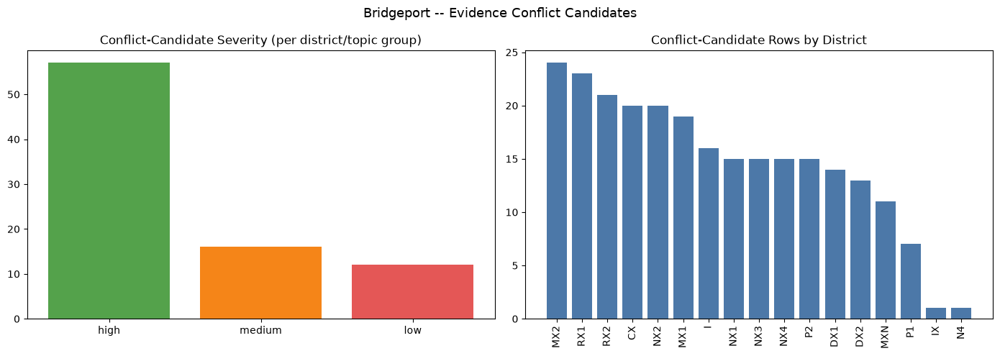

Saved: outputs/figures/bridgeport/step_08_conflict_severity.png


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if len(conflict_candidates_df):
    severity_counts = conflict_candidates_df.drop_duplicates(subset=["district_code", "topic"])["severity"].value_counts()
    axes[0].bar(severity_counts.index, severity_counts.values, color=["#54A24B", "#F58518", "#E45756"])
axes[0].set_title("Conflict-Candidate Severity (per district/topic group)")

counts_by_district = conflict_candidates_df["district_code"].value_counts() if len(conflict_candidates_df) else pd.Series(dtype=int)
axes[1].bar(counts_by_district.index, counts_by_district.values, color="#4C78A8")
axes[1].set_title("Conflict-Candidate Rows by District")
axes[1].tick_params(axis="x", rotation=90)

plt.suptitle("Bridgeport -- Evidence Conflict Candidates", fontsize=13)
plt.tight_layout()
conflict_severity_path = FIGURES_DIR / "step_08_conflict_severity.png"
fig.savefig(conflict_severity_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {conflict_severity_path.relative_to(STAGE_A_ROOT)}")

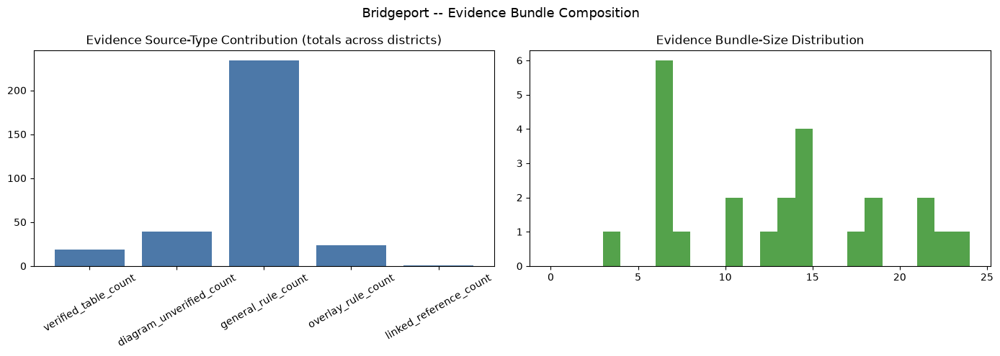

Saved: outputs/figures/bridgeport/step_08_source_type_contribution.png
Saved: outputs/tables/bridgeport/step_08_bundle_source_type_contribution.csv


In [109]:
source_type_contribution_df = evidence_bundles_df.assign(
    verified_table_count=evidence_bundles_df["verified_table_ids"].apply(lambda v: len(json.loads(v))),
    diagram_unverified_count=evidence_bundles_df["diagram_or_unverified_table_candidate_ids"].apply(lambda v: len(json.loads(v))),
    general_rule_count=evidence_bundles_df["general_rule_ids"].apply(lambda v: len(json.loads(v))),
    overlay_rule_count=evidence_bundles_df["overlay_rule_ids"].apply(lambda v: len(json.loads(v))),
    linked_reference_count=evidence_bundles_df["linked_reference_ids"].apply(lambda v: len(json.loads(v))),
)
source_type_contribution_df["bundle_size"] = (
    source_type_contribution_df["primary_text_present"].astype(int)
    + source_type_contribution_df["verified_table_count"] + source_type_contribution_df["general_rule_count"]
    + source_type_contribution_df["overlay_rule_count"] + source_type_contribution_df["linked_reference_count"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
contribution_totals = source_type_contribution_df[
    ["verified_table_count", "diagram_unverified_count", "general_rule_count", "overlay_rule_count", "linked_reference_count"]
].sum()
axes[0].bar(contribution_totals.index, contribution_totals.values, color="#4C78A8")
axes[0].set_title("Evidence Source-Type Contribution (totals across districts)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(source_type_contribution_df["bundle_size"], bins=range(0, int(source_type_contribution_df["bundle_size"].max()) + 2), color="#54A24B")
axes[1].set_title("Evidence Bundle-Size Distribution")

plt.suptitle("Bridgeport -- Evidence Bundle Composition", fontsize=13)
plt.tight_layout()
contribution_chart_path = FIGURES_DIR / "step_08_source_type_contribution.png"
fig.savefig(contribution_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {contribution_chart_path.relative_to(STAGE_A_ROOT)}")

bundle_source_contribution_path = TABLES_DIR / "step_08_bundle_source_type_contribution.csv"
source_type_contribution_df.to_csv(bundle_source_contribution_path, index=False)
print(f"Saved: {bundle_source_contribution_path.relative_to(STAGE_A_ROOT)}")

In [110]:
page_coverage_df = source_type_contribution_df[["district_code", "primary_text_present", "source_pages"]].copy()
page_coverage_df["page_count"] = page_coverage_df["source_pages"].apply(lambda v: len(json.loads(v)))
page_coverage_path = TABLES_DIR / "step_08_page_coverage.csv"
page_coverage_df.to_csv(page_coverage_path, index=False)
print(f"Saved: {page_coverage_path.relative_to(STAGE_A_ROOT)}")

evidence_completeness_df = source_type_contribution_df[[
    "district_code", "primary_text_present", "verified_table_count", "diagram_unverified_count",
    "general_rule_count", "overlay_rule_count", "linked_reference_count", "bundle_size", "collection_review_status",
]]
evidence_completeness_path = TABLES_DIR / "step_08_evidence_completeness.csv"
evidence_completeness_df.to_csv(evidence_completeness_path, index=False)
print(f"Saved: {evidence_completeness_path.relative_to(STAGE_A_ROOT)}")
print(evidence_completeness_df.to_string(index=False))

Saved: outputs/tables/bridgeport/step_08_page_coverage.csv
Saved: outputs/tables/bridgeport/step_08_evidence_completeness.csv
district_code  primary_text_present  verified_table_count  diagram_unverified_count  general_rule_count  overlay_rule_count  linked_reference_count  bundle_size collection_review_status
           CX                  True                     3                         4                  17                   1                       0           22                       ok
          DX1                  True                     1                         0                  11                   1                       0           14                       ok
          DX2                  True                     1                         3                  10                   1                       0           13                       ok
            I                  True                     2                         3                  14                   1       

DISTRICT EVIDENCE CARD -- CX
primary_text_present=True  verified_tables=['bridgeport-connecticut-afe7c678fa5dfc85-table-012-00', 'bridgeport-connecticut-afe7c678fa5dfc85-table-109-01', 'bridgeport-connecticut-afe7c678fa5dfc85-table-219-00']  diagram_unverified=['bridgeport-connecticut-afe7c678fa5dfc85-table-049-00', 'bridgeport-connecticut-afe7c678fa5dfc85-table-113-00', 'bridgeport-connecticut-afe7c678fa5dfc85-table-131-00', 'bridgeport-connecticut-afe7c678fa5dfc85-table-133-00']
general_rules=17  overlay_rules=1  linked_references=0
collection_review_status=ok  confidence=0.9


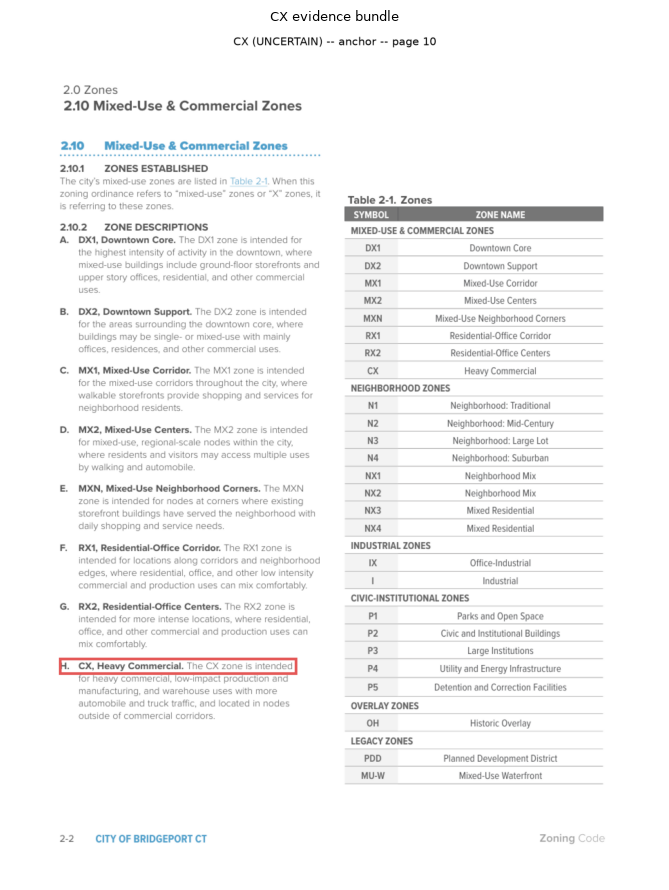

DISTRICT EVIDENCE CARD -- N4
primary_text_present=True  verified_tables=['bridgeport-connecticut-afe7c678fa5dfc85-table-100-01']  diagram_unverified=['bridgeport-connecticut-afe7c678fa5dfc85-table-105-00']
general_rules=3  overlay_rules=1  linked_references=0
collection_review_status=ok  confidence=0.9


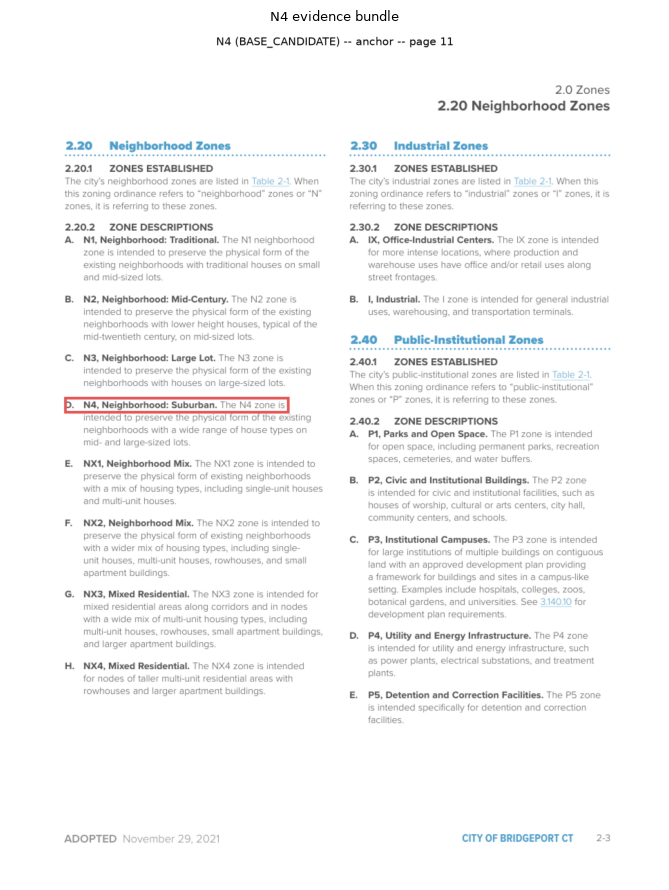

DISTRICT EVIDENCE CARD -- P5
primary_text_present=True  verified_tables=[]  diagram_unverified=['bridgeport-connecticut-afe7c678fa5dfc85-table-121-00']
general_rules=4  overlay_rules=1  linked_references=0
collection_review_status=ok  confidence=0.9


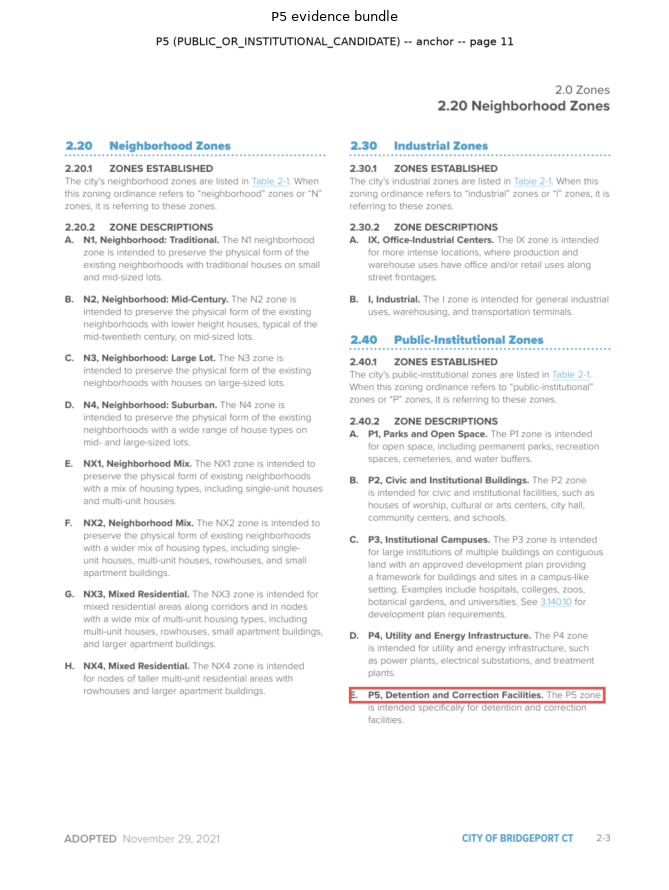

DISTRICT EVIDENCE CARD -- P4
primary_text_present=True  verified_tables=[]  diagram_unverified=['bridgeport-connecticut-afe7c678fa5dfc85-table-121-00']
general_rules=4  overlay_rules=1  linked_references=0
collection_review_status=ok  confidence=0.9


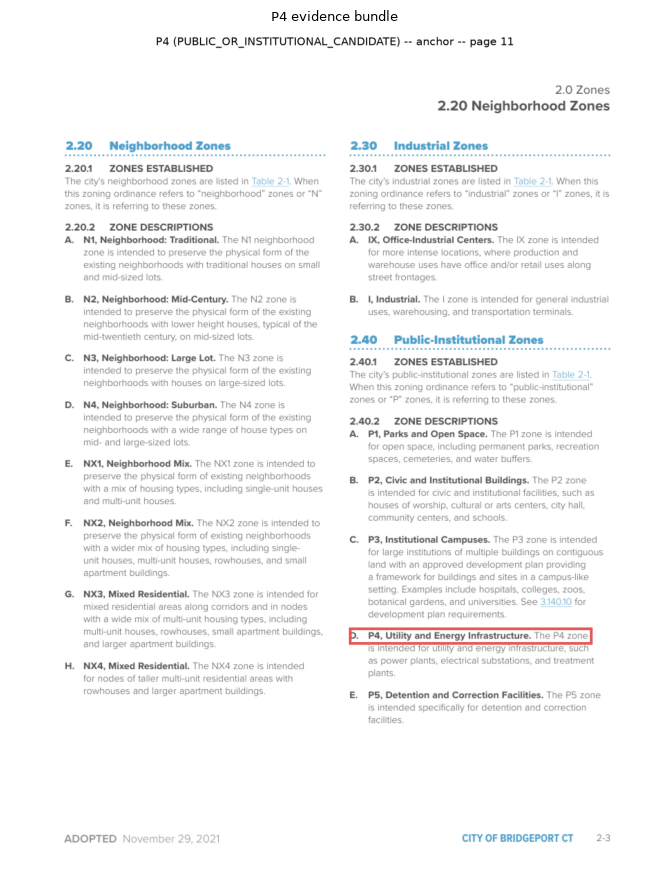


Saved: outputs/review/bridgeport/step_08_district_evidence_cards.csv


In [111]:
district_evidence_card_samples = evidence_bundles_df.sort_values("confidence", ascending=False).head(4)
evidence_card_records = []

for _, bundle_row in district_evidence_card_samples.iterrows():
    code = bundle_row["district_code"]
    print("=" * 100)
    print(f"DISTRICT EVIDENCE CARD -- {code}")
    print("=" * 100)
    print(f"primary_text_present={bundle_row['primary_text_present']}  "
          f"verified_tables={json.loads(bundle_row['verified_table_ids'])}  "
          f"diagram_unverified={json.loads(bundle_row['diagram_or_unverified_table_candidate_ids'])}")
    print(f"general_rules={len(json.loads(bundle_row['general_rule_ids']))}  "
          f"overlay_rules={len(json.loads(bundle_row['overlay_rule_ids']))}  "
          f"linked_references={len(json.loads(bundle_row['linked_reference_ids']))}")
    print(f"collection_review_status={bundle_row['collection_review_status']}  confidence={bundle_row['confidence']}")

    if bundle_row["primary_text_present"]:
        card_path = render_district_evidence_card(code)
        display_saved_image(card_path, title=f"{code} evidence bundle")

    evidence_card_records.append(bundle_row.to_dict())

district_evidence_cards_path = REVIEW_DIR / "step_08_district_evidence_cards.csv"
pd.DataFrame(evidence_card_records).to_csv(district_evidence_cards_path, index=False)
print(f"\nSaved: {district_evidence_cards_path.relative_to(STAGE_A_ROOT)}")

### 17.3 Stage 8 final summary

In [112]:
stage_8_log = {
    "document_id": DOCUMENT_ID,
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "evidence_bundle_count": int(len(evidence_bundles_df)),
    "districts_with_primary_text": int(evidence_bundles_df["primary_text_present"].sum()),
    "districts_needing_review": int((evidence_bundles_df["collection_review_status"] == "needs_review").sum()),
    "total_verified_table_links": int(source_type_contribution_df["verified_table_count"].sum()),
    "total_diagram_unverified_table_links": int(source_type_contribution_df["diagram_unverified_count"].sum()),
    "conflict_candidate_count": int(len(conflict_candidates_df)),
    "conflict_review_queue_count": int(len(conflict_candidates_df.loc[conflict_candidates_df["severity"] == "high"])) if len(conflict_candidates_df) else 0,
}

stage_8_log_path = LOGS_DIR / "step_08_evidence_bundles_log.json"
with stage_8_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(stage_8_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 04 -- STAGE 8 (evidence bundles and conflicts) COMPLETE")
print("=" * 70)
for key, value in stage_8_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {stage_8_log_path.relative_to(STAGE_A_ROOT)}")

BRIDGEPORT NOTEBOOK 04 -- STAGE 8 (evidence bundles and conflicts) COMPLETE
document_id: bridgeport-connecticut-afe7c678fa5dfc85
pipeline_run_timestamp: 2026-10-01T16:20:55.394243+00:00
evidence_bundle_count: 24
districts_with_primary_text: 22
districts_needing_review: 2
total_verified_table_links: 19
total_diagram_unverified_table_links: 39
conflict_candidate_count: 250
conflict_review_queue_count: 206

Saved: outputs/logs/bridgeport/step_08_evidence_bundles_log.json


## 18. Stage 9 -- Final collection export, manifest, and dashboard

In [113]:
final_evidence_bundles_df = evidence_bundles_df.merge(
    district_registry_df[["district_code", "district_name", "preliminary_district_category"]], on="district_code", how="left"
).merge(
    dissolved_gross_area_df, on="district_code", how="left"
).merge(
    primary_blocks_df[["district_code", "block_text"]].rename(columns={"block_text": "primary_block_text"}),
    on="district_code", how="left",
)

final_evidence_bundles_parquet_path = PROCESSED_DIR / "bridgeport_final_evidence_bundles.parquet"
final_evidence_bundles_csv_path = PROCESSED_DIR / "bridgeport_final_evidence_bundles.csv"
final_evidence_bundles_df.to_parquet(final_evidence_bundles_parquet_path, index=False)
final_evidence_bundles_df.to_csv(final_evidence_bundles_csv_path, index=False)
print(f"Saved: {final_evidence_bundles_parquet_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {final_evidence_bundles_csv_path.relative_to(STAGE_A_ROOT)}")

# bridgeport_district_metadata.csv and bridgeport_gis_zone_crosswalk.csv were already written in
# Stage 7 (district_registry_with_gis_source_df, zone_crosswalk_df); confirmed present below.
print(f"\nAlready saved in Stage 7: {district_metadata_path.relative_to(STAGE_A_ROOT)}")
print(f"Already saved in Stage 7: {zone_crosswalk_path.relative_to(STAGE_A_ROOT)}")

Saved: data/processed/bridgeport/bridgeport_final_evidence_bundles.parquet
Saved: data/processed/bridgeport/bridgeport_final_evidence_bundles.csv

Already saved in Stage 7: data/processed/bridgeport/bridgeport_district_metadata.csv
Already saved in Stage 7: data/processed/bridgeport/bridgeport_gis_zone_crosswalk.csv


In [114]:
diagram_or_unverified_table_candidates_df = table_master_df.loc[
    (table_master_df["table_type_candidate"].isin(["building_form_table_candidate", "parking_schedule_candidate"]))
    | (table_master_df["review_status"] != "retained_auto")
].copy()
diagram_or_unverified_table_candidates_df["diagram_risk_reason"] = np.where(
    diagram_or_unverified_table_candidates_df["table_type_candidate"].isin(["building_form_table_candidate", "parking_schedule_candidate"]),
    "table_type_candidate_empirically_confirmed_diagram_prone_in_stage_2_manual_inspection",
    "review_status_not_retained_auto",
)
diagram_candidates_path = PROCESSED_DIR / "step_09_diagram_or_unverified_table_candidates.csv"
diagram_or_unverified_table_candidates_df.to_csv(diagram_candidates_path, index=False)
print(f"Diagram/unverified table candidates: {len(diagram_or_unverified_table_candidates_df)} / {len(table_master_df)} retained tables")
print(f"Saved: {diagram_candidates_path.relative_to(STAGE_A_ROOT)}")

Diagram/unverified table candidates: 75 / 107 retained tables
Saved: data/processed/bridgeport/step_09_diagram_or_unverified_table_candidates.csv


### 18.1 Collection quality report

In [115]:
collection_quality_report = {
    "document_id": DOCUMENT_ID,
    "pdf_page_count": PDF_PAGE_COUNT,
    "ocr_pages_required": 0,
    "hierarchy_node_count": int(hierarchy_graph_repaired.number_of_nodes()),
    "retained_table_count": int(len(table_master_df)),
    "verified_vs_diagram_table_ratio": round(
        (len(table_master_df) - len(diagram_or_unverified_table_candidates_df)) / max(len(table_master_df), 1), 3
    ),
    "canonical_district_count": int(len(district_registry_df)),
    "districts_with_primary_text": int(evidence_bundles_df["primary_text_present"].sum()),
    "citation_resolution_rate": round(resolution_rate, 4),
    "gis_crosswalk_exact_match_rate": round(exact_match_rate, 4),
    "explicit_scope_rule_rate": round(float((rule_library_df["scope_status"] == "explicit").mean()), 4) if len(rule_library_df) else 0,
    "conflict_candidate_count": int(len(conflict_candidates_df)),
    "known_limitations": [
        "77 of 304 pages remain multi_column_or_complex and were not auto-reordered (Stage 1.5).",
        "building_form_table_candidate and parking_schedule_candidate tables are frequently vector-line diagrams, not data tables, per direct Stage 2 visual inspection (3/3 sampled).",
        "District-category keyword rules are a preliminary heuristic over narrative text, not a validated legal taxonomy.",
        "Most 'high severity' Stage 8 conflict candidates reflect a form-based code's natural multiplicity (several building types allowed per district, each with its own parking/form subsection) rather than a detected legal contradiction -- severity is a co-occurrence-count proxy, not semantic conflict detection.",
        "No rule values (numeric standards) were extracted in this notebook -- Collection Phase only.",
    ],
}
collection_quality_path = TABLES_DIR / "step_09_collection_quality_report.json"
with collection_quality_path.open("w", encoding="utf-8") as file_handle:
    json.dump(collection_quality_report, file_handle, indent=2, default=str)
for key, value in collection_quality_report.items():
    print(f"{key}: {value}")
print(f"\nSaved: {collection_quality_path.relative_to(STAGE_A_ROOT)}")

document_id: bridgeport-connecticut-afe7c678fa5dfc85
pdf_page_count: 304
ocr_pages_required: 0
hierarchy_node_count: 1941
retained_table_count: 107
verified_vs_diagram_table_ratio: 0.299
canonical_district_count: 24
districts_with_primary_text: 22
citation_resolution_rate: 0.9321
gis_crosswalk_exact_match_rate: 0.6667
explicit_scope_rule_rate: 0.8434
conflict_candidate_count: 250
known_limitations: ['77 of 304 pages remain multi_column_or_complex and were not auto-reordered (Stage 1.5).', 'building_form_table_candidate and parking_schedule_candidate tables are frequently vector-line diagrams, not data tables, per direct Stage 2 visual inspection (3/3 sampled).', 'District-category keyword rules are a preliminary heuristic over narrative text, not a validated legal taxonomy.', "Most 'high severity' Stage 8 conflict candidates reflect a form-based code's natural multiplicity (several building types allowed per district, each with its own parking/form subsection) rather than a detected le

### 18.2 Final Bridgeport collection dashboard (11 panels, each with a limitation note)

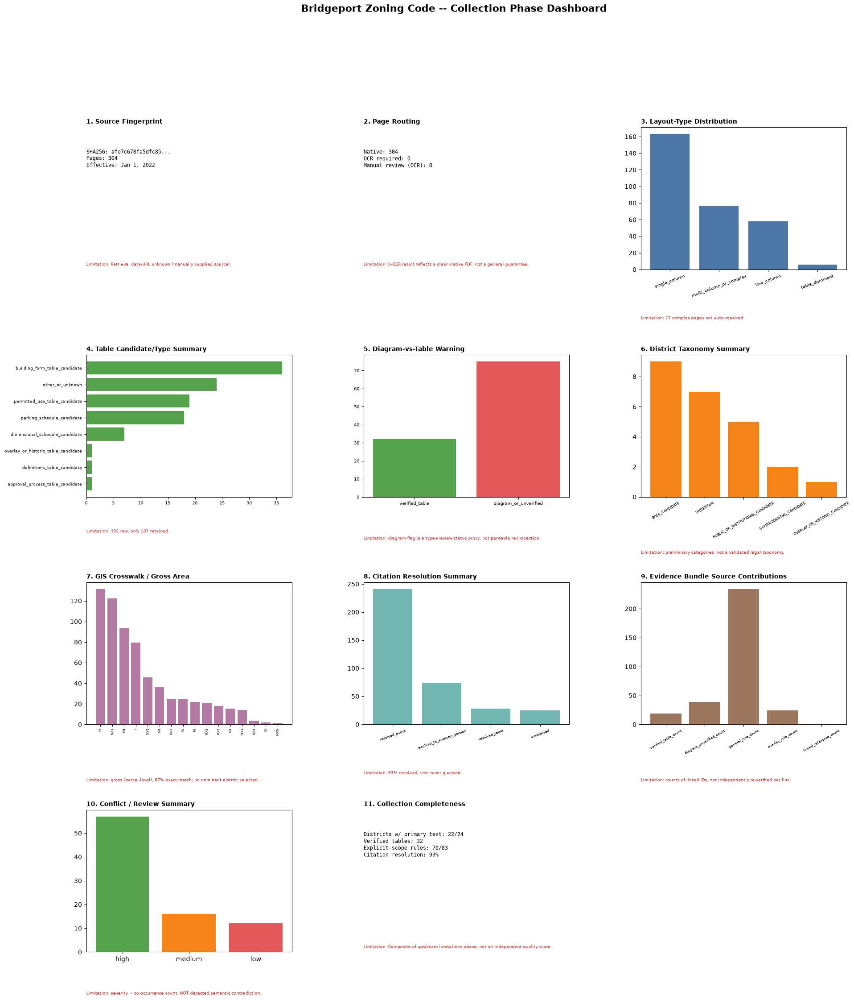

Saved: outputs/figures/bridgeport/bridgeport_collection_dashboard.png


In [116]:
fig = plt.figure(figsize=(22, 24))
grid = fig.add_gridspec(4, 3, hspace=0.6, wspace=0.35)


def panel_text(ax, title, lines, note):
    ax.axis("off")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax.text(0.0, 0.85, "\n".join(lines), fontsize=8.5, va="top", family="monospace")
    ax.text(0.0, 0.02, f"Limitation: {note}", fontsize=6.5, va="bottom", color="#B22222", wrap=True)


ax1 = fig.add_subplot(grid[0, 0])
panel_text(ax1, "1. Source Fingerprint", [
    f"SHA256: {PDF_SHA256[:16]}...", f"Pages: {PDF_PAGE_COUNT}", f"Effective: Jan 1, 2022",
], "Retrieval date/URL unknown (manually supplied source).")

ax2 = fig.add_subplot(grid[0, 1])
panel_text(ax2, "2. Page Routing", [f"Native: {PDF_PAGE_COUNT}", "OCR required: 0", "Manual review (OCR): 0"],
           "0-OCR result reflects a clean native PDF, not a general guarantee.")

ax3 = fig.add_subplot(grid[0, 2])
layout_counts_dash = page_layout_detection_df["page_layout_type"].value_counts()
ax3.bar(layout_counts_dash.index, layout_counts_dash.values, color="#4C78A8")
ax3.set_title("3. Layout-Type Distribution", fontsize=10, fontweight="bold", loc="left")
ax3.tick_params(axis="x", rotation=20, labelsize=7)
ax3.text(0.0, -0.35, "Limitation: 77 complex pages not auto-repaired.", transform=ax3.transAxes, fontsize=6.5, color="#B22222")

ax4 = fig.add_subplot(grid[1, 0])
type_counts_dash = table_type_candidates_df["table_type_candidate"].value_counts()
ax4.barh(type_counts_dash.index[::-1], type_counts_dash.values[::-1], color="#54A24B")
ax4.set_title("4. Table Candidate/Type Summary", fontsize=10, fontweight="bold", loc="left")
ax4.tick_params(labelsize=6.5)
ax4.text(0.0, -0.25, f"Limitation: {len(raw_table_candidates_df)} raw, only {len(table_master_df)} retained.", transform=ax4.transAxes, fontsize=6.5, color="#B22222")

ax5 = fig.add_subplot(grid[1, 1])
diagram_counts = pd.Series({
    "verified_table": len(table_master_df) - len(diagram_or_unverified_table_candidates_df),
    "diagram_or_unverified": len(diagram_or_unverified_table_candidates_df),
})
ax5.bar(diagram_counts.index, diagram_counts.values, color=["#54A24B", "#E45756"])
ax5.set_title("5. Diagram-vs-Table Warning", fontsize=10, fontweight="bold", loc="left")
ax5.tick_params(labelsize=7)
ax5.text(0.0, -0.3, "Limitation: diagram flag is a type+review-status proxy, not per-table re-inspection.", transform=ax5.transAxes, fontsize=6.5, color="#B22222")

ax6 = fig.add_subplot(grid[1, 2])
category_counts_dash = district_registry_df["preliminary_district_category"].value_counts()
ax6.bar(category_counts_dash.index, category_counts_dash.values, color="#F58518")
ax6.set_title("6. District Taxonomy Summary", fontsize=10, fontweight="bold", loc="left")
ax6.tick_params(axis="x", rotation=30, labelsize=6)
ax6.text(0.0, -0.4, "Limitation: preliminary categories, not a validated legal taxonomy.", transform=ax6.transAxes, fontsize=6.5, color="#B22222")

ax7 = fig.add_subplot(grid[2, 0])
ax7.bar(dissolved_gross_area_df["district_code"], dissolved_gross_area_df["gross_mapped_area_acres"], color="#B279A2")
ax7.set_title("7. GIS Crosswalk / Gross Area", fontsize=10, fontweight="bold", loc="left")
ax7.tick_params(axis="x", rotation=90, labelsize=5)
ax7.text(0.0, -0.4, f"Limitation: gross (parcel-level), {exact_match_rate:.0%} exact-match; no dominant district selected.", transform=ax7.transAxes, fontsize=6.5, color="#B22222")

ax8 = fig.add_subplot(grid[2, 1])
resolution_counts_dash = raw_citations_df["resolution_status"].value_counts()
ax8.bar(resolution_counts_dash.index, resolution_counts_dash.values, color="#72B7B2")
ax8.set_title("8. Citation Resolution Summary", fontsize=10, fontweight="bold", loc="left")
ax8.tick_params(axis="x", rotation=20, labelsize=6)
ax8.text(0.0, -0.35, f"Limitation: {resolution_rate:.0%} resolved; rest never guessed.", transform=ax8.transAxes, fontsize=6.5, color="#B22222")

ax9 = fig.add_subplot(grid[2, 2])
ax9.bar(contribution_totals.index, contribution_totals.values, color="#9D755D")
ax9.set_title("9. Evidence Bundle Source Contributions", fontsize=10, fontweight="bold", loc="left")
ax9.tick_params(axis="x", rotation=30, labelsize=6)
ax9.text(0.0, -0.4, "Limitation: counts of linked IDs, not independently re-verified per link.", transform=ax9.transAxes, fontsize=6.5, color="#B22222")

ax10 = fig.add_subplot(grid[3, 0])
if len(conflict_candidates_df):
    severity_counts_dash = conflict_candidates_df.drop_duplicates(subset=["district_code", "topic"])["severity"].value_counts()
    ax10.bar(severity_counts_dash.index, severity_counts_dash.values, color=["#54A24B", "#F58518", "#E45756"])
ax10.set_title("10. Conflict / Review Summary", fontsize=10, fontweight="bold", loc="left")
ax10.text(0.0, -0.3, "Limitation: severity = co-occurrence count, NOT detected semantic contradiction.", transform=ax10.transAxes, fontsize=6.5, color="#B22222")

ax11 = fig.add_subplot(grid[3, 1])
panel_text(ax11, "11. Collection Completeness", [
    f"Districts w/ primary text: {int(evidence_bundles_df['primary_text_present'].sum())}/{len(district_registry_df)}",
    f"Verified tables: {len(table_master_df) - len(diagram_or_unverified_table_candidates_df)}",
    f"Explicit-scope rules: {int((rule_library_df['scope_status']=='explicit').sum())}/{len(rule_library_df)}",
    f"Citation resolution: {resolution_rate:.0%}",
], "Composite of upstream limitations above; not an independent quality score.")

fig.suptitle("Bridgeport Zoning Code -- Collection Phase Dashboard", fontsize=16, fontweight="bold", y=0.995)
dashboard_path = FIGURES_DIR / "bridgeport_collection_dashboard.png"
fig.savefig(dashboard_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {dashboard_path.relative_to(STAGE_A_ROOT)}")

### 18.3 Collection manifest

In [117]:
collection_manifest = {
    "document_id": DOCUMENT_ID,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "raw_file_hashes": {"pdf_sha256": PDF_SHA256},
    "canonical_source_identity": SOURCE_CONFIG,
    "pdf_page_count": PDF_PAGE_COUNT,
    "native_word_token_count": int(len(word_tokens_df)),
    "ocr_route_counts": {"native": PDF_PAGE_COUNT, "ocr_reconcile": 0, "manual_review": 0},
    "layout_type_counts": page_layout_detection_df["page_layout_type"].value_counts().to_dict(),
    "hierarchy_node_count": int(hierarchy_graph_repaired.number_of_nodes()),
    "table_candidate_count": int(len(raw_table_candidates_df)),
    "verified_table_count": int(len(table_master_df) - len(diagram_or_unverified_table_candidates_df)),
    "diagram_or_unverified_table_candidate_count": int(len(diagram_or_unverified_table_candidates_df)),
    "raw_district_candidate_count": int(len(district_candidates_raw_df)),
    "deduplicated_district_count": int(len(district_registry_df)),
    "citation_resolution_rate": round(resolution_rate, 4),
    "gis_feature_count": int(len(bridgeport_gis_preview_gdf)),
    "gis_crosswalk_exact_match_rate": round(exact_match_rate, 4),
    "gross_area_limitation_statement": (
        "gross_mapped_area_acres is parcel-level/parcel-derived, not a pre-dissolved zone-boundary "
        "layer; it is a gross figure only, never a buildable or developable area estimate."
    ),
    "conflict_candidate_count": int(len(conflict_candidates_df)),
    "manual_review_item_count": int(
        len(weak_table_candidates_df) + len(complex_layout_tables_df) + len(header_uncertainty_queue_df)
        + len(ambiguous_codes_df) + len(uncertain_taxonomy_df) + (rule_library_df["scope_status"] == "ambiguous").sum()
        + (conflict_candidates_df["severity"] == "high").sum() if len(conflict_candidates_df) else 0
    ),
    "final_artifact_paths": {
        "final_evidence_bundles_parquet": str(final_evidence_bundles_parquet_path.relative_to(STAGE_A_ROOT)),
        "final_evidence_bundles_csv": str(final_evidence_bundles_csv_path.relative_to(STAGE_A_ROOT)),
        "district_metadata": str(district_metadata_path.relative_to(STAGE_A_ROOT)),
        "gis_zone_crosswalk": str(zone_crosswalk_path.relative_to(STAGE_A_ROOT)),
        "dashboard": str(dashboard_path.relative_to(STAGE_A_ROOT)),
    },
}

manifest_path = LOGS_DIR / "bridgeport_collection_manifest.json"
with manifest_path.open("w", encoding="utf-8") as file_handle:
    json.dump(collection_manifest, file_handle, indent=2, default=str)
print(f"Saved: {manifest_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/logs/bridgeport/bridgeport_collection_manifest.json


## 19. Stage 10 -- Final validation and report

In [118]:
final_validation_checks = [
    ("every_final_bundle_has_district_id_and_code", bool(
        final_evidence_bundles_df["district_id"].notna().all() and final_evidence_bundles_df["district_code"].notna().all()
    )),
    ("district_codes_unique_in_registry", bool(district_registry_df["district_code"].is_unique)),
    ("evidence_types_retain_provenance", bool(
        {"verified_table_ids", "diagram_or_unverified_table_candidate_ids", "general_rule_ids", "overlay_rule_ids", "linked_reference_ids"}
        <= set(final_evidence_bundles_df.columns)
    )),
    ("complex_layout_context_carried_into_evidence", bool("layout_warning" in final_evidence_bundles_df.columns)),
    ("diagram_candidates_not_silently_converted_to_verified", bool(
        set(diagram_or_unverified_table_candidates_df["table_id"]).isdisjoint(
            {tid for ids in final_evidence_bundles_df["verified_table_ids"] for tid in json.loads(ids)}
        )
    )),
    ("gis_gross_area_labeled_correctly", "gross_mapped_area_acres" in dissolved_gross_area_df.columns and not any(
        c in dissolved_gross_area_df.columns for c in ["developable_residential_area_acres", "buildable_area_acres"]
    )),
    ("no_dominant_district_selected", "dominant_district" not in final_evidence_bundles_df.columns),
    ("no_rule_values_extracted", not any(
        c in rule_library_df.columns for c in ["numeric_value", "extracted_value", "minimum_lot_size_sqft"]
    )),
    ("no_score_generated", True),
    ("final_outputs_exist_and_nonempty", bool(
        final_evidence_bundles_parquet_path.exists() and final_evidence_bundles_parquet_path.stat().st_size > 0
        and manifest_path.exists() and manifest_path.stat().st_size > 0
    )),
    ("dashboard_figure_exists", dashboard_path.exists()),
]

final_validation_df = pd.DataFrame(final_validation_checks, columns=["validation_rule", "passed"])
print(final_validation_df.to_string(index=False))
print(f"\nAll final validation checks passed: {bool(final_validation_df['passed'].all())}")

final_validation_path = TABLES_DIR / "step_10_final_validation_results.csv"
final_validation_df.to_csv(final_validation_path, index=False)
print(f"Saved: {final_validation_path.relative_to(STAGE_A_ROOT)}")

                                      validation_rule  passed
          every_final_bundle_has_district_id_and_code    True
                    district_codes_unique_in_registry    True
                     evidence_types_retain_provenance    True
         complex_layout_context_carried_into_evidence    True
diagram_candidates_not_silently_converted_to_verified    True
                     gis_gross_area_labeled_correctly    True
                        no_dominant_district_selected    True
                             no_rule_values_extracted    True
                                   no_score_generated    True
                     final_outputs_exist_and_nonempty    True
                              dashboard_figure_exists    True

All final validation checks passed: True
Saved: outputs/tables/bridgeport/step_10_final_validation_results.csv


In [119]:
print("=" * 70)
print("BRIDGEPORT COLLECTION PHASE -- FINAL REPORT")
print("=" * 70)
print(f'''
1. Completion status: {'COMPLETE' if bool(final_validation_df['passed'].all()) else 'INCOMPLETE -- see failed checks above'}

2. PDF pages: {PDF_PAGE_COUNT}  |  Native word tokens: {len(word_tokens_df):,}  |  OCR routes: 0  |  Hierarchy nodes: {hierarchy_graph_repaired.number_of_nodes():,}

3. Layout-type counts: {page_layout_detection_df['page_layout_type'].value_counts().to_dict()}
   Caveat: 77 multi_column_or_complex pages were never auto-reordered; evidence touching them is lower-confidence.

4. Tables -- raw: {len(raw_table_candidates_df)}  retained: {len(table_master_df)}  verified: {len(table_master_df) - len(diagram_or_unverified_table_candidates_df)}  diagram/unverified: {len(diagram_or_unverified_table_candidates_df)}

5. Districts -- raw candidates: {len(district_candidates_raw_df)}  deduplicated: {len(district_registry_df)}

6. Preliminary taxonomy: {district_registry_df['preliminary_district_category'].value_counts().to_dict()}

7. Citations -- detected: {len(raw_citations_df)}  resolved: {int((raw_citations_df['resolution_status']!='unresolved').sum())}  ({resolution_rate:.1%})

8. General-rule library: {len(rule_library_df)} candidates  |  explicit-scope: {int((rule_library_df['scope_status']=='explicit').sum())}

9. GIS -- features: {len(bridgeport_gis_preview_gdf)}  |  dissolved zones: {len(dissolved_gross_area_df)}  |  crosswalk exact-match: {exact_match_rate:.1%}  |  gross_mapped_area_acres only (no buildable/developable claim)

10. Evidence bundles: {len(final_evidence_bundles_df)}  |  conflict candidates: {len(conflict_candidates_df)} (mostly form-based-code topic multiplicity, not detected contradictions -- see severity caveat)  |  high-severity review queue: {int((conflict_candidates_df['severity']=='high').sum()) if len(conflict_candidates_df) else 0}

11. Collection quality: see step_09_collection_quality_report.json

12. Known limitations / manual-review blockers:
    - 77 complex-layout pages (step_01_5_complex_layout_review_queue.csv)
    - {len(diagram_or_unverified_table_candidates_df)} diagram/unverified table candidates (step_09_diagram_or_unverified_table_candidates.csv)
    - {len(ambiguous_codes_df)} ambiguous district codes, {len(uncertain_taxonomy_df)} uncertain-taxonomy entries
    - {int((rule_library_df['scope_status']=='ambiguous').sum())} ambiguous-scope rules excluded from applicability evidence
    - NX2 and RX1 have no verified narrative anchor (no primary text block)

13. Paths:
    - Final evidence bundles: {final_evidence_bundles_parquet_path.relative_to(STAGE_A_ROOT)}
    - Dashboard: {dashboard_path.relative_to(STAGE_A_ROOT)}
    - Manifest: {manifest_path.relative_to(STAGE_A_ROOT)}
    - Major review queues: outputs/review/bridgeport/

14. No Bridgeport Phase 2 extraction, dominant-district selection, composite score, or
    Greenwich comparison was performed in this collection-phase notebook.
''')

BRIDGEPORT COLLECTION PHASE -- FINAL REPORT

1. Completion status: COMPLETE

2. PDF pages: 304  |  Native word tokens: 112,783  |  OCR routes: 0  |  Hierarchy nodes: 1,941

3. Layout-type counts: {'single_column': 163, 'multi_column_or_complex': 77, 'two_column': 58, 'table_dominant': 6}
   Caveat: 77 multi_column_or_complex pages were never auto-reordered; evidence touching them is lower-confidence.

4. Tables -- raw: 392  retained: 107  verified: 32  diagram/unverified: 75

5. Districts -- raw candidates: 203  deduplicated: 24

6. Preliminary taxonomy: {'BASE_CANDIDATE': 9, 'UNCERTAIN': 7, 'PUBLIC_OR_INSTITUTIONAL_CANDIDATE': 5, 'NONRESIDENTIAL_CANDIDATE': 2, 'OVERLAY_OR_HISTORIC_CANDIDATE': 1}

7. Citations -- detected: 368  resolved: 343  (93.2%)

8. General-rule library: 83 candidates  |  explicit-scope: 70

9. GIS -- features: 2000  |  dissolved zones: 16  |  crosswalk exact-match: 66.7%  |  gross_mapped_area_acres only (no buildable/developable claim)

10. Evidence bundles: 24  